# 4.5.1 Train Neural Sequence Forecasting Models

This notebook tests whether neural networks can improve mobility forecasts by learning directly from **one week of ordered mobility history**.

The forecasting problem itself is already fixed. We continue to predict the same five mobility measures—Taxi trips, Taxi average speed, FHVHV trips, FHVHV average speed, and Subway ridership—at horizons of 1, 2, and 5 Dayparts into the future. The forecasting dates, eligible Taxi Zone time series, benchmark forecast, and final holdout period all come directly from the earlier Chapter 4 notebooks.

Two modeling tracks are evaluated:

- **Post-CP Primary** — learns only from mobility history available after congestion pricing began.
- **Full-History Regime-Aware** — forecasts the same post-CP period but can also learn from the longer history beginning in 2023.

The final January–March 2026 holdout remains untouched.

What changes here is how the models see recent history. Instead of relying mainly on hand-built lag and rolling features, each neural model receives the previous **35 ordered Dayparts**, equal to seven days × five Dayparts per day.

Three lightweight neural approaches are compared:

- **Lag-window MLP** — looks at the entire previous week at once;
- **GRU** — reads the week in chronological order;
- **TCN** — looks for short- and longer-range patterns across the ordered week.

The first experiment is deliberately small. Five representative forecasting problems are used to identify the most promising architecture before any larger tuning or rolling-validation workload begins.

> **Primary question:** Can a neural model learn useful forecasting patterns directly from the ordered mobility history, and if so, which of these three approaches is the best candidate to carry forward?

## Notebook Setup

This section prepares everything the neural experiments need: libraries, file locations, reproducibility settings, fixed modeling choices, and the ability to save and resume expensive training runs.

The notebook relies on the forecasting rules already established upstream rather than rebuilding them here.

Large forecasting files are read only when a particular task needs them. Expensive model fits are also saved individually so that restarting the notebook does not mean starting the neural experiments over from scratch.

**Prepare a reproducible modeling environment.** Load the analysis and PyTorch libraries, set a fixed random seed, and detect whether the notebook is running on a CPU or GPU.

The same modeling code can therefore run in Deepnote or on another machine without changing the experiment itself.

In [1]:
# ---------------------------------------------------------------------
# 4.5.1.0A — Imports, reproducibility, and PyTorch runtime
# ---------------------------------------------------------------------

from pathlib import Path
from time import perf_counter
import gc
import hashlib
import os
import random
import shutil
import uuid

import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import plotly.express as px
import plotly.graph_objects as go

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from IPython.display import display
from tqdm import tqdm

from project_branding import (
    BRAND_COLORS,
    BRAND_COLOR_SEQUENCE,
    BRAND_DIVERGING_SEQUENCE,
    BRAND_SEQUENTIAL_HEATMAP_SCALE,
    apply_branding,
)


# ---------------------------------------------------------------------
# Reader-facing display defaults
# ---------------------------------------------------------------------

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 100)


# ---------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------
# The base seed anchors the experiment, while expensive logical fits later
# derive their own stable seeds from Contract × Job × Architecture identity.
# That makes a recovered fit roster reproducible regardless of which earlier
# units happened to execute in the current kernel.

RANDOM_SEED = 696

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


def stable_experiment_seed(*parts, base_seed=RANDOM_SEED):
    """Derive one repeatable integer seed from durable experiment identity."""
    identity = "|".join(str(part) for part in parts)
    digest = hashlib.sha256(
        f"{base_seed}|{identity}".encode("utf-8")
    ).digest()

    # Stay inside the conventional signed 32-bit range accepted broadly by
    # NumPy, PyTorch, and DataLoader generators.
    return int.from_bytes(digest[:4], "big") % (2**31 - 1)


def seed_experiment_run(seed):
    """
    Reset all RNG layers used by one neural fit.

    GPU kernels are not promised to be bitwise identical across different
    hardware, but the stochastic initialization, dropout stream, and minibatch
    ordering begin from the same logical-fit seed on every restart.
    """
    seed = int(seed)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ---------------------------------------------------------------------
# Runtime resources
# ---------------------------------------------------------------------
# Detect the active execution environment rather than assuming a particular
# machine. The same notebook can therefore run on CPU, hosted GPU, or a local
# CUDA machine without changing the forecasting implementation.

TORCH_DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

AVAILABLE_CPU_COUNT = os.cpu_count() or 1
TORCH_CPU_THREADS = min(16, AVAILABLE_CPU_COUNT)

torch.set_num_threads(TORCH_CPU_THREADS)

CUDA_DEVICE_NAME = (
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else None
)


def active_device_identity():
    """Return the runtime identity persisted by timing and fit artifacts."""
    if TORCH_DEVICE.type == "cuda":
        return "cuda", CUDA_DEVICE_NAME or "CUDA device"

    return (
        "cpu",
        (
            f"CPU host · {AVAILABLE_CPU_COUNT} logical CPUs · "
            f"{torch.get_num_threads()} PyTorch threads"
        ),
    )


ACTIVE_DEVICE_TYPE, ACTIVE_DEVICE_NAME = active_device_identity()

print(f"PyTorch version: {torch.__version__}")
print(f"Active device: {TORCH_DEVICE}")
print(f"Device name: {ACTIVE_DEVICE_NAME}")
print(f"Available CPU count: {AVAILABLE_CPU_COUNT}")
print(f"PyTorch CPU threads: {torch.get_num_threads()}")

PyTorch version: 2.1.2+cu121
Active device: cpu
Device name: CPU host · 32 logical CPUs · 16 PyTorch threads
Available CPU count: 32
PyTorch CPU threads: 16


**Define the files and modeling choices that are already fixed.** Point the notebook to the completed Chapter 4 forecasting inputs and record the neural design choices that should not change during the initial screen.

The history window is fixed at **35 Dayparts**, equal to one full week, and the architecture comparison is limited to MLP, GRU, and TCN.

In [2]:
# ---------------------------------------------------------------------
# 4.5.1.0B — Paths, fixed forecasting scope, and neural design constants
# ---------------------------------------------------------------------

PROJECT_ROOT = Path(".")
PIPELINE_DIR = PROJECT_ROOT / "pipeline_data"

INPUT_411_DIR = PIPELINE_DIR / "4.1.1.final_tables"
INPUT_412_DIR = PIPELINE_DIR / "4.1.2.final_tables"
INPUT_423_DIR = PIPELINE_DIR / "4.2.3.final_tables"
INPUT_424_FINAL_DIR = PIPELINE_DIR / "4.2.4.final_tables"

INTERMEDIATE_DIR = PIPELINE_DIR / "4.5.1.intermediate_tables"
FINAL_DIR = PIPELINE_DIR / "4.5.1.final_tables"

INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Authoritative sequence and forecasting-contract inputs
# ---------------------------------------------------------------------

FORECAST_SEQUENCE_PATH = INPUT_411_DIR / "forecasting_target_sequence_panel.parquet"
SEQUENCE_SUPPORT_PATH = INPUT_411_DIR / "forecasting_sequence_support_registry.parquet"

ROLLING_ORIGIN_PATH = INPUT_412_DIR / "rolling_origin_registry.parquet"
TRACK_CONTRACT_PATH = INPUT_412_DIR / "forecasting_track_contract_registry.parquet"

NATIVE_SEQUENCE_REGISTRY_PATHS = {
    "post_cp_primary":
        INPUT_412_DIR / "post_cp_primary_sequence_registry.parquet",
    "full_history_regime_aware":
        INPUT_412_DIR / "full_history_sequence_registry.parquet",
}

POST_CP_COMMON_COMPARISON_REGISTRY_PATH = (
    INPUT_412_DIR / "post_cp_common_comparison_sequence_registry.parquet"
)

FEATURE_CATALOG_PATH = INPUT_423_DIR / "forecast_feature_catalog_complete.parquet"
FINAL_QA_423_PATH = INPUT_423_DIR / "final_forecasting_matrix_qa.parquet"
MATRIX_MANIFEST_423_PATH = INPUT_423_DIR / "forecasting_matrix_manifest.parquet"

FORECASTING_MATRIX_PATHS = {
    "post_cp_primary":
        INPUT_423_DIR / "forecasting_matrix__post_cp_primary.parquet",
    "full_history_regime_aware":
        INPUT_423_DIR / "forecasting_matrix__full_history_regime_aware.parquet",
}

SUPPORTED_SCOPE_PATH = INPUT_424_FINAL_DIR / "supported_modeling_scope.parquet"
BENCHMARK_REGISTRY_PATH = INPUT_424_FINAL_DIR / "advanced_model_benchmark_registry.parquet"


# ---------------------------------------------------------------------
# Frozen ordinary forecasting scope
# ---------------------------------------------------------------------

NEURAL_MODEL_FAMILY = "neural_sequence"

ORDINARY_TRACKS = [
    "post_cp_primary",
    "full_history_regime_aware",
]

TRACK_LABELS = {
    "post_cp_primary": "Post-CP Primary",
    "full_history_regime_aware": "Full-History Regime-Aware",
}

TRACK_SHORT_LABELS = {
    "post_cp_primary": "Post-CP",
    "full_history_regime_aware": "Full-History",
}

FORECAST_TARGETS = [
    "taxi_trip_count",
    "taxi_avg_trip_speed",
    "fhvhv_trip_count",
    "fhvhv_avg_trip_speed",
    "subway_ridership",
]

TARGET_LABELS = {
    "taxi_trip_count": "Taxi trips",
    "taxi_avg_trip_speed": "Taxi average speed",
    "fhvhv_trip_count": "FHVHV trips",
    "fhvhv_avg_trip_speed": "FHVHV average speed",
    "subway_ridership": "Subway ridership",
}

FORECAST_HORIZONS = [1, 2, 5]


# ---------------------------------------------------------------------
# Neural representation and bounded architecture screen
# ---------------------------------------------------------------------
# Five canonical Dayparts form one day, so 35 ordered sequence positions
# represent one full seven-day cycle. Section 2 will validate the resulting
# window mechanics against the authoritative sequence panel before tensors
# are constructed.

DAYPARTS_PER_DAY = 5
SEQUENCE_WINDOW_STEPS = 35

ARCHITECTURE_SCREEN_FAMILIES = ["mlp", "gru", "tcn"]

# This contract identifies the inherited development scope only. Architecture-
# specific experiment IDs will be frozen later, once their exact training
# definitions and logical fit rosters have been constructed.
NEURAL_DEVELOPMENT_CONTRACT_ID = "neural_sequence_scope_v1"

NEURAL_DEVELOPMENT_JOB_PATH = (
    INTERMEDIATE_DIR / "neural_development_job_registry.parquet"
)

print(f"Ordinary tracks: {len(ORDINARY_TRACKS)}")
print(f"Forecast targets: {len(FORECAST_TARGETS)}")
print(f"Forecast horizons: {FORECAST_HORIZONS}")
print(f"Planned production jobs: {len(ORDINARY_TRACKS) * len(FORECAST_TARGETS) * len(FORECAST_HORIZONS)}")
print(f"Historical window: {SEQUENCE_WINDOW_STEPS} canonical positions")
print(f"Bounded screen: {', '.join(name.upper() for name in ARCHITECTURE_SCREEN_FAMILIES)}")

Ordinary tracks: 2
Forecast targets: 5
Forecast horizons: [1, 2, 5]
Planned production jobs: 30
Historical window: 35 canonical positions
Bounded screen: MLP, GRU, TCN


**Make longer experiments safe to restart.** Neural training should not have to start over just because the notebook or computer stops partway through.

These shared helpers check whether saved results belong to the current experiment, recognize work that has already completed successfully, and save new results safely. Later modeling cells can therefore reuse finished work and run only what is still missing.

In [3]:
# ---------------------------------------------------------------------
# 4.5.1.0C — Shared schema, atomic-write, and restart helpers
# ---------------------------------------------------------------------

def require_columns(df, required_columns, artifact_name):
    """Fail early when a consumed artifact does not satisfy its declared schema."""
    missing = sorted(set(required_columns) - set(df.columns))

    if missing:
        raise ValueError(
            f"{artifact_name} is missing required columns: {missing}"
        )


def require_parquet_columns(path, required_columns):
    """Validate a large Parquet schema without materializing its rows."""
    schema_columns = set(pq.ParquetFile(path).schema_arrow.names)
    missing = sorted(set(required_columns) - schema_columns)

    if missing:
        raise ValueError(f"{path.name} is missing required columns: {missing}")

    return schema_columns


def atomic_write_parquet(df, path):
    """Write a Parquet artifact so an interrupted serialization cannot look complete."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    temp_path = path.with_name(
        f".{path.stem}.{uuid.uuid4().hex}.tmp{path.suffix}"
    )

    try:
        df.to_parquet(temp_path, index=False, compression="zstd")
        os.replace(temp_path, path)
    finally:
        if temp_path.exists():
            temp_path.unlink()


def atomic_torch_save(payload, path):
    """Atomically persist model state before a fit can be marked successful."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    temp_path = path.with_name(
        f".{path.stem}.{uuid.uuid4().hex}.tmp{path.suffix}"
    )

    try:
        torch.save(payload, temp_path)
        os.replace(temp_path, path)
    finally:
        if temp_path.exists():
            temp_path.unlink()


def logical_key_token(record, logical_key_columns):
    """Create a stable compact filename token from an experiment's logical identity."""
    key_text = "|".join(
        f"{column}={record[column]}"
        for column in logical_key_columns
    )

    return hashlib.sha1(key_text.encode("utf-8")).hexdigest()[:16]


def reset_experiment_artifacts(checkpoint_dir, consolidated_paths=()):
    """
    Remove only one experiment's versioned outputs.

    Reset is deliberately scoped to the supplied checkpoint directory and
    consolidated files so an experiment cannot erase another run's evidence.
    """
    checkpoint_dir = Path(checkpoint_dir)

    if checkpoint_dir.exists():
        shutil.rmtree(checkpoint_dir)

    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    for path in consolidated_paths:
        path = Path(path)
        if path.exists():
            path.unlink()


def recover_successful_checkpoints(
    checkpoint_dir,
    contract_id,
    logical_key_columns,
    required_path_columns=(),
):
    """
    Recover current-contract successful logical units from durable fit records.

    Unreadable, failed, stale-contract, or incomplete records do not count as
    completed work. Multiple successful records for one logical key fail
    loudly because restart logic must never choose one silently.
    """
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_paths = sorted(checkpoint_dir.glob("fit*.parquet"))

    recovered_parts = []

    for path in checkpoint_paths:
        try:
            part = pd.read_parquet(path)
        except Exception:
            continue

        required = [
            "contract_id",
            "status",
            *logical_key_columns,
            *required_path_columns,
        ]

        if len(part) != 1 or not set(required).issubset(part.columns):
            continue

        if part.iloc[0]["contract_id"] != contract_id:
            continue

        recovered_parts.append(part)

    if not recovered_parts:
        return pd.DataFrame(
            columns=["contract_id", "status", *logical_key_columns]
        )

    recovered_df = pd.concat(recovered_parts, ignore_index=True)
    successful_df = recovered_df.loc[
        recovered_df["status"].eq("success")
    ].copy()

    # A success record is not complete if a required companion artifact such
    # as model weights or a prediction file has disappeared.
    for path_column in required_path_columns:
        successful_df = successful_df.loc[
            successful_df[path_column].map(
                lambda value: pd.notna(value) and Path(value).exists()
            )
        ]

    duplicate_success = successful_df.duplicated(
        logical_key_columns,
        keep=False,
    )

    if duplicate_success.any():
        duplicate_keys = (
            successful_df.loc[duplicate_success, logical_key_columns]
            .drop_duplicates()
            .to_dict("records")
        )
        raise ValueError(
            "Multiple successful checkpoints exist for the same logical "
            f"experiment unit: {duplicate_keys[:10]}"
        )

    return successful_df.reset_index(drop=True)


def validate_exact_success_roster(
    successful_df,
    expected_roster_df,
    logical_key_columns,
):
    """Require the durable success set to equal the planned expensive-work roster."""
    expected = set(
        map(
            tuple,
            expected_roster_df[logical_key_columns]
            .drop_duplicates()
            .to_numpy(),
        )
    )

    actual = set(
        map(
            tuple,
            successful_df[logical_key_columns]
            .drop_duplicates()
            .to_numpy(),
        )
    )

    missing = expected - actual
    extra = actual - expected

    if missing or extra:
        raise ValueError(
            "Checkpoint roster does not match the planned experiment. "
            f"Missing units: {len(missing):,}; unexpected units: {len(extra):,}."
        )

    return True

**Active notebook state.** Surface the runtime and fixed neural-design settings in one compact table so later execution records can be interpreted against the machine and sequence configuration under which they were produced.

In [4]:
# ---------------------------------------------------------------------
# 4.5.1.0D — Record the active runtime and fixed notebook scope
# ---------------------------------------------------------------------

runtime_summary_df = pd.DataFrame([{
    "PyTorch": torch.__version__,
    "Device": str(TORCH_DEVICE),
    "CUDA device": CUDA_DEVICE_NAME or "None",
    "CPU count": AVAILABLE_CPU_COUNT,
    "Torch CPU threads": torch.get_num_threads(),
    "Random seed": RANDOM_SEED,
    "Window steps": SEQUENCE_WINDOW_STEPS,
    "Architecture families": ", ".join(
        name.upper() for name in ARCHITECTURE_SCREEN_FAMILIES
    ),
}])

display(runtime_summary_df)

,PyTorch,Device,CUDA device,CPU count,Torch CPU threads,Random seed,Window steps,Architecture families
0,2.1.2+cu121,cpu,None,32,16,696,35,"MLP, GRU, TCN"


**Development controls and screening budget.** Define the reusable intermediate paths, bounded architecture-screen contract, and execution controls before any neural data preparation or fitting begins.

The initial model-family screen is intentionally small: five representative forecasting jobs × three architectures = **15 fits**. It uses a one-week history window, one fixed configuration per architecture, a capped set of complete historical forecast origins, temporal early stopping, and a hard four-hour screening budget. Additional model-family experimentation is not part of the default workload.

In [5]:
# ---------------------------------------------------------------------
# 4.5.1.0E — Neural development controls and screening contract
# ---------------------------------------------------------------------

INPUT_424_INTERMEDIATE_DIR = PIPELINE_DIR / "4.2.4.intermediate_tables"

BASELINE_PREDICTION_PATHS = {
    track: INPUT_424_INTERMEDIATE_DIR / f"baseline_predictions__{track}.parquet"
    for track in ORDINARY_TRACKS
}


# ---------------------------------------------------------------------
# Reusable neural-ready intermediate artifacts
# ---------------------------------------------------------------------

NEURAL_HISTORY_STATE_PATH = (
    INTERMEDIATE_DIR / "neural_core_mobility_history_state.parquet"
)

NEURAL_SEQUENCE_CALENDAR_PATH = (
    INTERMEDIATE_DIR / "neural_sequence_calendar.parquet"
)

REBUILD_NEURAL_HISTORY_STATE = False
WRITE_NEURAL_INTERMEDIATES = True


# ---------------------------------------------------------------------
# Bounded architecture-screen contract
# ---------------------------------------------------------------------
# The screen answers only which broad neural representation deserves deeper
# validation. Window length, horizon strategy, and model pooling are already
# fixed and therefore do not become additional screening dimensions.

SCREEN_VALIDATION_DAYS = 28
SCREEN_EARLY_STOP_DAYS = 28
SCREEN_MAX_TRAIN_ORIGINS = 192

SCREEN_MAX_EPOCHS = 24
SCREEN_PATIENCE = 4
SCREEN_MIN_DELTA = 1e-4

SCREEN_BATCH_SIZE = 1024
SCREEN_LEARNING_RATE = 1e-3
SCREEN_WEIGHT_DECAY = 1e-4
SCREEN_DROPOUT = 0.10
ZONE_EMBEDDING_DIM = 8

# ---------------------------------------------------------------------
# Reusable adaptive training-duration contract
# ---------------------------------------------------------------------
# Later neural experiments choose training duration from a recent legal
# historical validation tail rather than imposing one global epoch count.
# These values were validated separately and now become shared methodology
# for cadence selection, MLP tuning, and final rolling validation.
NEURAL_INNER_VALIDATION_DAYS = 28
NEURAL_ADAPTIVE_MAX_EPOCHS = 24
NEURAL_ADAPTIVE_PATIENCE = 4
NEURAL_ADAPTIVE_MIN_DELTA = 1e-4

PREFLIGHT_EPOCHS = 3
SCREEN_RUNTIME_PROJECTION_EPOCHS = 12

SCREEN_TARGET_RUNTIME_HOURS = 2.0
SCREEN_SOFT_RUNTIME_LIMIT_HOURS = 3.0
SCREEN_HARD_RUNTIME_LIMIT_HOURS = 4.0

SCREEN_SENTINEL_KEYS = [
    ("post_cp_primary", "taxi_trip_count", 1),
    ("full_history_regime_aware", "taxi_avg_trip_speed", 5),
    ("post_cp_primary", "fhvhv_trip_count", 2),
    ("full_history_regime_aware", "fhvhv_avg_trip_speed", 1),
    ("post_cp_primary", "subway_ridership", 5),
]

SCREEN_CONTRACT_ID = (
    "neural_family_screen_v3_35step_52ctx_"
    "stl_stateaware_5sentinel_192origin"
)

SCREEN_PARTS_DIR = (
    INTERMEDIATE_DIR / f"screen_parts__{SCREEN_CONTRACT_ID}"
)

SCREEN_PREDICTIONS_DIR = (
    INTERMEDIATE_DIR / f"screen_predictions__{SCREEN_CONTRACT_ID}"
)

SCREEN_CURVES_DIR = (
    INTERMEDIATE_DIR / f"screen_curves__{SCREEN_CONTRACT_ID}"
)

SCREEN_RESULTS_PATH = (
    INTERMEDIATE_DIR
    / f"neural_family_screen_results__{SCREEN_CONTRACT_ID}.parquet"
)

SCREEN_PREFLIGHT_PATH = (
    INTERMEDIATE_DIR
    / f"neural_screen_preflight__{SCREEN_CONTRACT_ID}.parquet"
)


# ---------------------------------------------------------------------
# Restart and execution controls
# ---------------------------------------------------------------------
# A current-contract preflight or screen artifact is always the normal fast
# path. RUN_* permits unfinished work to execute; RESET_* deliberately removes
# durable evidence and should remain False during ordinary reruns.

RUN_SCREEN_PREFLIGHT = True
RESET_SCREEN_PREFLIGHT = False

RUN_NEURAL_SCREEN = True
RESET_NEURAL_SCREEN_CHECKPOINTS = False


# ---------------------------------------------------------------------
# Canonical temporal and contextual definitions
# ---------------------------------------------------------------------

DAYPART_ORDER = [
    "overnight",
    "am_peak",
    "midday",
    "pm_peak",
    "evening",
]

AUXILIARY_CONTEXT_METRICS = [
    "taxi_avg_trip_duration",
    "fhvhv_avg_trip_duration",
    "subway_transfers",
    "bus_trip_count",
    "avg_bus_speed",
]


def regression_metrics(y_true, y_pred):
    """Calculate the forecasting metrics inherited from the baseline layer."""
    actual = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)

    valid = np.isfinite(actual) & np.isfinite(predicted)

    if not valid.any():
        return {
            "evaluated_rows": 0,
            "mae": np.nan,
            "rmse": np.nan,
            "nmae": np.nan,
            "bias": np.nan,
        }

    actual = actual[valid]
    predicted = predicted[valid]

    error = predicted - actual
    absolute_error = np.abs(error)
    absolute_actual_sum = np.abs(actual).sum()

    return {
        "evaluated_rows": int(len(actual)),
        "mae": float(absolute_error.mean()),
        "rmse": float(np.sqrt(np.mean(np.square(error)))),
        "nmae": (
            float(absolute_error.sum() / absolute_actual_sum)
            if absolute_actual_sum > 0 else np.nan
        ),
        "bias": float(error.mean()),
    }


print(
    f"Architecture screen: {len(SCREEN_SENTINEL_KEYS)} jobs × "
    f"{len(ARCHITECTURE_SCREEN_FAMILIES)} families = "
    f"{len(SCREEN_SENTINEL_KEYS) * len(ARCHITECTURE_SCREEN_FAMILIES)} planned fits"
)

print(
    f"Screen runtime target: <{SCREEN_TARGET_RUNTIME_HOURS:.0f}h · "
    f"hard ceiling: {SCREEN_HARD_RUNTIME_LIMIT_HOURS:.0f}h"
)

Architecture screen: 5 jobs × 3 families = 15 planned fits
Screen runtime target: <2h · hard ceiling: 4h


# 4.5.1.1 Inherit and Validate the Neural Forecasting Contract

Before building any neural models, confirm that this notebook is solving the **same forecasting problem** as the rest of Chapter 4.

This section does not redefine the targets, validation dates, eligible Taxi Zone time series, features, or benchmark. It checks the completed upstream files and reconstructs the exact **30 neural forecasting jobs** that those earlier decisions imply.

The ordered mobility history comes from the completed Forecast Sequence data, which keeps every Daypart in the timeline even when a particular mobility measurement is missing.

The larger forecasting matrices still provide the future values being predicted and other useful forecasting information. Section 2 will decide which of those inputs belong in the one-week history and which should be supplied separately as supporting context.

## 4.5.1.1.1 Load the Authoritative Forecasting Handoff

Load only the compact registries needed to establish neural scope and use Parquet metadata for the multi-million-row sequence and forecasting surfaces.

The rolling-origin registry is filtered to **rolling validation and the two ordinary tracks at read time**. The final-holdout schedule is therefore not materialized in the development notebook; only its frozen boundary dates remain available through the track contract for isolation checks.

**Load the compact handoff.** Read the small authoritative registries into memory and materialize only the ordinary rolling-validation slice of the forecast-origin calendar. Large forecasting surfaces remain on disk so this contract check does not incur unnecessary memory or I/O cost.

In [6]:
# ---------------------------------------------------------------------
# 4.5.1.1A — Load the compact authoritative handoff
# ---------------------------------------------------------------------

compact_input_paths = {
    "Sequence support registry": SEQUENCE_SUPPORT_PATH,
    "Track contract": TRACK_CONTRACT_PATH,
    "Post-CP native sequence registry":
        NATIVE_SEQUENCE_REGISTRY_PATHS["post_cp_primary"],
    "Full-History native sequence registry":
        NATIVE_SEQUENCE_REGISTRY_PATHS["full_history_regime_aware"],
    "Post-CP common comparison registry":
        POST_CP_COMMON_COMPARISON_REGISTRY_PATH,
    "Complete feature catalog": FEATURE_CATALOG_PATH,
    "Supported modeling scope": SUPPORTED_SCOPE_PATH,
    "Advanced-model benchmark registry": BENCHMARK_REGISTRY_PATH,
}

large_input_paths = {
    "Forecast Sequence panel": FORECAST_SEQUENCE_PATH,
    "Post-CP forecasting matrix":
        FORECASTING_MATRIX_PATHS["post_cp_primary"],
    "Full-History forecasting matrix":
        FORECASTING_MATRIX_PATHS["full_history_regime_aware"],
}

missing_inputs = [
    str(path)
    for path in [*compact_input_paths.values(), *large_input_paths.values(), ROLLING_ORIGIN_PATH]
    if not path.exists()
]

if missing_inputs:
    raise FileNotFoundError(
        "Required upstream forecasting artifacts are missing:\n"
        + "\n".join(missing_inputs)
    )


track_contract_registry_df = pd.read_parquet(TRACK_CONTRACT_PATH)
sequence_support_registry_df = pd.read_parquet(SEQUENCE_SUPPORT_PATH)

native_registry_df_by_track = {
    track: pd.read_parquet(path)
    for track, path in NATIVE_SEQUENCE_REGISTRY_PATHS.items()
}

post_cp_common_comparison_sequence_registry_df = pd.read_parquet(
    POST_CP_COMMON_COMPARISON_REGISTRY_PATH
)

forecast_feature_catalog_df = pd.read_parquet(FEATURE_CATALOG_PATH)
supported_modeling_scope_df = pd.read_parquet(SUPPORTED_SCOPE_PATH)
advanced_model_benchmark_registry_df = pd.read_parquet(BENCHMARK_REGISTRY_PATH)


# Read only the development stage required for model selection. Final-holdout
# rows are deliberately not materialized during neural development.
rolling_dataset = ds.dataset(ROLLING_ORIGIN_PATH, format="parquet")

rolling_validation_filter = (
    (ds.field("stage") == "rolling_validation")
    & ds.field("modeling_track").isin(ORDINARY_TRACKS)
)

ROLLING_VALIDATION_COLUMNS = [
    "modeling_track",
    "stage",
    "date",
    "observation_sequence_id",
    "target_date",
    "target_observation_sequence_id",
    "horizon",
]

rolling_validation_registry_df = (
    rolling_dataset
    .to_table(
        filter=rolling_validation_filter,
        columns=ROLLING_VALIDATION_COLUMNS,
    )
    .to_pandas()
)


# Normalize contract dates once so every later boundary comparison uses the
# same date semantics rather than relying on storage-specific timestamp types.
TRACK_DATE_COLUMNS = [
    "training_history_start_date",
    "initial_training_target_start_date",
    "initial_training_target_end_date",
    "rolling_validation_target_start_date",
    "rolling_validation_target_end_date",
    "final_holdout_target_start_date",
    "final_holdout_target_end_date",
]

for column in TRACK_DATE_COLUMNS:
    if column in track_contract_registry_df.columns:
        track_contract_registry_df[column] = (
            pd.to_datetime(track_contract_registry_df[column]).dt.normalize()
        )

for column in ["date", "target_date"]:
    rolling_validation_registry_df[column] = (
        pd.to_datetime(rolling_validation_registry_df[column]).dt.normalize()
    )

print("Loaded compact forecasting contracts and rolling-validation schedule.")
print(f"Rolling-validation registry rows loaded: {len(rolling_validation_registry_df):,}")

Loaded compact forecasting contracts and rolling-validation schedule.
Rolling-validation registry rows loaded: 8,250


**Verify the consumed schemas.** Check the exact fields required from the compact contracts and inspect the large Parquet schemas without loading their rows. The neural notebook should stop immediately if an expected upstream contract has changed rather than compensating for it silently.

In [7]:
# ---------------------------------------------------------------------
# 4.5.1.1B — Validate the fields and schemas consumed by 4.5.1
# ---------------------------------------------------------------------

# Validate compact handoff tables at the notebook boundary. Later neural code
# should be able to rely on these contracts rather than repeatedly checking
# for fields or silently adapting to an upstream schema change.
require_columns(
    track_contract_registry_df,
    [
        "modeling_track", "track_role", "training_history_start_date",
        "initial_training_target_start_date", "initial_training_target_end_date",
        "rolling_validation_target_start_date", "rolling_validation_target_end_date",
        "final_holdout_target_start_date", "final_holdout_target_end_date",
        "native_sequence_count",
    ],
    "forecasting_track_contract_registry",
)

require_columns(
    sequence_support_registry_df,
    ["forecast_sequence_id", "taxi_zone_id", "metric"],
    "forecasting_sequence_support_registry",
)

for track, registry_df in native_registry_df_by_track.items():
    require_columns(
        registry_df,
        ["forecast_sequence_id", "taxi_zone_id", "metric"],
        NATIVE_SEQUENCE_REGISTRY_PATHS[track].name,
    )

require_columns(
    post_cp_common_comparison_sequence_registry_df,
    ["forecast_sequence_id"],
    POST_CP_COMMON_COMPARISON_REGISTRY_PATH.name,
)

# `metric_value_class` is a structural part of the missingness contract:
# count/activity features already use semantic zero upstream, while performance
# features preserve missingness and need model-stage treatment later.
require_columns(
    forecast_feature_catalog_df,
    [
        "feature_name", "source_metric", "metric_value_class", "missing_value_policy",
        "ordinary_forecasting_available", "drop_when_source_metric_equals_target_metric",
    ],
    "forecast_feature_catalog_complete",
)

require_columns(
    supported_modeling_scope_df,
    [
        "model_family", "modeling_track", "metric", "horizon", "scope_status",
        "baseline_id", "baseline_label", "benchmark_selection_metric",
        "benchmark_selection_stage",
    ],
    "supported_modeling_scope",
)

require_columns(
    advanced_model_benchmark_registry_df,
    [
        "modeling_track", "metric", "horizon", "baseline_id", "baseline_label",
        "selection_metric", "selection_stage",
    ],
    "advanced_model_benchmark_registry",
)

require_columns(
    rolling_validation_registry_df,
    ROLLING_VALIDATION_COLUMNS,
    "rolling_origin_registry · ordinary rolling-validation slice",
)


# ---------------------------------------------------------------------
# Validate the large-table schemas without materializing their rows
# ---------------------------------------------------------------------
# The Forecast Sequence panel supplies literal ordered mobility history.
# The 4.2.3 matrices supply legal supervised rows and forecast-time context.
# Keeping those roles distinct is central to the neural representation.

SEQUENCE_REQUIRED_COLUMNS = [
    "forecast_sequence_id", "observation_sequence_id", "taxi_zone_id", "metric",
    "date", "daypart", "temporal_bucket", "observed_value",
]

MATRIX_REQUIRED_COLUMNS = [
    "modeling_track", "stage", "forecast_sequence_id", "taxi_zone_id", "metric",
    "origin_observation_sequence_id", "target_observation_sequence_id", "horizon",
    "target_observed_value", "target_label_available", "native_track_eligible",
]

forecast_sequence_schema = require_parquet_columns(
    FORECAST_SEQUENCE_PATH,
    SEQUENCE_REQUIRED_COLUMNS,
)

matrix_schema_by_track = {
    track: require_parquet_columns(path, MATRIX_REQUIRED_COLUMNS)
    for track, path in FORECASTING_MATRIX_PATHS.items()
}

# Every catalog definition must still exist physically in both ordinary
# forecasting matrices. Target-specific exclusion may blank a value later,
# but the shared persisted schema itself must not drift.
catalog_feature_names = set(forecast_feature_catalog_df["feature_name"])

for track, schema_columns in matrix_schema_by_track.items():
    missing_catalog_features = sorted(catalog_feature_names - schema_columns)

    if missing_catalog_features:
        raise ValueError(
            f"{TRACK_LABELS[track]} matrix is missing catalog features: "
            f"{missing_catalog_features}"
        )


# Metadata is sufficient to document workload scale; reading millions of rows
# here would add cost without strengthening this contract check.
artifact_summary_records = []

for label, path in {**compact_input_paths, **large_input_paths}.items():
    parquet_file = pq.ParquetFile(path)

    artifact_summary_records.append({
        "Input": label,
        "Rows": parquet_file.metadata.num_rows,
        "Columns": len(parquet_file.schema_arrow.names),
        "Size MB": round(path.stat().st_size / (1024 ** 2), 3),
    })

artifact_summary_df = pd.DataFrame(artifact_summary_records)
display(artifact_summary_df)

,Input,Rows,Columns,Size MB
0,Sequence support registry,1315,36,0.058
1,Track contract,3,15,0.013
2,Post-CP native sequence registry,1108,11,0.022
3,Full-History native sequence registry,1051,12,0.024
4,Post-CP common comparison registry,1042,8,0.018
5,Complete feature catalog,86,20,0.020
6,Supported modeling scope,135,16,0.014
7,Advanced-model benchmark registry,45,20,0.017
8,Forecast Sequence panel,7797950,38,119.555
9,Post-CP forecasting matrix,7486756,120,1053.658


**Recover the neural job roster and frozen benchmark.** Restrict the supported-modeling registry to the neural family, verify that it contains exactly the expected 30 ordinary Track × Target × Horizon jobs, and confirm that every job still points to the benchmark selected upstream by rolling-validation MAE.

In [8]:
# ---------------------------------------------------------------------
# 4.5.1.1C — Recover the exact ordinary neural forecasting job roster
# ---------------------------------------------------------------------

ordinary_track_contract_df = (
    track_contract_registry_df.loc[
        track_contract_registry_df["modeling_track"].isin(ORDINARY_TRACKS)
    ]
    .copy()
    .sort_values("modeling_track")
    .reset_index(drop=True)
)

neural_scope_df = (
    supported_modeling_scope_df.loc[
        supported_modeling_scope_df["model_family"].eq(NEURAL_MODEL_FAMILY)
        & supported_modeling_scope_df["modeling_track"].isin(ORDINARY_TRACKS)
    ]
    .copy()
    .sort_values(["modeling_track", "metric", "horizon"])
    .reset_index(drop=True)
)

ordinary_benchmark_df = (
    advanced_model_benchmark_registry_df.loc[
        advanced_model_benchmark_registry_df["modeling_track"].isin(ORDINARY_TRACKS)
    ]
    .copy()
    .sort_values(["modeling_track", "metric", "horizon"])
    .reset_index(drop=True)
)


# The neural notebook inherits exactly 2 tracks × 5 targets × 3 horizons.
# Any difference means the upstream supported-scope contract has changed and
# this notebook should stop rather than silently inventing a new workload.
assert set(ordinary_track_contract_df["modeling_track"]) == set(ORDINARY_TRACKS)
assert set(neural_scope_df["modeling_track"]) == set(ORDINARY_TRACKS)
assert set(neural_scope_df["metric"]) == set(FORECAST_TARGETS)
assert set(neural_scope_df["horizon"].astype(int)) == set(FORECAST_HORIZONS)
assert neural_scope_df["scope_status"].eq("continue").all()
assert len(neural_scope_df) == 30

NEURAL_JOB_KEYS = ["modeling_track", "metric", "horizon"]

if neural_scope_df.duplicated(NEURAL_JOB_KEYS).any():
    raise ValueError(
        "Neural supported scope is not unique at Track × Target × Horizon."
    )


# The benchmark attached to supported_modeling_scope must still match the
# authoritative benchmark registry on every ordinary neural job.
benchmark_alignment_df = (
    neural_scope_df[
        [
            "modeling_track",
            "metric",
            "horizon",
            "baseline_id",
            "baseline_label",
            "benchmark_selection_metric",
            "benchmark_selection_stage",
        ]
    ]
    .merge(
        ordinary_benchmark_df[
            [
                "modeling_track",
                "metric",
                "horizon",
                "baseline_id",
                "baseline_label",
                "selection_metric",
                "selection_stage",
            ]
        ],
        on=[
            "modeling_track",
            "metric",
            "horizon",
            "baseline_id",
            "baseline_label",
        ],
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)

assert benchmark_alignment_df["_merge"].eq("both").all()
assert (
    benchmark_alignment_df["benchmark_selection_metric"]
    .eq(benchmark_alignment_df["selection_metric"])
    .all()
)
assert (
    benchmark_alignment_df["benchmark_selection_stage"]
    .eq(benchmark_alignment_df["selection_stage"])
    .all()
)

assert neural_scope_df["benchmark_selection_metric"].eq("mae").all()
assert neural_scope_df["benchmark_selection_stage"].eq("rolling_validation").all()


# Post-CP Primary and Full-History intentionally face the same benchmark for
# each Target × Horizon, so training history cannot change the reference bar.
shared_benchmark_check = (
    neural_scope_df.groupby(["metric", "horizon"])["baseline_id"]
    .nunique()
)

assert shared_benchmark_check.eq(1).all()


job_scope_summary_df = (
    neural_scope_df
    .assign(
        Track=lambda d: d["modeling_track"].map(TRACK_LABELS),
        Target=lambda d: d["metric"].map(TARGET_LABELS),
    )
    .groupby(["Track", "Target"], observed=True)
    .agg(
        Horizons=("horizon", lambda s: ", ".join(
            f"h={int(value)}" for value in sorted(s.unique())
        )),
        Jobs=("horizon", "size"),
        Benchmark=("baseline_label", "first"),
    )
    .reset_index()
)

display(job_scope_summary_df)

,Track,Target,Horizons,Jobs,Benchmark
0,Full-History Regime-Aware,FHVHV average speed,"h=1, h=2, h=5",3,Previous week · same Daypart
1,Full-History Regime-Aware,FHVHV trips,"h=1, h=2, h=5",3,Previous week · same Daypart
2,Full-History Regime-Aware,Subway ridership,"h=1, h=2, h=5",3,Previous week · same Daypart
3,Full-History Regime-Aware,Taxi average speed,"h=1, h=2, h=5",3,Previous week · same Daypart
4,Full-History Regime-Aware,Taxi trips,"h=1, h=2, h=5",3,Previous week · same Daypart
5,Post-CP Primary,FHVHV average speed,"h=1, h=2, h=5",3,Previous week · same Daypart
6,Post-CP Primary,FHVHV trips,"h=1, h=2, h=5",3,Previous week · same Daypart
7,Post-CP Primary,Subway ridership,"h=1, h=2, h=5",3,Previous week · same Daypart
8,Post-CP Primary,Taxi average speed,"h=1, h=2, h=5",3,Previous week · same Daypart
9,Post-CP Primary,Taxi trips,"h=1, h=2, h=5",3,Previous week · same Daypart


**Findings.** The neural notebook inherits a complete and internally consistent Chapter 4 forecasting handoff. The rolling-validation registry contains 8,250 rows, the feature catalog contains 86 ordinary definitions, and both forecasting matrices expose the required modeling surface. The ordinary neural scope resolves to exactly 30 jobs: two modeling tracks × five mobility targets × horizons h=1, h=2, and h=5. Every one of those jobs is aligned to the frozen **Previous week · same Daypart** benchmark, so later neural skill measurements compare against the same reference forecast used by the other advanced model families.

## 4.5.1.1.2 Establish the Legal Neural Modeling Surface

The forecasting jobs are now known. The next step is to confirm **what data each model is allowed to use**.

Three checks matter:

1. Every forecast must point to the correct future Daypart and remain before the final holdout.
2. Each modeling track must train on its own approved set of Taxi Zone time series.
3. The completed forecasting feature catalog must remain available as the source of possible supporting inputs.

The smaller set of time series shared by both modeling tracks is kept only for fair comparisons between the tracks. It does not replace either track's full training population.

Section 2 will then decide which approved information actually enters the neural models.

**Validate the development calendar.** Confirm that every rolling-validation target is exactly h canonical sequence positions beyond its forecast origin and remains strictly inside the frozen validation period. The two ordinary tracks should face the same origin-and-target calendar even though their legal training histories differ.

In [9]:
# ---------------------------------------------------------------------
# 4.5.1.1D — Validate the development calendar and holdout isolation
# ---------------------------------------------------------------------

validation_df = rolling_validation_registry_df.copy()

# Horizon semantics are positional: h=1, h=2, and h=5 mean exactly one, two,
# and five canonical sequence positions after the forecast origin.
sequence_step_delta = (
    validation_df["target_observation_sequence_id"]
    - validation_df["observation_sequence_id"]
)

assert sequence_step_delta.eq(validation_df["horizon"]).all()
assert set(validation_df["horizon"].astype(int)) == set(FORECAST_HORIZONS)
assert validation_df["stage"].eq("rolling_validation").all()


calendar_summary_records = []

for track in ORDINARY_TRACKS:
    track_contract = (
        ordinary_track_contract_df.loc[
            ordinary_track_contract_df["modeling_track"].eq(track)
        ]
        .iloc[0]
    )

    track_validation = validation_df.loc[
        validation_df["modeling_track"].eq(track)
    ].copy()

    validation_start = track_contract["rolling_validation_target_start_date"]
    validation_end = track_contract["rolling_validation_target_end_date"]
    holdout_start = track_contract["final_holdout_target_start_date"]

    # Stage is defined by the future target, not by the origin. Requiring every
    # loaded target to stay inside validation prevents boundary-crossing h>1
    # forecasts from slipping into model-selection metrics.
    assert track_validation["target_date"].between(
        validation_start,
        validation_end,
    ).all()

    assert track_validation["target_date"].lt(holdout_start).all()

    calendar_summary_records.append({
        "Track": TRACK_LABELS[track],
        "Training history starts": track_contract["training_history_start_date"].date(),
        "Validation targets start": validation_start.date(),
        "Validation targets end": validation_end.date(),
        "Distinct forecast origins":
            track_validation["observation_sequence_id"].nunique(),
        "Origin × horizon rows": len(track_validation),
        "Horizons": ", ".join(
            f"h={int(value)}"
            for value in sorted(track_validation["horizon"].unique())
        ),
        "Final holdout boundary": holdout_start.date(),
    })


# Both ordinary tracks forecast the exact same post-CP origin × horizon ×
# target calendar. Only their legal training history and native populations
# differ.
CALENDAR_ID_COLUMNS = [
    "observation_sequence_id",
    "target_observation_sequence_id",
    "horizon",
    "date",
    "target_date",
]

calendar_sets = {
    track: set(
        map(
            tuple,
            validation_df.loc[
                validation_df["modeling_track"].eq(track),
                CALENDAR_ID_COLUMNS,
            ].to_numpy(),
        )
    )
    for track in ORDINARY_TRACKS
}

assert (
    calendar_sets["post_cp_primary"]
    == calendar_sets["full_history_regime_aware"]
)

validation_calendar_summary_df = pd.DataFrame(calendar_summary_records)

display(validation_calendar_summary_df)

,Track,Training history starts,Validation targets start,Validation targets end,Distinct forecast origins,Origin × horizon rows,Horizons,Final holdout boundary
0,Post-CP Primary,2025-01-05,2025-04-05,2026-01-04,1379,4125,"h=1, h=2, h=5",2026-01-05
1,Full-History Regime-Aware,2023-01-01,2025-04-05,2026-01-04,1379,4125,"h=1, h=2, h=5",2026-01-05


**Check which time series each modeling track is allowed to use.** Confirm that Post-CP Primary and Full-History Regime-Aware each retain the Forecast Sequences assigned to them earlier in Chapter 4.

Also verify the smaller set of sequences shared by both tracks. That shared set is used later for fair head-to-head comparisons only; it should never silently replace either track's full modeling population.

In [10]:
# ---------------------------------------------------------------------
# 4.5.1.1E — Validate native Forecast Sequence populations
# ---------------------------------------------------------------------

support_sequence_ids = set(
    sequence_support_registry_df["forecast_sequence_id"]
)

population_summary_records = []

for track in ORDINARY_TRACKS:
    registry_df = native_registry_df_by_track[track]

    if registry_df["forecast_sequence_id"].duplicated().any():
        raise ValueError(
            f"{TRACK_LABELS[track]} native registry contains duplicate "
            "Forecast Sequence identities."
        )

    registry_ids = set(registry_df["forecast_sequence_id"])

    # Native eligibility must refer only to canonical sequences already
    # registered by 4.1.1.
    if not registry_ids.issubset(support_sequence_ids):
        raise ValueError(
            f"{TRACK_LABELS[track]} contains Forecast Sequences absent "
            "from the 4.1.1 support registry."
        )

    contract_count = int(
        ordinary_track_contract_df.loc[
            ordinary_track_contract_df["modeling_track"].eq(track),
            "native_sequence_count",
        ].iloc[0]
    )

    assert len(registry_df) == contract_count

    metric_counts = (
        registry_df.groupby("metric")["forecast_sequence_id"]
        .nunique()
        .reindex(FORECAST_TARGETS)
    )

    for metric, sequence_count in metric_counts.items():
        population_summary_records.append({
            "Track": TRACK_LABELS[track],
            "Target": TARGET_LABELS[metric],
            "Native Forecast Sequences": int(sequence_count),
        })


# The common comparison cohort is an evaluation population, not a replacement
# for either track's native modeling population.
post_cp_native_ids = set(
    native_registry_df_by_track["post_cp_primary"]["forecast_sequence_id"]
)

full_history_native_ids = set(
    native_registry_df_by_track["full_history_regime_aware"]["forecast_sequence_id"]
)

common_comparison_ids = set(
    post_cp_common_comparison_sequence_registry_df["forecast_sequence_id"]
)

assert common_comparison_ids == (
    post_cp_native_ids & full_history_native_ids
)

track_population_summary_df = pd.DataFrame(population_summary_records)

comparison_population_summary_df = pd.DataFrame([
    {
        "Population": "Post-CP Primary native",
        "Forecast Sequences": len(post_cp_native_ids),
        "Model-training population": "Yes",
    },
    {
        "Population": "Full-History Regime-Aware native",
        "Forecast Sequences": len(full_history_native_ids),
        "Model-training population": "Yes",
    },
    {
        "Population": "Shared Post-CP comparison",
        "Forecast Sequences": len(common_comparison_ids),
        "Model-training population": "No — comparison only",
    },
])

display(track_population_summary_df)
display(comparison_population_summary_df)

,Track,Target,Native Forecast Sequences
0,Post-CP Primary,Taxi trips,257
1,Post-CP Primary,Taxi average speed,189
2,Post-CP Primary,FHVHV trips,257
3,Post-CP Primary,FHVHV average speed,256
4,Post-CP Primary,Subway ridership,149
5,Full-History Regime-Aware,Taxi trips,258
6,Full-History Regime-Aware,Taxi average speed,123
7,Full-History Regime-Aware,FHVHV trips,258
8,Full-History Regime-Aware,FHVHV average speed,257
9,Full-History Regime-Aware,Subway ridership,155


,Population,Forecast Sequences,Model-training population
0,Post-CP Primary native,1108,Yes
1,Full-History Regime-Aware native,1051,Yes
2,Shared Post-CP comparison,1042,No — comparison only


**Confirm the available forecasting information and save the 30-job workload.** Check that the completed forecasting features are still available and that the target-specific exclusions established upstream are preserved.

Then save the final list of 30 neural forecasting jobs. Later experiments can use that saved list to verify that they are running exactly the intended workload after a restart.

In [11]:
# ---------------------------------------------------------------------
# 4.5.1.1F — Establish the legal feature surface and persist the job roster
# ---------------------------------------------------------------------

ordinary_feature_df = forecast_feature_catalog_df.loc[
    forecast_feature_catalog_df["ordinary_forecasting_available"]
    .fillna(False)
    .astype(bool)
].copy()

assert ordinary_feature_df["feature_name"].is_unique
assert len(ordinary_feature_df) == len(forecast_feature_catalog_df)


# Target-specific exclusions remain part of the upstream feature contract.
# The catalog's `source_metric` field determines whether a contextual mobility
# definition would redundantly describe the active target.
target_feature_surface_records = []

drop_flag = (
    ordinary_feature_df["drop_when_source_metric_equals_target_metric"]
    .fillna(False)
    .astype(bool)
)

for target_metric in FORECAST_TARGETS:
    target_specific_drop = (
        drop_flag
        & ordinary_feature_df["source_metric"].eq(target_metric)
    )

    target_feature_surface_records.append({
        "Target": TARGET_LABELS[target_metric],
        "Shared ordinary definitions": len(ordinary_feature_df),
        "Target-specific exclusions": int(target_specific_drop.sum()),
        "Structurally eligible definitions":
            int((~target_specific_drop).sum()),
    })

target_feature_surface_df = pd.DataFrame(target_feature_surface_records)


# Build one small authoritative working roster for later restart logic.
# It does not redefine any upstream job; it simply gives later neural cells a
# stable expected set against which checkpoint completeness can be validated.
neural_development_job_registry_df = (
    neural_scope_df[
        [
            "modeling_track",
            "metric",
            "horizon",
            "baseline_id",
            "baseline_label",
            "benchmark_selection_metric",
            "benchmark_selection_stage",
        ]
    ]
    .copy()
    .assign(
        contract_id=NEURAL_DEVELOPMENT_CONTRACT_ID,
        job_id=lambda d: (
            d["modeling_track"]
            + "__"
            + d["metric"]
            + "__h"
            + d["horizon"].astype(int).astype(str)
        ),
    )
    .sort_values(NEURAL_JOB_KEYS)
    .reset_index(drop=True)
)

assert len(neural_development_job_registry_df) == 30
assert neural_development_job_registry_df["job_id"].is_unique
assert set(neural_development_job_registry_df["modeling_track"]) == set(ORDINARY_TRACKS)
assert set(neural_development_job_registry_df["metric"]) == set(FORECAST_TARGETS)
assert set(
    neural_development_job_registry_df["horizon"].astype(int)
) == set(FORECAST_HORIZONS)

atomic_write_parquet(
    neural_development_job_registry_df,
    NEURAL_DEVELOPMENT_JOB_PATH,
)


# Re-read the durable roster immediately. This proves later restart code can
# recover the exact current-contract job definition from disk rather than
# depending on notebook execution history.
persisted_job_registry_df = pd.read_parquet(
    NEURAL_DEVELOPMENT_JOB_PATH
)

assert persisted_job_registry_df[
    [
        "contract_id",
        *NEURAL_JOB_KEYS,
        "job_id",
    ]
].equals(
    neural_development_job_registry_df[
        [
            "contract_id",
            *NEURAL_JOB_KEYS,
            "job_id",
        ]
    ]
)

feature_contract_summary_df = pd.DataFrame([{
    "Catalog definitions": len(forecast_feature_catalog_df),
    "Ordinary definitions": len(ordinary_feature_df),
    "Present in Post-CP matrix":
        len(catalog_feature_names & matrix_schema_by_track["post_cp_primary"]),
    "Present in Full-History matrix":
        len(catalog_feature_names & matrix_schema_by_track["full_history_regime_aware"]),
    "Neural development jobs":
        len(neural_development_job_registry_df),
}])

display(target_feature_surface_df)
display(feature_contract_summary_df)

print(f"Persisted neural development roster: {NEURAL_DEVELOPMENT_JOB_PATH}")

,Target,Shared ordinary definitions,Target-specific exclusions,Structurally eligible definitions
0,Taxi trips,86,2,84
1,Taxi average speed,86,2,84
2,FHVHV trips,86,2,84
3,FHVHV average speed,86,2,84
4,Subway ridership,86,2,84


,Catalog definitions,Ordinary definitions,Present in Post-CP matrix,Present in Full-History matrix,Neural development jobs
0,86,86,86,86,30


Persisted neural development roster: pipeline_data/4.5.1.intermediate_tables/neural_development_job_registry.parquet


**Findings.** Both neural tracks use the same post-congestion-pricing validation period, from **April 5, 2025 through January 4, 2026**, but they learn from different amounts of history. Post-CP Primary can use **1,108 eligible Taxi Zone time series**, while Full-History Regime-Aware can use **1,051**; **1,042** appear in both and can later be compared directly. The upstream feature library is also intact, and the notebook resolves the expected **30 neural forecasting jobs**: two tracks × five targets × three forecast horizons.

### Section Summary

Section 4.5.1.1 confirms that the neural branch inherits the same forecasting calendar, target definitions, benchmark, feature catalog, and final-holdout boundary used by the other Chapter 4 forecasting families.

The ordinary development scope contains **30 Track × Target × Horizon jobs**: two legal training-history strategies, five mobility targets, and horizons 1, 2, and 5. Both tracks forecast the same **April 5, 2025 through January 4, 2026** validation period, while differing in the history and Forecast Sequence populations they are allowed to learn from.

The **Previous week · same Daypart** benchmark is frozen for every neural development job, and the final holdout beginning January 5, 2026 remains outside model development. Section 2 can therefore define the neural-specific representation without changing the forecasting problem itself.

# 4.5.1.2 Construct the Neural Sequence Representation

The completed forecasting matrices contain 86 possible features, but giving all 86 directly to a neural model would mostly recreate the earlier tabular forecasting approach.

Instead, the neural models receive three simpler kinds of information:

1. **one week of ordered mobility history** for the five main forecasting targets;
2. **a compact set of supporting information** such as weather, calendar timing, long-run weekly seasonality, nearby transportation conditions, and geography;
3. **Taxi Zone identity**, so one shared model can still learn that different zones behave differently.

The model does not also receive the large collection of hand-built target lags, rolling averages, changes, and other summaries that can largely be reconstructed from the ordered history itself.

One engineered historical feature is retained deliberately: the leakage-safe **weekly STL seasonal state**. Unlike a lag or rolling statistic, this feature summarizes recurring weekly structure estimated from a longer legal history than the 35-Daypart input window contains. The neural model therefore receives that long-run seasonal state alongside the raw recent sequence rather than being asked to infer it from only the immediately preceding week.

This keeps the neural experiment focused on learning recent temporal dynamics from the sequence while still exposing longer-run seasonal information that is not contained in that sequence.

## 4.5.1.2.1 Define the Historical Sequence Channels

Each model receives the active target first, followed by the other four core forecast targets. This preserves a common semantic structure across every job: channel 0 is always the series being predicted, while channels 1–4 provide related multimodal history.

Every mobility value is paired with an availability indicator. A missing observation therefore remains a real canonical sequence position rather than disappearing from the window.

**Define the five mobility measures that make up the historical sequence.** The measure being predicted is always placed first, followed by the other four core mobility measures.

Each value also receives an observed/not-observed indicator. This lets a missing measurement stay in its correct place in time without being mistaken for a real zero.

In [12]:
# ---------------------------------------------------------------------
# 4.5.1.2.1A — Define target-first historical sequence channels
# ---------------------------------------------------------------------

SEQUENCE_VALUE_CHANNELS_BY_TARGET = {
    target: [target, *[metric for metric in FORECAST_TARGETS if metric != target]]
    for target in FORECAST_TARGETS
}

SEQUENCE_MASK_CHANNELS_BY_TARGET = {
    target: [
        f"observed_mask__{metric}"
        for metric in SEQUENCE_VALUE_CHANNELS_BY_TARGET[target]
    ]
    for target in FORECAST_TARGETS
}

history_channel_records = []

for target in FORECAST_TARGETS:
    for channel_index, source_metric in enumerate(
        SEQUENCE_VALUE_CHANNELS_BY_TARGET[target]
    ):
        history_channel_records.append({
            "Target": TARGET_LABELS[target],
            "Channel": channel_index,
            "Role": (
                "Own target history"
                if channel_index == 0
                else "Related mobility history"
            ),
            "Source metric": TARGET_LABELS[source_metric],
            "Value channel": source_metric,
            "Mask channel": f"observed_mask__{source_metric}",
        })

history_channel_contract_df = pd.DataFrame(history_channel_records)

display(history_channel_contract_df)

,Target,Channel,Role,Source metric,Value channel,Mask channel
0,Taxi trips,0,Own target history,Taxi trips,taxi_trip_count,observed_mask__taxi_trip_count
1,Taxi trips,1,Related mobility history,Taxi average speed,taxi_avg_trip_speed,observed_mask__taxi_avg_trip_speed
2,Taxi trips,2,Related mobility history,FHVHV trips,fhvhv_trip_count,observed_mask__fhvhv_trip_count
3,Taxi trips,3,Related mobility history,FHVHV average speed,fhvhv_avg_trip_speed,observed_mask__fhvhv_avg_trip_speed
4,Taxi trips,4,Related mobility history,Subway ridership,subway_ridership,observed_mask__subway_ridership
5,Taxi average speed,0,Own target history,Taxi average speed,taxi_avg_trip_speed,observed_mask__taxi_avg_trip_speed
6,Taxi average speed,1,Related mobility history,Taxi trips,taxi_trip_count,observed_mask__taxi_trip_count
7,Taxi average speed,2,Related mobility history,FHVHV trips,fhvhv_trip_count,observed_mask__fhvhv_trip_count
8,Taxi average speed,3,Related mobility history,FHVHV average speed,fhvhv_avg_trip_speed,observed_mask__fhvhv_avg_trip_speed
9,Taxi average speed,4,Related mobility history,Subway ridership,subway_ridership,observed_mask__subway_ridership


**Check the final one-week history structure.** Confirm that all five approved mobility measures can be used and that every neural forecasting job has the same input shape:

**35 ordered Dayparts × 5 mobility values × matching observed/not-observed indicators.**

In [13]:
# ---------------------------------------------------------------------
# 4.5.1.2.1B — Validate historical-channel semantics
# ---------------------------------------------------------------------

registered_metrics = set(
    sequence_support_registry_df["metric"]
    .dropna()
    .astype(str)
)

missing_history_metrics = sorted(
    set(FORECAST_TARGETS) - registered_metrics
)

if missing_history_metrics:
    raise ValueError(
        "The 4.1.1 sequence registry is missing required neural-history "
        f"metrics: {missing_history_metrics}"
    )

for target, channels in SEQUENCE_VALUE_CHANNELS_BY_TARGET.items():
    if channels[0] != target:
        raise AssertionError(
            f"{target}: the active target is not sequence channel 0."
        )

    if set(channels) != set(FORECAST_TARGETS):
        raise AssertionError(
            f"{target}: history channels do not contain exactly the "
            "five forecasting targets."
        )

    if len(channels) != len(set(channels)) == 5:
        raise AssertionError(
            f"{target}: sequence channels are not five unique metrics."
        )


sequence_tensor_contract_df = pd.DataFrame([{
    "Historical steps": SEQUENCE_WINDOW_STEPS,
    "Raw mobility channels": len(FORECAST_TARGETS),
    "Availability-mask channels": len(FORECAST_TARGETS),
    "Final sequence channels": 2 * len(FORECAST_TARGETS),
    "Tensor orientation": "[batch, 35 positions, 10 channels]",
    "History endpoint": "Forecast origin, inclusive",
}])

display(sequence_tensor_contract_df)

,Historical steps,Raw mobility channels,Availability-mask channels,Final sequence channels,Tensor orientation,History endpoint
0,35,5,5,10,"[batch, 35 positions, 10 channels]","Forecast origin, inclusive"


**Findings.** All five authorized mobility targets resolve cleanly into the shared historical sequence representation. For each forecasting job, the active target occupies channel 0 and the other four core mobility measures follow as related history. Each value channel is paired with an observation mask, producing a fixed **35 positions × 10 channels** tensor for every model. The 35 positions correspond to one complete week of five canonical Dayparts per day and end at the forecast origin, so MLP, GRU, and TCN receive identical historical information.

## 4.5.1.2.2 Define Forecast-Time and Static Context

One week of mobility history is the main neural input, but some useful forecasting information does not naturally belong inside that sequence.

A separate supporting input therefore adds a compact amount of information about:

- other local transportation activity;
- conditions in transportation-connected zones;
- weather;
- calendar timing and annual seasonality;
- the latest leakage-safe weekly seasonal state available at the forecast origin;
- whether the observation is before or after congestion pricing;
- fixed Taxi Zone geography and transportation-network characteristics.

The five main mobility values at the current forecast time are not added again because they already appear at the end of the one-week history.

The broader collection of hand-built lags, rolling statistics, changes, and other target-history summaries remains excluded. Weekly STL is the deliberate exception because it compresses recurring seasonal structure estimated from a longer legal history than the one-week raw sequence contains.

The goal is to provide genuinely additional context without recreating the entire engineered feature library.

**Choose the supporting information used by the neural models.** Match every selected input back to the completed 4.2.3 feature catalog and confirm that it is allowed for ordinary forecasting.

The context remains deliberately compact. In addition to exogenous, calendar, spatial, and multimodal information, it now retains the upstream leakage-safe weekly STL seasonal state because that state summarizes longer-run historical seasonality unavailable from the 35-position raw sequence alone.

In [14]:
# ---------------------------------------------------------------------
# 4.5.1.2.2A — Select and validate compact neural context
# ---------------------------------------------------------------------

AUXILIARY_ORIGIN_CONTEXT_FEATURES = [
    f"mm_{metric}_origin_value"
    for metric in AUXILIARY_CONTEXT_METRICS
]

CONNECTED_CORE_CONTEXT_FEATURES = [
    f"spatial_connected__{metric}"
    for metric in FORECAST_TARGETS
]

WEATHER_ORIGIN_FEATURES = [
    "weather_origin__temperature",
    "weather_origin__precipitation",
    "weather_origin__visibility",
    "weather_origin__wind_speed",
]

WEATHER_TARGET_FEATURES = [
    "weather_target_proxy__temperature",
    "weather_target_proxy__precipitation",
    "weather_target_proxy__visibility",
    "weather_target_proxy__wind_speed",
]

TARGET_CALENDAR_SOURCE_FEATURES = [
    "target_daypart",
    "target_weekday_index",
    "target_is_weekend",
    "annual_fourier_sin",
    "annual_fourier_cos",
    "target_pre_post_cp",
]

# Weekly STL is the one deliberately retained engineered target-history state.
# Its seasonal offset summarizes recurring weekly structure learned from a
# longer legal history than the 35-Daypart raw neural sequence contains.
WEEKLY_STL_SOURCE_FEATURES = [
    "weekly_stl_enabled",
    "weekly_stl_seasonal_offset",
]

STATIC_BINARY_FEATURES = [
    "is_cbd_zone",
    "is_cbd_gateway_zone",
    "is_cbd_adjacent_zone",
]

STATIC_CONTINUOUS_FEATURES = [
    "distance_to_cbd_miles",
    "distance_to_gateway_miles",
    "connected_neighbor_count",
    "network_betweenness_centrality",
    "network_closeness_centrality",
    "network_clustering_coefficient",
]

NEURAL_CONTEXT_SOURCE_FEATURES = list(dict.fromkeys(
    AUXILIARY_ORIGIN_CONTEXT_FEATURES
    + CONNECTED_CORE_CONTEXT_FEATURES
    + WEATHER_ORIGIN_FEATURES
    + TARGET_CALENDAR_SOURCE_FEATURES
    + WEEKLY_STL_SOURCE_FEATURES
    + WEATHER_TARGET_FEATURES
    + STATIC_BINARY_FEATURES
    + STATIC_CONTINUOUS_FEATURES
))

context_catalog_df = ordinary_feature_df.loc[
    ordinary_feature_df["feature_name"].isin(NEURAL_CONTEXT_SOURCE_FEATURES)
].copy()

missing_context_definitions = sorted(
    set(NEURAL_CONTEXT_SOURCE_FEATURES)
    - set(context_catalog_df["feature_name"])
)

if missing_context_definitions:
    raise ValueError(
        "Selected neural context fields are absent from the completed "
        f"4.2.3 catalog: {missing_context_definitions}"
    )

if context_catalog_df[
    "drop_when_source_metric_equals_target_metric"
].fillna(False).astype(bool).any():
    offenders = context_catalog_df.loc[
        context_catalog_df[
            "drop_when_source_metric_equals_target_metric"
        ].fillna(False).astype(bool),
        "feature_name",
    ].tolist()

    raise ValueError(
        "The compact neural context unexpectedly contains target-conditional "
        f"fields: {offenders}"
    )


context_role_summary_df = pd.DataFrame([
    {
        "Context family": "Auxiliary local mobility",
        "Definitions": len(AUXILIARY_ORIGIN_CONTEXT_FEATURES),
        "Timing": "Observed through forecast origin",
    },
    {
        "Context family": "Connected core mobility",
        "Definitions": len(CONNECTED_CORE_CONTEXT_FEATURES),
        "Timing": "Observed through forecast origin",
    },
    {
        "Context family": "Origin weather",
        "Definitions": len(WEATHER_ORIGIN_FEATURES),
        "Timing": "Observed through forecast origin",
    },
    {
        "Context family": "Target calendar / regime",
        "Definitions": len(TARGET_CALENDAR_SOURCE_FEATURES),
        "Timing": "Deterministic future-known",
    },
    {
        "Context family": "Weekly seasonal state",
        "Definitions": len(WEEKLY_STL_SOURCE_FEATURES),
        "Timing": "Latest legal origin state applied to target weekday",
    },
    {
        "Context family": "Target weather proxy",
        "Definitions": len(WEATHER_TARGET_FEATURES),
        "Timing": "Realized short-range forecast proxy",
    },
    {
        "Context family": "Static spatial / network",
        "Definitions": len(STATIC_BINARY_FEATURES) + len(STATIC_CONTINUOUS_FEATURES),
        "Timing": "Time invariant",
    },
])

display(context_role_summary_df)


,Context family,Definitions,Timing
0,Auxiliary local mobility,5,Observed through forecast origin
1,Connected core mobility,5,Observed through forecast origin
2,Origin weather,4,Observed through forecast origin
3,Target calendar / regime,6,Deterministic future-known
4,Weekly seasonal state,2,Latest legal origin state applied to target weekday
5,Target weather proxy,4,Realized short-range forecast proxy
6,Static spatial / network,9,Time invariant


**Decide how the supporting information will be represented numerically.** Measures such as weather, speed, distance, network statistics, and the weekly seasonal offset will later be filled and scaled using the training data only.

Calendar information, the weekly-STL enabled state, and other yes/no indicators can be passed directly as bounded numbers.

Missingness remains explicit. This includes not only unavailable performance or geography values, but also the early part of an STL-enabled series before its first legal seasonal state has been fitted. The model therefore never has to interpret an unavailable seasonal estimate as though it were a genuine zero.

In [15]:
# ---------------------------------------------------------------------
# 4.5.1.2.2B — Freeze the numeric context representation
# ---------------------------------------------------------------------

selected_dynamic_context = set(
    AUXILIARY_ORIGIN_CONTEXT_FEATURES + CONNECTED_CORE_CONTEXT_FEATURES
)

# Use the catalog's structural value class—not free-text policy wording—to
# identify performance measures whose missingness remains meaningful. The
# policy text is checked only as QA so a wording change cannot silently alter
# which neural inputs receive explicit missingness masks.
performance_missing_catalog_df = context_catalog_df.loc[
    context_catalog_df["feature_name"].isin(selected_dynamic_context)
    & context_catalog_df["metric_value_class"].eq("performance")
].copy()

if performance_missing_catalog_df.empty:
    raise ValueError(
        "No performance-valued neural context features were identified. "
        "Check the 4.2.3 feature catalog before continuing."
    )

unexpected_performance_policy = performance_missing_catalog_df.loc[
    ~performance_missing_catalog_df["missing_value_policy"]
    .fillna("")
    .str.contains("preserve missing", case=False, regex=False)
]

if not unexpected_performance_policy.empty:
    raise ValueError(
        "Performance context no longer carries the expected preserve-missing "
        "upstream policy: "
        f"{unexpected_performance_policy['feature_name'].tolist()}"
    )

PERFORMANCE_MISSING_SOURCE_FEATURES = (
    performance_missing_catalog_df["feature_name"]
    .drop_duplicates()
    .tolist()
)

PERFORMANCE_MISSING_MASK_FEATURES = [
    f"missing_mask__{feature}"
    for feature in PERFORMANCE_MISSING_SOURCE_FEATURES
]


# ---------------------------------------------------------------------
# Preserve weekly-STL state availability
# ---------------------------------------------------------------------
# `weekly_stl_enabled=False` has a real zero seasonal offset upstream.
# `weekly_stl_enabled=True` can legitimately have no offset yet before its
# first legal fitted state. Keep that structural absence visible to the model.
WEEKLY_STL_MISSING_SOURCE_FEATURES = [
    "weekly_stl_seasonal_offset",
]

WEEKLY_STL_MISSING_MASK_FEATURES = [
    f"missing_mask__{feature}"
    for feature in WEEKLY_STL_MISSING_SOURCE_FEATURES
]

WEEKLY_STL_OFFSET_FEATURE = "weekly_stl_seasonal_offset"
WEEKLY_STL_ENABLED_FEATURE = "weekly_stl_enabled"
WEEKLY_STL_MISSING_MASK_FEATURE = (
    "missing_mask__weekly_stl_seasonal_offset"
)
WEEKLY_STL_SCALE_EPS = 1e-8


# ---------------------------------------------------------------------
# Preserve inherited static-context missingness
# ---------------------------------------------------------------------
# The authoritative spatial context is intentionally incomplete for a very
# small number of forecasting zones. Missing geography must remain distinguishable
# from a genuine zero-valued CBD flag or a training-median network value.
STATIC_MISSING_SOURCE_FEATURES = STATIC_BINARY_FEATURES + STATIC_CONTINUOUS_FEATURES

STATIC_MISSING_MASK_FEATURES = [
    f"missing_mask__{feature}"
    for feature in STATIC_MISSING_SOURCE_FEATURES
]

CONTEXT_MISSING_MASK_FEATURES = (
    PERFORMANCE_MISSING_MASK_FEATURES
    + WEEKLY_STL_MISSING_MASK_FEATURES
    + STATIC_MISSING_MASK_FEATURES
)


# Continuous values are the only context fields whose magnitude is learned
# from the training sample. Missing continuous values are median-completed
# later using training data only; paired masks retain meaningful source-state
# absence for performance, weekly STL, and inherited static context.
CONTEXT_CONTINUOUS_SOURCE_FEATURES = (
    AUXILIARY_ORIGIN_CONTEXT_FEATURES
    + CONNECTED_CORE_CONTEXT_FEATURES
    + WEATHER_ORIGIN_FEATURES
    + WEATHER_TARGET_FEATURES
    + STATIC_CONTINUOUS_FEATURES
    + WEEKLY_STL_MISSING_SOURCE_FEATURES
)

# Calendar cycles, policy regime, weekly-STL enablement, observed/placeholder
# static binary geography, and explicit missingness indicators are already
# bounded representations and therefore pass through without standardization.
CONTEXT_CYCLIC_FEATURES = [
    "target_daypart_sin", "target_daypart_cos",
    "target_weekday_sin", "target_weekday_cos",
    "annual_fourier_sin", "annual_fourier_cos",
]

CONTEXT_BINARY_FEATURES = [
    "target_is_weekend",
    "target_cp_regime",
    "weekly_stl_enabled",
    *STATIC_BINARY_FEATURES,
    *CONTEXT_MISSING_MASK_FEATURES,
]

CONTEXT_PASSTHROUGH_FEATURES = CONTEXT_CYCLIC_FEATURES + CONTEXT_BINARY_FEATURES
CONTEXT_MODEL_FEATURES = CONTEXT_CONTINUOUS_SOURCE_FEATURES + CONTEXT_PASSTHROUGH_FEATURES

if len(CONTEXT_MODEL_FEATURES) != len(set(CONTEXT_MODEL_FEATURES)):
    raise ValueError(
        "The neural context representation contains duplicate model fields."
    )


context_dimension_summary_df = pd.DataFrame([
    {
        "Representation": "Training-scaled continuous context",
        "Dimensions": len(CONTEXT_CONTINUOUS_SOURCE_FEATURES),
    },
    {
        "Representation": "Deterministic cyclic context",
        "Dimensions": len(CONTEXT_CYCLIC_FEATURES),
    },
    {
        "Representation": "Binary / missingness context",
        "Dimensions": len(CONTEXT_BINARY_FEATURES),
    },
    {
        "Representation": "Final context vector",
        "Dimensions": len(CONTEXT_MODEL_FEATURES),
    },
    {
        "Representation": "Taxi Zone embedding",
        "Dimensions": ZONE_EMBEDDING_DIM,
    },
])

display(context_dimension_summary_df)

print(
    "Performance fields receiving explicit missingness masks:",
    PERFORMANCE_MISSING_SOURCE_FEATURES,
)

print(
    "Weekly-STL fields receiving explicit missingness masks:",
    WEEKLY_STL_MISSING_SOURCE_FEATURES,
)

print(
    "Static fields receiving explicit missingness masks:",
    STATIC_MISSING_SOURCE_FEATURES,
)


,Representation,Dimensions
0,Training-scaled continuous context,25
1,Deterministic cyclic context,6
2,Binary / missingness context,21
3,Final context vector,52
4,Taxi Zone embedding,8


Performance fields receiving explicit missingness masks: ['mm_avg_bus_speed_origin_value', 'mm_fhvhv_avg_trip_duration_origin_value', 'mm_taxi_avg_trip_duration_origin_value', 'spatial_connected__fhvhv_avg_trip_speed', 'spatial_connected__taxi_avg_trip_speed']
Weekly-STL fields receiving explicit missingness masks: ['weekly_stl_seasonal_offset']
Static fields receiving explicit missingness masks: ['is_cbd_zone', 'is_cbd_gateway_zone', 'is_cbd_adjacent_zone', 'distance_to_cbd_miles', 'distance_to_gateway_miles', 'connected_neighbor_count', 'network_betweenness_centrality', 'network_closeness_centrality', 'network_clustering_coefficient']


**Findings.** The neural models now receive 52 supporting context values in addition to the one-week mobility history. The three added values preserve the upstream weekly seasonal contract: the fitted seasonal offset, whether weekly STL is enabled for the series, and whether an enabled seasonal state is not yet legally available.

This adds longer-run weekly seasonal information without reopening the broader engineered target-history library. Lags, rolling statistics, changes, and similar summaries remain excluded because the raw sequence already exposes their recent underlying history. Weekly STL is treated differently because it summarizes recurring structure estimated from a longer legal history than the 35-Daypart sequence contains.
Missing performance, seasonal, and geography states remain explicit rather than being allowed to masquerade as genuine observed zeros.

> ✅ Decision — Use one week of mobility history plus compact supporting context
Use the previous 35 ordered Dayparts of the five core mobility measures as the main neural input\. Keep an observed/not\-observed indicator alongside each mobility measure\.

Add a smaller supporting input containing selected weather, calendar, congestion\-pricing period, nearby transportation conditions, Taxi Zone geography/network information, and the leakage\-safe weekly STL seasonal state\.

Do not copy the broader collection of hand\-built lag, rolling, change, and related target\-history features into the neural models\. Weekly STL is the deliberate exception because it summarizes longer\-run recurring seasonality that is not contained in the immediately preceding one\-week sequence\.

## 4.5.1.2.3 Define Scaling, Missingness, and Tensor Semantics

Neural networks work best when numerical inputs are placed on comparable scales, but numerical preparation must preserve the meaning of unavailable or structurally inactive information. All data-dependent preparation is learned from the legal training period only.

For the one-week mobility history:

- observed values are standardized using training-only statistics;
- missing values receive a zero placeholder only after standardization;
- the matching observed/not-observed indicator tells the model whether the original measurement was present.

Most continuous supporting context follows the same training-only pattern: missing values are mechanically completed from the training sample where necessary and then standardized.

**Weekly STL requires one additional state-aware rule.** A zero seasonal offset on a series where weekly STL is disabled is a semantic state, not evidence about the numerical scale of fitted seasonal offsets. Those disabled-state zeros therefore do not contribute to the weekly-STL mean or standard deviation. The STL magnitude scale is estimated only from training rows where STL is enabled and a fitted seasonal state is legally available.

If a fitted preprocessor has not yet seen enough varying fitted STL offsets to learn a meaningful scale, the numerical seasonal-offset channel remains neutral at zero for that refit. The existing enabled and missingness indicators still tell the model whether STL is disabled, enabled but unavailable, or enabled with an available fitted state. Once expanding legal training history contains genuine fitted variation, the seasonal offset is standardized normally from that training-only distribution.

The value being forecast is also standardized during training and converted back to its original units before forecast errors are calculated. Later validation and evaluation observations cannot influence any of these preparation rules.

> 💡 Explainer — Context values vs\. a Taxi Zone embedding
 The model receives two kinds of supporting information beyond the one\-week mobility history\.

A context vector is simply a bundle of numeric facts about the forecast being made\. Here, its 52 values describe things such as weather, calendar timing, annual and weekly seasonality, congestion\-pricing period, nearby transportation conditions, and Taxi Zone geography\.

A Taxi Zone embedding works differently\. Instead of treating a Taxi Zone ID such as 161 or 236 as though the number itself had meaning, the neural network learns a small set of numbers for each zone during training\. Those learned numbers act like a compact zone signature, allowing the model to learn that different places have systematically different mobility patterns\.

In short: context tells the model what is happening around the forecast; the embedding helps it learn where the forecast is happening\.

**Convert the approved supporting information into model-ready numbers.** Calendar timing and the congestion-pricing period are translated into numerical fields while continuous measures and the legal weekly seasonal offset are preserved.

Weekly-STL state remains explicit. The enabled flag records whether a series uses the upstream seasonal model, while the missingness mask records whether an enabled series has reached a legally available fitted seasonal state.

The raw seasonal offset remains untouched in this step. Its numerical scaling is handled later by the training-only preprocessor, which learns the magnitude distribution only from enabled, fitted training states rather than from disabled-state semantic zeros.

The Full-History model keeps a real before/after congestion-pricing indicator because its training history spans both periods. Post-CP Primary contains only post-policy examples, so that indicator is always post-policy there.

In [16]:
# ---------------------------------------------------------------------
# 4.5.1.2.3A — Convert legal context into neural numeric columns
# ---------------------------------------------------------------------

def derive_neural_context_frame(frame):
    """
    Convert approved forecast context into the fixed numeric neural interface.

    This step fits no statistics. It converts deterministic calendar/policy
    fields, preserves continuous values, carries the leakage-safe weekly
    seasonal state, and records meaningful missingness before training-only
    imputation or scaling occurs.
    """
    required = set(NEURAL_CONTEXT_SOURCE_FEATURES) | {"modeling_track"}
    missing = sorted(required - set(frame.columns))

    if missing:
        raise ValueError(
            f"Neural context source is missing required fields: {missing}"
        )

    result = pd.DataFrame(index=frame.index)

    # Preserve continuous source values as numeric quantities. Genuine
    # performance, weekly-seasonal, and static-context missingness stays NaN
    # here so later training-only completion remains separate from source meaning.
    for column in CONTEXT_CONTINUOUS_SOURCE_FEATURES:
        result[column] = (
            pd.to_numeric(frame[column], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
        )

    # Performance missingness was explicitly preserved upstream. Record it
    # before any model-stage completion so a filled value cannot masquerade
    # as an observed mobility state.
    for source_column, mask_column in zip(
        PERFORMANCE_MISSING_SOURCE_FEATURES,
        PERFORMANCE_MISSING_MASK_FEATURES,
    ):
        result[mask_column] = (
            pd.to_numeric(frame[source_column], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .isna()
            .astype("float32")
        )

    # Weekly-STL selection is an upstream fitted contract. Disabled series have
    # a real zero seasonal offset; enabled series can legitimately be missing
    # before their first legal fitted seasonal state exists.
    weekly_stl_enabled = pd.to_numeric(
        frame["weekly_stl_enabled"],
        errors="raise",
    ).astype("float32")

    if not weekly_stl_enabled.isin([0.0, 1.0]).all():
        raise ValueError("weekly_stl_enabled must be binary.")

    result["weekly_stl_enabled"] = weekly_stl_enabled

    weekly_stl_offset = result["weekly_stl_seasonal_offset"]
    result["missing_mask__weekly_stl_seasonal_offset"] = (
        weekly_stl_offset.isna().astype("float32")
    )

    # A disabled STL series has an intentional available zero upstream. If that
    # invariant changes, fail rather than silently treating missingness as zero.
    weekly_stl_disabled = weekly_stl_enabled.eq(0.0)
    disabled_offsets = weekly_stl_offset.loc[weekly_stl_disabled]

    if (
        disabled_offsets.isna().any()
        or not np.isclose(
            disabled_offsets.to_numpy(dtype=float),
            0.0,
        ).all()
    ):
        raise ValueError(
            "A weekly-STL-disabled row does not carry its required "
            "semantic zero seasonal offset."
        )

    # Static geography is also incomplete for a small inherited subset of Taxi
    # Zones. Keep those missing states explicit rather than treating an unknown
    # spatial attribute as an observed non-CBD or average-network condition.
    for source_column, mask_column in zip(
        STATIC_MISSING_SOURCE_FEATURES,
        STATIC_MISSING_MASK_FEATURES,
    ):
        static_numeric = (
            pd.to_numeric(frame[source_column], errors="raise")
            .replace([np.inf, -np.inf], np.nan)
        )
        result[mask_column] = static_numeric.isna().astype("float32")

    # Encode the five canonical Dayparts on a circle so Overnight and Evening
    # remain adjacent rather than numerically far apart.
    daypart_lookup = {daypart: i for i, daypart in enumerate(DAYPART_ORDER)}
    daypart_index = frame["target_daypart"].map(daypart_lookup)

    if daypart_index.isna().any():
        unknown = sorted(
            frame.loc[daypart_index.isna(), "target_daypart"]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )
        raise ValueError(f"Unknown target Dayparts: {unknown}")

    daypart_angle = 2.0 * np.pi * daypart_index.astype(float) / len(DAYPART_ORDER)
    result["target_daypart_sin"] = np.sin(daypart_angle)
    result["target_daypart_cos"] = np.cos(daypart_angle)

    # Weekday receives the same circular treatment. The upstream calendar uses
    # Monday=0 through Sunday=6, so anything outside that range is contract drift.
    weekday = pd.to_numeric(
        frame["target_weekday_index"],
        errors="raise",
    ).astype(int)

    if not weekday.between(0, 6).all():
        raise ValueError(
            "target_weekday_index must use the canonical Monday=0 ... Sunday=6 range."
        )

    weekday_angle = 2.0 * np.pi * weekday / 7.0
    result["target_weekday_sin"] = np.sin(weekday_angle)
    result["target_weekday_cos"] = np.cos(weekday_angle)

    result["annual_fourier_sin"] = pd.to_numeric(
        frame["annual_fourier_sin"],
        errors="raise",
    )
    result["annual_fourier_cos"] = pd.to_numeric(
        frame["annual_fourier_cos"],
        errors="raise",
    )

    result["target_is_weekend"] = pd.to_numeric(
        frame["target_is_weekend"],
        errors="raise",
    ).astype("float32")

    if not result["target_is_weekend"].isin([0.0, 1.0]).all():
        raise ValueError("target_is_weekend must be binary.")

    # Full-History legitimately spans both policy regimes. Post-CP Primary
    # should contain only post-CP rows; the constant 1 then carries no
    # within-track predictive information but preserves one common model shape.
    track_values = (
        frame["modeling_track"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    if len(track_values) != 1:
        raise ValueError(
            "Each neural payload must contain exactly one modeling track; "
            f"found {track_values}."
        )

    track = track_values[0]
    target_regime = frame["target_pre_post_cp"].astype("string")
    valid_regime = target_regime.isin(["pre_cp", "post_cp"])

    if not valid_regime.all():
        unknown = sorted(
            target_regime.loc[~valid_regime]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )
        raise ValueError(
            f"Unrecognized target policy-regime values: {unknown}"
        )

    if track == "post_cp_primary":
        if not target_regime.eq("post_cp").fillna(False).all():
            raise ValueError(
                "Post-CP Primary neural context contains a non-post-CP target regime."
            )
    elif track != "full_history_regime_aware":
        raise ValueError(
            f"Unsupported neural modeling track: {track}"
        )

    result["target_cp_regime"] = target_regime.map(
        {"pre_cp": 0.0, "post_cp": 1.0}
    ).astype("float32")

    # Validate only observed static binary values against the inherited binary
    # contract. Missing values are legitimate upstream states, not invalid
    # binary values. Zero is used only as the finite tensor placeholder; its
    # paired missingness mask distinguishes it from a genuine observed zero.
    for column in STATIC_BINARY_FEATURES:
        numeric = (
            pd.to_numeric(frame[column], errors="raise")
            .replace([np.inf, -np.inf], np.nan)
        )
        observed = numeric.dropna()

        if not observed.isin([0.0, 1.0]).all():
            invalid_values = sorted(
                observed.loc[
                    ~observed.isin([0.0, 1.0])
                ]
                .unique()
                .tolist()
            )

            raise ValueError(
                f"{column} contains non-binary observed values: {invalid_values}"
            )

        result[column] = numeric.fillna(0.0).astype("float32")

    return result[CONTEXT_MODEL_FEATURES].copy()


> 💡 Explainer — What is a missingness mask?
Neural networks need numeric inputs, so a missing measurement cannot simply remain blank inside the model\. But replacing it with zero can also be misleading: zero Taxi trips is different from Taxi trips were not observed\.

A missingness mask—also called an availability mask here—adds a second yes/no value beside the measurement\. The missing measurement can be given a safe numeric placeholder for computation, while the mask tells the model whether that value came from a real observation\.

The same idea applies to weekly STL\. A series for which STL is intentionally disabled has a genuine seasonal offset of zero\. An STL\-enabled series that has not yet accumulated enough legal history to fit its first seasonal state is different, so its missingness mask remains on\.

This lets the model distinguish a genuine value from a numerical placeholder without removing the corresponding forecast example\.

**Learn all numerical preparation rules from training data only.** Sequence scaling, ordinary continuous-context completion/scaling, target scaling, and the weekly-STL magnitude scale are fitted only after the legal training sample for a forecasting problem has been isolated.

Weekly STL is treated according to its state rather than its raw placeholder value. Only enabled training rows with a legally available fitted seasonal offset contribute to its mean and standard deviation. Disabled or unavailable states remain numerically neutral and are distinguished through the existing binary indicators.

Those fitted rules are then applied unchanged to later early-stopping, validation, and evaluation rows. Future observations therefore cannot influence how model inputs are prepared.

In [17]:
# ---------------------------------------------------------------------
# 4.5.1.2.3B — Training-only neural preprocessing
# ---------------------------------------------------------------------

class NeuralPreprocessor:
    """Fit and apply one forecasting job's legal numerical transformation state."""

    def fit(self, sequence_values, sequence_masks, context_frame, target_values):
        """
        Learn numerical preparation state from legal training examples only.

        Sequence channels use observed-value training statistics. Ordinary
        continuous context uses training-only completion and scaling. Weekly
        STL is state-aware: disabled semantic zeros never contribute to the
        magnitude scale, and the scalar remains neutral until legal training
        history contains a varying set of enabled fitted seasonal offsets.
        """
        values = np.asarray(sequence_values, dtype=np.float64)
        masks = np.asarray(sequence_masks, dtype=bool)

        if values.shape != masks.shape:
            raise ValueError(
                "Sequence values and availability masks must have identical shapes."
            )

        # Estimate each mobility channel only from genuinely observed cells.
        # Missing canonical positions never contribute to means or variances.
        channel_count = values.shape[-1]
        sequence_means = np.zeros(channel_count, dtype=np.float64)
        sequence_stds = np.ones(channel_count, dtype=np.float64)

        for channel in range(channel_count):
            observed = values[..., channel][masks[..., channel]]
            observed = observed[np.isfinite(observed)]

            if observed.size == 0:
                raise ValueError(
                    f"Historical channel {channel} has no observed training values."
                )

            sequence_means[channel] = observed.mean()
            channel_std = observed.std(ddof=0)
            sequence_stds[channel] = (
                channel_std if channel_std > 1e-8 else 1.0
            )

        continuous_columns = list(CONTEXT_CONTINUOUS_SOURCE_FEATURES)

        if WEEKLY_STL_OFFSET_FEATURE not in continuous_columns:
            raise RuntimeError(
                "Weekly STL offset is absent from the continuous context contract."
            )

        required_context_columns = set(
            continuous_columns + CONTEXT_PASSTHROUGH_FEATURES
        )
        missing_context_columns = sorted(
            required_context_columns - set(context_frame.columns)
        )

        if missing_context_columns:
            raise ValueError(
                "Neural preprocessing context is missing required fields: "
                f"{missing_context_columns}"
            )

        continuous = context_frame[
            continuous_columns
        ].to_numpy(dtype=np.float64)

        continuous[~np.isfinite(continuous)] = np.nan

        context_medians = np.zeros(
            len(continuous_columns),
            dtype=np.float64,
        )
        context_means = np.zeros(
            len(continuous_columns),
            dtype=np.float64,
        )
        context_stds = np.ones(
            len(continuous_columns),
            dtype=np.float64,
        )

        stl_index = continuous_columns.index(
            WEEKLY_STL_OFFSET_FEATURE
        )

        weekly_stl_enabled = pd.to_numeric(
            context_frame[WEEKLY_STL_ENABLED_FEATURE],
            errors="raise",
        ).to_numpy(dtype=np.float64)

        weekly_stl_missing = pd.to_numeric(
            context_frame[WEEKLY_STL_MISSING_MASK_FEATURE],
            errors="raise",
        ).to_numpy(dtype=np.float64)

        if not np.isin(weekly_stl_enabled, [0.0, 1.0]).all():
            raise ValueError(
                "weekly_stl_enabled must remain binary during preprocessing."
            )

        if not np.isin(weekly_stl_missing, [0.0, 1.0]).all():
            raise ValueError(
                "Weekly-STL missingness mask must remain binary during preprocessing."
            )

        # Ordinary continuous features use their legal training distributions.
        # Weekly STL is handled separately below because disabled zeros describe
        # state rather than the scale of fitted seasonal offsets.
        for feature_index, feature_name in enumerate(continuous_columns):
            if feature_index == stl_index:
                continue

            feature_values = continuous[:, feature_index]
            finite_values = feature_values[
                np.isfinite(feature_values)
            ]

            if finite_values.size == 0:
                raise ValueError(
                    "Continuous context has no legal training value for: "
                    f"{feature_name}"
                )

            feature_median = float(
                np.median(finite_values)
            )
            completed_values = np.where(
                np.isfinite(feature_values),
                feature_values,
                feature_median,
            )

            feature_mean = float(
                completed_values.mean()
            )
            feature_std = float(
                completed_values.std(ddof=0)
            )

            context_medians[feature_index] = feature_median
            context_means[feature_index] = feature_mean
            context_stds[feature_index] = (
                feature_std if feature_std > 1e-8 else 1.0
            )

        # Only enabled AND legally available fitted STL states teach the model
        # the magnitude distribution. Disabled semantic zeros are excluded.
        stl_values = continuous[:, stl_index]

        stl_available = (
            (weekly_stl_enabled == 1.0)
            & (weekly_stl_missing == 0.0)
            & np.isfinite(stl_values)
        )

        stl_training_values = stl_values[
            stl_available
        ]

        stl_support = int(
            stl_training_values.size
        )

        if stl_support > 0:
            stl_median = float(
                np.median(stl_training_values)
            )
            stl_mean = float(
                stl_training_values.mean()
            )
            stl_raw_std = float(
                stl_training_values.std(ddof=0)
            )
        else:
            stl_median = 0.0
            stl_mean = 0.0
            stl_raw_std = 0.0

        stl_scaler_active = bool(
            stl_support >= 2
            and stl_raw_std > WEEKLY_STL_SCALE_EPS
        )

        context_medians[stl_index] = stl_median
        context_means[stl_index] = stl_mean
        context_stds[stl_index] = (
            stl_raw_std if stl_scaler_active else 1.0
        )

        # Bounded deterministic, regime, identity-state, and missingness fields
        # pass through unchanged and therefore must already be finite.
        passthrough = context_frame[
            CONTEXT_PASSTHROUGH_FEATURES
        ].to_numpy(dtype=np.float64)

        if not np.isfinite(passthrough).all():
            raise ValueError(
                "Deterministic/binary context must be finite before preprocessing."
            )

        target = np.asarray(
            target_values,
            dtype=np.float64,
        )
        target = target[
            np.isfinite(target)
        ]

        if target.size == 0:
            raise ValueError(
                "Training target contains no finite observations."
            )

        target_mean = float(
            target.mean()
        )
        target_std = float(
            target.std(ddof=0)
        )

        if target_std <= 1e-8:
            raise ValueError(
                "Training target has effectively zero variance."
            )

        self.sequence_means_ = sequence_means
        self.sequence_stds_ = sequence_stds
        self.context_medians_ = context_medians
        self.context_means_ = context_means
        self.context_stds_ = context_stds
        self.weekly_stl_scaler_active_ = stl_scaler_active
        self.weekly_stl_training_support_ = stl_support
        self.target_mean_ = target_mean
        self.target_std_ = target_std
        self.is_fitted_ = True

        return self

    def _require_fitted(self):
        if not getattr(self, "is_fitted_", False):
            raise RuntimeError(
                "NeuralPreprocessor must be fitted before transformation."
            )

    def transform_sequence(self, sequence_values, sequence_masks):
        """
        Standardize observed mobility and pair every channel with its mask.

        Missing values become zero only after standardization, corresponding
        to the training mean. The appended mask distinguishes that placeholder
        from a genuinely observed mean-valued mobility state.
        """
        self._require_fitted()

        values = np.asarray(
            sequence_values,
            dtype=np.float32,
        )
        masks = np.asarray(
            sequence_masks,
            dtype=bool,
        )

        standardized = (
            values
            - self.sequence_means_.astype("float32")
        ) / self.sequence_stds_.astype("float32")

        standardized = np.where(
            masks & np.isfinite(standardized),
            standardized,
            0.0,
        ).astype("float32")

        return np.concatenate(
            [
                standardized,
                masks.astype("float32"),
            ],
            axis=-1,
        )

    def transform_context(self, context_frame):
        """
        Apply training-fitted context preparation with state-aware weekly STL.

        Ordinary continuous fields use training-only completion/scaling.
        Weekly STL contributes a numerical magnitude only when this fitted
        preprocessor learned a valid scale and the transformed row itself has
        an enabled, legally available seasonal state.
        """
        self._require_fitted()

        continuous_columns = list(
            CONTEXT_CONTINUOUS_SOURCE_FEATURES
        )
        stl_index = continuous_columns.index(
            WEEKLY_STL_OFFSET_FEATURE
        )

        continuous = context_frame[
            continuous_columns
        ].to_numpy(dtype=np.float32)

        transformed_continuous = np.zeros_like(
            continuous,
            dtype=np.float32,
        )

        regular_indices = [
            feature_index
            for feature_index in range(len(continuous_columns))
            if feature_index != stl_index
        ]

        if regular_indices:
            regular_values = continuous[
                :,
                regular_indices,
            ]

            regular_medians = self.context_medians_[
                regular_indices
            ].astype("float32")

            regular_means = self.context_means_[
                regular_indices
            ].astype("float32")

            regular_stds = self.context_stds_[
                regular_indices
            ].astype("float32")

            regular_values = np.where(
                np.isfinite(regular_values),
                regular_values,
                regular_medians,
            )

            transformed_continuous[
                :,
                regular_indices,
            ] = (
                regular_values - regular_means
            ) / regular_stds

        weekly_stl_enabled = pd.to_numeric(
            context_frame[WEEKLY_STL_ENABLED_FEATURE],
            errors="raise",
        ).to_numpy(dtype=np.float32)

        weekly_stl_missing = pd.to_numeric(
            context_frame[WEEKLY_STL_MISSING_MASK_FEATURE],
            errors="raise",
        ).to_numpy(dtype=np.float32)

        if not np.isin(weekly_stl_enabled, [0.0, 1.0]).all():
            raise ValueError(
                "weekly_stl_enabled must remain binary during transformation."
            )

        if not np.isin(weekly_stl_missing, [0.0, 1.0]).all():
            raise ValueError(
                "Weekly-STL missingness mask must remain binary during transformation."
            )

        stl_values = continuous[:, stl_index]

        stl_usable = (
            (weekly_stl_enabled == 1.0)
            & (weekly_stl_missing == 0.0)
            & np.isfinite(stl_values)
        )

        if self.weekly_stl_scaler_active_:
            transformed_continuous[
                stl_usable,
                stl_index,
            ] = (
                stl_values[stl_usable]
                - np.float32(
                    self.context_means_[stl_index]
                )
            ) / np.float32(
                self.context_stds_[stl_index]
            )

        # When the scaler is inactive, or when a row is disabled/unavailable,
        # the numerical STL channel remains neutral. State remains observable
        # through the existing enabled and missingness indicators.
        if not np.isfinite(
            transformed_continuous
        ).all():
            raise ValueError(
                "Transformed continuous context contains non-finite values."
            )

        passthrough = context_frame[
            CONTEXT_PASSTHROUGH_FEATURES
        ].to_numpy(dtype=np.float32)

        if not np.isfinite(passthrough).all():
            raise ValueError(
                "Passthrough context contains non-finite values."
            )

        return np.concatenate(
            [
                transformed_continuous,
                passthrough,
            ],
            axis=1,
        ).astype("float32")

    def transform_target(self, target_values):
        """Standardize the supervised target with training-label state only."""
        self._require_fitted()

        target = np.asarray(
            target_values,
            dtype=np.float32,
        )

        return (
            (target - self.target_mean_)
            / self.target_std_
        ).astype("float32")

    def inverse_target(self, standardized_values):
        """Return model predictions to the target's original mobility unit."""
        self._require_fitted()

        values = np.asarray(
            standardized_values,
            dtype=np.float32,
        )

        return (
            values * self.target_std_
            + self.target_mean_
        ).astype("float32")

**Validate the weekly-STL state transition before any model is trained.** This compact synthetic check isolates the preprocessing rule from the forecasting data.

It verifies two cases that matter downstream. First, a training period containing only disabled STL states must leave the numerical seasonal-offset channel inactive even if later rows contain newly fitted offsets. Second, once legal training history contains genuinely varying fitted offsets, disabled zeros must remain excluded from the fitted mean and standard deviation.

The test also confirms that disabled and unavailable states remain numerically neutral while their existing binary indicators preserve the state distinction.

In [18]:
# ---------------------------------------------------------------------
# 4.5.1.2.3C — Validate state-aware weekly-STL preprocessing
# ---------------------------------------------------------------------

def make_stl_preprocessing_qa_context(stl_offsets, stl_enabled, stl_missing):
    """
    Build a complete synthetic context frame for isolated preprocessing QA.

    Every non-STL feature receives simple finite placeholder values so this
    test exercises only the weekly-STL state contract rather than unrelated
    missing-value or feature-quality behavior.
    """
    row_count = len(stl_offsets)
    frame = pd.DataFrame(index=np.arange(row_count))

    # Give ordinary continuous context deterministic finite variation so its
    # generic training-only scaler can fit normally without affecting the STL
    # assertions being tested below.
    for feature_index, feature_name in enumerate(CONTEXT_CONTINUOUS_SOURCE_FEATURES):
        frame[feature_name] = (
            np.arange(row_count, dtype=np.float32) + float(feature_index + 1)
        )

    # Passthrough fields only need to satisfy their finite-value contract here;
    # zero is a neutral placeholder because this QA is not testing their meaning.
    for feature_name in CONTEXT_PASSTHROUGH_FEATURES:
        frame[feature_name] = 0.0

    # Overwrite the three STL fields with the exact state combination under test.
    frame[WEEKLY_STL_OFFSET_FEATURE] = np.asarray(stl_offsets, dtype=np.float32)
    frame[WEEKLY_STL_ENABLED_FEATURE] = np.asarray(stl_enabled, dtype=np.float32)
    frame[WEEKLY_STL_MISSING_MASK_FEATURE] = np.asarray(stl_missing, dtype=np.float32)

    return frame


# Build a minimal but valid sequence/target payload so NeuralPreprocessor.fit()
# exercises its real production path rather than a special STL-only shortcut.
qa_rows = 4
qa_sequence_values = np.zeros(
    (qa_rows, SEQUENCE_WINDOW_STEPS, len(FORECAST_TARGETS)),
    dtype=np.float32,
)

# Each mobility channel receives observed variation across rows and Dayparts.
# This prevents unrelated zero-variance guards from interfering with STL QA.
for channel_index in range(len(FORECAST_TARGETS)):
    qa_sequence_values[:, :, channel_index] = (
        np.arange(qa_rows, dtype=np.float32)[:, None]
        + np.linspace(0.0, 1.0, SEQUENCE_WINDOW_STEPS, dtype=np.float32)[None, :]
        + float(channel_index)
    )

# All synthetic sequence values are deliberately observed: sequence missingness
# is outside the scope of this test and should not influence its outcome.
qa_sequence_masks = np.ones_like(qa_sequence_values, dtype=bool)

# A varying target allows the production target scaler to fit normally.
qa_target = np.array([10.0, 20.0, 30.0, 40.0], dtype=np.float32)

# The STL offset remains in its established position within the 52-value context.
# Capturing the index once lets the assertions inspect exactly that numeric channel.
stl_index = CONTEXT_CONTINUOUS_SOURCE_FEATURES.index(WEEKLY_STL_OFFSET_FEATURE)


# ---------------------------------------------------------------------
# Case 1 — training has no fitted STL magnitude information
# ---------------------------------------------------------------------

# All four training rows represent STL-disabled states. Their upstream offsets
# are legitimately zero, but those zeros must NOT be interpreted as observations
# of the fitted seasonal-offset magnitude distribution.
inactive_train_context = make_stl_preprocessing_qa_context(
    stl_offsets=[0.0, 0.0, 0.0, 0.0],
    stl_enabled=[0.0, 0.0, 0.0, 0.0],
    stl_missing=[0.0, 0.0, 0.0, 0.0],
)

inactive_preprocessor = NeuralPreprocessor().fit(
    sequence_values=qa_sequence_values,
    sequence_masks=qa_sequence_masks,
    context_frame=inactive_train_context,
    target_values=qa_target,
)

# With zero enabled-and-fitted training observations, the STL magnitude scaler
# must remain inactive rather than manufacturing a scale from disabled zeros.
if inactive_preprocessor.weekly_stl_scaler_active_:
    raise AssertionError(
        "Weekly-STL scaler activated without fitted training support."
    )

# Simulate later legal scoring rows after an STL fit has become available.
# The 12,000 value is intentionally large so the QA proves that an inactive
# scaler keeps unseen seasonal magnitudes numerically neutral.
future_context = make_stl_preprocessing_qa_context(
    stl_offsets=[12_000.0, np.nan],
    stl_enabled=[1.0, 1.0],
    stl_missing=[0.0, 1.0],
)

future_transformed = inactive_preprocessor.transform_context(future_context)

# A preprocessor that never learned a valid STL magnitude scale must keep the
# numeric STL channel neutral for BOTH newly fitted and still-unavailable rows.
# Their state remains visible through the enabled and missingness indicators.
if not np.allclose(future_transformed[:, stl_index], 0.0):
    raise AssertionError(
        "Inactive weekly-STL scaler allowed a future fitted offset "
        "to enter the model numerically."
    )


# ---------------------------------------------------------------------
# Case 2 — training contains real fitted STL variation
# ---------------------------------------------------------------------

# The first two rows remain disabled semantic zeros. Only the enabled fitted
# values 100 and 200 are legitimate observations for the magnitude scaler.
active_train_context = make_stl_preprocessing_qa_context(
    stl_offsets=[0.0, 0.0, 100.0, 200.0],
    stl_enabled=[0.0, 0.0, 1.0, 1.0],
    stl_missing=[0.0, 0.0, 0.0, 0.0],
)

active_preprocessor = NeuralPreprocessor().fit(
    sequence_values=qa_sequence_values,
    sequence_masks=qa_sequence_masks,
    context_frame=active_train_context,
    target_values=qa_target,
)

# Two distinct enabled-and-fitted observations provide enough legal support
# and nonzero variance for the STL magnitude scaler to become active.
if not active_preprocessor.weekly_stl_scaler_active_:
    raise AssertionError(
        "Weekly-STL scaler did not activate with varying fitted support."
    )

# Support must equal exactly the two fitted observations. A value of four would
# prove that disabled-state zeros had leaked back into the fitting distribution.
if active_preprocessor.weekly_stl_training_support_ != 2:
    raise AssertionError(
        "Disabled weekly-STL zeros entered fitted-offset support."
    )

# Using only [100, 200] yields mean=150. Including disabled zeros would lower
# this value, so the assertion directly verifies the state-aware fitting rule.
if not np.isclose(active_preprocessor.context_means_[stl_index], 150.0):
    raise AssertionError(
        "Weekly-STL fitted mean incorrectly includes disabled-state zeros."
    )

# The population standard deviation of [100, 200] is exactly 50. This confirms
# the scale was learned from fitted seasonal magnitudes rather than placeholders.
if not np.isclose(active_preprocessor.context_stds_[stl_index], 50.0):
    raise AssertionError(
        "Weekly-STL fitted standard deviation is incorrect."
    )

active_transformed = active_preprocessor.transform_context(active_train_context)

# Disabled rows stay neutral at zero. The fitted values standardize to -1 and
# +1 under mean=150 and std=50, giving an easily auditable expected result.
expected_stl_values = np.array([0.0, 0.0, -1.0, 1.0], dtype=np.float32)

if not np.allclose(active_transformed[:, stl_index], expected_stl_values):
    raise AssertionError(
        "State-aware weekly-STL transformation does not match the frozen rule."
    )

# State-aware STL scaling must preserve the frozen neural interface. Both test
# paths therefore retain the established 52-value model context.
if (
    future_transformed.shape[1] != len(CONTEXT_MODEL_FEATURES)
    or active_transformed.shape[1] != len(CONTEXT_MODEL_FEATURES)
):
    raise AssertionError(
        "State-aware STL preprocessing changed the context dimensionality."
    )

# All downstream neural models require finite tensors. This final guard verifies
# that the inactive/active state logic cannot introduce NaN or infinite inputs.
if (
    not np.isfinite(future_transformed).all()
    or not np.isfinite(active_transformed).all()
):
    raise AssertionError(
        "Weekly-STL preprocessing QA produced non-finite model inputs."
    )


# Surface the few invariants a reader needs to verify the preprocessing contract
# without dumping the full fitted state.
weekly_stl_preprocessing_qa_df = pd.DataFrame([
    {
        "QA check": "State-aware weekly STL scaling",
        "Result": "PASS",
        "Inactive training support": inactive_preprocessor.weekly_stl_training_support_,
        "Active fitted support": active_preprocessor.weekly_stl_training_support_,
        "Active fitted mean": active_preprocessor.context_means_[stl_index],
        "Active fitted std": active_preprocessor.context_stds_[stl_index],
        "Future value under inactive scaler": future_transformed[0, stl_index],
    }
])

display(weekly_stl_preprocessing_qa_df.round(3))

,QA check,Result,Inactive training support,Active fitted support,Active fitted mean,Active fitted std,Future value under inactive scaler
0,State-aware weekly STL scaling,PASS,0,2,150.0,50.0,0.0


**Findings.** The state-aware weekly-STL preprocessing QA **passed all contract checks**. A training sample with no legally fitted seasonal-state observations correctly left the STL magnitude scaler inactive with **0 fitted observations**, and a later fitted seasonal value remained numerically neutral at **0** rather than entering the model without a training-supported scale.

Once legal training history contained genuine fitted STL variation, the scaler activated using exactly the **2 enabled and available observations**. Those values produced the expected fitted mean of **150** and standard deviation of **50**, confirming that disabled-state zeros do not contribute to the seasonal-offset magnitude distribution. Together, these checks verify that weekly STL now preserves its state semantics while maintaining finite, model-ready inputs.

**Summarize the final model interface.** Record the exact dimensional contract shared by MLP, GRU, and TCN before any candidate architecture is defined.

In [19]:
# ---------------------------------------------------------------------
# 4.5.1.2.3D — Summarize the frozen neural input interface
# ---------------------------------------------------------------------

NEURAL_SEQUENCE_INPUT_DIM = 2 * len(FORECAST_TARGETS)
NEURAL_CONTEXT_INPUT_DIM = len(CONTEXT_MODEL_FEATURES)

neural_input_contract_df = pd.DataFrame([
    {
        "Input branch": "Ordered mobility sequence",
        "Shape per example": f"{SEQUENCE_WINDOW_STEPS} × {NEURAL_SEQUENCE_INPUT_DIM}",
        "Training-fitted state": "5 mobility-channel means/stds",
    },
    {
        "Input branch": "Forecast context",
        "Shape per example": str(NEURAL_CONTEXT_INPUT_DIM),
        "Training-fitted state": "Training-only scales with state-aware weekly STL",
    },
    {
        "Input branch": "Taxi Zone identity",
        "Shape per example": "1 integer identity",
        "Training-fitted state": f"{ZONE_EMBEDDING_DIM}-dimension learned embedding",
    },
    {
        "Input branch": "Prediction target",
        "Shape per example": "1",
        "Training-fitted state": "Target mean/std",
    },
])

display(neural_input_contract_df)

,Input branch,Shape per example,Training-fitted state
0,Ordered mobility sequence,35 × 10,5 mobility-channel means/stds
1,Forecast context,52,Training-only scales with state-aware weekly STL
2,Taxi Zone identity,1 integer identity,8-dimension learned embedding
3,Prediction target,1,Target mean/std


**Findings.** Every candidate neural model receives the same model-facing information: one week of ordered mobility history, **52 supporting context values**, and the identity of the Taxi Zone being forecast.

The supporting context includes annual timing, weekly STL seasonal state, weather, calendar, congestion-pricing regime, multimodal, spatial, network, and geographic information. Missing observations and unavailable fitted seasonal states remain distinguishable from genuine zeros through explicit model-facing indicators.

Every data-dependent preprocessing rule is learned only from legal training history. Later validation observations therefore cannot influence scaling, missing-value completion, or weekly-STL state preparation.

### Section Summary ###
The neural input design is now fixed across all 30 forecasting jobs.

Each model receives one full week of ordered mobility history, a compact supporting context, and Taxi Zone identity. The supporting context preserves annual timing and the upstream leakage-safe weekly STL seasonal state, giving the network access to longer-run recurring seasonality that cannot be reconstructed from the immediately preceding 35 Dayparts alone.

The broader engineered lag, rolling, and change feature library remains excluded so the sequence encoder is still responsible for learning recent temporal dynamics directly from ordered history.
Missing observations and unavailable fitted seasonal states remain distinguishable from genuine zeros, and every data-dependent preparation rule is learned from the legal training period only.

All three candidate architectures therefore compete using the same model-facing information set.

# 4.5.1.3 Build and Validate Neural-Ready Forecast Windows

The previous section defined what the neural models should see. This section builds those inputs from the completed forecasting data.

The most important requirement is to preserve the real order of time.

Every example must contain exactly the previous **35 Dayparts**, even when one of the mobility measures was not observed at a particular time. A missing measurement should create a missing value—not cause that Daypart to disappear.

The larger forecasting matrices still identify which examples are allowed and provide the supporting context and future value being predicted. The ordered mobility history itself comes from the completed Forecast Sequence data.

> 💡 Explainer — What does “sequence” mean here?
A sequence is simply an ordered stretch of recent mobility history\. This project divides each day into five Dayparts, so one complete week contains 35 ordered positions: 7 days × 5 Dayparts\.

For each forecast, the neural model receives those 35 positions in their real chronological order\. At every position it can see the five core mobility measures—Taxi trips, Taxi speed, FHVHV trips, FHVHV speed, and Subway ridership—when they were observed\.

This is why these are called sequence models: they do not see only a snapshot of the current moment\. They receive an ordered recent history and try to learn which patterns in that history help predict what comes next\.

## 4.5.1.3.1 Build the Reusable Core-Mobility History State

Rather than repeatedly scanning five separate Forecast Sequences during every epoch, construct one compact dense state:

**Taxi Zone × observation_sequence_id × five core mobility metrics**

Observed values remain numeric. Missing observations remain `NaN` and receive explicit availability flags.

**Build or reload one reusable mobility-history table.** Keep the five core mobility measures for every Taxi Zone and every Daypart in the forecasting timeline.

If a mobility measure was not observed at a particular time, keep that time position and leave the value missing. Save the result so later neural runs do not have to rebuild the same history repeatedly.

In [20]:
# ---------------------------------------------------------------------
# 4.5.1.3.1A — Construct or load the dense core-mobility history state
# ---------------------------------------------------------------------

def build_neural_history_state():
    """
    Build one dense Taxi Zone × canonical-position state for the five targets.

    The 4.1.1 sequence panel already defines literal time. This helper pivots
    values across metrics but never compresses missing observations or invents
    replacement timestamps. Reindexing to the full Zone × sequence grid keeps
    absent mobility values as explicit NaN cells at their original positions.
    """
    sequence_columns = [
        "taxi_zone_id", "metric", "observation_sequence_id",
        "date", "daypart", "temporal_bucket", "observed_value",
    ]

    sequence_df = pd.read_parquet(
        FORECAST_SEQUENCE_PATH,
        columns=sequence_columns,
        filters=[("metric", "in", FORECAST_TARGETS)],
    )

    # Keep only Taxi Zones that participate in at least one ordinary modeling
    # track. The dense state is shared across targets and tracks, so this union
    # avoids repeated sequence-panel reads later.
    ordinary_zone_ids = sorted(set().union(*[
        set(registry["taxi_zone_id"].dropna().astype(int))
        for registry in native_registry_df_by_track.values()
    ]))

    sequence_df = sequence_df.loc[
        sequence_df["taxi_zone_id"].isin(ordinary_zone_ids)
    ].copy()

    sequence_df["taxi_zone_id"] = pd.to_numeric(
        sequence_df["taxi_zone_id"], errors="raise"
    ).astype("int64")

    sequence_df["observation_sequence_id"] = pd.to_numeric(
        sequence_df["observation_sequence_id"], errors="raise"
    ).astype("int64")

    sequence_df["date"] = pd.to_datetime(sequence_df["date"]).dt.normalize()

    value_key = ["taxi_zone_id", "metric", "observation_sequence_id"]

    if sequence_df.duplicated(value_key).any():
        raise ValueError(
            "4.1.1 contains duplicate Taxi Zone × Metric × sequence-position rows."
        )

    # Calendar identity must be invariant across Forecast Sequences. One global
    # observation_sequence_id should always mean the same Date × Daypart.
    calendar_df = (
        sequence_df[
            ["observation_sequence_id", "date", "daypart", "temporal_bucket"]
        ]
        .drop_duplicates()
        .sort_values("observation_sequence_id")
        .reset_index(drop=True)
    )

    if calendar_df.duplicated("observation_sequence_id").any():
        raise ValueError(
            "Canonical sequence positions map to multiple calendar states."
        )

    sequence_ids = calendar_df[
        "observation_sequence_id"
    ].to_numpy(dtype=np.int64)

    expected_sequence_ids = np.arange(
        sequence_ids.min(),
        sequence_ids.max() + 1,
        dtype=np.int64,
    )

    if not np.array_equal(sequence_ids, expected_sequence_ids):
        raise ValueError("Canonical observation_sequence_id contains gaps.")

    # Pivot only changes representation: each metric remains at the same
    # Taxi Zone × canonical position established by 4.1.1.
    values_wide_df = (
        sequence_df
        .pivot(
            index=["taxi_zone_id", "observation_sequence_id"],
            columns="metric",
            values="observed_value",
        )
        .reindex(columns=FORECAST_TARGETS)
    )

    # Force the complete physical grid so an absent observation becomes NaN
    # rather than a missing row that would shorten or shift a neural window.
    dense_index = pd.MultiIndex.from_product(
        [ordinary_zone_ids, sequence_ids],
        names=["taxi_zone_id", "observation_sequence_id"],
    )

    history_state_df = values_wide_df.reindex(dense_index).reset_index()

    for metric in FORECAST_TARGETS:
        history_state_df[metric] = pd.to_numeric(
            history_state_df[metric], errors="coerce"
        ).astype("float32")

        history_state_df[f"available__{metric}"] = (
            history_state_df[metric].notna()
        )

    history_state_df = (
        history_state_df
        .sort_values(["taxi_zone_id", "observation_sequence_id"])
        .reset_index(drop=True)
    )

    return history_state_df, calendar_df


# Rebuilding the dense state is a deliberate action. Ordinary reruns reuse the
# durable Parquets so a kernel restart does not repeat the sequence-panel pivot.
history_outputs_current = (
    NEURAL_HISTORY_STATE_PATH.exists()
    and NEURAL_SEQUENCE_CALENDAR_PATH.exists()
)

if REBUILD_NEURAL_HISTORY_STATE or not history_outputs_current:
    neural_history_state_df, neural_sequence_calendar_df = (
        build_neural_history_state()
    )

    if WRITE_NEURAL_INTERMEDIATES:
        atomic_write_parquet(
            neural_history_state_df,
            NEURAL_HISTORY_STATE_PATH,
        )
        atomic_write_parquet(
            neural_sequence_calendar_df,
            NEURAL_SEQUENCE_CALENDAR_PATH,
        )

    print("Built neural core-mobility history state.")

else:
    neural_history_state_df = pd.read_parquet(NEURAL_HISTORY_STATE_PATH)
    neural_sequence_calendar_df = pd.read_parquet(NEURAL_SEQUENCE_CALENDAR_PATH)

    print("Loaded completed neural core-mobility history state.")

Loaded completed neural core-mobility history state.


**Validate density, chronology, and channel coverage.** The state must contain every ordinary forecasting Taxi Zone at every canonical sequence position. Missing mobility values are then summarized as availability—not treated as missing rows.

In [21]:
# ---------------------------------------------------------------------
# 4.5.1.3.1B — Validate the persisted history-state contract
# ---------------------------------------------------------------------

history_zone_count = int(
    neural_history_state_df["taxi_zone_id"].nunique()
)

history_sequence_count = int(
    neural_history_state_df[
        "observation_sequence_id"
    ].nunique()
)

expected_history_rows = (
    history_zone_count
    * history_sequence_count
)

if len(neural_history_state_df) != expected_history_rows:
    raise ValueError(
        "Neural history state is not dense at "
        "Taxi Zone × observation_sequence_id."
    )

if neural_history_state_df.duplicated(
    ["taxi_zone_id", "observation_sequence_id"]
).any():
    raise ValueError(
        "Neural history-state key is not unique."
    )

calendar_ids = neural_sequence_calendar_df[
    "observation_sequence_id"
].to_numpy(dtype=np.int64)

if not np.array_equal(
    calendar_ids,
    np.arange(
        calendar_ids.min(),
        calendar_ids.max() + 1,
        dtype=np.int64,
    ),
):
    raise ValueError(
        "Persisted neural sequence calendar is not contiguous."
    )


history_availability_df = pd.DataFrame([
    {
        "Mobility channel": TARGET_LABELS[metric],
        "State rows": len(neural_history_state_df),
        "Observed rows": int(
            neural_history_state_df[
                f"available__{metric}"
            ].sum()
        ),
        "Observed share": float(
            neural_history_state_df[
                f"available__{metric}"
            ].mean()
        ),
    }
    for metric in FORECAST_TARGETS
])

history_state_summary_df = pd.DataFrame([{
    "Taxi Zones": history_zone_count,
    "Canonical positions": history_sequence_count,
    "Dense state rows": len(neural_history_state_df),
    "Minimum sequence ID": int(
        neural_history_state_df["observation_sequence_id"].min()
    ),
    "Maximum sequence ID": int(
        neural_history_state_df["observation_sequence_id"].max()
    ),
    "Approx. in-memory MB": round(
        neural_history_state_df.memory_usage(
            index=True,
            deep=True,
        ).sum()
        / (1024 ** 2),
        1,
    ),
}])

display(history_state_summary_df)
display(history_availability_df.round(3))

,Taxi Zones,Canonical positions,Dense state rows,Minimum sequence ID,Maximum sequence ID,Approx. in-memory MB
0,258,5930,1529940,1,5930,59.8


,Mobility channel,State rows,Observed rows,Observed share
0,Taxi trips,1529940,1526741,0.998
1,Taxi average speed,1529940,1123265,0.734
2,FHVHV trips,1529940,1526741,0.998
3,FHVHV average speed,1529940,1520510,0.994
4,Subway ridership,1529940,912213,0.596


**Findings.** The reusable mobility-history state is dense across all 258 Taxi Zones and all 5,930 canonical sequence positions, yielding 1,529,940 Taxi Zone × position rows without dropping time steps when a modality is unavailable. Taxi and FHVHV trip counts are observed in 99.791% of state rows and FHVHV average speed in 99.384%, while Taxi average speed has 73.419% coverage and Subway ridership 59.624%. Those lower-coverage channels therefore remain genuine missing observations represented by availability masks rather than disappearing from the temporal sequence.

## 4.5.1.3.2 Construct and Validate Literal 35-Position Windows

The stored state is dense enough to support vectorized window extraction. A legal window ends at the forecast origin and contains exactly the preceding 34 canonical positions plus the origin itself.

A Post-CP window may not reach backward into pre-CP observations. Full-History windows may extend to the beginning of the study period, subject to the same 35-position requirement.

**Prepare the saved mobility history for fast one-week lookups.** Keep explicit mappings between Taxi Zone IDs, Daypart IDs, and their positions in the stored arrays.

This prevents the window-building code from assuming that database IDs happen to be numbered exactly like array positions.

In [22]:
# ---------------------------------------------------------------------
# 4.5.1.3.2A — Build the reusable in-memory history store
# ---------------------------------------------------------------------

class NeuralHistoryStore:
    """Provide dense vectorized access to canonical mobility history."""

    def __init__(self, history_state_df, calendar_df):
        state = (
            history_state_df
            .sort_values(
                [
                    "taxi_zone_id",
                    "observation_sequence_id",
                ]
            )
            .reset_index(drop=True)
        )

        calendar = (
            calendar_df
            .sort_values("observation_sequence_id")
            .reset_index(drop=True)
        )

        self.zone_ids = np.sort(
            state["taxi_zone_id"]
            .dropna()
            .unique()
            .astype(np.int64)
        )

        self.sequence_ids = calendar[
            "observation_sequence_id"
        ].to_numpy(dtype=np.int64)

        self.zone_to_index = {
            int(zone_id): i
            for i, zone_id in enumerate(self.zone_ids)
        }

        self.sequence_to_index = {
            int(sequence_id): i
            for i, sequence_id in enumerate(self.sequence_ids)
        }

        expected_rows = (
            len(self.zone_ids)
            * len(self.sequence_ids)
        )

        if len(state) != expected_rows:
            raise ValueError(
                "History store cannot reshape a non-dense state."
            )

        raw_values = state[
            FORECAST_TARGETS
        ].to_numpy(dtype=np.float32)

        raw_masks = state[
            [
                f"available__{metric}"
                for metric in FORECAST_TARGETS
            ]
        ].to_numpy(dtype=bool)

        self.values = raw_values.reshape(
            len(self.zone_ids),
            len(self.sequence_ids),
            len(FORECAST_TARGETS),
        )

        self.masks = raw_masks.reshape(
            len(self.zone_ids),
            len(self.sequence_ids),
            len(FORECAST_TARGETS),
        )

        self.calendar = calendar


history_store = NeuralHistoryStore(
    neural_history_state_df,
    neural_sequence_calendar_df,
)

print(
    f"History store: {len(history_store.zone_ids):,} Taxi Zones × "
    f"{len(history_store.sequence_ids):,} positions × "
    f"{len(FORECAST_TARGETS)} mobility channels"
)

History store: 258 Taxi Zones × 5,930 positions × 5 mobility channels


**Build the one-week history for each forecast.** Retrieve the forecast Daypart and the 34 Dayparts immediately before it, then place the mobility measure being predicted first among the five historical channels.

Post-CP Primary may not reach backward into pre-policy history. Full-History Regime-Aware can use the earlier history allowed by that track.

In [23]:
# ---------------------------------------------------------------------
# 4.5.1.3.2B — Extract legal target-first historical windows
# ---------------------------------------------------------------------

def track_history_start_sequence_id(track):
    """
    Resolve the first canonical position each modeling track may use as history.

    Post-CP Primary therefore cannot borrow pre-policy observations merely
    because they exist in the shared dense state. Full-History begins from its
    longer frozen training boundary.
    """
    match = ordinary_track_contract_df.loc[
        ordinary_track_contract_df["modeling_track"].eq(track)
    ]

    if len(match) != 1:
        raise ValueError(
            f"Expected one track contract for {track}; found {len(match)}."
        )

    start_date = match.iloc[0]["training_history_start_date"]

    calendar_match = (
        history_store.calendar.loc[
            history_store.calendar["date"].ge(start_date)
        ]
        .sort_values("observation_sequence_id")
    )

    if calendar_match.empty:
        raise ValueError(
            f"No canonical sequence position resolves {track} start date."
        )

    return int(calendar_match.iloc[0]["observation_sequence_id"])


TRACK_HISTORY_START_SEQUENCE_ID = {
    track: track_history_start_sequence_id(track)
    for track in ORDINARY_TRACKS
}


def extract_raw_history_windows(frame, track, target_metric):
    """
    Extract one literal 35-position history window per supervised example.

    Windows end at the forecast origin and use direct canonical offsets, so a
    missing mobility observation remains an empty cell at its true time rather
    than causing the model to jump backward to an older observed value.

    Returned values remain unscaled and may contain NaN. Boolean masks preserve
    which cells were genuinely observed. Channel 0 is reordered to the active
    target so all architectures share one target-first tensor convention.
    """
    if target_metric not in FORECAST_TARGETS:
        raise ValueError(f"Unknown neural target metric: {target_metric}")

    zone_ids = pd.to_numeric(
        frame["taxi_zone_id"], errors="raise"
    ).astype(int).to_numpy()

    origin_ids = pd.to_numeric(
        frame["origin_observation_sequence_id"], errors="raise"
    ).astype(int).to_numpy()

    try:
        zone_positions = np.array(
            [history_store.zone_to_index[int(zone_id)] for zone_id in zone_ids],
            dtype=np.int64,
        )

        origin_positions = np.array(
            [
                history_store.sequence_to_index[int(origin_id)]
                for origin_id in origin_ids
            ],
            dtype=np.int64,
        )

        track_start_position = history_store.sequence_to_index[
            TRACK_HISTORY_START_SEQUENCE_ID[track]
        ]

    except KeyError as exc:
        raise ValueError(
            f"Neural window lookup failed for canonical identity: {exc}"
        ) from exc

    # A complete one-week window needs the current origin plus the preceding
    # 34 canonical positions. Any row crossing the track boundary is illegal,
    # even if the shared history store physically contains those observations.
    window_start_positions = origin_positions - (SEQUENCE_WINDOW_STEPS - 1)
    legal = window_start_positions >= track_start_position

    if not legal.all():
        raise ValueError(
            f"{track} · {target_metric}: {int((~legal).sum()):,} examples begin "
            "before the track's legal history boundary."
        )

    offsets = np.arange(
        -(SEQUENCE_WINDOW_STEPS - 1),
        1,
        dtype=np.int64,
    )

    window_positions = origin_positions[:, None] + offsets[None, :]

    raw_values = history_store.values[
        zone_positions[:, None],
        window_positions,
        :,
    ]

    raw_masks = history_store.masks[
        zone_positions[:, None],
        window_positions,
        :,
    ]

    # The dense store has one shared metric order. Reorder per target so the
    # first value/mask pair always describes the series being predicted.
    channel_order = SEQUENCE_VALUE_CHANNELS_BY_TARGET[target_metric]
    channel_indices = [
        FORECAST_TARGETS.index(metric)
        for metric in channel_order
    ]

    return (
        raw_values[:, :, channel_indices],
        raw_masks[:, :, channel_indices],
    )

**Audit representative windows across both tracks and all five targets.** Check that each sampled window begins exactly 34 sequence positions before its forecast origin and ends at the origin itself.

In [24]:
# ---------------------------------------------------------------------
# 4.5.1.3.2C — Validate representative literal-window behavior
# ---------------------------------------------------------------------

window_qa_records = []

for track in ORDINARY_TRACKS:
    track_origins = (
        validation_df.loc[
            validation_df["modeling_track"].eq(track),
            "observation_sequence_id",
        ]
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    middle_origin = int(
        track_origins.iloc[len(track_origins) // 2]
    )

    for target_metric in FORECAST_TARGETS:
        registry = native_registry_df_by_track[track]

        target_sequences = (
            registry.loc[
                registry["metric"].eq(target_metric)
            ]
            .sort_values("forecast_sequence_id")
        )

        if target_sequences.empty:
            raise ValueError(
                f"{track} has no native {target_metric} Forecast Sequence."
            )

        sample_zone = int(
            target_sequences.iloc[0]["taxi_zone_id"]
        )

        sample_frame = pd.DataFrame([{
            "taxi_zone_id": sample_zone,
            "origin_observation_sequence_id": middle_origin,
        }])

        sample_values, sample_masks = (
            extract_raw_history_windows(
                sample_frame,
                track=track,
                target_metric=target_metric,
            )
        )

        expected_start = (
            middle_origin
            - SEQUENCE_WINDOW_STEPS
            + 1
        )

        window_qa_records.append({
            "Track": TRACK_LABELS[track],
            "Target": TARGET_LABELS[target_metric],
            "Taxi Zone": sample_zone,
            "Window starts": expected_start,
            "Window ends": middle_origin,
            "Positions": sample_values.shape[1],
            "Value channels": sample_values.shape[2],
            "Observed cell share": float(sample_masks.mean()),
        })


window_qa_df = pd.DataFrame(window_qa_records)

assert window_qa_df["Positions"].eq(
    SEQUENCE_WINDOW_STEPS
).all()

assert window_qa_df["Value channels"].eq(
    len(FORECAST_TARGETS)
).all()

assert (
    window_qa_df["Window ends"]
    - window_qa_df["Window starts"]
    + 1
).eq(SEQUENCE_WINDOW_STEPS).all()

display(window_qa_df)

,Track,Target,Taxi Zone,Window starts,Window ends,Positions,Value channels,Observed cell share
0,Post-CP Primary,Taxi trips,10,4776,4810,35,5,0.8
1,Post-CP Primary,Taxi average speed,10,4776,4810,35,5,0.8
2,Post-CP Primary,FHVHV trips,10,4776,4810,35,5,0.8
3,Post-CP Primary,FHVHV average speed,10,4776,4810,35,5,0.8
4,Post-CP Primary,Subway ridership,100,4776,4810,35,5,1.0
5,Full-History Regime-Aware,Taxi trips,10,4776,4810,35,5,0.8
6,Full-History Regime-Aware,Taxi average speed,10,4776,4810,35,5,0.8
7,Full-History Regime-Aware,FHVHV trips,10,4776,4810,35,5,0.8
8,Full-History Regime-Aware,FHVHV average speed,10,4776,4810,35,5,0.8
9,Full-History Regime-Aware,Subway ridership,100,4776,4810,35,5,1.0


**Findings.** The representative-window audit confirms the literal temporal contract across both modeling tracks and all five targets. Every inspected example contains exactly 35 consecutive canonical positions and five mobility-value channels, with the window ending at the forecast origin. Channel availability is allowed to vary naturally: the sampled Taxi Zone windows contain 80.000% observed mobility cells, while the sampled Subway-centered windows contain 100.000%. The sequence builder therefore preserves a fixed temporal grid without requiring every modality to be observed at every position.

## 4.5.1.3.3 Profile the Bounded Screening Surface

Comparing all three architectures across the eventual full forecasting workload would be expensive before we know which architecture is most promising.

The first comparison therefore uses five representative forecasting problems. Together they cover all five mobility targets, both modeling tracks, and all three forecast horizons.

Each architecture is evaluated on the same 28-day period from the middle of validation. The preceding 28 days are kept separate and used only to decide when training should stop.

Training is limited to **192 selected historical forecast dates** for each representative problem. All eligible Taxi Zones from each selected date are retained.

This gives the models enough history for a meaningful comparison while keeping the first architecture decision small and inexpensive.

> 💡 Explainer — What is an architecture screen, and what is a representative forecasting problem?
Training every neural design across every forecasting problem would be wasteful before we know which designs are promising\. An architecture screen is a smaller first\-round comparison used to narrow the field\.

A representative forecasting problem—called a sentinel inside some of the code and tables—is one deliberately chosen problem in that smaller test\. The five used here are selected so that, together, they cover all five mobility targets, both modeling tracks, and short and longer forecast horizons\.

The screen is therefore model\-selection evidence, not the final evaluation\. It tells us which neural approach deserves the much larger rolling\-validation experiment later; it does not claim that five representative problems describe every case the final model will encounter\.

**Freeze the screen calendar and five-sentinel workload.** Derive the 28-day evaluation window from the middle of the shared rolling-validation calendar and identify the separate early-stopping window immediately before it.

In [25]:
# ---------------------------------------------------------------------
# 4.5.1.3.3A — Derive the fixed screen calendar and sentinel roster
# ---------------------------------------------------------------------

validation_starts = (
    ordinary_track_contract_df[
        "rolling_validation_target_start_date"
    ].drop_duplicates()
)

validation_ends = (
    ordinary_track_contract_df[
        "rolling_validation_target_end_date"
    ].drop_duplicates()
)

if len(validation_starts) != 1 or len(validation_ends) != 1:
    raise ValueError(
        "Ordinary tracks do not share one rolling-validation calendar."
    )

validation_start = validation_starts.iloc[0]
validation_end = validation_ends.iloc[0]

validation_dates = pd.date_range(
    validation_start,
    validation_end,
    freq="D",
)

if SCREEN_VALIDATION_DAYS > len(validation_dates):
    raise ValueError(
        "SCREEN_VALIDATION_DAYS exceeds the inherited validation calendar."
    )

screen_offset = (
    len(validation_dates)
    - SCREEN_VALIDATION_DAYS
) // 2

SCREEN_START_DATE = validation_dates[
    screen_offset
]

SCREEN_END_DATE = validation_dates[
    screen_offset
    + SCREEN_VALIDATION_DAYS
    - 1
]

EARLY_STOP_END_DATE = (
    SCREEN_START_DATE
    - pd.Timedelta(days=1)
)

EARLY_STOP_START_DATE = (
    EARLY_STOP_END_DATE
    - pd.Timedelta(
        days=SCREEN_EARLY_STOP_DAYS - 1
    )
)

if EARLY_STOP_START_DATE < validation_start:
    raise ValueError(
        "The temporal early-stopping window begins before rolling validation."
    )


neural_job_lookup = (
    neural_development_job_registry_df
    .set_index(
        [
            "modeling_track",
            "metric",
            "horizon",
        ]
    )
)

screen_sentinel_df = (
    neural_job_lookup.loc[
        SCREEN_SENTINEL_KEYS
    ]
    .reset_index()
    .copy()
)

screen_sentinel_df["horizon"] = (
    screen_sentinel_df["horizon"]
    .astype(int)
)

screen_sentinel_df["Sentinel"] = (
    screen_sentinel_df["modeling_track"]
    .map(TRACK_SHORT_LABELS)
    + " · "
    + screen_sentinel_df["metric"]
    .map(TARGET_LABELS)
    + " · h="
    + screen_sentinel_df["horizon"]
    .astype(str)
)

if len(screen_sentinel_df) != 5:
    raise AssertionError(
        "Architecture screen must contain exactly five sentinel jobs."
    )

if screen_sentinel_df["metric"].nunique() != 5:
    raise AssertionError(
        "Every forecasting target must appear exactly once in the sentinel screen."
    )

if set(
    screen_sentinel_df["modeling_track"]
) != set(ORDINARY_TRACKS):
    raise AssertionError(
        "The sentinel screen must represent both ordinary tracks."
    )

if set(
    screen_sentinel_df["horizon"]
) != set(FORECAST_HORIZONS):
    raise AssertionError(
        "The sentinel screen must represent h=1, h=2, and h=5."
    )


screen_calendar_summary_df = pd.DataFrame([{
    "Training target cutoff": (
        EARLY_STOP_START_DATE
        - pd.Timedelta(days=1)
    ).date(),
    "Early stopping": (
        f"{EARLY_STOP_START_DATE:%Y-%m-%d} → "
        f"{EARLY_STOP_END_DATE:%Y-%m-%d}"
    ),
    "Architecture evaluation": (
        f"{SCREEN_START_DATE:%Y-%m-%d} → "
        f"{SCREEN_END_DATE:%Y-%m-%d}"
    ),
    "Max training origins": SCREEN_MAX_TRAIN_ORIGINS,
    "Sentinel jobs": len(screen_sentinel_df),
    "Architectures": len(ARCHITECTURE_SCREEN_FAMILIES),
    "Planned fits": (
        len(screen_sentinel_df)
        * len(ARCHITECTURE_SCREEN_FAMILIES)
    ),
}])

display(screen_calendar_summary_df)
display(screen_sentinel_df[["Sentinel"]])

,Training target cutoff,Early stopping,Architecture evaluation,Max training origins,Sentinel jobs,Architectures,Planned fits
0,2025-07-08,2025-07-09 → 2025-08-05,2025-08-06 → 2025-09-02,192,5,3,15


,Sentinel
0,Post-CP · Taxi trips · h=1
1,Full-History · Taxi average speed · h=5
2,Post-CP · FHVHV trips · h=2
3,Full-History · FHVHV average speed · h=1
4,Post-CP · Subway ridership · h=5


**Build one representative forecasting problem.** Read only the requested target, forecast horizon, and Taxi Zone time series allowed for that modeling track.

Split the examples in chronological order into training, early-stopping, and final architecture-comparison periods.

For the final comparison period, keep only forecast rows for which the neural model and the frozen benchmark can be judged on exactly the same observations. That makes their error comparison fair.

Also retain the upstream weekly-STL state-availability flag for validation. This flag is QA metadata only; it is not an additional neural input.

In [26]:
# ---------------------------------------------------------------------
# 4.5.1.3.3B — Assemble legal screen frames on exact benchmark support
# ---------------------------------------------------------------------

def frozen_benchmark_row(track, metric, horizon):
    """Return the single benchmark already frozen for one forecasting job."""
    match = ordinary_benchmark_df.loc[
        ordinary_benchmark_df["modeling_track"].eq(track)
        & ordinary_benchmark_df["metric"].eq(metric)
        & ordinary_benchmark_df["horizon"].astype(int).eq(int(horizon))
    ]

    if len(match) != 1:
        raise ValueError(
            f"Expected one benchmark for {track} · {metric} · h={horizon}; "
            f"found {len(match)}."
        )

    return match.iloc[0]


def thin_training_by_origin(frame, max_origins):
    """
    Retain complete cross-zone origins spread across legal training history.

    Thinning occurs only after all temporal legality rules are applied. Keeping
    every row from a selected origin preserves the global panel structure while
    bounding the architecture-screen cost.
    """
    origin_ids = np.sort(
        frame["origin_observation_sequence_id"]
        .dropna()
        .unique()
        .astype(np.int64)
    )

    if len(origin_ids) <= max_origins:
        return frame.copy()

    positions = np.linspace(0, len(origin_ids) - 1, num=max_origins)
    retained_ids = np.unique(origin_ids[np.rint(positions).astype(int)])

    return frame.loc[
        frame["origin_observation_sequence_id"].isin(retained_ids)
    ].copy()


def load_frozen_benchmark_support(track, metric, horizon, benchmark_column):
    """
    Load only benchmark rows used by the architecture-evaluation window.

    Exact-row alignment matters because model skill is meaningful only when the
    neural prediction and frozen benchmark are scored against the same future
    target observations.
    """
    baseline_path = BASELINE_PREDICTION_PATHS[track]

    if not baseline_path.exists():
        raise FileNotFoundError(baseline_path)

    baseline_columns = [
        "stage", "forecast_sequence_id", "origin_observation_sequence_id",
        "target_observation_sequence_id", "horizon", "metric", "target_date",
        "target_observed_value", "target_label_available", benchmark_column,
    ]

    baseline_df = pd.read_parquet(
        baseline_path,
        columns=baseline_columns,
        filters=[
            ("metric", "==", metric),
            ("horizon", "==", int(horizon)),
            ("stage", "==", "rolling_validation"),
        ],
    )

    baseline_df["target_date"] = pd.to_datetime(
        baseline_df["target_date"]
    ).dt.normalize()

    # Benchmark rows without an observed target or benchmark forecast cannot
    # participate in a fair skill comparison.
    baseline_df = baseline_df.loc[
        baseline_df["target_date"].between(
            SCREEN_START_DATE,
            SCREEN_END_DATE,
            inclusive="both",
        )
        & baseline_df["target_label_available"].fillna(False).astype(bool)
        & baseline_df[benchmark_column].notna()
    ].copy()

    return baseline_df


def load_neural_screen_frames(track, metric, horizon):
    """
    Load one sentinel's legal train, early-stop, and evaluation partitions.

    The final 4.2.3 matrix is used only for rows belonging to the requested
    target/horizon and the track's native eligible population. Training labels
    stop before the early-stopping window; early stopping stops before the
    architecture-evaluation window. This preserves a strict temporal order:
    train → early stop → evaluate.
    """
    matrix_path = FORECASTING_MATRIX_PATHS[track]

    matrix_columns = list(dict.fromkeys([
        "modeling_track", "stage", "forecast_sequence_id", "taxi_zone_id", "metric",
        "origin_observation_sequence_id", "target_observation_sequence_id", "horizon",
        "target_date", "target_observed_value", "target_label_available",
        "native_track_eligible",
        "weekly_stl_state_available",
        *NEURAL_CONTEXT_SOURCE_FEATURES,
    ]))

    missing_columns = sorted(
        set(matrix_columns) - set(matrix_schema_by_track[track])
    )

    if missing_columns:
        raise ValueError(
            f"{track} · {metric} · h={horizon}: matrix is missing "
            f"{missing_columns}"
        )

    # Native eligibility is part of the inherited forecasting contract. Apply
    # it at Parquet read time so unsupported sequences never enter training,
    # early stopping, or evaluation.
    matrix_df = pd.read_parquet(
        matrix_path,
        columns=matrix_columns,
        filters=[
            ("metric", "==", metric),
            ("horizon", "==", int(horizon)),
            ("native_track_eligible", "==", True),
            ("stage", "in", ["initial_training", "rolling_validation"]),
        ],
    )

    if not matrix_df["modeling_track"].eq(track).all():
        raise ValueError(f"{matrix_path.name} returned rows outside {track}.")

    if not matrix_df["native_track_eligible"].fillna(False).astype(bool).all():
        raise ValueError(
            f"{track} · {metric} · h={horizon}: non-native rows survived filtering."
        )

    matrix_df["target_date"] = pd.to_datetime(
        matrix_df["target_date"]
    ).dt.normalize()

    matrix_df["origin_observation_sequence_id"] = pd.to_numeric(
        matrix_df["origin_observation_sequence_id"],
        errors="raise",
    ).astype("int64")

    matrix_df["target_observation_sequence_id"] = pd.to_numeric(
        matrix_df["target_observation_sequence_id"],
        errors="raise",
    ).astype("int64")

    labels_available = (
        matrix_df["target_label_available"].fillna(False).astype(bool)
        & matrix_df["target_observed_value"].notna()
    )

    # A row is usable only when its 35-step history starts on or after the
    # track's first legal history position.
    first_legal_window_origin = (
        TRACK_HISTORY_START_SEQUENCE_ID[track]
        + SEQUENCE_WINDOW_STEPS
        - 1
    )

    window_eligible = matrix_df["origin_observation_sequence_id"].ge(
        first_legal_window_origin
    )

    # Screen training may use any already-realized label before the separate
    # early-stopping period. The evaluation slice is later still and never
    # participates in fitting or epoch selection.
    training_mask = (
        matrix_df["stage"].isin(["initial_training", "rolling_validation"])
        & matrix_df["target_date"].lt(EARLY_STOP_START_DATE)
        & labels_available
        & window_eligible
    )

    early_stop_mask = (
        matrix_df["stage"].eq("rolling_validation")
        & matrix_df["target_date"].between(
            EARLY_STOP_START_DATE,
            EARLY_STOP_END_DATE,
            inclusive="both",
        )
        & labels_available
        & window_eligible
    )

    evaluation_mask = (
        matrix_df["stage"].eq("rolling_validation")
        & matrix_df["target_date"].between(
            SCREEN_START_DATE,
            SCREEN_END_DATE,
            inclusive="both",
        )
        & labels_available
        & window_eligible
    )

    train_df = thin_training_by_origin(
        matrix_df.loc[training_mask],
        max_origins=SCREEN_MAX_TRAIN_ORIGINS,
    )

    early_stop_df = matrix_df.loc[early_stop_mask].copy()
    evaluation_df = matrix_df.loc[evaluation_mask].copy()

    del matrix_df
    gc.collect()

    if train_df.empty or early_stop_df.empty or evaluation_df.empty:
        raise ValueError(
            f"{track} · {metric} · h={horizon}: "
            "one or more screen partitions are empty."
        )

    # -----------------------------------------------------------------
    # Align the future evaluation slice to the exact frozen benchmark rows
    # -----------------------------------------------------------------

    benchmark_info = frozen_benchmark_row(track, metric, horizon)
    benchmark_id = str(benchmark_info["baseline_id"])
    benchmark_label = str(benchmark_info["baseline_label"])
    benchmark_column = f"baseline__{benchmark_id}"

    baseline_df = load_frozen_benchmark_support(
        track=track,
        metric=metric,
        horizon=horizon,
        benchmark_column=benchmark_column,
    )

    join_keys = [
        "forecast_sequence_id", "origin_observation_sequence_id",
        "target_observation_sequence_id", "horizon",
    ]

    if evaluation_df.duplicated(join_keys).any():
        raise ValueError(
            f"{track} · {metric} · h={horizon}: evaluation keys are not unique."
        )

    if baseline_df.duplicated(join_keys).any():
        raise ValueError(
            f"{track} · {metric} · h={horizon}: benchmark keys are not unique."
        )

    baseline_df = baseline_df[
        join_keys + ["target_observed_value", benchmark_column]
    ].rename(columns={
        "target_observed_value": "benchmark_target_observed_value",
    })

    # Inner alignment intentionally defines the exact common support on which
    # neural and benchmark MAE will later be compared.
    evaluation_df = evaluation_df.merge(
        baseline_df,
        on=join_keys,
        how="inner",
        validate="one_to_one",
    )

    if evaluation_df.empty:
        raise ValueError(
            f"{track} · {metric} · h={horizon}: "
            "no common model/benchmark evaluation rows."
        )

    if not np.allclose(
        evaluation_df["target_observed_value"].to_numpy(dtype=float),
        evaluation_df["benchmark_target_observed_value"].to_numpy(dtype=float),
        rtol=1e-10,
        atol=1e-10,
    ):
        raise ValueError(
            f"{track} · {metric} · h={horizon}: "
            "matrix and benchmark targets disagree."
        )

    return {
        "train_df": train_df,
        "early_stop_df": early_stop_df,
        "evaluation_df": evaluation_df,
        "benchmark_id": benchmark_id,
        "benchmark_label": benchmark_label,
        "benchmark_column": benchmark_column,
    }

Validate the actual five-job screening surface before fitting. Count the training, early-stopping, and exact-benchmark evaluation examples for each representative problem and confirm the final 15-fit workload.

At the same time, materialize the neural context for every training, early-stopping, and evaluation partition.

In [27]:
# ---------------------------------------------------------------------
# 4.5.1.3.3C — Profile and validate the exact bounded screen workload
# ---------------------------------------------------------------------

screen_surface_records = []
screen_context_qa_records = []

for job in tqdm(
    screen_sentinel_df.itertuples(index=False),
    total=len(screen_sentinel_df),
    desc="Profiling neural sentinels",
):
    frames = load_neural_screen_frames(
        track=job.modeling_track,
        metric=job.metric,
        horizon=int(job.horizon),
    )

    train_df = frames["train_df"]
    early_stop_df = frames["early_stop_df"]
    evaluation_df = frames["evaluation_df"]

    # Validate the real matrix-backed context before any model fitting occurs.
    # All three temporal partitions must resolve through the same 52-value
    # interface that was frozen in Section 2.
    split_frames = {
        "Training": train_df,
        "Early stopping": early_stop_df,
        "Evaluation": evaluation_df,
    }

    for partition, frame in split_frames.items():
        context_frame = derive_neural_context_frame(frame)

        if context_frame.shape[1] != NEURAL_CONTEXT_INPUT_DIM:
            raise ValueError(
                f"{job.job_id} · {partition}: expected "
                f"{NEURAL_CONTEXT_INPUT_DIM} context dimensions; "
                f"found {context_frame.shape[1]}."
            )

        if context_frame.columns.tolist() != list(CONTEXT_MODEL_FEATURES):
            raise ValueError(
                f"{job.job_id} · {partition}: context-column order "
                "does not match the frozen neural interface."
            )

        # Compare the derived neural missingness mask directly with the
        # authoritative upstream STL-state availability flag. The model does
        # not consume the upstream flag; it is retained here only to prove
        # that the model-facing representation preserves the same semantics.
        stl_enabled = pd.to_numeric(
            frame["weekly_stl_enabled"],
            errors="raise",
        ).astype(int)

        stl_offset = (
            pd.to_numeric(
                frame["weekly_stl_seasonal_offset"],
                errors="coerce",
            )
            .replace([np.inf, -np.inf], np.nan)
        )

        stl_state_available = (
            frame["weekly_stl_state_available"]
            .fillna(False)
            .astype(bool)
        )

        derived_stl_missing = (
            context_frame["missing_mask__weekly_stl_seasonal_offset"]
            .astype(bool)
        )

        if not np.array_equal(
            derived_stl_missing.to_numpy(),
            (~stl_state_available).to_numpy(),
        ):
            raise ValueError(
                f"{job.job_id} · {partition}: derived weekly-STL "
                "missingness disagrees with upstream state availability."
            )

        # Any state marked available upstream must carry a finite fitted
        # offset. Conversely, an unavailable state must remain genuinely
        # missing before training-only completion occurs.
        if not np.isfinite(
            stl_offset.loc[stl_state_available].to_numpy(dtype=float)
        ).all():
            raise ValueError(
                f"{job.job_id} · {partition}: an available weekly-STL "
                "state has a non-finite seasonal offset."
            )

        if not stl_offset.loc[~stl_state_available].isna().all():
            raise ValueError(
                f"{job.job_id} · {partition}: an unavailable weekly-STL "
                "state unexpectedly carries a seasonal offset."
            )

        # Disabled STL series use a semantic zero rather than a missing value.
        # They must therefore be marked available upstream and retain exactly
        # zero seasonal offset.
        stl_disabled = stl_enabled.eq(0)

        if not stl_state_available.loc[stl_disabled].all():
            raise ValueError(
                f"{job.job_id} · {partition}: a weekly-STL-disabled "
                "row is not marked state-available upstream."
            )

        if not np.isclose(
            stl_offset.loc[stl_disabled].to_numpy(dtype=float),
            0.0,
        ).all():
            raise ValueError(
                f"{job.job_id} · {partition}: a weekly-STL-disabled "
                "row does not carry its semantic zero offset."
            )

        # A genuinely unavailable state should occur only for an STL-enabled
        # series that has not yet accumulated enough legal history.
        if not stl_enabled.loc[~stl_state_available].eq(1).all():
            raise ValueError(
                f"{job.job_id} · {partition}: an unavailable weekly-STL "
                "state belongs to a series that is not STL-enabled."
            )

        screen_context_qa_records.append({
            "job_id": job.job_id,
            "Sentinel": job.Sentinel,
            "Partition": partition,
            "Rows": len(frame),
            "Context dimensions": context_frame.shape[1],
            "STL enabled %": 100.0 * float(stl_enabled.mean()),
            "STL state available %": 100.0 * float(stl_state_available.mean()),
            "STL unavailable rows": int((~stl_state_available).sum()),
            "STL contract": "Pass",
        })

    screen_surface_records.append({
        "job_id": job.job_id,
        "Sentinel": job.Sentinel,
        "Training rows": len(train_df),
        "Training origins": train_df["origin_observation_sequence_id"].nunique(),
        "Early-stop rows": len(early_stop_df),
        "Early-stop origins": early_stop_df["origin_observation_sequence_id"].nunique(),
        "Evaluation rows": len(evaluation_df),
        "Evaluation origins": evaluation_df["origin_observation_sequence_id"].nunique(),
        "Evaluation sequences": evaluation_df["forecast_sequence_id"].nunique(),
        "Benchmark": frames["benchmark_label"],
    })

    del frames
    gc.collect()


screen_context_qa_df = pd.DataFrame(screen_context_qa_records)
screen_surface_summary_df = pd.DataFrame(screen_surface_records)

expected_screen_fits = (
    len(screen_sentinel_df)
    * len(ARCHITECTURE_SCREEN_FAMILIES)
)

screen_workload_df = pd.DataFrame([{
    "Sentinel jobs": len(screen_sentinel_df),
    "Architectures": len(ARCHITECTURE_SCREEN_FAMILIES),
    "Planned fits": expected_screen_fits,
    "Maximum epochs / fit": SCREEN_MAX_EPOCHS,
    "Early-stopping patience": SCREEN_PATIENCE,
    "Training-origin cap": SCREEN_MAX_TRAIN_ORIGINS,
    "Hard screen-runtime ceiling": (
        f"{SCREEN_HARD_RUNTIME_LIMIT_HOURS:.0f} hours"
    ),
}])


Profiling neural sentinels: 100%|██████████| 5/5 [00:26<00:00,  5.31s/it]


**Findings.** All five representative forecasting problems materialize cleanly under the shared neural input contract. Across training, early-stopping, and evaluation partitions, all **15 Sentinel × Partition checks** produce the same **52-value supporting context**.

The weekly-STL representation also matches the authoritative upstream state contract. The neural missingness indicator agrees exactly with upstream availability, available states carry finite seasonal offsets, and STL-disabled series retain their legitimate zero offset rather than being treated as missing.

The five representative problems therefore reach the architecture screen with consistent temporal windows, supporting context, and benchmark-aligned evaluation rows. No neural model is fitted during this representation check.

### 4.5.1.3.3D — Review the Neural Context Contract

**Inspect the model-facing representation across every Sentinel × Partition combination.** The reader-facing QA keeps only the fields needed to verify that the supporting context remains structurally consistent and that weekly-STL state availability is represented correctly through time.

The underlying Job IDs remain available in `screen_context_qa_df` for audit, but are omitted here because the descriptive Sentinel label already identifies each forecasting problem.

In [28]:
# ---------------------------------------------------------------------
# 4.5.1.3.3D — Review the neural context contract
# ---------------------------------------------------------------------

screen_context_qa_display_df = screen_context_qa_df[
    [
        "Sentinel",
        "Partition",
        "Rows",
        "Context dimensions",
        "STL enabled %",
        "STL state available %",
        "STL unavailable rows",
        "STL contract",
    ]
].copy()

display(screen_context_qa_display_df.round(3).reset_index(drop=True))

,Sentinel,Partition,Rows,Context dimensions,STL enabled %,STL state available %,STL unavailable rows,STL contract
0,Post-CP · Taxi trips · h=1,Training,49275,52,58.819,72.816,13395,Pass
1,Post-CP · Taxi trips · h=1,Early stopping,35955,52,58.623,100.000,0,Pass
2,Post-CP · Taxi trips · h=1,Evaluation,35913,52,58.697,100.000,0,Pass
3,Full-History · Taxi average speed · h=5,Training,22800,52,37.566,66.232,7699,Pass
4,Full-History · Taxi average speed · h=5,Early stopping,17195,52,36.464,100.000,0,Pass
5,Full-History · Taxi average speed · h=5,Evaluation,17159,52,36.511,100.000,0,Pass
6,Post-CP · FHVHV trips · h=2,Training,49279,52,96.029,55.508,21925,Pass
7,Post-CP · FHVHV trips · h=2,Early stopping,35955,52,96.003,100.000,0,Pass
8,Post-CP · FHVHV trips · h=2,Evaluation,35913,52,96.082,100.000,0,Pass
9,Full-History · FHVHV average speed · h=1,Training,49246,52,81.972,27.062,35919,Pass


**Findings.** All **15 Sentinel × Partition checks passed** under the current neural input contract, and every training, early-stopping, and evaluation partition resolves to the same **52-value supporting context**.

The training partitions also exercise the weekly-STL state transition meaningfully rather than only testing already-mature seasonal states. Reported STL-state availability during training ranges from **27.062% to 72.816%**, with **7,699 to 35,919 rows** still carrying an unavailable fitted state depending on the sentinel. By contrast, every early-stopping and evaluation partition reports **100% STL-state availability**. This confirms that the model-facing representation can carry the legal transition from not-yet-available seasonal state to fully available fitted state while preserving one consistent input interface.

### 4.5.1.3.3E — Confirm the Bounded Architecture-Screen Workload

**Summarize the actual support available to each representative forecasting problem and confirm the final experiment size.** The detailed row counts show how much evidence reaches each sentinel, while the compact execution line records the common origin caps and architecture-screen limits that govern the upcoming fit.

In [29]:
# ---------------------------------------------------------------------
# 4.5.1.3.3E — Confirm the bounded architecture-screen workload
# ---------------------------------------------------------------------

screen_surface_display_df = screen_surface_summary_df[
    [
        "Sentinel",
        "Training rows",
        "Training origins",
        "Early-stop rows",
        "Early-stop origins",
        "Evaluation rows",
        "Evaluation origins",
        "Evaluation sequences",
    ]
].copy()

display(screen_surface_display_df.reset_index(drop=True))

screen_plan = screen_workload_df.iloc[0]

print(
    f"Screen plan: {int(screen_plan['Sentinel jobs'])} sentinels × "
    f"{int(screen_plan['Architectures'])} architectures = "
    f"{int(screen_plan['Planned fits'])} fits · "
    f"max {int(screen_plan['Maximum epochs / fit'])} epochs/fit · "
    f"patience {int(screen_plan['Early-stopping patience'])} · "
    f"training-origin cap {int(screen_plan['Training-origin cap'])} · "
    f"hard runtime ceiling {screen_plan['Hard screen-runtime ceiling']} · "
    "benchmark: Previous week · same Daypart."
)

,Sentinel,Training rows,Training origins,Early-stop rows,Early-stop origins,Evaluation rows,Evaluation origins,Evaluation sequences
0,Post-CP · Taxi trips · h=1,49275,192,35955,140,35913,140,257
1,Full-History · Taxi average speed · h=5,22800,192,17195,140,17159,140,123
2,Post-CP · FHVHV trips · h=2,49279,192,35955,140,35913,140,257
3,Full-History · FHVHV average speed · h=1,49246,192,35939,140,35884,140,257
4,Post-CP · Subway ridership · h=5,28575,192,20839,140,20846,140,149


Screen plan: 5 sentinels × 3 architectures = 15 fits · max 24 epochs/fit · patience 4 · training-origin cap 192 · hard runtime ceiling 4 hours · benchmark: Previous week · same Daypart.


**Findings.** The five representative forecasting problems all reach the architecture screen with bounded and comparable support. Every sentinel uses exactly **192 training origins**, **140 early-stopping origins**, and **140 evaluation origins**. Training support ranges from **22,800 to 49,279 rows**, while the exact benchmark-aligned evaluation sets contain **123 to 257 Forecast Sequences** depending on the forecasting problem.

The resulting architecture experiment remains deliberately small: **5 sentinels × 3 architectures = 15 planned fits**, with at most **24 epochs per fit**, early-stopping patience of **4**, a **192-origin training cap**, and a **4-hour hard runtime ceiling**. The representation and workload contracts are therefore both ready for the architecture comparison.

### Section Summary

The neural-ready forecasting representation is validated against the ordinary forecasting matrices.

Every example retains a literal **35-position history** of the five core mobility measures and their observation masks. Supporting context resolves to the same **52-value interface** across every representative training, early-stopping, and evaluation partition.

Weekly STL preserves its state semantics: disabled series carry a genuine numerical zero, available fitted states carry finite seasonal offsets, and not-yet-available fitted states remain distinguishable through the explicit missingness indicator.

The bounded architecture screen therefore compares **five representative forecasting problems × three candidate architectures = 15 fits** using the same temporal representation, supporting information, chronological partitions, and benchmark-aligned evaluation rows.

# 4.5.1.4 Screen Lightweight Neural Architectures

The initial screen compares three different ways of learning from the same one-week mobility history:

- **Lag-window MLP** — looks at the entire previous week at once and learns relationships across that fixed window.
- **GRU** — reads the week in chronological order and builds up a memory of what it has seen.
- **TCN** — looks for patterns that occur across both nearby and more distant Dayparts in the week.

All three receive exactly the same mobility history, supporting context, and Taxi Zone information.

Each architecture uses one fixed, moderate-size configuration. This stage asks **which type of neural model is most promising**; it is not yet a search for the best possible settings.

<img src="image-20260908-131128.png" width="" align="" />

## 4.5.1.4.1 Define the Bounded Architecture Screen

**Prepare one forecasting problem for neural training.** Build its training, early-stopping, and evaluation examples from the same one-week histories and supporting information.

Any scaling or missing-value preparation is learned from the training period only. The evaluation rows keep their original identifiers so each neural forecast can later be compared with the correct benchmark forecast.

In [30]:
# ---------------------------------------------------------------------
# 4.5.1.4.1A — Materialize one neural forecasting payload
# ---------------------------------------------------------------------

def zone_indices(zone_ids):
    """Map authoritative Taxi Zone IDs to the shared embedding-index space."""
    try:
        return np.array(
            [history_store.zone_to_index[int(zone_id)] for zone_id in zone_ids],
            dtype=np.int64,
        )
    except KeyError as exc:
        raise ValueError(
            f"Unknown Taxi Zone in neural payload: {exc}"
        ) from exc


def build_neural_job_payload(track, metric, horizon):
    """
    Materialize one forecasting job under the frozen neural representation.

    Raw history and context are first created separately for train, early-stop,
    and evaluation partitions. The numerical preprocessor is then fitted on the
    training partition only and reused unchanged on both future partitions.
    """
    frames = load_neural_screen_frames(
        track=track,
        metric=metric,
        horizon=horizon,
    )

    split_frames = {
        "train": frames["train_df"],
        "early_stop": frames["early_stop_df"],
        "evaluation": frames["evaluation_df"],
    }

    raw_sequence = {}
    raw_masks = {}
    context_frames = {}
    raw_targets = {}

    # Build every split from the same representation contract before fitting
    # any scaling state. This keeps chronology separate from feature mechanics.
    for split_name, frame in split_frames.items():
        raw_sequence[split_name], raw_masks[split_name] = (
            extract_raw_history_windows(
                frame,
                track=track,
                target_metric=metric,
            )
        )

        context_frames[split_name] = derive_neural_context_frame(frame)

        raw_targets[split_name] = pd.to_numeric(
            frame["target_observed_value"],
            errors="raise",
        ).to_numpy(dtype=np.float32)

    # All learned preprocessing state comes from historical training examples.
    # Early-stop and evaluation distributions therefore cannot influence
    # imputation, normalization, or target scaling.
    preprocessor = NeuralPreprocessor().fit(
        sequence_values=raw_sequence["train"],
        sequence_masks=raw_masks["train"],
        context_frame=context_frames["train"],
        target_values=raw_targets["train"],
    )

    transformed = {}

    for split_name, frame in split_frames.items():
        transformed[split_name] = {
            "sequence": preprocessor.transform_sequence(
                raw_sequence[split_name],
                raw_masks[split_name],
            ),
            "context": preprocessor.transform_context(
                context_frames[split_name]
            ),
            "zone_index": zone_indices(frame["taxi_zone_id"].to_numpy()),
            "target": preprocessor.transform_target(raw_targets[split_name]),
            "target_raw": raw_targets[split_name],
        }

    # Evaluation metadata remains in original units so downstream metrics and
    # benchmark comparisons never depend on standardized target values.
    evaluation_df = split_frames["evaluation"]
    benchmark_column = frames["benchmark_column"]

    evaluation_metadata_df = evaluation_df[
        [
            "forecast_sequence_id", "taxi_zone_id",
            "origin_observation_sequence_id", "target_observation_sequence_id",
            "target_date",
        ]
    ].copy()

    evaluation_metadata_df["target_observed_value"] = (
        raw_targets["evaluation"]
    )

    evaluation_metadata_df["benchmark_prediction"] = pd.to_numeric(
        evaluation_df[benchmark_column],
        errors="raise",
    ).to_numpy(dtype=np.float32)

    benchmark_metrics = regression_metrics(
        raw_targets["evaluation"],
        evaluation_metadata_df["benchmark_prediction"],
    )

    return {
        "track": track,
        "metric": metric,
        "horizon": int(horizon),
        "preprocessor": preprocessor,
        "train": transformed["train"],
        "early_stop": transformed["early_stop"],
        "evaluation": transformed["evaluation"],
        "evaluation_metadata_df": evaluation_metadata_df,
        "benchmark_id": frames["benchmark_id"],
        "benchmark_label": frames["benchmark_label"],
        "benchmark_metrics": benchmark_metrics,
        "sequence_input_dim": transformed["train"]["sequence"].shape[-1],
        "context_input_dim": transformed["train"]["context"].shape[-1],
        "train_rows": len(split_frames["train"]),
        "train_origins": split_frames["train"][
            "origin_observation_sequence_id"
        ].nunique(),
        "early_stop_rows": len(split_frames["early_stop"]),
        "evaluation_rows": len(evaluation_df),
        "evaluation_sequences": evaluation_df[
            "forecast_sequence_id"
        ].nunique(),
    }

**Feed training examples to PyTorch in manageable groups.** Keep the prepared forecasting data in ordinary computer memory and move only the current training batch to the CPU or GPU.

This avoids using more GPU memory than necessary.

In [31]:
# ---------------------------------------------------------------------
# 4.5.1.4.1B — Tensor dataset and minibatch loaders
# ---------------------------------------------------------------------

class NeuralForecastDataset(Dataset):
    """Serve one transformed neural forecasting split."""

    def __init__(
        self,
        sequence,
        context,
        zone_index,
        target,
    ):
        self.sequence = torch.from_numpy(
            np.asarray(sequence, dtype=np.float32)
        )
        self.context = torch.from_numpy(
            np.asarray(context, dtype=np.float32)
        )
        self.zone_index = torch.from_numpy(
            np.asarray(zone_index, dtype=np.int64)
        )
        self.target = torch.from_numpy(
            np.asarray(target, dtype=np.float32)
        )

        expected_rows = len(self.target)

        if not (
            len(self.sequence)
            == len(self.context)
            == len(self.zone_index)
            == expected_rows
        ):
            raise ValueError(
                "Neural dataset arrays do not share one row count."
            )

    def __len__(self):
        return len(self.target)

    def __getitem__(self, index):
        return (
            self.sequence[index],
            self.context[index],
            self.zone_index[index],
            self.target[index],
        )


def make_loader(split_payload, shuffle, seed=RANDOM_SEED):
    """Create a deterministic in-memory DataLoader for one transformed split."""
    dataset = NeuralForecastDataset(
        sequence=split_payload["sequence"],
        context=split_payload["context"],
        zone_index=split_payload["zone_index"],
        target=split_payload["target"],
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=SCREEN_BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=generator if shuffle else None,
    )

> 💡 Explainer — What are trainable parameters?
Trainable parameters are the internal numbers a neural network learns from the data\. They determine how strongly different inputs and learned patterns influence the forecast\.

A model with more parameters generally has more capacity—more freedom to learn complicated relationships—but more capacity is not automatically better\. A larger model can also learn patterns that do not hold up on future data\.

That is why parameter count is treated as a supporting measure rather than a score\. Forecast accuracy on unseen validation data still decides whether the extra model complexity is useful\.

**Define one fixed version of each candidate architecture.** MLP, GRU, and TCN each learn a summary of the same one-week history and then combine it with the same supporting context and Taxi Zone information before producing a forecast.

The TCN is built so information from the beginning of the 35-Daypart week can still affect its final prediction. None of the three models is given a larger tuning search than the others.

In [32]:
# ---------------------------------------------------------------------
# 4.5.1.4.1C — MLP, GRU, and TCN screening architectures
# ---------------------------------------------------------------------

TCN_KERNEL_SIZE = 3
TCN_DILATIONS = [1, 2, 4, 8, 16]

# With kernel size 3, these dilations give a 63-position receptive field:
# 1 + (3 - 1) × (1 + 2 + 4 + 8 + 16) = 63. That comfortably spans the
# complete 35-position input window without introducing a second TCN variant.
TCN_RECEPTIVE_FIELD = (
    1
    + (TCN_KERNEL_SIZE - 1) * sum(TCN_DILATIONS)
)

if TCN_RECEPTIVE_FIELD < SEQUENCE_WINDOW_STEPS:
    raise ValueError(
        "TCN receptive field does not span the complete neural history window."
    )


class ForecastHead(nn.Module):
    """Combine one learned sequence state with context and Taxi Zone identity."""

    def __init__(self, sequence_dim, context_dim, zone_count, dropout):
        super().__init__()

        self.zone_embedding = nn.Embedding(
            zone_count,
            ZONE_EMBEDDING_DIM,
        )

        combined_dim = (
            sequence_dim
            + context_dim
            + ZONE_EMBEDDING_DIM
        )

        self.head = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, sequence_state, context, zone_index):
        zone_state = self.zone_embedding(zone_index)
        combined = torch.cat(
            [sequence_state, context, zone_state],
            dim=1,
        )

        return self.head(combined).squeeze(-1)


class LagWindowMLP(nn.Module):
    """
    Treat the complete 35-step sequence as one nonlinear fixed lag window.

    This is the simplest neural comparator: it sees every historical value and
    mask but has no explicit recurrent or convolutional temporal mechanism.
    """

    def __init__(self, sequence_input_dim, context_dim, zone_count, dropout):
        super().__init__()

        flattened_dim = (
            SEQUENCE_WINDOW_STEPS
            * sequence_input_dim
        )

        self.sequence_encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_dim, 96),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(96, 48),
            nn.ReLU(),
        )

        self.forecast_head = ForecastHead(
            sequence_dim=48,
            context_dim=context_dim,
            zone_count=zone_count,
            dropout=dropout,
        )

    def forward(self, sequence, context, zone_index):
        sequence_state = self.sequence_encoder(sequence)
        return self.forecast_head(
            sequence_state,
            context,
            zone_index,
        )


class GRUForecast(nn.Module):
    """
    Compress the ordered 35-step history into one recurrent hidden state.

    A single compact GRU layer is enough for the family screen: the goal is to
    test whether recurrence adds value, not to tune recurrent depth.
    """

    def __init__(self, sequence_input_dim, context_dim, zone_count, dropout):
        super().__init__()

        self.gru = nn.GRU(
            input_size=sequence_input_dim,
            hidden_size=48,
            num_layers=1,
            batch_first=True,
        )

        self.forecast_head = ForecastHead(
            sequence_dim=48,
            context_dim=context_dim,
            zone_count=zone_count,
            dropout=dropout,
        )

    def forward(self, sequence, context, zone_index):
        _, hidden = self.gru(sequence)
        sequence_state = hidden[-1]

        return self.forecast_head(
            sequence_state,
            context,
            zone_index,
        )


class CausalConvBlock(nn.Module):
    """
    Apply one causal dilated convolution while preserving sequence length.

    Symmetric Conv1d padding is trimmed from the right after convolution. The
    resulting timestep therefore depends only on its own and earlier canonical
    positions, never on future positions inside the input window.
    """

    def __init__(self, in_channels, out_channels, dilation, dropout):
        super().__init__()

        self.right_trim = (
            (TCN_KERNEL_SIZE - 1)
            * dilation
        )

        self.conv = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=TCN_KERNEL_SIZE,
            dilation=dilation,
            padding=self.right_trim,
        )

        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, state):
        state = self.conv(state)

        if self.right_trim:
            state = state[:, :, :-self.right_trim]

        return self.dropout(
            self.activation(state)
        )


class TCNForecast(nn.Module):
    """
    Encode the full one-week history with a compact causal dilated TCN.

    Dilations 1, 2, 4, 8, and 16 provide a 63-position receptive field, so the
    final encoded timestep can depend on every position in the 35-step window.
    """

    def __init__(self, sequence_input_dim, context_dim, zone_count, dropout):
        super().__init__()

        channel_sizes = [32, 32, 32, 48, 48]
        in_channels = [
            sequence_input_dim,
            *channel_sizes[:-1],
        ]

        self.blocks = nn.ModuleList([
            CausalConvBlock(
                in_channels=input_dim,
                out_channels=output_dim,
                dilation=dilation,
                dropout=dropout,
            )
            for input_dim, output_dim, dilation
            in zip(in_channels, channel_sizes, TCN_DILATIONS)
        ])

        self.forecast_head = ForecastHead(
            sequence_dim=channel_sizes[-1],
            context_dim=context_dim,
            zone_count=zone_count,
            dropout=dropout,
        )

    def forward(self, sequence, context, zone_index):
        # Conv1d expects [batch, channels, time]; every block preserves the
        # original 35-step length after causal right trimming.
        state = sequence.transpose(1, 2)

        for block in self.blocks:
            state = block(state)

        if state.shape[-1] != SEQUENCE_WINDOW_STEPS:
            raise RuntimeError(
                "TCN changed the canonical sequence length unexpectedly."
            )

        # The final encoded position has access to the complete causal history.
        sequence_state = state[:, :, -1]

        return self.forecast_head(
            sequence_state,
            context,
            zone_index,
        )


def build_neural_model(model_id, sequence_input_dim, context_input_dim):
    """Construct one fixed architecture under the shared screening contract."""
    builders = {
        "mlp": LagWindowMLP,
        "gru": GRUForecast,
        "tcn": TCNForecast,
    }

    if model_id not in builders:
        raise ValueError(
            f"Unknown neural screen architecture: {model_id}"
        )

    return builders[model_id](
        sequence_input_dim=sequence_input_dim,
        context_dim=context_input_dim,
        zone_count=len(history_store.zone_ids),
        dropout=SCREEN_DROPOUT,
    )

> 💡 Explainer — Training rounds and early stopping
One complete pass through all of the training examples is called an epoch, or training round\. Neural networks usually need several rounds because their internal weights are adjusted gradually\.

More rounds are not always better\. Eventually a model can begin learning quirks of the training data that do not carry forward\. Early stopping checks performance on a separate later period as training proceeds and keeps the version of the model that performed best there\.

Patience controls how long training waits for another improvement\. A patience of 4 means the model may continue for four rounds without setting a new best result before training stops\. 

<img src="image-20260908-194705.png" width="" align="" />

**Give all three architectures the same training rules.** MLP, GRU, and TCN use the same optimizer, loss function, maximum number of training rounds, and early-stopping rule.

Training stops when forecast accuracy on the separate early-stopping period no longer improves. The model then returns to the best-performing training round before it is evaluated on the later architecture-comparison period.

Using the same training rules keeps the screen focused on differences between the architectures rather than differences in how they were trained.

In [33]:
# ---------------------------------------------------------------------
# 4.5.1.4.1D — Shared neural training and prediction routines
# ---------------------------------------------------------------------

def move_batch_to_device(batch, device):
    """Move one minibatch to the active PyTorch device without changing its structure."""
    sequence, context, zone_index, target = batch

    return (
        sequence.to(device, non_blocking=True),
        context.to(device, non_blocking=True),
        zone_index.to(device, non_blocking=True),
        target.to(device, non_blocking=True),
    )


def fit_neural_model(
    model,
    train_loader,
    early_stop_loader,
    device,
    max_epochs=SCREEN_MAX_EPOCHS,
    patience=SCREEN_PATIENCE,
):
    """
    Train one candidate and restore the best temporally selected model state.

    All architectures use the same optimizer, loss, clipping, epoch ceiling,
    and early-stopping rule so the family screen isolates architecture rather
    than training-policy differences.
    """
    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=SCREEN_LEARNING_RATE,
        weight_decay=SCREEN_WEIGHT_DECAY,
    )

    # Huber loss is smoother than pure MAE for gradient optimization while
    # remaining less sensitive to large residuals than squared-error loss.
    loss_fn = nn.HuberLoss(delta=1.0)

    best_state = None
    best_stop_mae = np.inf
    best_epoch = None
    epochs_without_improvement = 0

    curve_records = []
    fit_start = perf_counter()

    for epoch in range(1, max_epochs + 1):
        epoch_start = perf_counter()

        # -------------------------------------------------------------
        # Training pass
        # -------------------------------------------------------------
        model.train()
        train_loss_sum = 0.0
        train_rows = 0

        for batch in train_loader:
            sequence, context, zone_index, target = move_batch_to_device(
                batch,
                device,
            )

            optimizer.zero_grad(set_to_none=True)

            prediction = model(
                sequence,
                context,
                zone_index,
            )

            loss = loss_fn(
                prediction,
                target,
            )

            loss.backward()

            # The common clip mainly protects recurrent training from occasional
            # unstable gradients; applying it to every family keeps the screen
            # training policy identical.
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

            batch_rows = len(target)
            train_loss_sum += float(loss.item()) * batch_rows
            train_rows += batch_rows

        # -------------------------------------------------------------
        # Temporal early-stopping pass
        # -------------------------------------------------------------
        # Epoch selection uses the separate earlier future window, never the
        # architecture-evaluation slice. Because target standardization is a
        # fixed positive linear transform within one job, minimizing
        # standardized MAE chooses the same epoch as original-scale MAE.
        model.eval()
        stop_absolute_error = 0.0
        stop_rows = 0

        with torch.no_grad():
            for batch in early_stop_loader:
                sequence, context, zone_index, target = move_batch_to_device(
                    batch,
                    device,
                )

                prediction = model(
                    sequence,
                    context,
                    zone_index,
                )

                stop_absolute_error += float(
                    torch.abs(prediction - target).sum().item()
                )

                stop_rows += len(target)

        if stop_rows == 0:
            raise RuntimeError(
                "Early-stopping loader produced zero rows."
            )

        stop_mae = stop_absolute_error / stop_rows
        train_loss = train_loss_sum / train_rows
        epoch_seconds = perf_counter() - epoch_start

        curve_records.append({
            "epoch": epoch,
            "train_huber_loss": train_loss,
            "early_stop_standardized_mae": stop_mae,
            "epoch_seconds": epoch_seconds,
        })

        improved = (
            stop_mae
            < best_stop_mae - SCREEN_MIN_DELTA
        )

        if improved:
            best_stop_mae = stop_mae
            best_epoch = epoch

            # Keep the best state on CPU so the checkpoint copy does not retain
            # unnecessary accelerator memory between epochs.
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    fit_seconds = perf_counter() - fit_start

    if best_state is None:
        raise RuntimeError(
            "Neural training produced no valid early-stop state."
        )

    # Downstream evaluation must use the best temporally selected epoch rather
    # than whichever epoch happened to run last.
    model.load_state_dict(best_state)
    model = model.to(device)

    return {
        "model": model,
        "curve_df": pd.DataFrame(curve_records),
        "best_epoch": int(best_epoch),
        "best_early_stop_mae": float(best_stop_mae),
        "epochs_completed": int(len(curve_records)),
        "fit_seconds": float(fit_seconds),
    }


def predict_neural_model(model, loader, preprocessor, device):
    """
    Generate evaluation predictions and return them in original target units.

    No clipping, flooring, or other post-processing is applied. Implausible
    negative forecasts remain visible to the downstream reliability diagnostics.
    """
    model.eval()
    standardized_predictions = []
    predict_start = perf_counter()

    with torch.no_grad():
        for batch in loader:
            sequence, context, zone_index, _ = move_batch_to_device(
                batch,
                device,
            )

            prediction = model(
                sequence,
                context,
                zone_index,
            )

            standardized_predictions.append(
                prediction.detach().cpu().numpy()
            )

    if not standardized_predictions:
        raise RuntimeError(
            "Prediction loader produced zero batches."
        )

    predict_seconds = perf_counter() - predict_start
    standardized = np.concatenate(standardized_predictions)

    predictions = preprocessor.inverse_target(
        standardized
    )

    return predictions, float(predict_seconds)

**Compare candidate capacity before training.** Parameter counts provide a useful check that none of the three fixed screening definitions has accidentally become a much larger experiment than intended.

In [34]:
# ---------------------------------------------------------------------
# 4.5.1.4.1E — Inspect fixed candidate capacity
# ---------------------------------------------------------------------

ARCHITECTURE_LABELS = {
    "mlp": "Lag-window MLP",
    "gru": "GRU",
    "tcn": "TCN",
}

TEMPORAL_COVERAGE_LABELS = {
    "mlp": f"All {SEQUENCE_WINDOW_STEPS} positions · flattened",
    "gru": f"All {SEQUENCE_WINDOW_STEPS} positions · recurrent",
    "tcn": (
        f"All {SEQUENCE_WINDOW_STEPS} positions · "
        f"{TCN_RECEPTIVE_FIELD}-position receptive field"
    ),
}

architecture_capacity_records = []

for model_id in ARCHITECTURE_SCREEN_FAMILIES:
    model = build_neural_model(
        model_id=model_id,
        sequence_input_dim=NEURAL_SEQUENCE_INPUT_DIM,
        context_input_dim=NEURAL_CONTEXT_INPUT_DIM,
    )

    parameter_count = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    architecture_capacity_records.append({
        "model_id": model_id,
        "Architecture": ARCHITECTURE_LABELS[model_id],
        "Trainable parameters": parameter_count,
        "Temporal coverage": TEMPORAL_COVERAGE_LABELS[model_id],
        "Sequence input": f"{SEQUENCE_WINDOW_STEPS} × {NEURAL_SEQUENCE_INPUT_DIM}",
        "Context dimensions": NEURAL_CONTEXT_INPUT_DIM,
        "Zone embedding": ZONE_EMBEDDING_DIM,
    })

    del model

architecture_capacity_df = pd.DataFrame(
    architecture_capacity_records
)

# This assertion protects the fairness of the family screen. MLP and GRU
# already consume the complete sequence, so TCN must also be capable of using
# every position in the frozen 35-step history.
assert TCN_RECEPTIVE_FIELD >= SEQUENCE_WINDOW_STEPS

display(architecture_capacity_df)

,model_id,Architecture,Trainable parameters,Temporal coverage,Sequence input,Context dimensions,Zone embedding
0,mlp,Lag-window MLP,47457,All 35 positions · flattened,35 × 10,52,8
1,gru,GRU,17745,All 35 positions · recurrent,35 × 10,52,8
2,tcn,TCN,27921,All 35 positions · 63-position receptive field,35 × 10,52,8


**Findings.** All three screening architectures remain compact under the same neural input contract. The Lag-window MLP is the largest at **47,457 trainable parameters**, followed by the TCN at **27,921** and the GRU at **17,745**. Each receives the same **35 × 10 sequence input**, **52 supporting context values**, and **8-dimensional Taxi Zone embedding**.

The capacity differences are meaningful enough to represent genuinely different sequence-learning architectures without making any candidate disproportionately large. The screen can therefore compare MLP, GRU, and TCN on the same information set without model size itself ruling out a candidate before predictive performance is tested.


## 4.5.1.4.2 Preflight Architecture-Screen Runtime

Before committing to the 15-fit architecture comparison, time a three-epoch GRU on one representative sentinel.

The preflight answers a narrow operational question: **is the current execution environment fast enough to keep the bounded architecture screen within its planned runtime?**

The same workload contract applies regardless of where PyTorch executes. A current-contract preflight artifact can therefore be produced by this notebook or restored alongside the other intermediate artifacts. Once present, it is reused on later runs rather than repeating the timing fit.

The full architecture screen may proceed only when the projected workload remains below the four-hour ceiling.

**Run or reuse the short timing test.** If a valid timing result already exists, load it without training again. Otherwise, train the representative Post-CP Taxi-trip GRU for only three rounds.

Record the hardware used, the observed training speed, and the estimated time required for all 15 architecture fits.

In [35]:
# ---------------------------------------------------------------------
# 4.5.1.4.2A — Run or recover the architecture-screen runtime preflight
# ---------------------------------------------------------------------

if RESET_SCREEN_PREFLIGHT and SCREEN_PREFLIGHT_PATH.exists():
    SCREEN_PREFLIGHT_PATH.unlink()


# ---------------------------------------------------------------------
# Fast path: reuse complete current-contract timing evidence
# ---------------------------------------------------------------------

screen_preflight_df = None

if SCREEN_PREFLIGHT_PATH.exists():
    candidate = pd.read_parquet(SCREEN_PREFLIGHT_PATH)

    required_preflight_columns = {
        "contract_id", "device_type", "device_name", "job_id", "architecture",
        "preflight_seed", "train_rows", "epochs", "payload_seconds",
        "fit_seconds", "seconds_per_epoch", "projected_screen_minutes",
        "projected_screen_hours", "within_target_runtime",
        "within_soft_runtime_limit", "within_hard_runtime_limit",
    }

    complete = (
        len(candidate) == 1
        and required_preflight_columns.issubset(candidate.columns)
        and candidate["contract_id"].eq(SCREEN_CONTRACT_ID).all()
        and candidate["within_hard_runtime_limit"].notna().all()
    )

    if complete:
        screen_preflight_df = candidate.copy()
        print(
            "Loaded complete current-contract architecture-screen preflight; "
            "zero preflight fitting required."
        )


# ---------------------------------------------------------------------
# Execute the small timing fit only when evidence is unavailable
# ---------------------------------------------------------------------

if screen_preflight_df is None:
    if not RUN_SCREEN_PREFLIGHT:
        raise RuntimeError(
            "Architecture-screen preflight is incomplete and "
            "RUN_SCREEN_PREFLIGHT=False."
        )

    preflight_job = screen_sentinel_df.iloc[0]

    # Keep the timing fit reproducible but separate from the seed assigned to
    # the actual GRU screen fit for this same sentinel.
    preflight_seed = stable_experiment_seed(
        SCREEN_CONTRACT_ID,
        preflight_job["job_id"],
        "gru",
        "runtime_preflight",
    )

    payload_start = perf_counter()

    preflight_payload = build_neural_job_payload(
        track=preflight_job["modeling_track"],
        metric=preflight_job["metric"],
        horizon=int(preflight_job["horizon"]),
    )

    payload_seconds = perf_counter() - payload_start

    # Seed immediately before DataLoader/model construction so earlier notebook
    # operations cannot influence initialization or minibatch ordering.
    seed_experiment_run(preflight_seed)

    preflight_train_loader = make_loader(
        preflight_payload["train"],
        shuffle=True,
        seed=preflight_seed,
    )

    preflight_stop_loader = make_loader(
        preflight_payload["early_stop"],
        shuffle=False,
    )

    preflight_model = build_neural_model(
        model_id="gru",
        sequence_input_dim=preflight_payload["sequence_input_dim"],
        context_input_dim=preflight_payload["context_input_dim"],
    )

    # Three epochs measure the real training path without turning preflight
    # into a substantive candidate-model experiment.
    preflight_fit = fit_neural_model(
        model=preflight_model,
        train_loader=preflight_train_loader,
        early_stop_loader=preflight_stop_loader,
        device=TORCH_DEVICE,
        max_epochs=PREFLIGHT_EPOCHS,
        patience=PREFLIGHT_EPOCHS,
    )

    seconds_per_epoch = (
        preflight_fit["fit_seconds"]
        / preflight_fit["epochs_completed"]
    )

    planned_fits = (
        len(screen_sentinel_df)
        * len(ARCHITECTURE_SCREEN_FAMILIES)
    )

    # Twelve epochs per fit is deliberately conservative. The architecture
    # screen should remain feasible without depending on unusually early stops.
    projected_fit_seconds = (
        seconds_per_epoch
        * SCREEN_RUNTIME_PROJECTION_EPOCHS
        * planned_fits
    )

    projected_payload_seconds = (
        payload_seconds
        * len(screen_sentinel_df)
    )

    projected_screen_minutes = (
        projected_fit_seconds + projected_payload_seconds
    ) / 60.0

    projected_screen_hours = projected_screen_minutes / 60.0

    device_type, device_name = active_device_identity()

    screen_preflight_df = pd.DataFrame([{
        "contract_id": SCREEN_CONTRACT_ID,
        "device_type": device_type,
        "device_name": device_name,
        "job_id": preflight_job["job_id"],
        "architecture": "gru",
        "preflight_seed": preflight_seed,
        "train_rows": preflight_payload["train_rows"],
        "epochs": preflight_fit["epochs_completed"],
        "payload_seconds": float(payload_seconds),
        "fit_seconds": float(preflight_fit["fit_seconds"]),
        "seconds_per_epoch": float(seconds_per_epoch),
        "projection_epochs_per_fit": SCREEN_RUNTIME_PROJECTION_EPOCHS,
        "planned_fits": planned_fits,
        "projected_screen_minutes": float(projected_screen_minutes),
        "projected_screen_hours": float(projected_screen_hours),
        "within_target_runtime": (
            projected_screen_hours <= SCREEN_TARGET_RUNTIME_HOURS
        ),
        "within_soft_runtime_limit": (
            projected_screen_hours <= SCREEN_SOFT_RUNTIME_LIMIT_HOURS
        ),
        "within_hard_runtime_limit": (
            projected_screen_hours <= SCREEN_HARD_RUNTIME_LIMIT_HOURS
        ),
    }])

    atomic_write_parquet(
        screen_preflight_df,
        SCREEN_PREFLIGHT_PATH,
    )

    del (
        preflight_payload,
        preflight_train_loader,
        preflight_stop_loader,
        preflight_model,
        preflight_fit,
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


display_columns = [
    "device_type", "device_name", "preflight_seed", "train_rows", "epochs",
    "payload_seconds", "seconds_per_epoch", "projected_screen_minutes",
    "projected_screen_hours", "within_target_runtime",
    "within_soft_runtime_limit", "within_hard_runtime_limit",
]

display(screen_preflight_df[display_columns].round(3))

Loaded complete current-contract architecture-screen preflight; zero preflight fitting required.


,device_type,device_name,preflight_seed,train_rows,epochs,payload_seconds,seconds_per_epoch,projected_screen_minutes,projected_screen_hours,within_target_runtime,within_soft_runtime_limit,within_hard_runtime_limit
0,cpu,CPU host · 32 logical CPUs · 16 PyTorch threads,1128373420,49275,3,1.519,2.916,8.874,0.148,True,True,True


**Findings.** The architecture-screen runtime preflight passes comfortably. The representative GRU requires **2.916 seconds per training epoch** on the active CPU environment, projecting approximately **8.874 minutes (0.148 hours)** for the complete 15-fit screen.

That projection is far below the preferred **2-hour target** as well as the 3-hour soft and 4-hour hard limits. Runtime therefore does not constrain the architecture decision; the three candidates can be compared on predictive performance under the same forecasting contract.

In [36]:
# ---------------------------------------------------------------------
# 4.5.1.4.2B — Audit projected architecture-screen runtime
# ---------------------------------------------------------------------

if not SCREEN_PREFLIGHT_PATH.exists():
    raise FileNotFoundError(
        "Architecture-screen preflight artifact is missing. "
        "Run or restore 4.5.1.4.2A before continuing."
    )

screen_preflight_df = pd.read_parquet(SCREEN_PREFLIGHT_PATH)

if (
    len(screen_preflight_df) != 1
    or not screen_preflight_df["contract_id"].eq(SCREEN_CONTRACT_ID).all()
):
    raise RuntimeError(
        "Architecture-screen preflight does not match the current screen contract."
    )

# Device provenance remains part of the saved artifact for reproducibility,
# but the reader-facing runtime audit focuses on experimental feasibility.
required_runtime_columns = [
    "device_type",
    "device_name",
    "seconds_per_epoch",
    "projected_screen_minutes",
    "projected_screen_hours",
    "within_target_runtime",
    "within_soft_runtime_limit",
    "within_hard_runtime_limit",
]

require_columns(
    screen_preflight_df,
    required_runtime_columns,
    "neural architecture-screen preflight",
)

runtime_row = screen_preflight_df.iloc[0]

screen_runtime_audit_df = pd.DataFrame([{
    "Seconds / representative epoch": runtime_row["seconds_per_epoch"],
    "Projected screen minutes": runtime_row["projected_screen_minutes"],
    "Projected screen hours": runtime_row["projected_screen_hours"],
    "Target ≤ 2 hours": runtime_row["within_target_runtime"],
    "Soft limit ≤ 3 hours": runtime_row["within_soft_runtime_limit"],
    "Hard limit ≤ 4 hours": runtime_row["within_hard_runtime_limit"],
}])

display(screen_runtime_audit_df.round(3))

if not bool(runtime_row["within_hard_runtime_limit"]):
    raise RuntimeError(
        "Projected architecture-screen runtime exceeds the four-hour ceiling. "
        "Do not launch the 15-fit screen under this execution contract."
    )

if bool(runtime_row["within_target_runtime"]):
    runtime_status = "within the preferred two-hour target"
elif bool(runtime_row["within_soft_runtime_limit"]):
    runtime_status = "above the target but within the three-hour soft limit"
else:
    runtime_status = "above the soft limit but below the four-hour hard ceiling"

print(
    "Architecture-screen runtime gate: PASS · "
    f"{runtime_status}."
)

,Seconds / representative epoch,Projected screen minutes,Projected screen hours,Target ≤ 2 hours,Soft limit ≤ 3 hours,Hard limit ≤ 4 hours
0,2.916,8.874,0.148,True,True,True


Architecture-screen runtime gate: PASS · within the preferred two-hour target.


**Findings.** The runtime audit confirms that the planned architecture screen clears every computational guardrail. The representative training rate of **2.916 seconds per epoch** projects the complete 15-fit comparison at **8.874 minutes (0.148 hours)**.

All three runtime checks pass: the projected workload remains below the preferred **2-hour target**, the **3-hour soft limit**, and the **4-hour hard ceiling**. The architecture screen is therefore computationally feasible under the active execution environment.

## 4.5.1.4.3 Execute and Compare the Architecture Screen

The complete screen contains **15 fits**: three neural architectures for each of the five representative forecasting problems.

Each finished fit is saved separately, together with its predictions and training history.

If execution stops partway through, completed fits can be reused and only unfinished models need to run again. Once all 15 are complete, rerunning the notebook should require no additional neural training.

**Check which of the 15 planned fits are already complete.** Build the exact list of models expected in the screen and look for previously saved successful results.

If all 15 are already present, reuse them. If only some are present, identify only the unfinished fits.

In [37]:
# ---------------------------------------------------------------------
# 4.5.1.4.3A — Establish the screen roster and recover durable state
# ---------------------------------------------------------------------

SCREEN_KEY_COLUMNS = ["job_id", "model_id"]

expected_screen_roster_df = pd.DataFrame([
    {"job_id": job.job_id, "model_id": model_id}
    for job in screen_sentinel_df.itertuples(index=False)
    for model_id in ARCHITECTURE_SCREEN_FAMILIES
])

if expected_screen_roster_df.duplicated(SCREEN_KEY_COLUMNS).any():
    raise ValueError(
        "Architecture-screen logical roster contains duplicate fits."
    )

expected_screen_keys = set(
    map(
        tuple,
        expected_screen_roster_df[SCREEN_KEY_COLUMNS].to_numpy(),
    )
)


# ---------------------------------------------------------------------
# Reset only when explicitly requested
# ---------------------------------------------------------------------
# Ordinary reruns must preserve completed logical work. RESET is the only
# notebook control allowed to discard current-contract screen evidence.

if RESET_NEURAL_SCREEN_CHECKPOINTS:
    reset_experiment_artifacts(
        SCREEN_PARTS_DIR,
        consolidated_paths=[SCREEN_RESULTS_PATH],
    )

    for directory in [
        SCREEN_PREDICTIONS_DIR,
        SCREEN_CURVES_DIR,
    ]:
        if directory.exists():
            shutil.rmtree(directory)

for directory in [
    SCREEN_PARTS_DIR,
    SCREEN_PREDICTIONS_DIR,
    SCREEN_CURVES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


def complete_screen_artifacts_exist(frame):
    """Require every consolidated success row to retain prediction and curve files."""
    required = [
        "prediction_path",
        "curve_path",
    ]

    require_columns(
        frame,
        required,
        "consolidated neural architecture screen",
    )

    return bool(
        frame[required]
        .apply(
            lambda column: column.map(
                lambda value: (
                    pd.notna(value)
                    and Path(value).exists()
                )
            )
        )
        .all()
        .all()
    )


# ---------------------------------------------------------------------
# Fast path: a complete current-contract consolidated artifact is authoritative
# ---------------------------------------------------------------------
# The physical machine that produced the artifact is irrelevant. If contract,
# roster, status, and companion files all match, this notebook must do zero fits.

screen_results_df = None

if SCREEN_RESULTS_PATH.exists():
    candidate = pd.read_parquet(
        SCREEN_RESULTS_PATH
    )

    has_key_columns = set(
        SCREEN_KEY_COLUMNS
    ).issubset(candidate.columns)

    candidate_keys = (
        set(
            map(
                tuple,
                candidate[SCREEN_KEY_COLUMNS].to_numpy(),
            )
        )
        if has_key_columns
        else set()
    )

    complete = (
        len(candidate) == len(expected_screen_roster_df)
        and has_key_columns
        and {"contract_id", "status"}.issubset(candidate.columns)
        and candidate["contract_id"].eq(SCREEN_CONTRACT_ID).all()
        and candidate["status"].eq("success").all()
        and not candidate.duplicated(SCREEN_KEY_COLUMNS).any()
        and candidate_keys == expected_screen_keys
    )

    if complete and complete_screen_artifacts_exist(candidate):
        screen_results_df = (
            candidate
            .sort_values(SCREEN_KEY_COLUMNS)
            .reset_index(drop=True)
        )

        print(
            "Loaded complete current-contract architecture screen; "
            "zero model fitting required."
        )


# ---------------------------------------------------------------------
# Otherwise recover current-contract logical-unit checkpoints
# ---------------------------------------------------------------------

successful_screen_df = pd.DataFrame()
completed_screen_keys = set()
missing_screen_keys = set()
durable_screen_fit_seconds = 0.0

if screen_results_df is None:
    successful_screen_df = recover_successful_checkpoints(
        checkpoint_dir=SCREEN_PARTS_DIR,
        contract_id=SCREEN_CONTRACT_ID,
        logical_key_columns=SCREEN_KEY_COLUMNS,
        required_path_columns=["prediction_path", "curve_path"],
    )

    if not successful_screen_df.empty:
        completed_screen_keys = set(
            map(
                tuple,
                successful_screen_df[SCREEN_KEY_COLUMNS].to_numpy(),
            )
        )

        if "fit_seconds" in successful_screen_df.columns:
            durable_screen_fit_seconds = float(
                successful_screen_df["fit_seconds"]
                .fillna(0)
                .sum()
            )

    missing_screen_keys = (
        expected_screen_keys
        - completed_screen_keys
    )

    print(
        f"Architecture screen restart state: "
        f"{len(completed_screen_keys):,}/{len(expected_screen_keys):,} successful; "
        f"{len(missing_screen_keys):,} unfinished."
    )

else:
    completed_screen_keys = expected_screen_keys.copy()
    missing_screen_keys = set()

Loaded complete current-contract architecture screen; zero model fitting required.


**Train only the models that are still missing.** Prepare each representative forecasting problem once and reuse it across whichever architectures still need to be fitted.

Save each model's predictions and training history immediately after it succeeds. A failed fit can therefore be retried without repeating models that already finished.

In [38]:
# ---------------------------------------------------------------------
# 4.5.1.4.3B — Execute only unfinished architecture-screen fits
# ---------------------------------------------------------------------

def validate_screen_runtime_preflight():
    """
    Require timing evidence for the machine that is about to fit missing work.

    A completed externally generated screen never reaches this function.
    Device matching matters only when this notebook itself is about to launch
    unfinished fits, because runtime feasibility is hardware-specific.
    """
    if not SCREEN_PREFLIGHT_PATH.exists():
        raise RuntimeError(
            "Run or restore the architecture-screen runtime preflight before "
            "fitting unfinished model units."
        )

    preflight_df = pd.read_parquet(SCREEN_PREFLIGHT_PATH)

    required_columns = [
        "contract_id", "device_type", "device_name",
        "within_hard_runtime_limit",
    ]

    require_columns(
        preflight_df,
        required_columns,
        "architecture-screen runtime preflight",
    )

    if (
        len(preflight_df) != 1
        or not preflight_df["contract_id"].eq(SCREEN_CONTRACT_ID).all()
    ):
        raise RuntimeError(
            "Architecture-screen preflight does not match the current contract."
        )

    runtime_row = preflight_df.iloc[0]
    active_type, active_name = active_device_identity()

    if (
        str(runtime_row["device_type"]) != active_type
        or str(runtime_row["device_name"]) != active_name
    ):
        raise RuntimeError(
            "Architecture-screen preflight was measured on a different device. "
            f"Preflight: {runtime_row['device_name']} · "
            f"Active: {active_name}. "
            "Run a current-device preflight before fitting missing units."
        )

    if not bool(runtime_row["within_hard_runtime_limit"]):
        raise RuntimeError(
            "Projected architecture-screen runtime exceeds the four-hour ceiling."
        )

    return runtime_row


def screen_fit_paths(job_id, model_id):
    """Resolve deterministic artifact paths for one Job × Architecture fit."""
    token = logical_key_token(
        {"job_id": job_id, "model_id": model_id},
        SCREEN_KEY_COLUMNS,
    )

    return {
        "checkpoint": SCREEN_PARTS_DIR / f"fit__{token}.parquet",
        "prediction": SCREEN_PREDICTIONS_DIR / f"predictions__{token}.parquet",
        "curve": SCREEN_CURVES_DIR / f"curve__{token}.parquet",
    }


def screen_fit_seed(job_id, model_id):
    """Derive the stable stochastic identity for one logical screen fit."""
    return stable_experiment_seed(
        SCREEN_CONTRACT_ID,
        job_id,
        model_id,
    )


def execute_one_screen_fit(job, payload, model_id):
    """
    Fit, score, and durably record one logical architecture-screen unit.

    The fit receives a deterministic seed derived from its durable logical
    identity. Restarting after earlier fits have completed therefore does not
    change this model's initialization, dropout stream, or shuffled batch order.

    Prediction and curve artifacts are serialized before success is recorded,
    so every durable success retains the evidence required downstream.
    """
    paths = screen_fit_paths(
        job.job_id,
        model_id,
    )

    fit_seed = screen_fit_seed(
        job.job_id,
        model_id,
    )

    base_record = {
        "contract_id": SCREEN_CONTRACT_ID,
        "job_id": job.job_id,
        "modeling_track": job.modeling_track,
        "metric": job.metric,
        "horizon": int(job.horizon),
        "model_id": model_id,
        "model_label": ARCHITECTURE_LABELS[model_id],
        "fit_seed": fit_seed,
        "prediction_path": str(paths["prediction"]),
        "curve_path": str(paths["curve"]),
    }

    try:
        # Seed immediately before stochastic model/loader construction. Payload
        # preparation is deterministic and therefore remains outside this scope.
        seed_experiment_run(fit_seed)

        train_loader = make_loader(
            payload["train"],
            shuffle=True,
            seed=fit_seed,
        )

        stop_loader = make_loader(
            payload["early_stop"],
            shuffle=False,
        )

        evaluation_loader = make_loader(
            payload["evaluation"],
            shuffle=False,
        )

        model = build_neural_model(
            model_id=model_id,
            sequence_input_dim=payload["sequence_input_dim"],
            context_input_dim=payload["context_input_dim"],
        )

        parameter_count = sum(
            parameter.numel()
            for parameter in model.parameters()
            if parameter.requires_grad
        )

        fit_result = fit_neural_model(
            model=model,
            train_loader=train_loader,
            early_stop_loader=stop_loader,
            device=TORCH_DEVICE,
        )

        predictions, predict_seconds = predict_neural_model(
            model=fit_result["model"],
            loader=evaluation_loader,
            preprocessor=payload["preprocessor"],
            device=TORCH_DEVICE,
        )

        model_metrics = regression_metrics(
            payload["evaluation"]["target_raw"],
            predictions,
        )

        benchmark_metrics = payload["benchmark_metrics"]
        benchmark_mae = float(benchmark_metrics["mae"])

        skill_vs_benchmark_pct = (
            100.0
            * (benchmark_mae - model_metrics["mae"])
            / benchmark_mae
            if benchmark_mae > 0
            else np.nan
        )

        prediction_df = payload["evaluation_metadata_df"].copy()
        prediction_df["model_prediction"] = predictions
        prediction_df["model_id"] = model_id
        prediction_df["job_id"] = job.job_id
        prediction_df["fit_seed"] = fit_seed

        atomic_write_parquet(
            prediction_df,
            paths["prediction"],
        )

        curve_df = fit_result["curve_df"].copy()
        curve_df.insert(0, "job_id", job.job_id)
        curve_df.insert(1, "model_id", model_id)
        curve_df.insert(2, "fit_seed", fit_seed)

        atomic_write_parquet(
            curve_df,
            paths["curve"],
        )

        success_record = {
            **base_record,
            "status": "success",
            "failure_phase": None,
            "error_type": None,
            "error_message": None,
            "train_rows": payload["train_rows"],
            "train_origins": payload["train_origins"],
            "early_stop_rows": payload["early_stop_rows"],
            "evaluation_rows": payload["evaluation_rows"],
            "evaluation_sequences": payload["evaluation_sequences"],
            "parameter_count": parameter_count,
            "benchmark_id": payload["benchmark_id"],
            "benchmark_label": payload["benchmark_label"],
            "benchmark_mae": benchmark_metrics["mae"],
            "benchmark_rmse": benchmark_metrics["rmse"],
            "benchmark_nmae": benchmark_metrics["nmae"],
            "benchmark_bias": benchmark_metrics["bias"],
            **model_metrics,
            "skill_vs_benchmark_pct": skill_vs_benchmark_pct,
            "negative_prediction_count": int(np.sum(predictions < 0)),
            "best_epoch": fit_result["best_epoch"],
            "epochs_completed": fit_result["epochs_completed"],
            "best_early_stop_mae": fit_result["best_early_stop_mae"],
            "fit_seconds": fit_result["fit_seconds"],
            "predict_seconds": predict_seconds,
        }

        atomic_write_parquet(
            pd.DataFrame([success_record]),
            paths["checkpoint"],
        )

        return {
            "status": "success",
            "fit_seconds": float(fit_result["fit_seconds"]),
        }

    except Exception as exc:
        failure_record = {
            **base_record,
            "status": "failed",
            "failure_phase": "fit_or_score",
            "error_type": type(exc).__name__,
            "error_message": str(exc),
            "fit_seconds": np.nan,
            "predict_seconds": np.nan,
        }

        atomic_write_parquet(
            pd.DataFrame([failure_record]),
            paths["checkpoint"],
        )

        return {
            "status": "failed",
            "fit_seconds": 0.0,
            "error_type": type(exc).__name__,
            "error_message": str(exc),
        }

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


if screen_results_df is None and missing_screen_keys:
    if not RUN_NEURAL_SCREEN:
        raise RuntimeError(
            "Architecture screen is incomplete and RUN_NEURAL_SCREEN=False. "
            f"{len(missing_screen_keys):,} logical fits remain unfinished."
        )

    validate_screen_runtime_preflight()

    if durable_screen_fit_seconds >= SCREEN_HARD_RUNTIME_LIMIT_HOURS * 3600:
        raise RuntimeError(
            "Completed screen fits have already consumed the "
            "four-hour fit-time budget."
        )

    progress = tqdm(
        total=len(expected_screen_keys),
        initial=len(completed_screen_keys),
        desc="Neural architecture fits",
        unit="fit",
    )

    stop_for_runtime_budget = False

    for job in screen_sentinel_df.itertuples(index=False):
        pending_models = [
            model_id
            for model_id in ARCHITECTURE_SCREEN_FAMILIES
            if (job.job_id, model_id) in missing_screen_keys
        ]

        if not pending_models:
            continue

        # Materialize one job once and reuse it across its unfinished model
        # families. This keeps matrix I/O outside the inner fit loop.
        payload = build_neural_job_payload(
            track=job.modeling_track,
            metric=job.metric,
            horizon=int(job.horizon),
        )

        for model_id in pending_models:
            progress.set_postfix_str(
                f"{TRACK_SHORT_LABELS[job.modeling_track]} · "
                f"{TARGET_LABELS[job.metric]} · h={int(job.horizon)} · "
                f"{ARCHITECTURE_LABELS[model_id]}"
            )

            outcome = execute_one_screen_fit(
                job,
                payload,
                model_id,
            )

            if outcome["status"] == "success":
                durable_screen_fit_seconds += outcome["fit_seconds"]
                progress.update(1)

            else:
                print(
                    f"Failed {job.job_id} · {model_id}: "
                    f"{outcome['error_type']} · {outcome['error_message']}"
                )

            if durable_screen_fit_seconds >= SCREEN_HARD_RUNTIME_LIMIT_HOURS * 3600:
                stop_for_runtime_budget = True
                break

        del payload
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        if stop_for_runtime_budget:
            break

    progress.close()

**Confirm that the full screen is safely saved.** Re-read the saved results rather than relying on what happens to be in notebook memory.

All **15 expected fits** must be present, together with their saved predictions and training histories. Once that check passes, combine them into one final architecture-screen result that can be reused after a restart or after training on another machine.

In [39]:
# ---------------------------------------------------------------------
# 4.5.1.4.3C — Reconcile and consolidate the completed architecture screen
# ---------------------------------------------------------------------

if screen_results_df is None:
    # Re-read durable evidence after the execution pass rather than trusting
    # in-memory counters. This same recovery path works after a kernel restart
    # or after externally generated artifacts are copied into place.
    successful_screen_df = recover_successful_checkpoints(
        checkpoint_dir=SCREEN_PARTS_DIR,
        contract_id=SCREEN_CONTRACT_ID,
        logical_key_columns=SCREEN_KEY_COLUMNS,
        required_path_columns=["prediction_path", "curve_path"],
    )

    successful_keys = (
        set(
            map(
                tuple,
                successful_screen_df[SCREEN_KEY_COLUMNS].to_numpy(),
            )
        )
        if not successful_screen_df.empty
        else set()
    )

    remaining_keys = (
        expected_screen_keys
        - successful_keys
    )

    if remaining_keys:
        raise RuntimeError(
            "Architecture screen is incomplete. "
            f"{len(successful_keys):,}/{len(expected_screen_keys):,} fits succeeded; "
            f"{len(remaining_keys):,} remain unfinished. "
            "Review failed units or the runtime budget before continuing."
        )

    # Exact-roster validation prevents an apparently complete screen from
    # containing stale, extra, or duplicated logical units.
    validate_exact_success_roster(
        successful_df=successful_screen_df,
        expected_roster_df=expected_screen_roster_df,
        logical_key_columns=SCREEN_KEY_COLUMNS,
    )

    screen_results_df = (
        successful_screen_df
        .sort_values(SCREEN_KEY_COLUMNS)
        .reset_index(drop=True)
    )

    atomic_write_parquet(
        screen_results_df,
        SCREEN_RESULTS_PATH,
    )

print(
    f"Architecture screen complete: "
    f"{len(screen_results_df):,}/{len(expected_screen_keys):,} successful fits."
)

Architecture screen complete: 15/15 successful fits.


**Findings.** The architecture screen is complete with **15 of 15 planned fits**: three architectures across five representative forecasting problems. Every successful fit retains its prediction artifact and training history, and the complete roster satisfies the restart and completeness checks required for model comparison.

The architecture-selection stage can therefore proceed without additional model fitting.

### Section Summary

The bounded architecture experiment is now **complete, validated, and restartable**. All **15 planned fits**—three neural architectures across five representative forecasting problems—were successfully produced under the same sequence, context, benchmark, and evaluation contracts.

Section 4 has therefore finished its job: establish a fair architecture screen and produce the evidence needed for selection. **No architecture is chosen here.** The next section compares those completed results at both the forecasting-job and individual Forecast Sequence levels before deciding which neural architecture should advance.

# 4.5.1.5 Select the Neural Architecture

The completed architecture screen held everything except the neural architecture constant. MLP, GRU, and TCN used the same one-week mobility history, **52-feature supporting context**, Taxi Zone identities, training examples, benchmark, and evaluation rows.

The remaining question is straightforward:

> **Which of the three neural approaches is the strongest candidate for the larger forecasting experiment?**

A single average is not enough to answer that well. We want to know whether an architecture **wins repeatedly across different forecasting problems**, whether its gains are **shared across many individual Forecast Sequences**, and whether those gains come at a reasonable computational cost.

The evidence therefore narrows in three steps: first compare the five sentinel jobs directly, then look beneath those aggregates at Forecast Sequence breadth, and finally combine accuracy, breadth, runtime, and model capacity into one selection scorecard.

**Compare the three architectures across the same five forecasting problems.** Rank MLP, GRU, and TCN within each sentinel, then compare them head to head.

The table summarizes how consistently each architecture finishes near the top. The heatmap adds the missing detail: **where each model gains or loses ground against the frozen benchmark**. Together, they distinguish a broadly strong architecture from one whose overall result depends on only one or two favorable problems.

In [40]:
# ---------------------------------------------------------------------
# 4.5.1.5A — Compare architectures across common sentinel jobs
# ---------------------------------------------------------------------

if not screen_results_df["status"].eq("success").all():
    raise RuntimeError(
        "Architecture selection requires a complete successful screen."
    )

# Rank models only within the same forecasting problem so unlike target units
# never enter a raw-error average. Higher benchmark skill is better.
screen_results_df = screen_results_df.copy()
screen_results_df["job_rank"] = (
    screen_results_df
    .groupby("job_id", observed=True)["skill_vs_benchmark_pct"]
    .rank(method="average", ascending=False)
)

architecture_screen_summary_df = (
    screen_results_df
    .groupby(["model_id", "model_label"], observed=True, as_index=False)
    .agg(
        Jobs=("job_id", "nunique"),
        Positive_skill_jobs=("skill_vs_benchmark_pct", lambda s: int((s > 0).sum())),
        First_place_jobs=("job_rank", lambda s: int((s == 1).sum())),
        Median_skill_pct=("skill_vs_benchmark_pct", "median"),
        Worst_skill_pct=("skill_vs_benchmark_pct", "min"),
        Mean_job_rank=("job_rank", "mean"),
        Median_best_epoch=("best_epoch", "median"),
        Total_fit_minutes=("fit_seconds", lambda s: float(s.sum() / 60.0)),
    )
    .sort_values(["Mean_job_rank", "Median_skill_pct"], ascending=[True, False])
    .reset_index(drop=True)
)

architecture_screen_summary_df["Model"] = architecture_screen_summary_df["model_label"]

# The pivot guarantees every pairwise comparison uses exactly the same five
# sentinel jobs rather than allowing support differences to influence wins.
job_skill_wide_df = screen_results_df.pivot(
    index="job_id",
    columns="model_label",
    values="skill_vs_benchmark_pct",
)

if job_skill_wide_df.isna().any().any():
    raise ValueError(
        "Architecture comparison does not have complete common job support."
    )

model_labels = [
    ARCHITECTURE_LABELS[model_id]
    for model_id in ARCHITECTURE_SCREEN_FAMILIES
]

pairwise_records = []
pairwise_totals = {
    model_label: {"wins": 0, "losses": 0, "ties": 0}
    for model_label in model_labels
}

for i, left_model in enumerate(model_labels):
    for right_model in model_labels[i + 1:]:
        difference = job_skill_wide_df[left_model] - job_skill_wide_df[right_model]

        left_wins = int((difference > 0).sum())
        right_wins = int((difference < 0).sum())
        ties = int((difference == 0).sum())

        pairwise_records.append({
            "Architecture A": left_model,
            "Architecture B": right_model,
            "A wins": left_wins,
            "B wins": right_wins,
            "Ties": ties,
            "Median A − B skill (pp)": float(difference.median()),
        })

        pairwise_totals[left_model]["wins"] += left_wins
        pairwise_totals[left_model]["losses"] += right_wins
        pairwise_totals[left_model]["ties"] += ties
        pairwise_totals[right_model]["wins"] += right_wins
        pairwise_totals[right_model]["losses"] += left_wins
        pairwise_totals[right_model]["ties"] += ties

pairwise_architecture_df = pd.DataFrame(pairwise_records)

pairwise_summary_df = pd.DataFrame([
    {
        "model_label": model_label,
        "Head-to-head record": (
            f"{pairwise_totals[model_label]['wins']}–"
            f"{pairwise_totals[model_label]['losses']}–"
            f"{pairwise_totals[model_label]['ties']}"
        ),
    }
    for model_label in model_labels
])

architecture_rank_summary_df = (
    architecture_screen_summary_df[
        [
            "model_id",
            "model_label",
            "First_place_jobs",
            "Mean_job_rank",
            "Median_skill_pct",
            "Worst_skill_pct",
        ]
    ]
    .merge(pairwise_summary_df, on="model_label", how="left", validate="one_to_one")
    .sort_values(["Mean_job_rank", "Median_skill_pct"], ascending=[True, False])
    .reset_index(drop=True)
)

architecture_job_display_df = (
    architecture_rank_summary_df
    .rename(columns={
        "model_label": "Model",
        "First_place_jobs": "First-place jobs",
        "Mean_job_rank": "Mean rank",
        "Median_skill_pct": "Median skill (%)",
        "Worst_skill_pct": "Worst skill (%)",
    })
)

display(
    architecture_job_display_df[
        [
            "Model",
            "First-place jobs",
            "Mean rank",
            "Median skill (%)",
            "Worst skill (%)",
            "Head-to-head record",
        ]
    ].round(3)
)

# The heatmap preserves the individual sentinel pattern that aggregate ranks
# cannot show, including whether positive benchmark skill is target-specific.
screen_job_labels = screen_sentinel_df.set_index("job_id")["Sentinel"].to_dict()

screen_results_plot_df = screen_results_df.copy()
screen_results_plot_df["Sentinel"] = screen_results_plot_df["job_id"].map(screen_job_labels)
screen_results_plot_df["Architecture"] = screen_results_plot_df["model_label"]

sentinel_order = screen_sentinel_df["Sentinel"].tolist()

skill_matrix_df = (
    screen_results_plot_df
    .pivot(index="Architecture", columns="Sentinel", values="skill_vs_benchmark_pct")
    .reindex(index=model_labels, columns=sentinel_order)
)

skill_fig = px.imshow(
    skill_matrix_df,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale=BRAND_DIVERGING_SEQUENCE,
    color_continuous_midpoint=0,
    labels={"color": "Skill vs benchmark (%)"},
)

skill_fig.update_layout(
    title="<b>Neural Architecture Skill Versus the Frozen Benchmark</b>",
    xaxis_title="Sentinel forecasting job",
    yaxis_title="",
)

skill_fig = apply_branding(skill_fig)
skill_fig.show()

,Model,First-place jobs,Mean rank,Median skill (%),Worst skill (%),Head-to-head record
0,Lag-window MLP,5,1.0,-10.381,-52.266,10–0–0
1,TCN,0,2.2,-41.698,-66.661,4–6–0
2,GRU,0,2.8,-24.661,-103.682,1–9–0


**Findings.** The **Lag-window MLP ranks first on all five representative forecasting problems**, producing a mean job rank of **1.000** and a **10–0–0 head-to-head record** against GRU and TCN. TCN ranks second overall at **2.200**, while GRU ranks third at **2.800**.

Benchmark-relative performance remains challenging for every architecture: the MLP's median job skill is **−10.381%**, compared with **−24.661% for GRU** and **−41.698% for TCN**. The selection result is comparative rather than absolute: under the same information, training, and evaluation contract, the MLP is the strongest architecture on every representative job.

> 💡 Explainer — “Sequence” vs\. “Forecast Sequence”
These two terms mean different things in this notebook\.

A lowercase sequence is the 35\-position week of recent mobility history given to the neural model as an input\.

A capitalized Forecast Sequence is one complete Taxi Zone × mobility\-target time series used throughout the Chapter 4 forecasting system\. For example, Taxi\-trip forecasting for one Taxi Zone is a different Forecast Sequence from Taxi\-speed forecasting for that same zone\.

Looking at Forecast Sequences separately tells us how broadly a model's gains are distributed\. An overall average can look good because of a few unusually favorable series; sequence\-level breadth asks whether the model also improves forecasting across many individual zone\-and\-target series\.

**Look beneath the five job-level averages and ask how broadly each architecture's gains are shared.** A model can look strong overall because it performs especially well on a limited number of Taxi Zones.

For each individual Forecast Sequence, compare its neural forecast error with the frozen previous-week benchmark:

> **How often does this architecture actually improve forecasting for an individual zone-and-target series?**

This breadth check does not replace the job-level comparison. It tests whether the same architecture advantage survives at a finer and more local forecasting grain.

In [41]:
# ---------------------------------------------------------------------
# 4.5.1.5B — Measure Forecast Sequence breadth of benchmark gains
# ---------------------------------------------------------------------

sequence_skill_records = []

for fit_row in screen_results_df.itertuples(index=False):
    prediction_df = pd.read_parquet(fit_row.prediction_path)

    for forecast_sequence_id, group in prediction_df.groupby(
        "forecast_sequence_id",
        observed=True,
    ):
        actual = group["target_observed_value"].to_numpy(dtype=float)
        model_prediction = group["model_prediction"].to_numpy(dtype=float)
        benchmark_prediction = group["benchmark_prediction"].to_numpy(dtype=float)

        model_mae = float(np.mean(np.abs(model_prediction - actual)))
        benchmark_mae = float(np.mean(np.abs(benchmark_prediction - actual)))

        sequence_skill_pct = (
            100.0 * (benchmark_mae - model_mae) / benchmark_mae
            if benchmark_mae > 0
            else np.nan
        )

        sequence_skill_records.append({
            "job_id": fit_row.job_id,
            "model_id": fit_row.model_id,
            "model_label": fit_row.model_label,
            "forecast_sequence_id": forecast_sequence_id,
            "model_mae": model_mae,
            "benchmark_mae": benchmark_mae,
            "sequence_skill_pct": sequence_skill_pct,
            "beats_benchmark": bool(
                np.isfinite(sequence_skill_pct) and sequence_skill_pct > 0
            ),
        })

sequence_skill_df = pd.DataFrame(sequence_skill_records)

sequence_breadth_summary_df = (
    sequence_skill_df
    .groupby(["model_id", "model_label"], observed=True, as_index=False)
    .agg(
        Sequence_job_groups=("forecast_sequence_id", "size"),
        Sequence_wins=("beats_benchmark", "sum"),
        Sequence_win_share=("beats_benchmark", "mean"),
        Median_sequence_skill_pct=("sequence_skill_pct", "median"),
        Lower_quartile_sequence_skill_pct=(
            "sequence_skill_pct",
            lambda s: float(s.quantile(0.25)),
        ),
    )
)

sequence_breadth_display_df = (
    sequence_breadth_summary_df
    .assign(
        **{
            "Benchmark win share (%)":
                100.0 * sequence_breadth_summary_df["Sequence_win_share"]
        }
    )
    .rename(columns={
        "model_label": "Model",
        "Sequence_job_groups": "Forecast Sequence groups",
        "Sequence_wins": "Groups beating benchmark",
        "Median_sequence_skill_pct": "Median skill (%)",
        "Lower_quartile_sequence_skill_pct": "25th percentile skill (%)",
    })
)

display(
    sequence_breadth_display_df[
        [
            "Model",
            "Forecast Sequence groups",
            "Groups beating benchmark",
            "Benchmark win share (%)",
            "Median skill (%)",
            "25th percentile skill (%)",
        ]
    ].round(3)
)

,Model,Forecast Sequence groups,Groups beating benchmark,Benchmark win share (%),Median skill (%),25th percentile skill (%)
0,GRU,1043,167,16.012,-45.118,-120.558
1,Lag-window MLP,1043,371,35.570,-9.245,-55.438
2,TCN,1043,217,20.805,-32.363,-106.128


**Findings.** The Forecast Sequence analysis reinforces the job-level ranking. Across **1,043 comparable Forecast Sequence groups per architecture**, the Lag-window MLP beats the weekly benchmark in **35.570%**, ahead of TCN at **20.805%** and GRU at **16.012%**.

The MLP also has the strongest typical local result: median sequence-level skill is **−9.245%**, compared with **−32.363% for TCN** and **−45.118% for GRU**. Its 25th-percentile skill remains negative at **−55.438%**, so the architecture screen does not imply universal benchmark superiority. It does show that the MLP's advantage persists when the comparison is broken down from five aggregate jobs to individual Forecast Sequences.

**Bring the selection evidence together without inventing a synthetic score.** The final scorecard keeps the most decision-relevant measures from the job-level and Forecast Sequence comparisons alongside actual training cost and model capacity.

The accompanying scatter makes the central tradeoff easier to see: **how much benchmark-relative accuracy did each architecture deliver for the amount of training time it required?** Bubble size represents trainable parameter count, adding model capacity as a third piece of context.

In [42]:
# ---------------------------------------------------------------------
# 4.5.1.5C — Assemble the architecture-selection scorecard
# ---------------------------------------------------------------------

# Each input summary must describe the complete three-model screen. Checking the
# model roster before merging prevents a partial analysis from looking complete.
expected_model_ids = set(ARCHITECTURE_SCREEN_FAMILIES)

scorecard_model_sets = {
    "architecture screen summary": set(architecture_screen_summary_df["model_id"]),
    "sequence breadth summary": set(sequence_breadth_summary_df["model_id"]),
    "architecture capacity": set(architecture_capacity_df["model_id"]),
}

for label, observed_model_ids in scorecard_model_sets.items():
    if observed_model_ids != expected_model_ids:
        raise ValueError(
            f"{label} does not contain the complete architecture-screen model set. "
            f"Expected {sorted(expected_model_ids)}; observed {sorted(observed_model_ids)}."
        )

architecture_selection_scorecard_df = (
    architecture_screen_summary_df[
        [
            "model_id",
            "Model",
            "Positive_skill_jobs",
            "Median_skill_pct",
            "Worst_skill_pct",
            "Mean_job_rank",
            "Median_best_epoch",
            "Total_fit_minutes",
        ]
    ]
    .merge(
        sequence_breadth_summary_df[
            [
                "model_id",
                "Sequence_win_share",
                "Median_sequence_skill_pct",
                "Lower_quartile_sequence_skill_pct",
            ]
        ],
        on="model_id",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        architecture_capacity_df[["model_id", "Trainable parameters"]],
        on="model_id",
        how="inner",
        validate="one_to_one",
    )
)

architecture_selection_scorecard_df["Sequence_win_share"] *= 100.0

architecture_selection_scorecard_df = (
    architecture_selection_scorecard_df
    .sort_values(
        ["Mean_job_rank", "Median_skill_pct", "Sequence_win_share"],
        ascending=[True, False, False],
    )
    .reset_index(drop=True)
    .rename(columns={
        "Positive_skill_jobs": "Jobs beating benchmark",
        "Median_skill_pct": "Median job skill (%)",
        "Worst_skill_pct": "Worst job skill (%)",
        "Mean_job_rank": "Mean job rank",
        "Median_best_epoch": "Median best epoch",
        "Total_fit_minutes": "Total fit minutes",
        "Sequence_win_share": "Sequence groups beating benchmark (%)",
        "Median_sequence_skill_pct": "Median sequence skill (%)",
        "Lower_quartile_sequence_skill_pct": "25th percentile sequence skill (%)",
    })
)

if len(architecture_selection_scorecard_df) != len(expected_model_ids):
    raise ValueError(
        "Architecture-selection scorecard did not retain the complete screened model set."
    )

# Keep the displayed scorecard compact. The fuller DataFrame above retains
# worst-case and lower-quartile diagnostics for downstream audit if needed.
display(
    architecture_selection_scorecard_df[
        [
            "Model",
            "Jobs beating benchmark",
            "Median job skill (%)",
            "Mean job rank",
            "Sequence groups beating benchmark (%)",
            "Median sequence skill (%)",
            "Median best epoch",
            "Total fit minutes",
            "Trainable parameters",
        ]
    ].round(3)
)

# Accuracy and runtime are the core visual tradeoff. Parameter count is encoded
# as bubble size because benchmark-win counts are tied across all three models.
tradeoff_fig = px.scatter(
    architecture_selection_scorecard_df,
    x="Total fit minutes",
    y="Median job skill (%)",
    text="Model",
    size="Trainable parameters",
    color="Model",
    color_discrete_sequence=BRAND_COLOR_SEQUENCE,
    labels={
        "Total fit minutes": "Total fit time (minutes)",
        "Median job skill (%)": "Median skill vs benchmark (%)",
        "Trainable parameters": "Trainable parameters",
    },
    title="<b>Architecture Accuracy–Runtime Tradeoff</b>",
)

tradeoff_fig.update_traces(textposition="top center")
tradeoff_fig.add_hline(y=0, line_dash="dash", opacity=0.5)

tradeoff_fig = apply_branding(tradeoff_fig)
tradeoff_fig.show()

,Model,Jobs beating benchmark,Median job skill (%),Mean job rank,Sequence groups beating benchmark (%),Median sequence skill (%),Median best epoch,Total fit minutes,Trainable parameters
0,Lag-window MLP,2,-10.381,1.0,35.570,-9.245,12.0,1.111,47457
1,TCN,2,-41.698,2.2,20.805,-32.363,12.0,2.307,27921
2,GRU,1,-24.661,2.8,16.012,-45.118,10.0,2.513,17745


**Findings.** The architecture screen supports **advancing the Lag-window MLP**. It achieved the **best mean job rank of 1.000**, ahead of TCN at **2.200** and GRU at **2.800**, and produced the broadest sequence-level benchmark performance: **35.570% of Forecast Sequence groups beat the benchmark**, compared with **20.805% for TCN** and **16.012% for GRU**.

The Lag-window MLP and TCN each beat the benchmark on **2 of 5 sentinel jobs**, while GRU did so on **1 of 5**. Although none of the three architectures achieved positive median benchmark skill across the full sentinel set, the MLP had the strongest median job skill at **−10.381%**, compared with **−24.661% for GRU** and **−41.698% for TCN**. It also required the least total fit time, placing it closest to the desirable combination of stronger benchmark-relative accuracy and lower computational cost.

Taken together, the evidence is consistent across **job rank, sequence-level breadth, benchmark-relative skill, and runtime**. The **Lag-window MLP advances to cadence evaluation**. This architecture screen selects the strongest neural architecture for further development; it does not establish that the neural family already outperforms the benchmark across every forecasting problem.

> ✅ Decision — Advance the Lag\-window MLP

The Lag\-window MLP is the strongest architecture in the bounded neural screen\. It ranks first on all five representative forecasting jobs, achieves the broadest Forecast Sequence benchmark\-win share at 35\.570%, and requires the least total fit time of the three candidates\.

Decision: advance the Lag\-window MLP and stop comparing additional neural architecture families\.

Both legal training\-history strategies remain eligible for matched evaluation\. The next stage determines whether the MLP should keep one set of validation\-start weights or be refitted as additional legal history becomes available\.

# 4.5.1.6 Choose the Neural Refit Cadence

The architecture is fixed at **Lag-window MLP**. Before tuning its capacity, one operating choice remains:

> **Should one set of validation-start weights be used throughout ordinary validation, or should a fresh model be fitted each month as additional outcomes become legally observable?**

The comparison evaluates two policies:

- **Validation-start only** — fit one MLP at the beginning of validation and keep those learned weights throughout the validation period.
- **Monthly expanding-history refitting** — fit a fresh MLP at the first available forecast point in each calendar month using all legally observable training history available at that boundary.

The comparison uses three representative forecasting problems: Post-CP Taxi trips at h=1, Post-CP Taxi average speed at h=5, and Full-History Subway ridership at h=5. Together they cover both modeling tracks, demand and speed forecasting, transit, and short and longer horizons without expanding to the full production workload.

Fixed model weights do **not** imply fixed forecast-time information. A validation-start model still receives the legal context attached to each later forecast row, including calendar, weather, congestion-pricing state, and weekly seasonal state. The experiment therefore isolates the value of **refitting the MLP's learned weights** as additional training outcomes become available.

Every logical fit uses the same adaptive training-duration policy. The latest **28 days of legally available historical outcomes** form an inner-validation period, the selector may examine at most **24 epochs** with patience 4 and a minimum standardized-MAE improvement of 0.0001, and a fresh final MLP then trains for the selected duration.

For the development experiments in Sections 4–7, training uses the latest **192 Daypart-level forecast origins**. A forecast origin is one Daypart time point at which forecasts can be launched across all eligible Forecast Sequences. With five Dayparts per calendar day, 192 origins represent roughly **38 calendar days of launch times**. This is only a computational bound for the small development comparisons; production rolling validation uses all legally available expanding history.

> 💡 Explainer — What does “monthly expanding\-history refitting” mean?

A refit is a fresh version of the model trained at a new point in time\. Under monthly expanding\-history refitting, the April model can use only history legally available by April, while an August model can use that history plus the additional observations that have become available by August\.

Each model is still evaluated only on observations that occur after its refit boundary\. “Expanding history” therefore means that the legal training set grows through time; future outcomes never move backward into training\.

**Freeze the cadence experiment before fitting anything.** Carry forward the selected Lag-window MLP and compare the two refit policies under the same adaptive training-duration rule.

The epoch selector uses only historical information available before each refit. Later validation forecasts do **not** participate in choosing training duration.

The cadence experiment uses its own contract ID and separate checkpoint, prediction, and learning-curve locations so every **Job × Cadence × Refit** experiment can be resumed independently.

No architecture search or MLP capacity tuning occurs here.

In [43]:
# 4.5.1.6A — Freeze the adaptive MLP cadence-screen contract
# ---------------------------------------------------------------------

ADVANCING_NEURAL_MODEL_ID = "mlp"
ADVANCING_NEURAL_MODEL_LABEL = "Lag-window MLP"

CADENCE_POLICIES = ["validation_start_only", "monthly"]
CADENCE_POLICY_LABELS = {
    "validation_start_only": "Validation-start only",
    "monthly": "Monthly refresh",
}

# Three contrasting problems cover both modeling tracks, demand and speed,
# transit, and short/long horizons without reopening architecture selection.
NEURAL_CADENCE_SENTINEL_KEYS = [
    ("post_cp_primary", "taxi_trip_count", 1),
    ("post_cp_primary", "taxi_avg_trip_speed", 5),
    ("full_history_regime_aware", "subway_ridership", 5),
]

# Keep cadence computationally bounded in the same way as the architecture
# screen. Later full rolling validation will not inherit this origin cap.
CADENCE_MAX_TRAIN_ORIGINS = SCREEN_MAX_TRAIN_ORIGINS

# The already-validated adaptive training rule now becomes core methodology.
CADENCE_INNER_VALIDATION_DAYS = NEURAL_INNER_VALIDATION_DAYS
CADENCE_MAX_SELECTION_EPOCHS = NEURAL_ADAPTIVE_MAX_EPOCHS
CADENCE_PATIENCE = NEURAL_ADAPTIVE_PATIENCE
CADENCE_MIN_DELTA = NEURAL_ADAPTIVE_MIN_DELTA

# The methodology and input contract both changed, so the saved-result identity
# must not collide with the earlier 49-context/fixed-epoch cadence experiment.
CADENCE_CONTRACT_ID = (
    "neural_mlp_cadence_v3_52ctx_stl_stateaware_adaptive_"
    f"3sentinel_{CADENCE_MAX_TRAIN_ORIGINS}origin"
)

CADENCE_PARTS_DIR = INTERMEDIATE_DIR / f"cadence_parts__{CADENCE_CONTRACT_ID}"
CADENCE_PREDICTIONS_DIR = INTERMEDIATE_DIR / f"cadence_predictions__{CADENCE_CONTRACT_ID}"
CADENCE_CURVES_DIR = INTERMEDIATE_DIR / f"cadence_curves__{CADENCE_CONTRACT_ID}"
CADENCE_SCHEDULE_PATH = INTERMEDIATE_DIR / f"neural_cadence_schedule__{CADENCE_CONTRACT_ID}.parquet"
CADENCE_RESULTS_PATH = INTERMEDIATE_DIR / f"neural_cadence_results__{CADENCE_CONTRACT_ID}.parquet"

# A late Full-History monthly refit gives the runtime preflight a relatively
# demanding training surface. If successful, it remains a real 1-of-33 fit.
CADENCE_PREFLIGHT_SENTINEL_KEY = (
    "full_history_regime_aware",
    "subway_ridership",
    5,
)
CADENCE_PREFLIGHT_REFIT_STEP = 8

RUN_CADENCE_PREFLIGHT = True
RUN_NEURAL_CADENCE = False
RESET_NEURAL_CADENCE_CHECKPOINTS = False

cadence_contract_display_df = pd.DataFrame([{
    "Architecture": ADVANCING_NEURAL_MODEL_LABEL,
    "Context features": NEURAL_CONTEXT_INPUT_DIM,
    "Inner validation": f"{CADENCE_INNER_VALIDATION_DAYS} days",
    "Maximum epochs examined": CADENCE_MAX_SELECTION_EPOCHS,
    "Patience": CADENCE_PATIENCE,
    "Minimum standardized-MAE improvement": CADENCE_MIN_DELTA,
    "Maximum selected training origins": CADENCE_MAX_TRAIN_ORIGINS,
}])

display(cadence_contract_display_df)


,Architecture,Context features,Inner validation,Maximum epochs examined,Patience,Minimum standardized-MAE improvement,Maximum selected training origins
0,Lag-window MLP,52,28 days,24,4,0.0001,192


**Findings.** The cadence experiment uses the **Lag-window MLP with the 52-value context contract** and applies the adaptive training policy to every logical fit. Each selector reserves the latest **28 legal historical days**, may examine at most **24 epochs**, and stops after four rounds without sufficient validation improvement.

The selected duration is then used to train a fresh final MLP from the same deterministic starting seed. Both cadence policies use the same bounded development-training sample.

**Determine exactly when each logical model refit occurs.** Both cadence policies begin at the first forecast point in rolling validation.

The validation-start policy creates one logical fit per representative problem. The monthly policy creates a fresh logical fit at the first available forecast point in each of the ten validation months.

That produces **11 logical fits per problem** and **33 logical fits overall**. Each logical fit now contains two training phases—historical epoch selection followed by a fresh final refit—so computational cost is measured at the level of complete independently checkpointed forecasting experiments.

The schedule itself depends only on the calendar. Future forecast outcomes cannot influence when retraining occurs.

In [44]:
# 4.5.1.6B — Resolve fixed and monthly refit schedules
# ---------------------------------------------------------------------

def build_neural_cadence_schedule(origin_surface_df, cadence):
    """Choose the forecast points at which one cadence policy retrains the MLP."""
    origins = (
        origin_surface_df[["observation_sequence_id", "date"]]
        .drop_duplicates()
        .sort_values("observation_sequence_id")
        .reset_index(drop=True)
        .rename(columns={
            "observation_sequence_id": "refit_origin_id",
            "date": "refit_origin_date",
        })
    )

    if origins.empty:
        raise ValueError("Neural cadence scheduling received no validation origins.")

    origins["refit_origin_date"] = pd.to_datetime(
        origins["refit_origin_date"]
    ).dt.normalize()

    if origins.groupby("refit_origin_id")["refit_origin_date"].nunique().gt(1).any():
        raise ValueError("A cadence refit origin maps to more than one calendar date.")

    if cadence == "validation_start_only":
        refits = origins.iloc[[0]].copy()

    elif cadence == "monthly":
        origins["refit_month"] = origins["refit_origin_date"].dt.to_period("M")
        refits = (
            origins.groupby("refit_month", sort=True, as_index=False)
            .first()
            .drop(columns="refit_month")
        )

    else:
        raise ValueError(f"Unknown neural cadence policy: {cadence}")

    refits = refits.reset_index(drop=True)
    refits["refit_step"] = np.arange(len(refits), dtype=int)
    refits["cadence"] = cadence
    refits["next_refit_origin_id"] = refits["refit_origin_id"].shift(-1)

    return refits


cadence_job_lookup = neural_development_job_registry_df.set_index(
    ["modeling_track", "metric", "horizon"]
)

neural_cadence_jobs_df = cadence_job_lookup.loc[
    NEURAL_CADENCE_SENTINEL_KEYS
].reset_index().copy()

neural_cadence_jobs_df["horizon"] = neural_cadence_jobs_df["horizon"].astype(int)

if len(neural_cadence_jobs_df) != len(NEURAL_CADENCE_SENTINEL_KEYS):
    raise AssertionError("Neural cadence screen did not resolve all three representative jobs.")

if not neural_cadence_jobs_df["job_id"].is_unique:
    raise ValueError("Neural cadence representative jobs are not unique.")

cadence_schedule_parts = []

for job in neural_cadence_jobs_df.itertuples(index=False):
    origin_surface_df = rolling_validation_registry_df.loc[
        rolling_validation_registry_df["modeling_track"].eq(job.modeling_track)
        & rolling_validation_registry_df["horizon"].astype(int).eq(int(job.horizon)),
        ["observation_sequence_id", "date"],
    ].copy()

    for cadence in CADENCE_POLICIES:
        schedule = build_neural_cadence_schedule(origin_surface_df, cadence)
        schedule.insert(0, "job_id", job.job_id)
        schedule.insert(1, "modeling_track", job.modeling_track)
        schedule.insert(2, "metric", job.metric)
        schedule.insert(3, "horizon", int(job.horizon))
        cadence_schedule_parts.append(schedule)

neural_cadence_schedule_df = pd.concat(cadence_schedule_parts, ignore_index=True)

CADENCE_KEY_COLUMNS = ["job_id", "cadence", "refit_step"]

if neural_cadence_schedule_df.duplicated(CADENCE_KEY_COLUMNS).any():
    raise ValueError("Neural cadence schedule contains duplicate logical fits.")

# The two cadence policies receive the same random starting state when they
# refit the same job at the same forecast origin.
neural_cadence_schedule_df["fit_seed"] = neural_cadence_schedule_df.apply(
    lambda row: stable_experiment_seed(
        CADENCE_CONTRACT_ID,
        row["job_id"],
        int(row["refit_origin_id"]),
        ADVANCING_NEURAL_MODEL_ID,
    ),
    axis=1,
).astype("int64")

refit_counts_df = (
    neural_cadence_schedule_df
    .groupby(["job_id", "cadence"], as_index=False)
    .size()
    .pivot(index="job_id", columns="cadence", values="size")
    .reset_index()
    .rename(columns={
        "validation_start_only": "Validation-start logical fits",
        "monthly": "Monthly logical fits",
    })
)

cadence_workload_df = (
    neural_cadence_jobs_df[["job_id", "modeling_track", "metric", "horizon"]]
    .merge(refit_counts_df, on="job_id", how="left", validate="one_to_one")
)

cadence_workload_df["Representative problem"] = cadence_workload_df.apply(
    lambda row: (
        f"{TRACK_SHORT_LABELS[row['modeling_track']]} · "
        f"{TARGET_LABELS[row['metric']]} · h={int(row['horizon'])}"
    ),
    axis=1,
)

cadence_workload_df["Planned logical fits"] = (
    cadence_workload_df["Validation-start logical fits"]
    + cadence_workload_df["Monthly logical fits"]
)

if not cadence_workload_df["Monthly logical fits"].astype(int).eq(10).all():
    raise AssertionError(
        "Expected 10 monthly logical fits per representative problem."
    )

if int(cadence_workload_df["Planned logical fits"].sum()) != 33:
    raise AssertionError(
        "Neural cadence screen must contain exactly 33 logical fits."
    )

atomic_write_parquet(neural_cadence_schedule_df, CADENCE_SCHEDULE_PATH)

cadence_workload_display_df = cadence_workload_df[
    [
        "Representative problem",
        "Validation-start logical fits",
        "Monthly logical fits",
        "Planned logical fits",
    ]
].copy()

total_row = pd.DataFrame([{
    "Representative problem": "TOTAL",
    "Validation-start logical fits":
        cadence_workload_display_df["Validation-start logical fits"].sum(),
    "Monthly logical fits":
        cadence_workload_display_df["Monthly logical fits"].sum(),
    "Planned logical fits":
        cadence_workload_display_df["Planned logical fits"].sum(),
}])

cadence_workload_display_df = pd.concat(
    [cadence_workload_display_df, total_row],
    ignore_index=True,
)

display(cadence_workload_display_df)


,Representative problem,Validation-start logical fits,Monthly logical fits,Planned logical fits
0,Post-CP · Taxi trips · h=1,1,10,11
1,Post-CP · Taxi average speed · h=5,1,10,11
2,Full-History · Subway ridership · h=5,1,10,11
3,TOTAL,3,30,33


**Findings.** The cadence comparison contains exactly **33 logical fits** across three representative forecasting problems: one validation-start model and 10 monthly models for each problem. The screen therefore preserves the same deliberately varied coverage of both tracks, Taxi demand, Taxi speed, Subway ridership, and short and longer horizons. Because each logical fit now includes an epoch-selection phase followed by a fresh final refit, the workload table describes the **33 independently checkpointed forecasting experiments**, not a misleading fixed count of training epochs.

**Load only the history that each model could actually have known.** For each representative problem, read its training and validation data while excluding the final holdout.

The validation rows are then matched to the frozen **Previous week · same Daypart** benchmark so the MLP and benchmark are judged on exactly the same future observations.

This cell only loads and checks the data. It does not fit a model.

In [45]:

# ---------------------------------------------------------------------
# 4.5.1.6C — Load legal history and benchmark-aligned validation rows
# ---------------------------------------------------------------------

def load_full_cadence_benchmark_support(track, metric, horizon, benchmark_column):
    """Load benchmark forecasts for the complete rolling-validation period."""
    baseline_path = BASELINE_PREDICTION_PATHS[track]

    baseline_columns = [
        "stage",
        "forecast_sequence_id",
        "origin_observation_sequence_id",
        "target_observation_sequence_id",
        "horizon",
        "metric",
        "target_date",
        "target_observed_value",
        "target_label_available",
        benchmark_column,
    ]

    baseline_df = pd.read_parquet(
        baseline_path,
        columns=baseline_columns,
        filters=[
            ("metric", "==", metric),
            ("horizon", "==", int(horizon)),
            ("stage", "==", "rolling_validation"),
        ],
    )

    baseline_df["target_date"] = pd.to_datetime(
        baseline_df["target_date"]
    ).dt.normalize()

    baseline_df = baseline_df.loc[
        baseline_df["target_label_available"].fillna(False).astype(bool)
        & baseline_df["target_observed_value"].notna()
        & baseline_df[benchmark_column].notna()
    ].copy()

    return baseline_df


def load_neural_cadence_job(track, metric, horizon):
    """Load one representative problem and align its validation rows to the benchmark."""
    matrix_path = FORECASTING_MATRIX_PATHS[track]

    matrix_columns = list(dict.fromkeys([
        "modeling_track",
        "stage",
        "forecast_sequence_id",
        "taxi_zone_id",
        "metric",
        "origin_observation_sequence_id",
        "origin_date",
        "target_observation_sequence_id",
        "horizon",
        "target_date",
        "target_observed_value",
        "target_label_available",
        "native_track_eligible",
        *NEURAL_CONTEXT_SOURCE_FEATURES,
    ]))

    missing_columns = sorted(
        set(matrix_columns) - set(matrix_schema_by_track[track])
    )

    if missing_columns:
        raise ValueError(
            f"{track} · {metric} · h={horizon}: matrix is missing {missing_columns}"
        )

    # Read only ordinary training/validation rows that belong to this modeling
    # track. Final-holdout observations never enter the cadence experiment.
    matrix_df = pd.read_parquet(
        matrix_path,
        columns=matrix_columns,
        filters=[
            ("metric", "==", metric),
            ("horizon", "==", int(horizon)),
            ("native_track_eligible", "==", True),
            ("stage", "in", ["initial_training", "rolling_validation"]),
        ],
    )

    if not matrix_df["modeling_track"].eq(track).all():
        raise ValueError(f"{matrix_path.name} returned rows outside {track}.")

    matrix_df["origin_date"] = pd.to_datetime(
        matrix_df["origin_date"]
    ).dt.normalize()
    matrix_df["target_date"] = pd.to_datetime(
        matrix_df["target_date"]
    ).dt.normalize()

    for column in ["origin_observation_sequence_id", "target_observation_sequence_id"]:
        matrix_df[column] = pd.to_numeric(
            matrix_df[column],
            errors="raise",
        ).astype("int64")

    matrix_df["_label_available"] = (
        matrix_df["target_label_available"].fillna(False).astype(bool)
        & matrix_df["target_observed_value"].notna()
    )

    # A forecast needs the complete 35-Daypart history window. Exclude early
    # rows that do not yet have a full legal week of history.
    first_legal_window_origin = (
        TRACK_HISTORY_START_SEQUENCE_ID[track] + SEQUENCE_WINDOW_STEPS - 1
    )
    matrix_df["_window_eligible"] = matrix_df[
        "origin_observation_sequence_id"
    ].ge(first_legal_window_origin)

    validation_df = matrix_df.loc[
        matrix_df["stage"].eq("rolling_validation")
        & matrix_df["_label_available"]
        & matrix_df["_window_eligible"]
    ].copy()

    if validation_df.empty:
        raise ValueError(
            f"{track} · {metric} · h={horizon}: validation data is empty."
        )

    benchmark_info = frozen_benchmark_row(track, metric, horizon)
    benchmark_id = str(benchmark_info["baseline_id"])
    benchmark_label = str(benchmark_info["baseline_label"])
    benchmark_column = f"baseline__{benchmark_id}"

    baseline_df = load_full_cadence_benchmark_support(
        track=track,
        metric=metric,
        horizon=horizon,
        benchmark_column=benchmark_column,
    )

    join_keys = [
        "forecast_sequence_id",
        "origin_observation_sequence_id",
        "target_observation_sequence_id",
        "horizon",
    ]

    if validation_df.duplicated(join_keys).any():
        raise ValueError(
            f"{track} · {metric} · h={horizon}: validation keys are not unique."
        )

    if baseline_df.duplicated(join_keys).any():
        raise ValueError(
            f"{track} · {metric} · h={horizon}: benchmark keys are not unique."
        )

    baseline_df = baseline_df[
        join_keys + ["target_observed_value", benchmark_column]
    ].rename(columns={
        "target_observed_value": "benchmark_target_observed_value",
        benchmark_column: "benchmark_prediction",
    })

    # Inner matching guarantees that the MLP and benchmark are compared only
    # where both forecasts can be evaluated against the same observed target.
    validation_df = validation_df.merge(
        baseline_df,
        on=join_keys,
        how="inner",
        validate="one_to_one",
    )

    if validation_df.empty:
        raise ValueError(
            f"{track} · {metric} · h={horizon}: no shared model/benchmark rows."
        )

    if not np.allclose(
        validation_df["target_observed_value"].to_numpy(dtype=float),
        validation_df["benchmark_target_observed_value"].to_numpy(dtype=float),
        rtol=1e-10,
        atol=1e-10,
    ):
        raise ValueError(
            f"{track} · {metric} · h={horizon}: model and benchmark targets disagree."
        )

    return {
        "matrix_df": matrix_df,
        "validation_df": validation_df,
        "benchmark_id": benchmark_id,
        "benchmark_label": benchmark_label,
    }

**Build the reusable adaptive training path.** Every cadence refit follows the same two-phase rule.

First, the most recent **28 legal historical days** are held out from weight fitting and used only to choose the training duration. Preprocessing for that selector is fitted on the earlier history alone, protecting scaling and missing-value completion from the inner validation tail.

Second, the selector model is discarded. A fresh preprocessor and fresh MLP are fitted from scratch using all legal history available to the bounded cadence experiment, and the final model trains for exactly the selected number of epochs.

Both phases use the same bounded development-training sample.. Forecast scoring remains chunked by calendar month so a validation-start model can cover the full validation period without constructing one unnecessarily large prediction tensor.

In [46]:
# 4.5.1.6D — Build adaptive training and scoring helpers
# ---------------------------------------------------------------------

def build_cadence_training_payload(job_frames, track, metric, refit_origin_id):
    """Build the bounded final-refit payload from all legally known history."""
    matrix_df = job_frames["matrix_df"]

    training_mask = (
        matrix_df["_label_available"]
        & matrix_df["_window_eligible"]
        & matrix_df["target_observation_sequence_id"].le(int(refit_origin_id))
    )

    legal_train_df = matrix_df.loc[training_mask].copy()

    if legal_train_df.empty:
        raise ValueError(
            f"Refit origin {refit_origin_id} has no legal training rows."
        )

    uncapped_train_rows = len(legal_train_df)
    uncapped_train_origins = legal_train_df[
        "origin_observation_sequence_id"
    ].nunique()

    # The cadence experiment remains bounded. Thinning occurs only after legal
    # history has been resolved and retains complete cross-zone origin panels.
    train_df = thin_training_by_origin(
        legal_train_df,
        max_origins=CADENCE_MAX_TRAIN_ORIGINS,
    )

    raw_sequence, raw_masks = extract_raw_history_windows(
        train_df,
        track=track,
        target_metric=metric,
    )
    context_frame = derive_neural_context_frame(train_df)
    raw_target = pd.to_numeric(
        train_df["target_observed_value"],
        errors="raise",
    ).to_numpy(dtype=np.float32)

    preprocessor = NeuralPreprocessor().fit(
        sequence_values=raw_sequence,
        sequence_masks=raw_masks,
        context_frame=context_frame,
        target_values=raw_target,
    )

    transformed_train = {
        "sequence": preprocessor.transform_sequence(raw_sequence, raw_masks),
        "context": preprocessor.transform_context(context_frame),
        "zone_index": zone_indices(train_df["taxi_zone_id"].to_numpy()),
        "target": preprocessor.transform_target(raw_target),
        "target_raw": raw_target,
    }

    return {
        "train": transformed_train,
        "preprocessor": preprocessor,
        "sequence_input_dim": transformed_train["sequence"].shape[-1],
        "context_input_dim": transformed_train["context"].shape[-1],
        "train_rows": len(train_df),
        "train_origins": train_df["origin_observation_sequence_id"].nunique(),
        "uncapped_train_rows": uncapped_train_rows,
        "uncapped_train_origins": uncapped_train_origins,
    }


def build_cadence_inner_validation_payload(
    job_frames,
    track,
    metric,
    refit_origin_id,
):
    """
    Reserve the latest legal historical days for epoch selection only.

    The outer forecast period is never touched. Preprocessing is fitted on the
    earlier selector-training history so the validation tail cannot influence
    scaling, completion, or target normalization.
    """
    matrix_df = job_frames["matrix_df"]

    legal_mask = (
        matrix_df["_label_available"]
        & matrix_df["_window_eligible"]
        & matrix_df["target_observation_sequence_id"].le(int(refit_origin_id))
    )

    legal_df = matrix_df.loc[legal_mask].copy()

    if legal_df.empty:
        raise ValueError(
            f"Refit origin {refit_origin_id} has no legal training history."
        )

    legal_df["target_date"] = pd.to_datetime(
        legal_df["target_date"]
    ).dt.normalize()

    inner_end_date = legal_df["target_date"].max()
    inner_start_date = (
        inner_end_date
        - pd.Timedelta(days=CADENCE_INNER_VALIDATION_DAYS - 1)
    )

    inner_train_df = legal_df.loc[
        legal_df["target_date"].lt(inner_start_date)
    ].copy()

    inner_validation_df = legal_df.loc[
        legal_df["target_date"].between(
            inner_start_date,
            inner_end_date,
            inclusive="both",
        )
    ].copy()

    if inner_train_df.empty or inner_validation_df.empty:
        raise ValueError(
            "Adaptive epoch selection produced an empty inner split."
        )

    # Every label used to fit selector weights must occur before every label
    # used to judge selector generalization.
    if (
        inner_train_df["target_observation_sequence_id"].max()
        >= inner_validation_df["target_observation_sequence_id"].min()
    ):
        raise RuntimeError(
            "Inner training and validation are not strictly ordered in time."
        )

    uncapped_inner_train_rows = len(inner_train_df)
    uncapped_inner_train_origins = inner_train_df[
        "origin_observation_sequence_id"
    ].nunique()

    inner_train_df = thin_training_by_origin(
        inner_train_df,
        max_origins=CADENCE_MAX_TRAIN_ORIGINS,
    )

    raw_train_sequence, raw_train_masks = extract_raw_history_windows(
        inner_train_df,
        track=track,
        target_metric=metric,
    )
    train_context = derive_neural_context_frame(inner_train_df)
    train_target_raw = pd.to_numeric(
        inner_train_df["target_observed_value"],
        errors="raise",
    ).to_numpy(dtype=np.float32)

    preprocessor = NeuralPreprocessor().fit(
        sequence_values=raw_train_sequence,
        sequence_masks=raw_train_masks,
        context_frame=train_context,
        target_values=train_target_raw,
    )

    transformed_train = {
        "sequence": preprocessor.transform_sequence(
            raw_train_sequence,
            raw_train_masks,
        ),
        "context": preprocessor.transform_context(train_context),
        "zone_index": zone_indices(inner_train_df["taxi_zone_id"].to_numpy()),
        "target": preprocessor.transform_target(train_target_raw),
        "target_raw": train_target_raw,
    }

    raw_validation_sequence, raw_validation_masks = extract_raw_history_windows(
        inner_validation_df,
        track=track,
        target_metric=metric,
    )
    validation_context = derive_neural_context_frame(inner_validation_df)
    validation_target_raw = pd.to_numeric(
        inner_validation_df["target_observed_value"],
        errors="raise",
    ).to_numpy(dtype=np.float32)

    transformed_validation = {
        "sequence": preprocessor.transform_sequence(
            raw_validation_sequence,
            raw_validation_masks,
        ),
        "context": preprocessor.transform_context(validation_context),
        "zone_index": zone_indices(
            inner_validation_df["taxi_zone_id"].to_numpy()
        ),
        "target": preprocessor.transform_target(validation_target_raw),
        "target_raw": validation_target_raw,
    }

    return {
        "train": transformed_train,
        "inner_validation": transformed_validation,
        "preprocessor": preprocessor,
        "sequence_input_dim": transformed_train["sequence"].shape[-1],
        "context_input_dim": transformed_train["context"].shape[-1],
        "inner_train_rows": len(inner_train_df),
        "inner_train_origins":
            inner_train_df["origin_observation_sequence_id"].nunique(),
        "inner_train_rows_uncapped": uncapped_inner_train_rows,
        "inner_train_origins_uncapped": uncapped_inner_train_origins,
        "inner_validation_rows": len(inner_validation_df),
        "inner_validation_start_date": inner_start_date,
        "inner_validation_end_date": inner_end_date,
    }


def transform_cadence_score_chunk(frame, track, metric, preprocessor):
    """Apply an already-fitted preprocessor to one future scoring chunk."""
    raw_sequence, raw_masks = extract_raw_history_windows(
        frame,
        track=track,
        target_metric=metric,
    )
    context_frame = derive_neural_context_frame(frame)
    raw_target = pd.to_numeric(
        frame["target_observed_value"],
        errors="raise",
    ).to_numpy(dtype=np.float32)

    return {
        "sequence": preprocessor.transform_sequence(raw_sequence, raw_masks),
        "context": preprocessor.transform_context(context_frame),
        "zone_index": zone_indices(frame["taxi_zone_id"].to_numpy()),
        "target": preprocessor.transform_target(raw_target),
        "target_raw": raw_target,
    }


def fit_mlp_with_inner_validation(
    model,
    train_loader,
    validation_loader,
    validation_target_raw,
    preprocessor,
    device,
    learning_rate=SCREEN_LEARNING_RATE,
    weight_decay=SCREEN_WEIGHT_DECAY,
    max_epochs=CADENCE_MAX_SELECTION_EPOCHS,
    patience=CADENCE_PATIENCE,
    min_delta=CADENCE_MIN_DELTA,
):
    """Choose the training epoch using legal historical validation only."""
    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    # Summed Huber loss produces a true row-weighted epoch average even when
    # the last minibatch contains fewer observations.
    loss_fn = nn.HuberLoss(delta=1.0, reduction="sum")

    best_epoch = None
    best_validation_standardized_mae = np.inf
    rounds_without_improvement = 0
    curve_records = []
    fit_start = perf_counter()

    for epoch in range(1, int(max_epochs) + 1):
        epoch_start = perf_counter()
        model.train()

        train_huber_sum = 0.0
        train_rows = 0

        for batch in train_loader:
            sequence, context, zone_index, target = move_batch_to_device(
                batch,
                device,
            )

            optimizer.zero_grad(set_to_none=True)
            prediction = model(sequence, context, zone_index)

            loss_sum = loss_fn(prediction, target)
            loss_mean = loss_sum / len(target)
            loss_mean.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_huber_sum += float(loss_sum.item())
            train_rows += len(target)

        if train_rows == 0:
            raise RuntimeError("Inner-training loader produced zero rows.")

        model.eval()

        validation_huber_sum = 0.0
        validation_absolute_error_standardized_sum = 0.0
        validation_standardized_predictions = []
        validation_rows = 0

        with torch.no_grad():
            for batch in validation_loader:
                sequence, context, zone_index, target = move_batch_to_device(
                    batch,
                    device,
                )

                prediction = model(sequence, context, zone_index)

                validation_huber_sum += float(
                    loss_fn(prediction, target).item()
                )
                validation_absolute_error_standardized_sum += float(
                    torch.abs(prediction - target).sum().item()
                )
                validation_standardized_predictions.append(
                    prediction.detach().cpu().numpy()
                )
                validation_rows += len(target)

        if validation_rows == 0:
            raise RuntimeError("Inner-validation loader produced zero rows.")

        train_huber_loss = train_huber_sum / train_rows
        inner_validation_huber_loss = (
            validation_huber_sum / validation_rows
        )
        inner_validation_standardized_mae = (
            validation_absolute_error_standardized_sum / validation_rows
        )

        standardized_prediction = np.concatenate(
            validation_standardized_predictions
        )
        raw_prediction = preprocessor.inverse_target(standardized_prediction)
        raw_actual = np.asarray(validation_target_raw, dtype=np.float32)

        if len(raw_prediction) != len(raw_actual):
            raise RuntimeError(
                "Inner-validation predictions and raw targets have different row counts."
            )

        inner_validation_mae = float(
            np.mean(
                np.abs(
                    np.asarray(raw_prediction, dtype=float)
                    - np.asarray(raw_actual, dtype=float)
                )
            )
        )

        improved = (
            inner_validation_standardized_mae
            < best_validation_standardized_mae - float(min_delta)
        )

        if improved:
            best_validation_standardized_mae = (
                inner_validation_standardized_mae
            )
            best_epoch = epoch
            rounds_without_improvement = 0
        else:
            rounds_without_improvement += 1

        curve_records.append({
            "epoch": int(epoch),
            "train_huber_loss": float(train_huber_loss),
            "inner_validation_huber_loss": float(
                inner_validation_huber_loss
            ),
            "inner_validation_standardized_mae": float(
                inner_validation_standardized_mae
            ),
            "inner_validation_mae": inner_validation_mae,
            "best_epoch_so_far": int(best_epoch or epoch),
            "is_new_best": bool(improved),
            "epoch_seconds": float(perf_counter() - epoch_start),
        })

        if rounds_without_improvement >= int(patience):
            break

    if best_epoch is None:
        raise RuntimeError(
            "Inner validation never produced a valid epoch selection."
        )

    return {
        "selected_epoch": int(best_epoch),
        "best_inner_validation_standardized_mae": float(
            best_validation_standardized_mae
        ),
        "epochs_examined": len(curve_records),
        "curve_df": pd.DataFrame(curve_records),
        "selection_fit_seconds": float(perf_counter() - fit_start),
    }


def fit_mlp_selected_epochs(
    model,
    train_loader,
    device,
    epochs,
    learning_rate=SCREEN_LEARNING_RATE,
    weight_decay=SCREEN_WEIGHT_DECAY,
):
    """Train a fresh final MLP for the epoch count selected historically."""
    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    loss_fn = nn.HuberLoss(delta=1.0)

    curve_records = []
    fit_start = perf_counter()

    for epoch in range(1, int(epochs) + 1):
        epoch_start = perf_counter()
        model.train()

        train_loss_sum = 0.0
        train_rows = 0

        for batch in train_loader:
            sequence, context, zone_index, target = move_batch_to_device(
                batch,
                device,
            )

            optimizer.zero_grad(set_to_none=True)
            prediction = model(sequence, context, zone_index)
            loss = loss_fn(prediction, target)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            batch_rows = len(target)
            train_loss_sum += float(loss.item()) * batch_rows
            train_rows += batch_rows

        if train_rows == 0:
            raise RuntimeError("Final-refit loader produced zero rows.")

        curve_records.append({
            "epoch": int(epoch),
            "train_huber_loss": float(train_loss_sum / train_rows),
            "epoch_seconds": float(perf_counter() - epoch_start),
        })

    return {
        "model": model,
        "curve_df": pd.DataFrame(curve_records),
        "fit_seconds": float(perf_counter() - fit_start),
    }


def score_cadence_model(model, score_df, preprocessor, track, metric):
    """Score one fitted MLP a month at a time to keep memory use bounded."""
    if score_df.empty:
        raise ValueError("Cadence scoring received an empty frame.")

    prediction_parts = []
    predict_seconds_total = 0.0

    # A validation-start model may own the entire validation period. Chunking
    # by month bounds prediction memory without changing forecast semantics.
    score_month = score_df["origin_date"].dt.to_period("M")

    for _, chunk_df in score_df.groupby(score_month, sort=True):
        chunk_df = chunk_df.copy()

        transformed = transform_cadence_score_chunk(
            chunk_df,
            track=track,
            metric=metric,
            preprocessor=preprocessor,
        )

        loader = make_loader(transformed, shuffle=False)
        predictions, predict_seconds = predict_neural_model(
            model,
            loader,
            preprocessor,
            TORCH_DEVICE,
        )
        predict_seconds_total += predict_seconds

        metadata_df = chunk_df[
            [
                "forecast_sequence_id",
                "taxi_zone_id",
                "origin_observation_sequence_id",
                "origin_date",
                "target_observation_sequence_id",
                "target_date",
            ]
        ].copy()

        metadata_df["target_observed_value"] = transformed["target_raw"]
        metadata_df["benchmark_prediction"] = pd.to_numeric(
            chunk_df["benchmark_prediction"],
            errors="raise",
        ).to_numpy(dtype=np.float32)

        # Preserve both forms from the moment predictions are created. Cadence
        # selection uses the raw model behavior; the nonnegative production form is
        # retained now so later handoffs never need to reconstruct post-processing.
        metadata_df["prediction_raw"] = predictions
        metadata_df["prediction_final"] = np.maximum(predictions, 0.0)

        # Keep the established internal alias while cadence/model-selection metrics
        # continue to evaluate the unmodified neural output.
        metadata_df["model_prediction"] = metadata_df["prediction_raw"]

        prediction_parts.append(metadata_df)

        del transformed, loader, predictions, metadata_df, chunk_df
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return pd.concat(prediction_parts, ignore_index=True), float(
        predict_seconds_total
    )


**Make one logical cadence fit fully restartable before timing or scaling the experiment.** A logical fit consists of two separate neural trainings: the historical epoch selector and the fresh final refit.

The selector's learning curve and the final-refit training curve are saved together with the prediction rows. The one-row checkpoint is written **last**, so an interrupted write can never masquerade as a successful completed fit.

The same helper will be used by the one-fit runtime preflight and by the remaining cadence workload.

In [47]:
# 4.5.1.6E — Build restartable adaptive cadence-fit execution
# ---------------------------------------------------------------------

def cadence_artifact_paths(record):
    """Return stable saved-result paths for one logical cadence fit."""
    token = logical_key_token(record, CADENCE_KEY_COLUMNS)

    return {
        "checkpoint": CADENCE_PARTS_DIR / f"fit__{token}.parquet",
        "prediction": CADENCE_PREDICTIONS_DIR / f"predictions__{token}.parquet",
        "curve": CADENCE_CURVES_DIR / f"curve__{token}.parquet",
    }


_cadence_reset_applied = False


def prepare_cadence_artifact_storage():
    """Apply an explicit reset at most once, then create cadence directories."""
    global _cadence_reset_applied

    if RESET_NEURAL_CADENCE_CHECKPOINTS and not _cadence_reset_applied:
        reset_experiment_artifacts(
            CADENCE_PARTS_DIR,
            consolidated_paths=[CADENCE_RESULTS_PATH],
        )

        for directory in [
            CADENCE_PREDICTIONS_DIR,
            CADENCE_CURVES_DIR,
        ]:
            if directory.exists():
                shutil.rmtree(directory)

        _cadence_reset_applied = True

    for directory in [
        CADENCE_PARTS_DIR,
        CADENCE_PREDICTIONS_DIR,
        CADENCE_CURVES_DIR,
    ]:
        directory.mkdir(parents=True, exist_ok=True)


def complete_cadence_artifacts_exist(frame):
    """Confirm every successful logical fit still has its companion artifacts."""
    required = ["prediction_path", "curve_path"]
    require_columns(frame, required, "consolidated neural cadence experiment")

    return bool(
        frame[required]
        .apply(
            lambda column: column.map(
                lambda value: pd.notna(value) and Path(value).exists()
            )
        )
        .all()
        .all()
    )


def execute_one_neural_cadence_fit(job, schedule_row, job_frames):
    """
    Select an epoch historically, refit a fresh MLP, score its outer rows,
    and checkpoint the complete logical fit.
    """
    paths = cadence_artifact_paths(schedule_row._asdict())

    refit_origin_id = int(schedule_row.refit_origin_id)
    next_refit_origin_id = (
        None
        if pd.isna(schedule_row.next_refit_origin_id)
        else int(schedule_row.next_refit_origin_id)
    )
    fit_seed = int(schedule_row.fit_seed)

    base_record = {
        "contract_id": CADENCE_CONTRACT_ID,
        "job_id": job.job_id,
        "modeling_track": job.modeling_track,
        "metric": job.metric,
        "horizon": int(job.horizon),
        "model_id": ADVANCING_NEURAL_MODEL_ID,
        "model_label": ADVANCING_NEURAL_MODEL_LABEL,
        "cadence": schedule_row.cadence,
        "refit_step": int(schedule_row.refit_step),
        "refit_origin_id": refit_origin_id,
        "refit_origin_date": pd.Timestamp(schedule_row.refit_origin_date),
        "next_refit_origin_id": next_refit_origin_id,
        "fit_seed": fit_seed,
        "training_policy": "adaptive_inner_validation",
        "inner_validation_days": CADENCE_INNER_VALIDATION_DAYS,
        "max_selection_epochs": CADENCE_MAX_SELECTION_EPOCHS,
        "patience": CADENCE_PATIENCE,
        "min_delta": CADENCE_MIN_DELTA,
        "prediction_path": str(paths["prediction"]),
        "curve_path": str(paths["curve"]),
    }

    try:
        validation_df = job_frames["validation_df"]

        score_mask = validation_df[
            "origin_observation_sequence_id"
        ].ge(refit_origin_id)

        if next_refit_origin_id is not None:
            score_mask &= validation_df[
                "origin_observation_sequence_id"
            ].lt(next_refit_origin_id)

        score_df = validation_df.loc[score_mask].copy()

        if score_df.empty:
            raise ValueError(
                f"Cadence refit {schedule_row.refit_step} has no assigned score rows."
            )

        # -------------------------------------------------------------
        # Phase 1 — select epoch from legal historical validation
        # -------------------------------------------------------------
        inner_payload = build_cadence_inner_validation_payload(
            job_frames,
            track=job.modeling_track,
            metric=job.metric,
            refit_origin_id=refit_origin_id,
        )

        seed_experiment_run(fit_seed)

        inner_train_loader = make_loader(
            inner_payload["train"],
            shuffle=True,
            seed=fit_seed,
        )
        inner_validation_loader = make_loader(
            inner_payload["inner_validation"],
            shuffle=False,
        )

        selector_model = build_neural_model(
            ADVANCING_NEURAL_MODEL_ID,
            sequence_input_dim=inner_payload["sequence_input_dim"],
            context_input_dim=inner_payload["context_input_dim"],
        )

        parameter_count = sum(
            parameter.numel()
            for parameter in selector_model.parameters()
            if parameter.requires_grad
        )

        selection_result = fit_mlp_with_inner_validation(
            selector_model,
            inner_train_loader,
            inner_validation_loader,
            inner_payload["inner_validation"]["target_raw"],
            inner_payload["preprocessor"],
            TORCH_DEVICE,
        )

        selected_epoch = int(selection_result["selected_epoch"])

        # The selector model is intentionally discarded. The final forecast
        # model must begin from the same original seed, not from selected weights.
        del selector_model, inner_train_loader, inner_validation_loader

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # -------------------------------------------------------------
        # Phase 2 — fresh final refit on all legal bounded history
        # -------------------------------------------------------------
        training_payload = build_cadence_training_payload(
            job_frames,
            track=job.modeling_track,
            metric=job.metric,
            refit_origin_id=refit_origin_id,
        )

        seed_experiment_run(fit_seed)

        train_loader = make_loader(
            training_payload["train"],
            shuffle=True,
            seed=fit_seed,
        )

        final_model = build_neural_model(
            ADVANCING_NEURAL_MODEL_ID,
            sequence_input_dim=training_payload["sequence_input_dim"],
            context_input_dim=training_payload["context_input_dim"],
        )

        final_fit = fit_mlp_selected_epochs(
            final_model,
            train_loader,
            TORCH_DEVICE,
            epochs=selected_epoch,
        )

        # -------------------------------------------------------------
        # Phase 3 — untouched outer validation scoring
        # -------------------------------------------------------------
        prediction_df, predict_seconds = score_cadence_model(
            final_fit["model"],
            score_df,
            training_payload["preprocessor"],
            track=job.modeling_track,
            metric=job.metric,
        )

        model_metrics = regression_metrics(
            prediction_df["target_observed_value"],
            prediction_df["prediction_raw"],
        )
        benchmark_metrics = regression_metrics(
            prediction_df["target_observed_value"],
            prediction_df["benchmark_prediction"],
        )

        benchmark_mae = float(benchmark_metrics["mae"])
        skill_vs_benchmark_pct = (
            100.0
            * (benchmark_mae - model_metrics["mae"])
            / benchmark_mae
            if benchmark_mae > 0
            else np.nan
        )

        prediction_df.insert(0, "job_id", job.job_id)
        prediction_df.insert(1, "cadence", schedule_row.cadence)
        prediction_df.insert(2, "refit_step", int(schedule_row.refit_step))
        prediction_df["selected_epoch"] = selected_epoch

        selector_curve_df = selection_result["curve_df"].copy()
        selector_curve_df["training_phase"] = "epoch_selection"

        final_curve_df = final_fit["curve_df"].copy()
        final_curve_df["training_phase"] = "final_refit"

        curve_df = pd.concat(
            [selector_curve_df, final_curve_df],
            ignore_index=True,
            sort=False,
        )
        curve_df.insert(0, "job_id", job.job_id)
        curve_df.insert(1, "cadence", schedule_row.cadence)
        curve_df.insert(2, "refit_step", int(schedule_row.refit_step))
        curve_df["selected_epoch"] = selected_epoch

        # Companion artifacts are written before the success checkpoint.
        atomic_write_parquet(prediction_df, paths["prediction"])
        atomic_write_parquet(curve_df, paths["curve"])

        selection_fit_seconds = float(
            selection_result["selection_fit_seconds"]
        )
        final_fit_seconds = float(final_fit["fit_seconds"])
        total_fit_seconds = selection_fit_seconds + final_fit_seconds

        success_record = {
            **base_record,
            "status": "success",
            "parameter_count": int(parameter_count),
            "selected_epoch": selected_epoch,
            "epochs_examined": int(selection_result["epochs_examined"]),
            "best_inner_validation_standardized_mae": float(
                selection_result["best_inner_validation_standardized_mae"]
            ),
            "inner_train_rows_uncapped": int(
                inner_payload["inner_train_rows_uncapped"]
            ),
            "inner_train_origins_uncapped": int(
                inner_payload["inner_train_origins_uncapped"]
            ),
            "inner_train_rows": int(inner_payload["inner_train_rows"]),
            "inner_train_origins": int(inner_payload["inner_train_origins"]),
            "inner_validation_rows": int(
                inner_payload["inner_validation_rows"]
            ),
            "inner_validation_start_date":
                inner_payload["inner_validation_start_date"],
            "inner_validation_end_date":
                inner_payload["inner_validation_end_date"],
            "train_rows_uncapped": int(
                training_payload["uncapped_train_rows"]
            ),
            "train_origins_uncapped": int(
                training_payload["uncapped_train_origins"]
            ),
            "train_rows": int(training_payload["train_rows"]),
            "train_origins": int(training_payload["train_origins"]),
            "score_rows": int(len(prediction_df)),
            "negative_prediction_count": int(
                prediction_df["prediction_raw"].lt(0).sum()
            ),
            "selection_fit_seconds": selection_fit_seconds,
            "final_fit_seconds": final_fit_seconds,
            "fit_seconds": total_fit_seconds,
            "predict_seconds": float(predict_seconds),
            "total_seconds": total_fit_seconds + float(predict_seconds),
            "benchmark_id": job_frames["benchmark_id"],
            "benchmark_label": job_frames["benchmark_label"],
            "benchmark_mae": benchmark_metrics["mae"],
            **model_metrics,
            "skill_vs_benchmark_pct": skill_vs_benchmark_pct,
        }

        atomic_write_parquet(
            pd.DataFrame([success_record]),
            paths["checkpoint"],
        )

        return success_record

    except Exception as exc:
        failure_record = {
            **base_record,
            "status": "failed",
            "error_type": type(exc).__name__,
            "error_message": str(exc),
            "selection_fit_seconds": np.nan,
            "final_fit_seconds": np.nan,
            "fit_seconds": np.nan,
            "predict_seconds": np.nan,
            "total_seconds": np.nan,
        }

        atomic_write_parquet(
            pd.DataFrame([failure_record]),
            paths["checkpoint"],
        )

        return failure_record

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


**Time one demanding current-policy fit before committing to the full cadence screen.** The preflight uses the later monthly Full-History Subway-ridership sentinel, where legal history is relatively large.

This is **not a disposable benchmark**. It uses the real cadence contract, real checkpoint path, real adaptive selector, and real final refit. If it succeeds, that completed fit becomes **1 of the 33 cadence fits** and will be skipped automatically later.

The output separates selector time from final-refit time and reports a simple 33-fit linear projection. Because the three cadence problems have different training histories and selected epoch counts, that projection is a workload guide rather than a promise about total runtime.

In [48]:
# 4.5.1.6F — Time one real adaptive cadence logical fit
# ---------------------------------------------------------------------

prepare_cadence_artifact_storage()

preflight_job_matches = neural_cadence_jobs_df.loc[
    neural_cadence_jobs_df["modeling_track"].eq(
        CADENCE_PREFLIGHT_SENTINEL_KEY[0]
    )
    & neural_cadence_jobs_df["metric"].eq(
        CADENCE_PREFLIGHT_SENTINEL_KEY[1]
    )
    & neural_cadence_jobs_df["horizon"].astype(int).eq(
        int(CADENCE_PREFLIGHT_SENTINEL_KEY[2])
    )
]

if len(preflight_job_matches) != 1:
    raise RuntimeError(
        "Could not resolve exactly one cadence runtime-preflight job."
    )

preflight_job = next(
    preflight_job_matches.itertuples(index=False)
)

preflight_schedule_matches = neural_cadence_schedule_df.loc[
    neural_cadence_schedule_df["job_id"].eq(preflight_job.job_id)
    & neural_cadence_schedule_df["cadence"].eq("monthly")
    & neural_cadence_schedule_df["refit_step"].eq(
        CADENCE_PREFLIGHT_REFIT_STEP
    )
]

if len(preflight_schedule_matches) != 1:
    raise RuntimeError(
        "Could not resolve exactly one cadence runtime-preflight refit."
    )

preflight_schedule_row = next(
    preflight_schedule_matches.itertuples(index=False)
)

preflight_key = (
    preflight_job.job_id,
    "monthly",
    CADENCE_PREFLIGHT_REFIT_STEP,
)

recovered_cadence_df = recover_successful_checkpoints(
    checkpoint_dir=CADENCE_PARTS_DIR,
    contract_id=CADENCE_CONTRACT_ID,
    logical_key_columns=CADENCE_KEY_COLUMNS,
    required_path_columns=["prediction_path", "curve_path"],
)

preflight_result_df = (
    recovered_cadence_df.loc[
        recovered_cadence_df.apply(
            lambda row: (
                row["job_id"],
                row["cadence"],
                int(row["refit_step"]),
            ) == preflight_key,
            axis=1,
        )
    ].copy()
    if not recovered_cadence_df.empty
    else pd.DataFrame()
)

if preflight_result_df.empty:
    if not RUN_CADENCE_PREFLIGHT:
        print(
            "RUN_CADENCE_PREFLIGHT=False, but the current-contract preflight "
            "is incomplete; restart policy resumes the missing logical fit.",
            flush=True,
        )

    preflight_job_frames = load_neural_cadence_job(
        track=preflight_job.modeling_track,
        metric=preflight_job.metric,
        horizon=int(preflight_job.horizon),
    )

    print(
        "Running cadence preflight · "
        f"{TRACK_SHORT_LABELS[preflight_job.modeling_track]} · "
        f"{TARGET_LABELS[preflight_job.metric]} · "
        f"h={int(preflight_job.horizon)} · "
        f"monthly refit {CADENCE_PREFLIGHT_REFIT_STEP + 1}",
        flush=True,
    )

    outcome = execute_one_neural_cadence_fit(
        preflight_job,
        preflight_schedule_row,
        preflight_job_frames,
    )

    del preflight_job_frames
    gc.collect()

    if outcome["status"] != "success":
        raise RuntimeError(
            "Cadence runtime preflight failed: "
            f"{outcome.get('error_type')} · "
            f"{outcome.get('error_message')}"
        )

    recovered_cadence_df = recover_successful_checkpoints(
        checkpoint_dir=CADENCE_PARTS_DIR,
        contract_id=CADENCE_CONTRACT_ID,
        logical_key_columns=CADENCE_KEY_COLUMNS,
        required_path_columns=["prediction_path", "curve_path"],
    )

    preflight_result_df = recovered_cadence_df.loc[
        recovered_cadence_df.apply(
            lambda row: (
                row["job_id"],
                row["cadence"],
                int(row["refit_step"]),
            ) == preflight_key,
            axis=1,
        )
    ].copy()

if len(preflight_result_df) != 1:
    raise RuntimeError(
        "Cadence runtime preflight did not resolve exactly one success record."
    )

preflight_record = preflight_result_df.iloc[0]

cadence_preflight_display_df = pd.DataFrame([{
    "Representative fit": (
        f"{TRACK_SHORT_LABELS[preflight_record['modeling_track']]} · "
        f"{TARGET_LABELS[preflight_record['metric']]} · "
        f"h={int(preflight_record['horizon'])}"
    ),
    "Selected epoch": int(preflight_record["selected_epoch"]),
    "Epochs examined": int(preflight_record["epochs_examined"]),
    "Selector minutes":
        float(preflight_record["selection_fit_seconds"]) / 60.0,
    "Final-refit minutes":
        float(preflight_record["final_fit_seconds"]) / 60.0,
    "Prediction seconds":
        float(preflight_record["predict_seconds"]),
    "Total logical-fit minutes":
        float(preflight_record["total_seconds"]) / 60.0,
    "Final training rows": int(preflight_record["train_rows"]),
    "Projected 33-fit hours": (
        float(preflight_record["total_seconds"]) * 33 / 3600.0
    ),
}])

display(cadence_preflight_display_df.round(3))


,Representative fit,Selected epoch,Epochs examined,Selector minutes,Final-refit minutes,Prediction seconds,Total logical-fit minutes,Final training rows,Projected 33-fit hours
0,Full-History · Subway ridership · h=5,12,16,0.166,0.07,0.183,0.239,29479,0.132


**Findings.** The cadence preflight confirms that adaptive monthly refitting is inexpensive at this screening scale. The demanding Full-History Subway-ridership example selects epoch **12** after examining **16 epochs** and requires **0.239 minutes** for the complete logical fit: **0.166 minutes** for historical epoch selection, **0.070 minutes** for the fresh final refit, and **0.183 seconds** for prediction.

The fit uses **29,479 training rows**. A simple linear projection places all 33 cadence experiments at approximately **0.132 hours, or about 7.9 minutes**, so computational cost does not constrain the cadence comparison.

**Complete the cadence screen only after the runtime preflight is acceptable.** The preflight fit is already part of the real experiment, so a successful preflight should appear here as **1 of 33 completed logical fits** rather than being repeated.

Execution follows the notebook's normal restart contract. A complete current-contract artifact is loaded without fitting. Otherwise, successful checkpoints are recovered and only missing or previously failed **Job × Cadence × Refit** units are run.

Each logical fit is checkpointed independently. Progress is reported at that same 33-fit grain, while the selector and fresh final refit remain two internal phases of each logical forecasting experiment.

In [49]:
# 4.5.1.6G — Execute or recover the complete adaptive cadence screen
# ---------------------------------------------------------------------

prepare_cadence_artifact_storage()

expected_cadence_roster_df = (
    neural_cadence_schedule_df[CADENCE_KEY_COLUMNS]
    .copy()
    .sort_values(CADENCE_KEY_COLUMNS)
    .reset_index(drop=True)
)

expected_cadence_roster_df["refit_step"] = (
    expected_cadence_roster_df["refit_step"].astype(int)
)

expected_cadence_keys = set(
    map(
        tuple,
        expected_cadence_roster_df[CADENCE_KEY_COLUMNS].to_numpy(),
    )
)

if len(expected_cadence_keys) != 33:
    raise AssertionError(
        f"Expected 33 cadence logical fits; found {len(expected_cadence_keys)}."
    )

neural_cadence_results_df = None

# A validated consolidated artifact is the fastest restart path. It is trusted
# only when its logical roster, contract, status, and companion files all agree.
if CADENCE_RESULTS_PATH.exists():
    candidate_df = pd.read_parquet(CADENCE_RESULTS_PATH)

    required_result_columns = {
        *CADENCE_KEY_COLUMNS,
        "contract_id",
        "status",
        "model_id",
        "training_policy",
        "prediction_path",
        "curve_path",
    }

    has_required_columns = required_result_columns.issubset(
        candidate_df.columns
    )

    candidate_keys = (
        set(
            map(
                tuple,
                candidate_df[CADENCE_KEY_COLUMNS]
                .assign(refit_step=lambda x: x["refit_step"].astype(int))
                .to_numpy(),
            )
        )
        if has_required_columns
        else set()
    )

    complete_candidate = (
        has_required_columns
        and len(candidate_df) == len(expected_cadence_roster_df)
        and candidate_df["contract_id"].eq(CADENCE_CONTRACT_ID).all()
        and candidate_df["status"].eq("success").all()
        and candidate_df["model_id"].eq(ADVANCING_NEURAL_MODEL_ID).all()
        and candidate_df["training_policy"].eq(
            "adaptive_inner_validation"
        ).all()
        and not candidate_df.duplicated(CADENCE_KEY_COLUMNS).any()
        and candidate_keys == expected_cadence_keys
    )

    if complete_candidate and complete_cadence_artifacts_exist(candidate_df):
        neural_cadence_results_df = (
            candidate_df
            .sort_values(CADENCE_KEY_COLUMNS)
            .reset_index(drop=True)
        )

        print(
            "Loaded complete current-contract cadence results: "
            "33/33 logical fits; no model fitting required.",
            flush=True,
        )


if neural_cadence_results_df is None:
    successful_cadence_df = recover_successful_checkpoints(
        checkpoint_dir=CADENCE_PARTS_DIR,
        contract_id=CADENCE_CONTRACT_ID,
        logical_key_columns=CADENCE_KEY_COLUMNS,
        required_path_columns=["prediction_path", "curve_path"],
    )

    if not successful_cadence_df.empty:
        successful_cadence_df["refit_step"] = (
            successful_cadence_df["refit_step"].astype(int)
        )

        completed_cadence_keys = set(
            map(
                tuple,
                successful_cadence_df[CADENCE_KEY_COLUMNS].to_numpy(),
            )
        )
    else:
        completed_cadence_keys = set()

    unexpected_checkpoint_keys = (
        completed_cadence_keys - expected_cadence_keys
    )

    if unexpected_checkpoint_keys:
        raise RuntimeError(
            "Recovered cadence checkpoints contain unexpected logical keys."
        )

    missing_cadence_keys = (
        expected_cadence_keys - completed_cadence_keys
    )

    print(
        "Neural cadence restart state: "
        f"{len(completed_cadence_keys)}/33 complete; "
        f"{len(missing_cadence_keys)} unfinished.",
        flush=True,
    )

    if missing_cadence_keys:
        execution_mode = (
            "explicit execution"
            if RUN_NEURAL_CADENCE
            else "automatic checkpoint recovery"
        )

        print(
            f"Continuing via {execution_mode}.",
            flush=True,
        )

        completed_count = len(completed_cadence_keys)

        for job in neural_cadence_jobs_df.itertuples(index=False):
            job_schedule_df = neural_cadence_schedule_df.loc[
                neural_cadence_schedule_df["job_id"].eq(job.job_id)
            ].copy()

            job_schedule_df["_cadence_order"] = (
                job_schedule_df["cadence"].map({
                    "validation_start_only": 0,
                    "monthly": 1,
                })
            )

            job_schedule_df = (
                job_schedule_df
                .sort_values(["_cadence_order", "refit_step"])
                .drop(columns="_cadence_order")
            )

            pending_schedule_df = job_schedule_df.loc[
                job_schedule_df.apply(
                    lambda row: (
                        row["job_id"],
                        row["cadence"],
                        int(row["refit_step"]),
                    ) in missing_cadence_keys,
                    axis=1,
                )
            ].copy()

            if pending_schedule_df.empty:
                continue

            # Load each representative problem once, then reuse that legal
            # history across every unfinished cadence/refit unit for the job.
            job_frames = load_neural_cadence_job(
                track=job.modeling_track,
                metric=job.metric,
                horizon=int(job.horizon),
            )

            for schedule_row in pending_schedule_df.itertuples(index=False):
                logical_key = (
                    job.job_id,
                    schedule_row.cadence,
                    int(schedule_row.refit_step),
                )

                print(
                    f"[{completed_count + 1}/33] "
                    f"{TRACK_SHORT_LABELS[job.modeling_track]} · "
                    f"{TARGET_LABELS[job.metric]} · "
                    f"h={int(job.horizon)} · "
                    f"{CADENCE_POLICY_LABELS[schedule_row.cadence]} · "
                    f"refit {int(schedule_row.refit_step) + 1}",
                    flush=True,
                )

                outcome = execute_one_neural_cadence_fit(
                    job,
                    schedule_row,
                    job_frames,
                )

                if outcome["status"] == "success":
                    completed_count += 1
                    missing_cadence_keys.discard(logical_key)

                    print(
                        "    success · "
                        f"selected epoch {int(outcome['selected_epoch'])} · "
                        f"selector {outcome['selection_fit_seconds'] / 60.0:.3f} min · "
                        f"final refit {outcome['final_fit_seconds'] / 60.0:.3f} min",
                        flush=True,
                    )
                else:
                    print(
                        "    FAILED · "
                        f"{outcome['error_type']} · "
                        f"{outcome['error_message']}",
                        flush=True,
                    )

            del job_frames
            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        print(
            "Cadence fitting pass finished. "
            f"{completed_count}/33 logical fits succeeded.",
            flush=True,
        )


Loaded complete current-contract cadence results: 33/33 logical fits; no model fitting required.


**Require the complete 33-fit roster before comparing cadence policies.** A cadence conclusion is valid only if every planned logical fit succeeded under the current adaptive-training contract and still has its saved prediction and learning-curve artifacts.

The completion summary also provides the first experiment-wide view of adaptive training behavior: how many epochs were typically selected, how much time went into historical epoch selection versus final refitting, and how much total compute the bounded cadence screen required.

In [50]:
# 4.5.1.6H — Reconcile and validate the completed cadence experiment
# ---------------------------------------------------------------------

successful_cadence_df = recover_successful_checkpoints(
    checkpoint_dir=CADENCE_PARTS_DIR,
    contract_id=CADENCE_CONTRACT_ID,
    logical_key_columns=CADENCE_KEY_COLUMNS,
    required_path_columns=["prediction_path", "curve_path"],
)

if successful_cadence_df.empty:
    raise RuntimeError(
        "No successful current-contract cadence checkpoints were recovered."
    )

successful_cadence_df["refit_step"] = (
    successful_cadence_df["refit_step"].astype(int)
)

validate_exact_success_roster(
    successful_df=successful_cadence_df,
    expected_roster_df=expected_cadence_roster_df,
    logical_key_columns=CADENCE_KEY_COLUMNS,
)

if not successful_cadence_df["model_id"].eq(
    ADVANCING_NEURAL_MODEL_ID
).all():
    raise RuntimeError(
        "Cadence checkpoints contain an unexpected neural architecture."
    )

if not successful_cadence_df["training_policy"].eq(
    "adaptive_inner_validation"
).all():
    raise RuntimeError(
        "Cadence checkpoints contain an unexpected training policy."
    )

if not complete_cadence_artifacts_exist(successful_cadence_df):
    raise RuntimeError(
        "At least one successful cadence checkpoint is missing its "
        "prediction or learning-curve artifact."
    )

neural_cadence_results_df = (
    successful_cadence_df
    .sort_values(CADENCE_KEY_COLUMNS)
    .reset_index(drop=True)
)

atomic_write_parquet(
    neural_cadence_results_df,
    CADENCE_RESULTS_PATH,
)

selected_epoch_min = int(
    neural_cadence_results_df["selected_epoch"].min()
)
selected_epoch_max = int(
    neural_cadence_results_df["selected_epoch"].max()
)

cadence_completion_summary_df = pd.DataFrame([{
    "Successful logical fits": len(neural_cadence_results_df),
    "Median selected epoch":
        float(neural_cadence_results_df["selected_epoch"].median()),
    "Selected epoch range":
        f"{selected_epoch_min}–{selected_epoch_max}",
    "Median epochs examined":
        float(neural_cadence_results_df["epochs_examined"].median()),
    "Selector minutes":
        float(neural_cadence_results_df["selection_fit_seconds"].sum() / 60.0),
    "Final-refit minutes":
        float(neural_cadence_results_df["final_fit_seconds"].sum() / 60.0),
    "Total training minutes":
        float(neural_cadence_results_df["fit_seconds"].sum() / 60.0),
    "Forecast rows scored":
        int(neural_cadence_results_df["score_rows"].sum()),
}])

display(cadence_completion_summary_df.round(3))


,Successful logical fits,Median selected epoch,Selected epoch range,Median epochs examined,Selector minutes,Final-refit minutes,Total training minutes,Forecast rows scored
0,33,10.0,6–22,14.0,6.331,2.947,9.278,1624526


**Findings.** The cadence experiment completed successfully with **33 of 33 logical fits**. Adaptive training selected epochs from **6 to 22**, with a median of **10**, while the median selector examined **14 epochs**.

The complete experiment required **9.278 training minutes**: **6.331 minutes** for historical epoch selection and **2.947 minutes** for final refitting, while scoring **1,624,526 forecast rows**. Training duration therefore varies meaningfully across forecasting problems and refit dates.

**Compare the two cadence policies on exactly the same future forecasts.** The ten monthly prediction segments are recombined into one complete validation result for each representative problem and matched against the validation-start model on identical forecast rows.

The primary question is:

> **How much forecast error is removed by refitting the MLP's weights each month?**

**MAE** is the average absolute forecast error, so lower is better. A positive monthly error improvement means monthly expanding-history refitting produced more accurate forecasts than keeping the validation-start weights fixed.

Benchmark skill remains visible as context, while total adaptive-training time shows the computational cost of periodic refitting. Negative raw predictions remain available as a model-quality diagnostic.

In [51]:
# 4.5.1.6I — Compare validation-start and monthly adaptive refitting
# ---------------------------------------------------------------------

PREDICTION_KEY_COLUMNS = [
    "forecast_sequence_id",
    "origin_observation_sequence_id",
    "target_observation_sequence_id",
]

cadence_metric_records = []
cadence_prediction_frames = {}

for (job_id, cadence), fit_group in neural_cadence_results_df.groupby(
    ["job_id", "cadence"],
    observed=True,
):
    prediction_parts = [
        pd.read_parquet(path)
        for path in fit_group.sort_values("refit_step")["prediction_path"]
    ]

    prediction_df = pd.concat(
        prediction_parts,
        ignore_index=True,
    )

    require_columns(
        prediction_df,
        [
            *PREDICTION_KEY_COLUMNS,
            "target_observed_value",
            "benchmark_prediction",
            "prediction_raw",
            "prediction_final",
        ],
        f"{job_id} · {cadence} cadence predictions",
    )

    if prediction_df.duplicated(PREDICTION_KEY_COLUMNS).any():
        raise ValueError(
            f"{job_id} · {cadence}: prediction rows overlap across refits."
        )

    prediction_df = (
        prediction_df
        .sort_values(PREDICTION_KEY_COLUMNS)
        .reset_index(drop=True)
    )

    cadence_prediction_frames[(job_id, cadence)] = prediction_df

    # Cadence is a model-selection decision, so compare the unmodified neural
    # output. prediction_final remains saved for later production evaluation.
    model_metrics = regression_metrics(
        prediction_df["target_observed_value"],
        prediction_df["prediction_raw"],
    )

    benchmark_metrics = regression_metrics(
        prediction_df["target_observed_value"],
        prediction_df["benchmark_prediction"],
    )

    benchmark_mae = float(benchmark_metrics["mae"])
    skill_vs_benchmark_pct = (
        100.0
        * (benchmark_mae - model_metrics["mae"])
        / benchmark_mae
        if benchmark_mae > 0
        else np.nan
    )

    first_fit = fit_group.iloc[0]

    cadence_metric_records.append({
        "job_id": job_id,
        "modeling_track": first_fit["modeling_track"],
        "metric": first_fit["metric"],
        "horizon": int(first_fit["horizon"]),
        "cadence": cadence,
        "refits": int(fit_group["refit_step"].nunique()),
        "evaluated_rows": int(model_metrics["evaluated_rows"]),
        "mae": model_metrics["mae"],
        "rmse": model_metrics["rmse"],
        "nmae": model_metrics["nmae"],
        "bias": model_metrics["bias"],
        "benchmark_mae": benchmark_mae,
        "skill_vs_benchmark_pct": skill_vs_benchmark_pct,
        "negative_prediction_count": int(
            prediction_df["prediction_raw"].lt(0).sum()
        ),
        "median_selected_epoch": float(
            fit_group["selected_epoch"].median()
        ),
        "selection_fit_seconds": float(
            fit_group["selection_fit_seconds"].sum()
        ),
        "final_fit_seconds": float(
            fit_group["final_fit_seconds"].sum()
        ),
        "fit_seconds": float(fit_group["fit_seconds"].sum()),
        "predict_seconds": float(
            fit_group["predict_seconds"].sum()
        ),
    })

cadence_metrics_df = pd.DataFrame(cadence_metric_records)

# Any accuracy comparison is meaningful only if the two policies scored the
# exact same forecast population.
for job_id in neural_cadence_jobs_df["job_id"]:
    validation_start_prediction_df = cadence_prediction_frames[
        (job_id, "validation_start_only")
    ]
    monthly_prediction_df = cadence_prediction_frames[
        (job_id, "monthly")
    ]

    validation_start_keys = set(
        map(
            tuple,
            validation_start_prediction_df[
                PREDICTION_KEY_COLUMNS
            ].to_numpy(),
        )
    )
    monthly_keys = set(
        map(
            tuple,
            monthly_prediction_df[
                PREDICTION_KEY_COLUMNS
            ].to_numpy(),
        )
    )

    if validation_start_keys != monthly_keys:
        raise ValueError(
            f"{job_id}: validation-start and monthly policies do not "
            "share exactly the same forecast rows."
        )


validation_start_df = cadence_metrics_df.loc[
    cadence_metrics_df["cadence"].eq("validation_start_only")
].copy()

monthly_df = cadence_metrics_df.loc[
    cadence_metrics_df["cadence"].eq("monthly")
].copy()

comparison_df = (
    validation_start_df[
        [
            "job_id",
            "modeling_track",
            "metric",
            "horizon",
            "mae",
            "skill_vs_benchmark_pct",
            "refits",
            "fit_seconds",
            "negative_prediction_count",
            "median_selected_epoch",
        ]
    ]
    .rename(columns={
        "mae": "fixed_mae",
        "skill_vs_benchmark_pct": "fixed_skill_pct",
        "refits": "fixed_refits",
        "fit_seconds": "fixed_fit_seconds",
        "negative_prediction_count": "fixed_negative_predictions",
        "median_selected_epoch": "fixed_median_selected_epoch",
    })
    .merge(
        monthly_df[
            [
                "job_id",
                "mae",
                "skill_vs_benchmark_pct",
                "refits",
                "fit_seconds",
                "negative_prediction_count",
                "median_selected_epoch",
            ]
        ].rename(columns={
            "mae": "monthly_mae",
            "skill_vs_benchmark_pct": "monthly_skill_pct",
            "refits": "monthly_refits",
            "fit_seconds": "monthly_fit_seconds",
            "negative_prediction_count": "monthly_negative_predictions",
            "median_selected_epoch": "monthly_median_selected_epoch",
        }),
        on="job_id",
        how="inner",
        validate="one_to_one",
    )
)

if len(comparison_df) != len(neural_cadence_jobs_df):
    raise ValueError(
        "Cadence comparison does not cover all three representative problems."
    )

comparison_df["monthly_vs_fixed_mae_improvement_pct"] = (
    100.0
    * (comparison_df["fixed_mae"] - comparison_df["monthly_mae"])
    / comparison_df["fixed_mae"]
)

comparison_df["fit_time_multiplier"] = (
    comparison_df["monthly_fit_seconds"]
    / comparison_df["fixed_fit_seconds"]
)

comparison_df["Representative problem"] = comparison_df.apply(
    lambda row: (
        f"{TRACK_SHORT_LABELS[row['modeling_track']]} · "
        f"{TARGET_LABELS[row['metric']]} · "
        f"h={int(row['horizon'])}"
    ),
    axis=1,
)

# Preserve a compact policy-level interface for downstream decision/handoff
# logic without displaying a second reader-facing table.
monthly_wins = int(
    comparison_df["monthly_vs_fixed_mae_improvement_pct"].gt(0).sum()
)

monthly_median_improvement = float(
    comparison_df["monthly_vs_fixed_mae_improvement_pct"].median()
)

cadence_policy_summary_df = (
    cadence_metrics_df
    .groupby("cadence", as_index=False, observed=True)
    .agg(
        Representative_problems=("job_id", "nunique"),
        Total_fits=("refits", "sum"),
        Median_skill_pct=("skill_vs_benchmark_pct", "median"),
        Worst_skill_pct=("skill_vs_benchmark_pct", "min"),
        Median_selected_epoch=("median_selected_epoch", "median"),
        Total_selection_fit_seconds=("selection_fit_seconds", "sum"),
        Total_final_fit_seconds=("final_fit_seconds", "sum"),
        Total_fit_seconds=("fit_seconds", "sum"),
        Negative_forecasts=("negative_prediction_count", "sum"),
    )
)

cadence_policy_summary_df["Approach"] = (
    cadence_policy_summary_df["cadence"].map(CADENCE_POLICY_LABELS)
)

cadence_policy_summary_df[
    "Problems where monthly beats validation-start"
] = cadence_policy_summary_df["cadence"].map({
    "validation_start_only": np.nan,
    "monthly": monthly_wins,
})

cadence_policy_summary_df[
    "Typical error improvement vs validation-start (%)"
] = cadence_policy_summary_df["cadence"].map({
    "validation_start_only": 0.0,
    "monthly": monthly_median_improvement,
})

cadence_policy_summary_df["Total fit minutes"] = (
    cadence_policy_summary_df["Total_fit_seconds"] / 60.0
)

# Keep the reader-facing output to one decision table. More detailed runtime
# and epoch-selection summaries remain available in the preserved DataFrames.
cadence_comparison_display_df = (
    comparison_df[
        [
            "Representative problem",
            "fixed_mae",
            "monthly_mae",
            "monthly_vs_fixed_mae_improvement_pct",
            "fixed_skill_pct",
            "monthly_skill_pct",
            "fit_time_multiplier",
            "fixed_negative_predictions",
            "monthly_negative_predictions",
        ]
    ]
    .rename(columns={
        "fixed_mae": "Validation-start MAE",
        "monthly_mae": "Monthly MAE",
        "monthly_vs_fixed_mae_improvement_pct":
            "Monthly error improvement (%)",
        "fixed_skill_pct":
            "Validation-start skill vs benchmark (%)",
        "monthly_skill_pct":
            "Monthly skill vs benchmark (%)",
        "fit_time_multiplier":
            "Monthly / validation-start fit-time ratio",
        "fixed_negative_predictions":
            "Validation-start negative forecasts",
        "monthly_negative_predictions":
            "Monthly negative forecasts",
    })
)

display(cadence_comparison_display_df.round(3))

# Positive bars favor monthly refitting because the monthly policy produced
# lower raw-prediction MAE on the exact same validation population.
cadence_fig = go.Figure(
    go.Bar(
        x=comparison_df["Representative problem"],
        y=comparison_df["monthly_vs_fixed_mae_improvement_pct"],
        marker_color=BRAND_COLORS["dark_teal"],
        hovertemplate=(
            "%{x}<br>"
            "Monthly error improvement: %{y:.3f}%"
            "<extra></extra>"
        ),
    )
)

cadence_fig.add_hline(
    y=0,
    line_dash="dash",
    line_color=BRAND_COLORS["terracotta"],
)

cadence_fig.update_layout(
    title=(
        "<b>Does Monthly MLP Retraining Reduce Forecast Error?</b><br>"
        "<sup>Positive values favor monthly retraining; "
        "negative values favor validation-start weights</sup>"
    ),
    xaxis_title=None,
    yaxis_title="Monthly error improvement (%)",
    width=900,
    height=500,
    margin=dict(l=80, r=50, t=90, b=110),
)

cadence_fig.update_xaxes(tickangle=-15)
cadence_fig = apply_branding(cadence_fig)
cadence_fig.show()


,Representative problem,Validation-start MAE,Monthly MAE,Monthly error improvement (%),Validation-start skill vs benchmark (%),Monthly skill vs benchmark (%),Monthly / validation-start fit-time ratio,Validation-start negative forecasts,Monthly negative forecasts
0,Full-History · Subway ridership · h=5,749.838,731.117,2.497,-41.003,-37.482,10.611,2917,3518
1,Post-CP · Taxi average speed · h=5,2.346,2.296,2.151,20.492,22.202,12.630,0,0
2,Post-CP · Taxi trips · h=1,20.851,20.224,3.006,-2.986,0.109,6.652,15187,30391


**Findings.** Monthly retraining reduces forecast error on **all three representative forecasting problems**. MAE falls from **749.838 to 731.117** for Full-History Subway ridership, from **2.346 to 2.296** for Post-CP Taxi average speed, and from **20.851 to 20.224** for Post-CP Taxi trips.

The gains are modest but consistent across very different targets: **2.497%** for Subway ridership, **2.151%** for Taxi average speed, and **3.006%** for Taxi trips. No representative problem favors keeping the validation-start weights fixed. This consistency supports **monthly expanding-history retraining** as the neural refresh cadence carried forward into model-definition tuning and production validation.

> ✅ Decision — Use monthly expanding\-history refitting

Monthly expanding\-history refitting produces lower MAE than keeping validation\-start weights fixed on all three representative forecasting problems\.

Decision: fit a fresh Lag\-window MLP at each monthly validation boundary using all legally available expanding history\.

The adaptive 28\-day inner\-validation rule remains the training\-duration policy for each logical refit\. 

### Section Summary

The cadence experiment selects **monthly expanding-history refitting** for the Lag-window MLP. It reduces MAE on all three representative forecasting problems by **2.151% to 3.006%**, providing a consistent if modest accuracy benefit across different targets and horizons.

The complete 33-fit experiment required **9.278 training minutes**, so the additional computation remains manageable. Monthly expanding-history refitting therefore advances together with the adaptive inner-validation epoch-selection rule, raw-prediction audit fields, nonnegative final-output rule, and untouched final holdout.

## 4\.5\.1\.7 Tune the Lag\-window MLP Definition

The Lag-window MLP and **monthly expanding-history refitting** define the neural modeling framework carried into this stage. The remaining question is deliberately narrow: **does each forecasting target benefit from a modest change in MLP capacity or regularization?**

Three versions of the same MLP are compared: the Screen reference selected by the architecture experiment, a wider sequence encoder with greater capacity for the one-week mobility history, and a version with stronger regularization.

All three receive the same **35 × 10 recent-mobility sequence**, the same **52-value supporting context**, the same Taxi Zone embedding, and the same monthly expanding-history refit cadence.

Every sampled refit uses the adaptive training-duration policy from Section 6: a historical inner-validation tail selects the epoch count, the selector is discarded, and a fresh model is fitted on the complete legal development sample for exactly the selected duration.

All three profiles are tested on the same five representative forecasting problems and the same early, middle, and later validation months. This is a bounded model-definition comparison rather than a broad hyperparameter search.

### 4\.5\.1\.7A — Freeze the minimal MLP tuning contract

**Freeze a deliberately small MLP tuning experiment.** The neural model family and monthly retraining cadence are already fixed, so this stage changes only three modest MLP definitions: the original Screen reference, a somewhat wider history encoder, and a more strongly regularized version of the reference model.

The comparison uses the same five representative forecasting problems from the architecture screen. For each problem, it samples an early, middle, and later monthly refit from the validation period. The complete monthly schedule is built first so that every sampled model is still judged on exactly one real calendar month rather than on the gap between sampled months.

Each logical fit uses the same bounded development-training sample defined earlier. The latest **28 days of legally available historical outcomes** form the inner-validation period for epoch selection; the selector may examine at most **24 epochs**, with patience 4 and a minimum standardized-MAE improvement of 0.0001. The selector is then discarded, preprocessing is fitted on the complete legal development sample, and a fresh candidate model trains for exactly the selected number of epochs.

This cell defines and validates the experiment only. **No neural model is trained here.**

In [52]:
# ---------------------------------------------------------------------
# 4.5.1.7A — Freeze the minimal MLP tuning contract
# ---------------------------------------------------------------------

# The architecture screen already selected the Lag-window MLP. Keep tuning
# deliberately narrow: one unchanged reference, one wider history encoder,
# and one reference-sized model with stronger regularization.
MLP_TUNING_PROFILE_SPECS = {
    "screen_reference": {
        "profile_label": "Screen reference",
        "sequence_width_1": 96,
        "sequence_width_2": 48,
        "dropout": 0.10,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
    },
    "wider_sequence_encoder": {
        "profile_label": "Wider sequence encoder",
        "sequence_width_1": 128,
        "sequence_width_2": 64,
        "dropout": 0.10,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
    },
    "stronger_regularization": {
        "profile_label": "Stronger regularization",
        "sequence_width_1": 96,
        "sequence_width_2": 48,
        "dropout": 0.20,
        "learning_rate": 1e-3,
        "weight_decay": 5e-4,
    },
}

MLP_TUNING_PROFILE_ORDER = [
    "screen_reference",
    "wider_sequence_encoder",
    "stronger_regularization",
]

# Sample three points in the already-established ten-month validation period:
# the beginning, roughly the middle, and later in the period.
MLP_TUNING_REFIT_STEPS = [0, 4, 8]


# ---------------------------------------------------------------------
# Carry forward the adaptive training-duration contract
# ---------------------------------------------------------------------
#
# Capacity is the only methodological variable under study here. Every profile
# therefore inherits the same leakage-safe selector → fresh-refit procedure
# already established by the cadence experiment.
MLP_TUNING_MAX_TRAIN_ORIGINS = SCREEN_MAX_TRAIN_ORIGINS
MLP_TUNING_INNER_VALIDATION_DAYS = NEURAL_INNER_VALIDATION_DAYS
MLP_TUNING_MAX_SELECTION_EPOCHS = NEURAL_ADAPTIVE_MAX_EPOCHS
MLP_TUNING_PATIENCE = NEURAL_ADAPTIVE_PATIENCE
MLP_TUNING_MIN_DELTA = NEURAL_ADAPTIVE_MIN_DELTA

if MLP_TUNING_MAX_TRAIN_ORIGINS != CADENCE_MAX_TRAIN_ORIGINS:
    raise ValueError(
        "The MLP tuning and cadence screens no longer use the same "
        "training-origin cap."
    )

if MLP_TUNING_INNER_VALIDATION_DAYS != CADENCE_INNER_VALIDATION_DAYS:
    raise ValueError(
        "The MLP tuning screen no longer matches the frozen inner-validation window."
    )

if MLP_TUNING_MAX_SELECTION_EPOCHS != CADENCE_MAX_SELECTION_EPOCHS:
    raise ValueError(
        "The MLP tuning screen no longer matches the frozen maximum selector epochs."
    )

if MLP_TUNING_PATIENCE != CADENCE_PATIENCE:
    raise ValueError(
        "The MLP tuning screen no longer matches the frozen early-stopping patience."
    )

if not np.isclose(MLP_TUNING_MIN_DELTA, CADENCE_MIN_DELTA):
    raise ValueError(
        "The MLP tuning screen no longer matches the frozen selector min_delta."
    )


# ---------------------------------------------------------------------
# Saved-result contract
# ---------------------------------------------------------------------

# Bind checkpoint recovery to this exact 52-context, state-aware-STL,
# adaptive-training experiment. Only artifacts carrying this contract ID
# can satisfy the 45-fit tuning roster.
MLP_TUNING_CONTRACT_ID = (
    f"neural_mlp_definition_v3_{NEURAL_CONTEXT_INPUT_DIM}ctx_"
    f"stl_stateaware_adaptive_45fit_{MLP_TUNING_MAX_TRAIN_ORIGINS}origin"
)

# Keep physical paths compact enough to remain portable across Deepnote and
# Windows while retaining the full descriptive identity inside saved metadata.
MLP_TUNING_STORAGE_TAG = (
    f"mlp_tune_v3_{NEURAL_CONTEXT_INPUT_DIM}ctx_stl_stateaware_adaptive"
)
MLP_TUNING_ROOT_DIR = INTERMEDIATE_DIR / MLP_TUNING_STORAGE_TAG

MLP_TUNING_PARTS_DIR = MLP_TUNING_ROOT_DIR / "parts"
MLP_TUNING_PREDICTIONS_DIR = MLP_TUNING_ROOT_DIR / "pred"
MLP_TUNING_CURVES_DIR = MLP_TUNING_ROOT_DIR / "curves"
MLP_TUNING_RESULTS_PATH = MLP_TUNING_ROOT_DIR / "results.parquet"
MLP_TUNING_SCHEDULE_PATH = MLP_TUNING_ROOT_DIR / "schedule.parquet"

# 7A saves the experiment schedule immediately, so create the compact root
# before any artifact is written.
MLP_TUNING_ROOT_DIR.mkdir(parents=True, exist_ok=True)

# RUN records explicit execution intent for the expensive cell. Restart
# semantics remain stronger: incomplete current-contract durable work is
# automatically recovered even when RUN_NEURAL_TUNING is False.
RUN_NEURAL_TUNING = False
RESET_NEURAL_TUNING_CHECKPOINTS = False


# ---------------------------------------------------------------------
# Validate the five representative forecasting problems
# ---------------------------------------------------------------------

require_columns(
    screen_sentinel_df,
    ["job_id", "modeling_track", "metric", "horizon"],
    "architecture-screen sentinel registry",
)

require_columns(
    rolling_validation_registry_df,
    ["modeling_track", "horizon", "observation_sequence_id", "date"],
    "rolling-validation registry",
)

neural_tuning_jobs_df = (
    screen_sentinel_df[
        ["job_id", "modeling_track", "metric", "horizon"]
    ]
    .drop_duplicates()
    .sort_values(["modeling_track", "metric", "horizon"])
    .reset_index(drop=True)
)

if len(neural_tuning_jobs_df) != 5:
    raise ValueError(
        f"Minimal MLP tuning requires exactly 5 representative jobs; "
        f"found {len(neural_tuning_jobs_df)}."
    )

if not neural_tuning_jobs_df["job_id"].is_unique:
    raise ValueError("Representative neural tuning job IDs are not unique.")

if neural_tuning_jobs_df["metric"].nunique() != 5:
    raise ValueError("The tuning screen must represent all five forecasting targets.")


# ---------------------------------------------------------------------
# Build each COMPLETE monthly schedule before sampling steps 0, 4, and 8
# ---------------------------------------------------------------------
#
# This ordering matters. next_refit_origin_id must identify the true next
# calendar-month refresh, not the next month sampled for tuning. Otherwise one
# sampled model could accidentally be judged across several months.

tuning_schedule_parts = []

for job in neural_tuning_jobs_df.itertuples(index=False):
    origin_surface_df = rolling_validation_registry_df.loc[
        rolling_validation_registry_df["modeling_track"].eq(job.modeling_track)
        & rolling_validation_registry_df["horizon"].astype(int).eq(int(job.horizon)),
        ["observation_sequence_id", "date"],
    ].copy()

    full_monthly_schedule_df = build_neural_cadence_schedule(
        origin_surface_df,
        cadence="monthly",
    )

    if len(full_monthly_schedule_df) != 10:
        raise ValueError(
            f"{job.job_id} should have 10 monthly validation refits; "
            f"found {len(full_monthly_schedule_df)}."
        )

    # Build the true ten-month schedule first, then select the three comparison
    # points. This preserves the real next-month boundary for every sampled fit.
    sampled_schedule_df = full_monthly_schedule_df.loc[
        full_monthly_schedule_df["refit_step"].isin(MLP_TUNING_REFIT_STEPS)
    ].copy()

    observed_steps = set(sampled_schedule_df["refit_step"].astype(int))
    expected_steps = set(MLP_TUNING_REFIT_STEPS)

    if observed_steps != expected_steps:
        raise ValueError(
            f"{job.job_id} does not contain all required tuning refit steps. "
            f"Expected {sorted(expected_steps)}, found {sorted(observed_steps)}."
        )

    # Steps 0, 4, and 8 must all have a following monthly refresh. Their
    # evaluation windows therefore have a clear one-month endpoint.
    if sampled_schedule_df["next_refit_origin_id"].isna().any():
        raise ValueError(
            f"{job.job_id} contains a sampled tuning window without a next-month boundary."
        )

    sampled_schedule_df["job_id"] = job.job_id
    sampled_schedule_df["modeling_track"] = job.modeling_track
    sampled_schedule_df["metric"] = job.metric
    sampled_schedule_df["horizon"] = int(job.horizon)

    # All three profiles at the same Job × Month receive the same deterministic
    # seed. This reduces irrelevant random variation when model definitions are
    # compared against one another.
    sampled_schedule_df["fit_seed"] = [
        stable_experiment_seed(
            MLP_TUNING_CONTRACT_ID,
            job.job_id,
            int(refit_origin_id),
            "paired_profile_start",
        )
        for refit_origin_id in sampled_schedule_df["refit_origin_id"]
    ]

    tuning_schedule_parts.append(sampled_schedule_df)

MLP_TUNING_SCHEDULE_DF = (
    pd.concat(tuning_schedule_parts, ignore_index=True)
    .sort_values(["job_id", "refit_step"])
    .reset_index(drop=True)
)

if len(MLP_TUNING_SCHEDULE_DF) != 15:
    raise ValueError(
        f"Expected 15 sampled Job × Month windows; "
        f"found {len(MLP_TUNING_SCHEDULE_DF)}."
    )

if MLP_TUNING_SCHEDULE_DF.duplicated(["job_id", "refit_step"]).any():
    raise ValueError("The sampled neural tuning schedule contains duplicate windows.")


# ---------------------------------------------------------------------
# Cross the 15 monthly windows with the three MLP profiles
# ---------------------------------------------------------------------

mlp_tuning_profile_registry_df = pd.DataFrame({
    "profile_id": MLP_TUNING_PROFILE_ORDER,
})

MLP_TUNING_PLAN_DF = MLP_TUNING_SCHEDULE_DF.merge(
    mlp_tuning_profile_registry_df,
    how="cross",
)

MLP_TUNING_KEY_COLUMNS = ["job_id", "refit_step", "profile_id"]

if len(MLP_TUNING_PLAN_DF) != 45:
    raise ValueError(
        f"Expected 45 Job × Month × Profile fits; "
        f"found {len(MLP_TUNING_PLAN_DF)}."
    )

if MLP_TUNING_PLAN_DF.duplicated(MLP_TUNING_KEY_COLUMNS).any():
    raise ValueError("The minimal MLP tuning plan contains duplicate logical fits.")

# Save the exact 15 sampled monthly windows before model fitting begins. The
# short physical filename is portable; the full experiment identity remains
# available through MLP_TUNING_CONTRACT_ID and later checkpoint metadata.
atomic_write_parquet(
    MLP_TUNING_SCHEDULE_DF,
    MLP_TUNING_SCHEDULE_PATH,
)


# ---------------------------------------------------------------------
# Reader-facing contract summary
# ---------------------------------------------------------------------

profile_display_df = pd.DataFrame([
    {
        "Profile": spec["profile_label"],
        "History layer 1": spec["sequence_width_1"],
        "History layer 2": spec["sequence_width_2"],
        "Dropout": spec["dropout"],
        # Keep tiny optimizer values as text so three-decimal table rounding
        # does not misleadingly display weight decay as 0.000.
        "Learning rate": f'{spec["learning_rate"]:.4g}',
        "Weight decay": f'{spec["weight_decay"]:.4g}',
    }
    for spec in MLP_TUNING_PROFILE_SPECS.values()
])

display(profile_display_df.round(3))

print(
    "Tuning plan: "
    f"{len(neural_tuning_jobs_df)} jobs × "
    f"{len(MLP_TUNING_REFIT_STEPS)} sampled monthly windows × "
    f"{len(MLP_TUNING_PROFILE_ORDER)} profiles = "
    f"{len(MLP_TUNING_PLAN_DF)} logical fits. "
    f"Adaptive training: {MLP_TUNING_INNER_VALIDATION_DAYS}-day selector tail · "
    f"max {MLP_TUNING_MAX_SELECTION_EPOCHS} epochs · "
    f"patience {MLP_TUNING_PATIENCE} · "
    f"{MLP_TUNING_MAX_TRAIN_ORIGINS}-origin screen cap."
)


,Profile,History layer 1,History layer 2,Dropout,Learning rate,Weight decay
0,Screen reference,96,48,0.1,0.001,0.0001
1,Wider sequence encoder,128,64,0.1,0.001,0.0001
2,Stronger regularization,96,48,0.2,0.001,0.0005


Tuning plan: 5 jobs × 3 sampled monthly windows × 3 profiles = 45 logical fits. Adaptive training: 28-day selector tail · max 24 epochs · patience 4 · 192-origin screen cap.


**Findings.** The capacity screen contains **45 logical fits**: three MLP definitions × five representative forecasting problems × three sampled monthly refits. Every candidate receives the same **35 × 10 recent-mobility sequence**, **52-value context**, monthly expanding-history refit cadence, and adaptive training rule.

Epoch selection uses the latest 28 legal historical days and may examine at most 24 epochs with patience 4. Every candidate uses the same bounded development-training sample, so model capacity and regularization are the only experimental dimensions varied here.

> 💡 Explainer — What are the three MLP versions being compared?
All three candidates are the same basic Lag\-window MLP and receive exactly the same input data\. Only a small part of the model definition changes\.

Screen reference is the default Lag\-window MLP selected in the earlier architecture screen\. It uses a 35\-Daypart mobility history, two history\-encoding layers with 96 and 48 neurons, 10% dropout, a 0\.001 learning rate, and 0\.0001 weight decay, together with the shared 52\-feature context and 8\-dimensional Taxi Zone embedding\. The other two tuning profiles start from this configuration and change either its layer widths or its regularization\.

Wider sequence encoder gives the part of the MLP that learns from the one\-week history more neurons\. The Screen reference compresses that weekly history through layers of 96 → 48 neurons; the wider version uses 128 → 64\. In plain language, it gives the model a little more room to learn patterns from the same input history\. It does not add new data\.

Stronger regularization keeps the original 96 → 48 model size but trains it more conservatively\. It increases dropout and weight decay, two safeguards that discourage the network from relying too heavily on any particular learned connection\.

The question is narrow: does the original MLP need a little more learning capacity, more restraint during training, or neither?

### 4\.5\.1\.7B — Build the tunable MLP profiles

**Build the three MLP definitions without training them.** All candidates keep the selected Lag-window MLP structure: the same one-week mobility input, the same **52 supporting context values**, the same Taxi Zone embedding, and the same forecast head.

Only the size of the two history-learning layers and dropout may change across model definitions. Learning rate and weight decay are stored with each profile and are applied consistently during both adaptive epoch selection and the fresh final refit.

Before any tuning run is allowed, this cell verifies that the Screen reference has **exactly the same trainable-parameter count as the MLP selected by the architecture screen**. The assertion is tied directly to the architecture-screen capacity table rather than to a manually copied number, so any future input-contract drift fails visibly. It also confirms that stronger regularization does not change model size and that the wider candidate is genuinely larger.

No model is trained in this cell.

In [53]:
# ---------------------------------------------------------------------
# 4.5.1.7B — Build and verify the tunable MLP profiles
# ---------------------------------------------------------------------

class TunableLagWindowMLP(nn.Module):
    """
    Lag-window MLP used for the bounded capacity comparison.

    The selected architecture remains intact: the complete 35-step mobility
    history is flattened, encoded by two dense layers, and then combined with
    the 52-value forecast context and learned Taxi Zone identity.

    Only history-layer widths and dropout vary across profiles. This keeps the
    experiment focused on model capacity and regularization rather than input
    information or forecasting semantics.
    """

    def __init__(
        self,
        sequence_input_dim,
        context_input_dim,
        zone_count,
        sequence_width_1,
        sequence_width_2,
        dropout,
    ):
        super().__init__()

        flattened_history_dim = SEQUENCE_WINDOW_STEPS * sequence_input_dim

        self.sequence_encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_history_dim, sequence_width_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(sequence_width_1, sequence_width_2),
            nn.ReLU(),
        )

        # Reuse the architecture-screen forecast head so supporting context and
        # Taxi Zone identity enter every capacity profile identically.
        self.forecast_head = ForecastHead(
            sequence_dim=sequence_width_2,
            context_dim=context_input_dim,
            zone_count=zone_count,
            dropout=dropout,
        )

    def forward(self, sequence, context, zone_index):
        history_state = self.sequence_encoder(sequence)
        return self.forecast_head(history_state, context, zone_index)


def build_tuned_mlp(profile_id, sequence_input_dim, context_input_dim):
    """Construct one frozen MLP capacity/regularization profile."""
    if profile_id not in MLP_TUNING_PROFILE_SPECS:
        raise ValueError(f"Unknown MLP tuning profile: {profile_id}")

    spec = MLP_TUNING_PROFILE_SPECS[profile_id]

    return TunableLagWindowMLP(
        sequence_input_dim=sequence_input_dim,
        context_input_dim=context_input_dim,
        zone_count=len(history_store.zone_ids),
        sequence_width_1=spec["sequence_width_1"],
        sequence_width_2=spec["sequence_width_2"],
        dropout=spec["dropout"],
    )


# ---------------------------------------------------------------------
# Verify the shared input contract and intended profile capacities before training
# ---------------------------------------------------------------------

if NEURAL_CONTEXT_INPUT_DIM != len(CONTEXT_MODEL_FEATURES):
    raise ValueError(
        "The frozen neural context width no longer matches CONTEXT_MODEL_FEATURES."
    )

required_stl_context = {
    "weekly_stl_seasonal_offset",
    "weekly_stl_enabled",
    "missing_mask__weekly_stl_seasonal_offset",
}

missing_stl_context = sorted(
    required_stl_context - set(CONTEXT_MODEL_FEATURES)
)

if missing_stl_context:
    raise ValueError(
        "The capacity screen is missing required weekly-STL context fields: "
        f"{missing_stl_context}"
    )

profile_capacity_records = []

for profile_id in MLP_TUNING_PROFILE_ORDER:
    model = build_tuned_mlp(
        profile_id,
        sequence_input_dim=NEURAL_SEQUENCE_INPUT_DIM,
        context_input_dim=NEURAL_CONTEXT_INPUT_DIM,
    )

    parameter_count = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    spec = MLP_TUNING_PROFILE_SPECS[profile_id]

    profile_capacity_records.append({
        "profile_id": profile_id,
        "Profile": spec["profile_label"],
        "History layer 1": spec["sequence_width_1"],
        "History layer 2": spec["sequence_width_2"],
        "Trainable parameters": int(parameter_count),
    })

    del model

mlp_tuning_capacity_df = pd.DataFrame(profile_capacity_records)


# ---------------------------------------------------------------------
# The Screen reference must reproduce the architecture-screen MLP exactly
# ---------------------------------------------------------------------

architecture_reference_matches = architecture_capacity_df.loc[
    architecture_capacity_df["model_id"].eq("mlp"),
    "Trainable parameters",
]

if len(architecture_reference_matches) != 1:
    raise ValueError(
        "Could not resolve exactly one architecture-screen MLP "
        "parameter count."
    )

architecture_reference_parameter_count = int(
    architecture_reference_matches.iloc[0]
)

reference_parameter_count = int(
    mlp_tuning_capacity_df.loc[
        mlp_tuning_capacity_df["profile_id"].eq("screen_reference"),
        "Trainable parameters",
    ].iloc[0]
)

if reference_parameter_count != architecture_reference_parameter_count:
    raise ValueError(
        "The Screen reference no longer matches the architecture-screen MLP: "
        f"architecture screen={architecture_reference_parameter_count:,}, "
        f"capacity screen={reference_parameter_count:,}."
    )


# Stronger regularization changes optimization restraint, not network size.
regularized_parameter_count = int(
    mlp_tuning_capacity_df.loc[
        mlp_tuning_capacity_df["profile_id"].eq("stronger_regularization"),
        "Trainable parameters",
    ].iloc[0]
)

if regularized_parameter_count != reference_parameter_count:
    raise ValueError(
        "The stronger-regularization profile unexpectedly changed model capacity."
    )


# The wider encoder must actually add trainable capacity.
wider_parameter_count = int(
    mlp_tuning_capacity_df.loc[
        mlp_tuning_capacity_df["profile_id"].eq("wider_sequence_encoder"),
        "Trainable parameters",
    ].iloc[0]
)

if wider_parameter_count <= reference_parameter_count:
    raise ValueError(
        "The wider-sequence profile is not larger than the reference MLP."
    )


display(
    mlp_tuning_capacity_df[
        ["Profile", "History layer 1", "History layer 2", "Trainable parameters"]
    ].round(3)
)


,Profile,History layer 1,History layer 2,Trainable parameters
0,Screen reference,96,48,47457
1,Wider sequence encoder,128,64,63313
2,Stronger regularization,96,48,47457


**Findings.** The three MLP definitions differ only as intended. The **Screen reference** contains **47,457 trainable parameters**, matching the MLP selected by the architecture screen. **Stronger regularization** retains the same **47,457-parameter** capacity because it changes dropout and weight decay rather than layer width.

The **Wider sequence encoder** increases capacity to **63,313 parameters**, roughly one-third larger than the reference. All three definitions retain the same 35-step sequence, 52-value context, Taxi Zone embedding, and weekly-STL state semantics.

### 4\.5\.1\.7C — Build adaptive profile\-training wrappers

**Use the same adaptive training-duration rule for every MLP profile.** Each candidate receives the same inner-validation procedure so the comparison isolates differences in MLP capacity and regularization rather than differences in training duration.

Each candidate first trains a temporary selector using only legal historical data. The latest 28 historical days form an inner-validation tail, while preprocessing is fitted only on the earlier selector-training history. The selector may examine up to 24 epochs and chooses the epoch with the lowest standardized inner-validation MAE subject to the frozen patience and minimum-improvement rules.

The selector is then discarded. A fresh model with the same profile definition is initialized from the same deterministic seed, preprocessing is refit using all legally available bounded history, and the final model trains for exactly the selected number of epochs.

The candidate's learning rate and weight decay apply to both phases. Huber loss and gradient clipping remain unchanged.

This cell defines the training wrappers only; it does not fit a model.

In [54]:
# ---------------------------------------------------------------------
# 4.5.1.7C — Build adaptive profile-training wrappers
# ---------------------------------------------------------------------

def select_tuned_mlp_epoch(
    model,
    train_loader,
    validation_loader,
    validation_target_raw,
    preprocessor,
    device,
    profile_spec,
):
    """
    Select one profile's training duration from legal historical validation.

    The generic selector was validated during cadence selection. This wrapper
    changes only the candidate-specific optimizer settings.
    """
    return fit_mlp_with_inner_validation(
        model=model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        validation_target_raw=validation_target_raw,
        preprocessor=preprocessor,
        device=device,
        learning_rate=profile_spec["learning_rate"],
        weight_decay=profile_spec["weight_decay"],
        max_epochs=MLP_TUNING_MAX_SELECTION_EPOCHS,
        patience=MLP_TUNING_PATIENCE,
        min_delta=MLP_TUNING_MIN_DELTA,
    )


def fit_tuned_mlp_selected_epochs(
    model,
    train_loader,
    device,
    profile_spec,
    selected_epoch,
):
    """
    Train a fresh profile on all legal bounded history for its selected epoch.

    Reinitializing after selection prevents the temporary inner-validation
    selector from becoming the forecasting model.
    """
    return fit_mlp_selected_epochs(
        model=model,
        train_loader=train_loader,
        device=device,
        epochs=int(selected_epoch),
        learning_rate=profile_spec["learning_rate"],
        weight_decay=profile_spec["weight_decay"],
    )


print(
    "Adaptive MLP tuning training wrappers ready. "
    "No model fitting has been run."
)


Adaptive MLP tuning training wrappers ready. No model fitting has been run.


### 4.5.1.7D — Define restartable adaptive tuning fits

**Define one restartable adaptive tuning fit.** A logical fit is one representative forecasting problem, one sampled monthly refit, and one MLP profile.

Every logical fit now contains two training phases. First, the profile selects its epoch count from a legal historical inner-validation tail. The temporary selector is then discarded. Second, a fresh model and fresh preprocessing state are fitted from scratch using all legal bounded history available at that monthly refit.

The model is scored only until the next actual monthly refit, and the frozen Previous week · same Daypart benchmark is scored on those exact same future rows.

Predictions, the selector learning curve, the fresh-refit training curve, the selected epoch, and timing for both training phases are saved before a fit is marked successful. This preserves the same restartability standard used by the cadence experiment.

This cell prepares restartable execution only. It does not train a model.

In [55]:
# ---------------------------------------------------------------------
# 4.5.1.7D — Define restartable adaptive tuning fits
# ---------------------------------------------------------------------

def mlp_tuning_artifact_paths(job_id, refit_step, profile_id):
    """Return stable saved-result paths for one logical tuning fit."""
    logical_identity = {
        "job_id": job_id,
        "refit_step": int(refit_step),
        "profile_id": profile_id,
    }

    token = logical_key_token(
        logical_identity,
        MLP_TUNING_KEY_COLUMNS,
    )

    return {
        "checkpoint": MLP_TUNING_PARTS_DIR / f"fit__{token}.parquet",
        "prediction": MLP_TUNING_PREDICTIONS_DIR / f"predictions__{token}.parquet",
        "curve": MLP_TUNING_CURVES_DIR / f"curve__{token}.parquet",
    }


def complete_mlp_tuning_artifacts_exist(frame):
    """
    Confirm that every successful tuning fit still has its detailed artifacts.

    A one-row checkpoint alone is not enough: later analysis needs the actual
    forecasts and training curve, so both companion files must still exist.
    """
    required_paths = ["prediction_path", "curve_path"]

    require_columns(
        frame,
        required_paths,
        "consolidated MLP tuning experiment",
    )

    return bool(
        frame[required_paths]
        .apply(
            lambda column: column.map(
                lambda value: pd.notna(value) and Path(value).exists()
            )
        )
        .all()
        .all()
    )


def execute_one_mlp_tuning_fit(job, schedule_row, profile_id, job_frames):
    """
    Select an epoch, fresh-refit, score, and save one capacity-screen fit.

    All profiles use the same 52-context data contract, monthly
    forecast window, bounded legal history, and adaptive training methodology.
    Only the candidate MLP definition and its optimizer regularization differ.
    """
    if profile_id not in MLP_TUNING_PROFILE_SPECS:
        raise ValueError(f"Unknown MLP tuning profile: {profile_id}")

    profile_spec = MLP_TUNING_PROFILE_SPECS[profile_id]
    refit_step = int(schedule_row.refit_step)
    refit_origin_id = int(schedule_row.refit_origin_id)

    if pd.isna(schedule_row.next_refit_origin_id):
        raise ValueError(
            f"{job.job_id} · refit step {refit_step} has no next-month boundary."
        )

    next_refit_origin_id = int(schedule_row.next_refit_origin_id)
    fit_seed = int(schedule_row.fit_seed)

    paths = mlp_tuning_artifact_paths(
        job.job_id,
        refit_step,
        profile_id,
    )

    base_record = {
        "contract_id": MLP_TUNING_CONTRACT_ID,
        "job_id": job.job_id,
        "modeling_track": job.modeling_track,
        "metric": job.metric,
        "horizon": int(job.horizon),
        "profile_id": profile_id,
        "profile_label": profile_spec["profile_label"],
        "refit_step": refit_step,
        "refit_origin_id": refit_origin_id,
        "refit_origin_date": pd.Timestamp(schedule_row.refit_origin_date),
        "next_refit_origin_id": next_refit_origin_id,
        "fit_seed": fit_seed,
        "training_policy": "adaptive_inner_validation",
        "inner_validation_days": MLP_TUNING_INNER_VALIDATION_DAYS,
        "max_selection_epochs": MLP_TUNING_MAX_SELECTION_EPOCHS,
        "patience": MLP_TUNING_PATIENCE,
        "min_delta": MLP_TUNING_MIN_DELTA,
        "sequence_width_1": profile_spec["sequence_width_1"],
        "sequence_width_2": profile_spec["sequence_width_2"],
        "dropout": profile_spec["dropout"],
        "learning_rate": profile_spec["learning_rate"],
        "weight_decay": profile_spec["weight_decay"],
        "prediction_path": str(paths["prediction"]),
        "curve_path": str(paths["curve"]),
    }

    try:
        # -------------------------------------------------------------
        # Assign exactly one real calendar month of outer validation
        # -------------------------------------------------------------
        validation_df = job_frames["validation_df"]

        score_mask = (
            validation_df["origin_observation_sequence_id"].ge(refit_origin_id)
            & validation_df["origin_observation_sequence_id"].lt(
                next_refit_origin_id
            )
        )

        score_df = validation_df.loc[score_mask].copy()

        if score_df.empty:
            raise ValueError(
                f"{job.job_id} · refit step {refit_step} has no assigned score rows."
            )


        # -------------------------------------------------------------
        # Phase 1 — historical inner-validation epoch selection
        # -------------------------------------------------------------
        inner_payload = build_cadence_inner_validation_payload(
            job_frames,
            track=job.modeling_track,
            metric=job.metric,
            refit_origin_id=refit_origin_id,
        )

        if inner_payload["inner_train_origins"] > MLP_TUNING_MAX_TRAIN_ORIGINS:
            raise ValueError(
                "MLP tuning selector exceeded the frozen training-origin cap."
            )

        seed_experiment_run(fit_seed)

        inner_train_loader = make_loader(
            inner_payload["train"],
            shuffle=True,
            seed=fit_seed,
        )
        inner_validation_loader = make_loader(
            inner_payload["inner_validation"],
            shuffle=False,
        )

        selector_model = build_tuned_mlp(
            profile_id,
            sequence_input_dim=inner_payload["sequence_input_dim"],
            context_input_dim=inner_payload["context_input_dim"],
        )

        parameter_count = sum(
            parameter.numel()
            for parameter in selector_model.parameters()
            if parameter.requires_grad
        )

        selection_result = select_tuned_mlp_epoch(
            selector_model,
            inner_train_loader,
            inner_validation_loader,
            inner_payload["inner_validation"]["target_raw"],
            inner_payload["preprocessor"],
            TORCH_DEVICE,
            profile_spec,
        )

        selected_epoch = int(selection_result["selected_epoch"])

        # The selector is never reused for forecasting. The final model begins
        # again from the paired deterministic seed.
        del selector_model, inner_train_loader, inner_validation_loader

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


        # -------------------------------------------------------------
        # Phase 2 — fresh refit on all legal bounded history
        # -------------------------------------------------------------
        training_payload = build_cadence_training_payload(
            job_frames,
            track=job.modeling_track,
            metric=job.metric,
            refit_origin_id=refit_origin_id,
        )

        if training_payload["train_origins"] > MLP_TUNING_MAX_TRAIN_ORIGINS:
            raise ValueError(
                "MLP tuning final refit exceeded the frozen training-origin cap."
            )

        seed_experiment_run(fit_seed)

        train_loader = make_loader(
            training_payload["train"],
            shuffle=True,
            seed=fit_seed,
        )

        final_model = build_tuned_mlp(
            profile_id,
            sequence_input_dim=training_payload["sequence_input_dim"],
            context_input_dim=training_payload["context_input_dim"],
        )

        final_parameter_count = sum(
            parameter.numel()
            for parameter in final_model.parameters()
            if parameter.requires_grad
        )

        if final_parameter_count != parameter_count:
            raise RuntimeError(
                "Selector and final-refit model capacities do not match."
            )

        final_fit = fit_tuned_mlp_selected_epochs(
            final_model,
            train_loader,
            TORCH_DEVICE,
            profile_spec,
            selected_epoch,
        )


        # -------------------------------------------------------------
        # Phase 3 — untouched outer-validation scoring
        # -------------------------------------------------------------
        prediction_df, predict_seconds = score_cadence_model(
            final_fit["model"],
            score_df,
            training_payload["preprocessor"],
            track=job.modeling_track,
            metric=job.metric,
        )

        model_metrics = regression_metrics(
            prediction_df["target_observed_value"],
            prediction_df["prediction_raw"],
        )

        benchmark_metrics = regression_metrics(
            prediction_df["target_observed_value"],
            prediction_df["benchmark_prediction"],
        )

        benchmark_mae = float(benchmark_metrics["mae"])

        skill_vs_benchmark_pct = (
            100.0
            * (benchmark_mae - model_metrics["mae"])
            / benchmark_mae
            if benchmark_mae > 0
            else np.nan
        )


        # -------------------------------------------------------------
        # Preserve both training phases and the selected duration
        # -------------------------------------------------------------
        prediction_df.insert(0, "job_id", job.job_id)
        prediction_df.insert(1, "refit_step", refit_step)
        prediction_df.insert(2, "profile_id", profile_id)
        prediction_df["selected_epoch"] = selected_epoch

        selector_curve_df = selection_result["curve_df"].copy()
        selector_curve_df["training_phase"] = "epoch_selection"

        final_curve_df = final_fit["curve_df"].copy()
        final_curve_df["training_phase"] = "final_refit"

        curve_df = pd.concat(
            [selector_curve_df, final_curve_df],
            ignore_index=True,
            sort=False,
        )

        curve_df.insert(0, "job_id", job.job_id)
        curve_df.insert(1, "refit_step", refit_step)
        curve_df.insert(2, "profile_id", profile_id)
        curve_df["selected_epoch"] = selected_epoch

        atomic_write_parquet(prediction_df, paths["prediction"])
        atomic_write_parquet(curve_df, paths["curve"])

        selection_fit_seconds = float(
            selection_result["selection_fit_seconds"]
        )
        final_fit_seconds = float(final_fit["fit_seconds"])
        total_fit_seconds = selection_fit_seconds + final_fit_seconds

        success_record = {
            **base_record,
            "status": "success",
            "parameter_count": int(parameter_count),
            "selected_epoch": selected_epoch,
            "epochs_examined": int(selection_result["epochs_examined"]),
            "best_inner_validation_standardized_mae": float(
                selection_result["best_inner_validation_standardized_mae"]
            ),
            "inner_train_rows_uncapped": int(
                inner_payload["inner_train_rows_uncapped"]
            ),
            "inner_train_origins_uncapped": int(
                inner_payload["inner_train_origins_uncapped"]
            ),
            "inner_train_rows": int(inner_payload["inner_train_rows"]),
            "inner_train_origins": int(inner_payload["inner_train_origins"]),
            "inner_validation_rows": int(
                inner_payload["inner_validation_rows"]
            ),
            "inner_validation_start_date":
                inner_payload["inner_validation_start_date"],
            "inner_validation_end_date":
                inner_payload["inner_validation_end_date"],
            "train_rows_uncapped": int(
                training_payload["uncapped_train_rows"]
            ),
            "train_origins_uncapped": int(
                training_payload["uncapped_train_origins"]
            ),
            "train_rows": int(training_payload["train_rows"]),
            "train_origins": int(training_payload["train_origins"]),
            "score_rows": int(len(prediction_df)),
            "negative_prediction_count": int(
                prediction_df["prediction_raw"].lt(0).sum()
            ),
            "selection_fit_seconds": selection_fit_seconds,
            "final_fit_seconds": final_fit_seconds,
            "fit_seconds": total_fit_seconds,
            "predict_seconds": float(predict_seconds),
            "total_seconds": total_fit_seconds + float(predict_seconds),
            "benchmark_id": job_frames["benchmark_id"],
            "benchmark_label": job_frames["benchmark_label"],
            "benchmark_mae": benchmark_metrics["mae"],
            **model_metrics,
            "skill_vs_benchmark_pct": skill_vs_benchmark_pct,
        }

        atomic_write_parquet(
            pd.DataFrame([success_record]),
            paths["checkpoint"],
        )

        return success_record

    except Exception as exc:
        failure_record = {
            **base_record,
            "status": "failed",
            "error_type": type(exc).__name__,
            "error_message": str(exc),
            "selection_fit_seconds": np.nan,
            "final_fit_seconds": np.nan,
            "fit_seconds": np.nan,
            "predict_seconds": np.nan,
            "total_seconds": np.nan,
        }

        atomic_write_parquet(
            pd.DataFrame([failure_record]),
            paths["checkpoint"],
        )

        return failure_record

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


print(
    "Restartable adaptive MLP tuning helpers ready. "
    "No model fitting has been run."
)


Restartable adaptive MLP tuning helpers ready. No model fitting has been run.


The tuning workflow is ready: adaptive epoch selection, fresh final refitting, and restartable Job × Month × Profile execution were created successfully, and no model training has been run yet.

### 4\.5\.1\.7E — Execute or recover minimal MLP tuning

**Run the 45 planned tuning fits without repeating finished work.** Before training anything, the notebook checks the tuning experiment contract for a complete consolidated result and then recovers successful Job × Month × Profile checkpoints.

A complete current-contract experiment is reused with zero fitting. If durable current-contract work is incomplete, only missing or previously failed logical fits are run; already successful fits are never recomputed. `RUN_NEURAL_TUNING` records explicit execution intent, but it does not block automatic recovery of unfinished current-contract work. `RESET_NEURAL_TUNING_CHECKPOINTS=True` is the explicit mechanism for intentionally discarding and rebuilding this tuning experiment.

Each expensive unit is one representative forecasting problem, one sampled month, and one MLP definition. Each logical fit internally performs historical epoch selection followed by a fresh final refit, but remains one independently checkpointed forecasting experiment.

The five forecasting problems are loaded one at a time and then reused across their pending fits, which avoids repeatedly rebuilding the same underlying data. Progress is reported only after every five successful logical fits, so the run remains visible without epoch-by-epoch output noise.

In [56]:
# 4.5.1.7E — Execute or recover minimal MLP tuning
# ---------------------------------------------------------------------

# One logical fit is identified by its forecasting problem, sampled month,
# and MLP definition. The planned roster should contain exactly 45 unique fits.
expected_tuning_roster_df = (
    MLP_TUNING_PLAN_DF[MLP_TUNING_KEY_COLUMNS]
    .drop_duplicates()
    .copy()
)

expected_tuning_roster_df["refit_step"] = (
    expected_tuning_roster_df["refit_step"].astype(int)
)

expected_tuning_keys = set(
    expected_tuning_roster_df.itertuples(index=False, name=None)
)

if len(expected_tuning_keys) != 45:
    raise ValueError(
        f"Expected exactly 45 unique tuning fits; found {len(expected_tuning_keys)}."
    )


# ---------------------------------------------------------------------
# Reset only when explicitly requested
# ---------------------------------------------------------------------
#
# Ordinary reruns preserve successful work. Resetting intentionally removes
# this tuning experiment's checkpoints and companion artifacts.

if RESET_NEURAL_TUNING_CHECKPOINTS:
    reset_experiment_artifacts(
        MLP_TUNING_PARTS_DIR,
        consolidated_paths=[MLP_TUNING_RESULTS_PATH],
    )

    for directory in [
        MLP_TUNING_PREDICTIONS_DIR,
        MLP_TUNING_CURVES_DIR,
    ]:
        if directory.exists():
            shutil.rmtree(directory)

for directory in [
    MLP_TUNING_PARTS_DIR,
    MLP_TUNING_PREDICTIONS_DIR,
    MLP_TUNING_CURVES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Reuse a complete consolidated experiment when one already exists
# ---------------------------------------------------------------------

neural_mlp_tuning_results_df = None

if MLP_TUNING_RESULTS_PATH.exists():
    candidate_df = pd.read_parquet(MLP_TUNING_RESULTS_PATH)

    required_result_columns = {
        *MLP_TUNING_KEY_COLUMNS,
        "contract_id",
        "status",
        "training_policy",
        "prediction_path",
        "curve_path",
    }

    has_required_columns = required_result_columns.issubset(
        candidate_df.columns
    )

    candidate_keys = (
        set(
            candidate_df[MLP_TUNING_KEY_COLUMNS]
            .assign(refit_step=lambda frame: frame["refit_step"].astype(int))
            .itertuples(index=False, name=None)
        )
        if has_required_columns
        else set()
    )

    complete_saved_experiment = (
        has_required_columns
        and len(candidate_df) == len(expected_tuning_keys)
        and candidate_df["contract_id"].eq(MLP_TUNING_CONTRACT_ID).all()
        and candidate_df["status"].eq("success").all()
        and candidate_df["training_policy"].eq(
            "adaptive_inner_validation"
        ).all()
        and not candidate_df.duplicated(MLP_TUNING_KEY_COLUMNS).any()
        and candidate_keys == expected_tuning_keys
    )

    # A summary row is not enough to count as complete. Its saved predictions
    # and combined selector/final-refit curve must still be present.
    if (
        complete_saved_experiment
        and complete_mlp_tuning_artifacts_exist(candidate_df)
    ):
        neural_mlp_tuning_results_df = (
            candidate_df
            .sort_values(MLP_TUNING_KEY_COLUMNS)
            .reset_index(drop=True)
        )

        print(
            "Loaded complete current-contract MLP tuning results: "
            "45/45 logical fits; no model fitting required.",
            flush=True,
        )


# ---------------------------------------------------------------------
# Recover successful per-fit checkpoints
# ---------------------------------------------------------------------

if neural_mlp_tuning_results_df is None:
    successful_tuning_df = recover_successful_checkpoints(
        checkpoint_dir=MLP_TUNING_PARTS_DIR,
        contract_id=MLP_TUNING_CONTRACT_ID,
        logical_key_columns=MLP_TUNING_KEY_COLUMNS,
        required_path_columns=["prediction_path", "curve_path"],
    )

    if not successful_tuning_df.empty:
        successful_tuning_df["refit_step"] = (
            successful_tuning_df["refit_step"].astype(int)
        )

        completed_tuning_keys = set(
            successful_tuning_df[MLP_TUNING_KEY_COLUMNS]
            .itertuples(index=False, name=None)
        )
    else:
        completed_tuning_keys = set()

    unexpected_tuning_keys = completed_tuning_keys - expected_tuning_keys

    if unexpected_tuning_keys:
        raise RuntimeError(
            "Recovered MLP tuning checkpoints contain unexpected logical keys."
        )

else:
    completed_tuning_keys = expected_tuning_keys.copy()

missing_tuning_keys = expected_tuning_keys - completed_tuning_keys

print(
    f"Neural tuning restart state: "
    f"{len(completed_tuning_keys):,}/{len(expected_tuning_keys):,} complete; "
    f"{len(missing_tuning_keys):,} unfinished.",
    flush=True,
)


# ---------------------------------------------------------------------
# Fit only unfinished combinations
# ---------------------------------------------------------------------

if missing_tuning_keys:
    execution_mode = (
        "explicit execution"
        if RUN_NEURAL_TUNING
        else "automatic checkpoint recovery"
    )

    print(
        f"Continuing via {execution_mode}.",
        flush=True,
    )

    completed_count = len(completed_tuning_keys)
    total_count = len(expected_tuning_keys)
    failures_this_run = 0

    for job in neural_tuning_jobs_df.itertuples(index=False):
        pending_for_job = [
            key
            for key in missing_tuning_keys
            if key[0] == job.job_id
        ]

        if not pending_for_job:
            continue

        # Loading each forecasting problem once is much cheaper than rebuilding
        # it for every month and profile. The same prepared problem can safely
        # serve all nine candidate fits associated with that sentinel.
        job_frames = load_neural_cadence_job(
            track=job.modeling_track,
            metric=job.metric,
            horizon=int(job.horizon),
        )

        job_schedule_df = (
            MLP_TUNING_SCHEDULE_DF.loc[
                MLP_TUNING_SCHEDULE_DF["job_id"].eq(job.job_id)
            ]
            .sort_values("refit_step")
            .copy()
        )

        for schedule_row in job_schedule_df.itertuples(index=False):
            for profile_id in MLP_TUNING_PROFILE_ORDER:
                logical_key = (
                    job.job_id,
                    int(schedule_row.refit_step),
                    profile_id,
                )

                if logical_key not in missing_tuning_keys:
                    continue

                outcome = execute_one_mlp_tuning_fit(
                    job,
                    schedule_row,
                    profile_id,
                    job_frames,
                )

                if outcome["status"] == "success":
                    completed_count += 1
                    completed_tuning_keys.add(logical_key)
                    missing_tuning_keys.discard(logical_key)

                    # Sparse five-fit milestones show that the run is alive
                    # without filling the notebook with training output.
                    if (
                        completed_count % 5 == 0
                        or completed_count == total_count
                    ):
                        profile_label = (
                            MLP_TUNING_PROFILE_SPECS[
                                profile_id
                            ]["profile_label"]
                        )

                        print(
                            f"Neural tuning progress: "
                            f"{completed_count:,}/{total_count:,} fits complete · "
                            f"{TRACK_SHORT_LABELS[job.modeling_track]} · "
                            f"{TARGET_LABELS[job.metric]} · "
                            f"h={int(job.horizon)} · "
                            f"{profile_label}.",
                            flush=True,
                        )

                else:
                    failures_this_run += 1

                    print(
                        f"Failed: {job.job_id} · "
                        f"month {int(schedule_row.refit_step)} · "
                        f"{profile_id} · "
                        f"{outcome['error_type']}: "
                        f"{outcome['error_message']}",
                        flush=True,
                    )

        del job_frames
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(
        f"Neural tuning execution finished: "
        f"{completed_count:,}/{total_count:,} successful fits; "
        f"{failures_this_run:,} failed during this run.",
        flush=True,
    )

else:
    print(
        "All 45 tuning fits are already available; "
        "no model fitting was performed.",
        flush=True,
    )


Loaded complete current-contract MLP tuning results: 45/45 logical fits; no model fitting required.
Neural tuning restart state: 45/45 complete; 0 unfinished.
All 45 tuning fits are already available; no model fitting was performed.


### 4\.5\.1\.7F — Reconcile the completed tuning experiment

**Confirm that the complete tuning experiment is available before comparing models.** This cell re-reads the saved fit records and requires all 45 planned Job × Month × Profile combinations to have finished successfully under the current adaptive-training contract.

It verifies the exact five-problem × three-month × three-profile roster, confirms that every successful fit still has its saved forecasts and combined selector/final-refit learning history, and checks that every record uses the frozen 28-day inner-validation window, 24-epoch maximum, patience-4 selector, and shared minimum-improvement rule.

Only after those checks pass is one combined tuning-results file written for the next stage. The compact completion table then shows balanced profile coverage, selected training duration, and selector-versus-final-refit runtime without exposing all 45 fit records.

In [57]:
# 4.5.1.7F — Reconcile the completed tuning experiment
# ---------------------------------------------------------------------

successful_tuning_df = recover_successful_checkpoints(
    checkpoint_dir=MLP_TUNING_PARTS_DIR,
    contract_id=MLP_TUNING_CONTRACT_ID,
    logical_key_columns=MLP_TUNING_KEY_COLUMNS,
    required_path_columns=["prediction_path", "curve_path"],
)

if not successful_tuning_df.empty:
    successful_tuning_df["refit_step"] = (
        successful_tuning_df["refit_step"].astype(int)
    )

successful_keys = (
    set(
        successful_tuning_df[MLP_TUNING_KEY_COLUMNS]
        .itertuples(index=False, name=None)
    )
    if not successful_tuning_df.empty
    else set()
)

remaining_keys = expected_tuning_keys - successful_keys

if remaining_keys:
    raise RuntimeError(
        f"Neural tuning is incomplete: {len(successful_keys):,}/"
        f"{len(expected_tuning_keys):,} fits succeeded and "
        f"{len(remaining_keys):,} remain unfinished."
    )


# Every expected Job × Month × Profile combination must be present exactly
# once. This guards against both missing fits and unexpected extra results.
validate_exact_success_roster(
    successful_df=successful_tuning_df,
    expected_roster_df=expected_tuning_roster_df,
    logical_key_columns=MLP_TUNING_KEY_COLUMNS,
)

if not complete_mlp_tuning_artifacts_exist(successful_tuning_df):
    raise RuntimeError(
        "All 45 success records are present, but one or more saved prediction "
        "or combined training-curve files are missing."
    )

if set(successful_tuning_df["profile_id"]) != set(MLP_TUNING_PROFILE_ORDER):
    raise ValueError(
        "Completed tuning results do not contain the three frozen MLP profiles."
    )

if successful_tuning_df["job_id"].nunique() != 5:
    raise ValueError(
        "Completed tuning results do not cover all five representative problems."
    )


# ---------------------------------------------------------------------
# Every successful fit must preserve the frozen adaptive-training contract
# ---------------------------------------------------------------------

adaptive_contract_columns = [
    "training_policy",
    "inner_validation_days",
    "max_selection_epochs",
    "patience",
    "min_delta",
    "selected_epoch",
    "epochs_examined",
    "selection_fit_seconds",
    "final_fit_seconds",
    "fit_seconds",
]

require_columns(
    successful_tuning_df,
    adaptive_contract_columns,
    "completed adaptive MLP tuning experiment",
)

if not successful_tuning_df["training_policy"].eq(
    "adaptive_inner_validation"
).all():
    raise RuntimeError(
        "Completed MLP tuning results contain an unexpected training policy."
    )

if not successful_tuning_df["inner_validation_days"].astype(int).eq(
    MLP_TUNING_INNER_VALIDATION_DAYS
).all():
    raise RuntimeError(
        "Completed MLP tuning results do not share the frozen inner-validation window."
    )

if not successful_tuning_df["max_selection_epochs"].astype(int).eq(
    MLP_TUNING_MAX_SELECTION_EPOCHS
).all():
    raise RuntimeError(
        "Completed MLP tuning results do not share the frozen maximum selector epochs."
    )

if not successful_tuning_df["patience"].astype(int).eq(
    MLP_TUNING_PATIENCE
).all():
    raise RuntimeError(
        "Completed MLP tuning results do not share the frozen selector patience."
    )

if not np.allclose(
    successful_tuning_df["min_delta"].to_numpy(dtype=float),
    MLP_TUNING_MIN_DELTA,
):
    raise RuntimeError(
        "Completed MLP tuning results do not share the frozen selector min_delta."
    )

selected_epoch_values = pd.to_numeric(
    successful_tuning_df["selected_epoch"],
    errors="raise",
).to_numpy(dtype=float)

epochs_examined_values = pd.to_numeric(
    successful_tuning_df["epochs_examined"],
    errors="raise",
).to_numpy(dtype=float)

if not np.isfinite(selected_epoch_values).all():
    raise RuntimeError(
        "One or more successful MLP tuning fits has a non-finite selected epoch."
    )

if not np.isfinite(epochs_examined_values).all():
    raise RuntimeError(
        "One or more successful MLP tuning fits has a non-finite epochs-examined value."
    )

if (
    (selected_epoch_values < 1).any()
    or (selected_epoch_values > MLP_TUNING_MAX_SELECTION_EPOCHS).any()
):
    raise RuntimeError(
        "One or more selected epochs falls outside the frozen adaptive-training range."
    )

if (
    (epochs_examined_values < selected_epoch_values).any()
    or (epochs_examined_values > MLP_TUNING_MAX_SELECTION_EPOCHS).any()
):
    raise RuntimeError(
        "One or more selector examined an invalid number of epochs."
    )

for timing_column in [
    "selection_fit_seconds",
    "final_fit_seconds",
    "fit_seconds",
]:
    timing_values = pd.to_numeric(
        successful_tuning_df[timing_column],
        errors="raise",
    ).to_numpy(dtype=float)

    if not np.isfinite(timing_values).all() or (timing_values < 0).any():
        raise RuntimeError(
            f"Completed MLP tuning results contain invalid {timing_column} values."
        )


# Sort once into a stable reusable artifact. A clean notebook rerun can load
# this file rather than reconstructing the experiment from 45 small checkpoints.
neural_mlp_tuning_results_df = (
    successful_tuning_df
    .sort_values(MLP_TUNING_KEY_COLUMNS)
    .reset_index(drop=True)
)

atomic_write_parquet(
    neural_mlp_tuning_results_df,
    MLP_TUNING_RESULTS_PATH,
)


# One compact completion table confirms balanced coverage and shows how the
# adaptive training rule behaved for each profile without exposing 45 fit rows.
tuning_completion_display_df = (
    neural_mlp_tuning_results_df
    .groupby(["profile_id", "profile_label"], as_index=False, observed=True)
    .agg(
        **{
            "Successful fits": ("status", "size"),
            "Median selected epoch": ("selected_epoch", "median"),
            "Selector minutes": (
                "selection_fit_seconds",
                lambda values: values.sum() / 60.0,
            ),
            "Final-refit minutes": (
                "final_fit_seconds",
                lambda values: values.sum() / 60.0,
            ),
            "Total fit minutes": (
                "fit_seconds",
                lambda values: values.sum() / 60.0,
            ),
        }
    )
    .rename(columns={"profile_label": "Profile"})
)

profile_order = {
    profile_id: order
    for order, profile_id in enumerate(MLP_TUNING_PROFILE_ORDER)
}

tuning_completion_display_df["_order"] = (
    tuning_completion_display_df["profile_id"].map(profile_order)
)

tuning_completion_display_df = (
    tuning_completion_display_df
    .sort_values("_order")
    [
        [
            "Profile",
            "Successful fits",
            "Median selected epoch",
            "Selector minutes",
            "Final-refit minutes",
            "Total fit minutes",
        ]
    ]
)

print(
    f"Neural tuning experiment complete: "
    f"{len(neural_mlp_tuning_results_df):,}/"
    f"{len(expected_tuning_keys):,} successful adaptive fits.",
    flush=True,
)

display(tuning_completion_display_df.round(3))


Neural tuning experiment complete: 45/45 successful adaptive fits.


,Profile,Successful fits,Median selected epoch,Selector minutes,Final-refit minutes,Total fit minutes
0,Screen reference,15,9.0,3.102,1.471,4.573
2,Wider sequence encoder,15,10.0,2.853,1.319,4.173
1,Stronger regularization,15,12.0,3.249,1.511,4.760


**Findings.** The tuning experiment completed successfully with **45 of 45 adaptive fits** and balanced coverage of 15 fits per MLP definition. The median selected epoch is **9** for the Screen reference, **10** for the Wider sequence encoder, and **12** for Stronger regularization.

Total fitting cost remains small: **4.573 minutes** for the Screen reference, **4.173 minutes** for the Wider sequence encoder, and **4.760 minutes** for Stronger regularization. Runtime therefore does not materially constrain the model-definition decision.

### 4\.5\.1\.7G — Build fair job\-level and month\-level tuning comparisons

**Put the three MLP definitions on exactly the same footing before ranking them.** For each representative forecasting problem, the forecasts from the early, middle, and later sampled months are combined into one evaluation set for each model definition.

The notebook then checks that all three definitions were judged on exactly the same future observations with the same observed values and the same simple benchmark forecasts. Without this check, one model could appear more accurate simply because it was evaluated on an easier set of future rows.

MAE remains the main measure of forecast accuracy: it is the average size of the forecast error in the target's original units, so lower is better. The comparison also preserves RMSE, overall bias, performance relative to the frozen benchmark, negative forecasts, model size, and fitting time.

In [58]:
# ---------------------------------------------------------------------
# 4.5.1.7G — Build fair job-level and month-level tuning comparisons
# ---------------------------------------------------------------------

TUNING_PREDICTION_KEY_COLUMNS = [
    "forecast_sequence_id",
    "origin_observation_sequence_id",
    "target_observation_sequence_id",
]

require_columns(
    neural_mlp_tuning_results_df,
    [
        "job_id",
        "modeling_track",
        "metric",
        "horizon",
        "profile_id",
        "profile_label",
        "refit_step",
        "prediction_path",
        "mae",
        "score_rows",
        "parameter_count",
        "fit_seconds",
        "predict_seconds",
    ],
    "completed MLP tuning experiment",
)

tuning_prediction_frames = {}
tuning_job_metric_records = []


# ---------------------------------------------------------------------
# Combine the three sampled months within each Job × Profile
# ---------------------------------------------------------------------

for (job_id, profile_id), fit_group in neural_mlp_tuning_results_df.groupby(
    ["job_id", "profile_id"],
    observed=True,
):
    observed_steps = set(fit_group["refit_step"].astype(int))

    if observed_steps != set(MLP_TUNING_REFIT_STEPS):
        raise ValueError(
            f"{job_id} · {profile_id}: expected tuning months "
            f"{MLP_TUNING_REFIT_STEPS}, found {sorted(observed_steps)}."
        )

    prediction_parts = [
        pd.read_parquet(path)
        for path in fit_group.sort_values("refit_step")["prediction_path"]
    ]

    prediction_df = pd.concat(prediction_parts, ignore_index=True)

    # The sampled months are meant to be separate evaluation windows. Any
    # duplicate future row would mean a forecast was counted more than once.
    if prediction_df.duplicated(TUNING_PREDICTION_KEY_COLUMNS).any():
        raise ValueError(
            f"{job_id} · {profile_id}: prediction rows overlap across sampled months."
        )

    prediction_df = (
        prediction_df
        .sort_values(TUNING_PREDICTION_KEY_COLUMNS)
        .reset_index(drop=True)
    )

    tuning_prediction_frames[(job_id, profile_id)] = prediction_df

    model_metrics = regression_metrics(
        prediction_df["target_observed_value"],
        prediction_df["model_prediction"],
    )

    benchmark_metrics = regression_metrics(
        prediction_df["target_observed_value"],
        prediction_df["benchmark_prediction"],
    )

    benchmark_mae = float(benchmark_metrics["mae"])
    skill_vs_benchmark_pct = (
        100.0 * (benchmark_mae - model_metrics["mae"]) / benchmark_mae
        if benchmark_mae > 0
        else np.nan
    )

    if fit_group["parameter_count"].nunique() != 1:
        raise ValueError(
            f"{job_id} · {profile_id}: parameter count changed across sampled months."
        )

    first_fit = fit_group.iloc[0]

    tuning_job_metric_records.append({
        "job_id": job_id,
        "modeling_track": first_fit["modeling_track"],
        "metric": first_fit["metric"],
        "horizon": int(first_fit["horizon"]),
        "profile_id": profile_id,
        "profile_label": first_fit["profile_label"],
        "sampled_months": int(fit_group["refit_step"].nunique()),
        "evaluated_rows": int(model_metrics["evaluated_rows"]),
        "mae": model_metrics["mae"],
        "rmse": model_metrics["rmse"],
        "nmae": model_metrics["nmae"],
        "bias": model_metrics["bias"],
        "benchmark_mae": benchmark_mae,
        "skill_vs_benchmark_pct": skill_vs_benchmark_pct,
        "negative_prediction_count": int(prediction_df["model_prediction"].lt(0).sum()),
        "parameter_count": int(first_fit["parameter_count"]),
        "fit_seconds": float(fit_group["fit_seconds"].sum()),
        "predict_seconds": float(fit_group["predict_seconds"].sum()),
    })

tuning_job_metrics_df = pd.DataFrame(tuning_job_metric_records)


# ---------------------------------------------------------------------
# Require exactly the same future rows for all three MLP definitions
# ---------------------------------------------------------------------
#
# We compare not only row identifiers but also the observed target and frozen
# benchmark values. That makes the fairness check explicit rather than assuming
# matching IDs automatically imply matching evaluation data.

for job_id in neural_tuning_jobs_df["job_id"]:
    reference_df = tuning_prediction_frames[(job_id, "screen_reference")]

    reference_keys = reference_df[TUNING_PREDICTION_KEY_COLUMNS].reset_index(drop=True)
    reference_actual = reference_df["target_observed_value"].to_numpy(dtype=float)
    reference_benchmark = reference_df["benchmark_prediction"].to_numpy(dtype=float)

    for profile_id in MLP_TUNING_PROFILE_ORDER:
        candidate_df = tuning_prediction_frames[(job_id, profile_id)]
        candidate_keys = candidate_df[TUNING_PREDICTION_KEY_COLUMNS].reset_index(drop=True)

        if not reference_keys.equals(candidate_keys):
            raise ValueError(
                f"{job_id} · {profile_id}: the MLP definitions do not share "
                "exactly the same future forecast rows."
            )

        if not np.allclose(
            reference_actual,
            candidate_df["target_observed_value"].to_numpy(dtype=float),
            equal_nan=True,
        ):
            raise ValueError(
                f"{job_id} · {profile_id}: observed target values differ across profiles."
            )

        if not np.allclose(
            reference_benchmark,
            candidate_df["benchmark_prediction"].to_numpy(dtype=float),
            equal_nan=True,
        ):
            raise ValueError(
                f"{job_id} · {profile_id}: frozen benchmark forecasts differ across profiles."
            )


# ---------------------------------------------------------------------
# Measure each profile relative to the Screen reference within each job
# ---------------------------------------------------------------------

reference_job_df = (
    tuning_job_metrics_df.loc[
        tuning_job_metrics_df["profile_id"].eq("screen_reference"),
        ["job_id", "mae"],
    ]
    .rename(columns={"mae": "reference_mae"})
)

tuning_job_metrics_df = tuning_job_metrics_df.merge(
    reference_job_df,
    on="job_id",
    how="left",
    validate="many_to_one",
)

tuning_job_metrics_df["mae_improvement_vs_reference_pct"] = (
    100.0
    * (tuning_job_metrics_df["reference_mae"] - tuning_job_metrics_df["mae"])
    / tuning_job_metrics_df["reference_mae"]
)

# Ranking within each problem avoids averaging Taxi-trip, speed, and Subway
# MAEs directly even though those targets use completely different units.
tuning_job_metrics_df["mae_rank"] = (
    tuning_job_metrics_df
    .groupby("job_id")["mae"]
    .rank(method="min", ascending=True)
)

tuning_job_metrics_df["Representative problem"] = tuning_job_metrics_df.apply(
    lambda row: (
        f"{TRACK_SHORT_LABELS[row['modeling_track']]} · "
        f"{TARGET_LABELS[row['metric']]} · h={int(row['horizon'])}"
    ),
    axis=1,
)


# ---------------------------------------------------------------------
# Compare the three profiles separately within each sampled month
# ---------------------------------------------------------------------
#
# Job-level results tell us whether an alternative helps overall. This second
# view asks whether the same advantage appears repeatedly through time.

reference_window_df = (
    neural_mlp_tuning_results_df.loc[
        neural_mlp_tuning_results_df["profile_id"].eq("screen_reference"),
        ["job_id", "refit_step", "mae", "score_rows"],
    ]
    .rename(columns={
        "mae": "reference_window_mae",
        "score_rows": "reference_score_rows",
    })
)

tuning_window_comparison_df = neural_mlp_tuning_results_df.merge(
    reference_window_df,
    on=["job_id", "refit_step"],
    how="left",
    validate="many_to_one",
)

if not tuning_window_comparison_df["score_rows"].eq(
    tuning_window_comparison_df["reference_score_rows"]
).all():
    raise ValueError(
        "One or more monthly MLP comparisons contain different numbers of future rows."
    )

tuning_window_comparison_df["window_improvement_vs_reference_pct"] = (
    100.0
    * (
        tuning_window_comparison_df["reference_window_mae"]
        - tuning_window_comparison_df["mae"]
    )
    / tuning_window_comparison_df["reference_window_mae"]
)

print(
    "Common-support tuning comparison ready: "
    f"{tuning_job_metrics_df['job_id'].nunique()} forecasting problems × "
    f"{tuning_job_metrics_df['profile_id'].nunique()} MLP definitions."
)

Common-support tuning comparison ready: 5 forecasting problems × 3 MLP definitions.


**Findings.** The common-support comparison is complete for **five representative forecasting problems × three MLP definitions**. Each profile is evaluated against the same observed future rows and the same frozen Previous week · same Daypart benchmark within each forecasting problem, so differences in MAE reflect model behavior rather than differences in evaluation coverage. The completed prediction artifacts can therefore support a fair capacity and regularization comparison without additional fitting.

### 4.5.1.7H — Summarize and visualize the MLP definition comparison

**Select the best MLP definition separately for each forecasting target.** The five representative tuning problems provide one comparison for every neural target.

For each target, the three profiles are evaluated on the same sampled monthly windows and the same future observations. The profile with the lowest combined MAE advances for that target.

The selected target-level profile is then held fixed during the matched Post-CP versus Full-History comparison. After the training-history strategy is selected, each target's MLP definition is reused across horizons 1, 2, and 5 in production rolling validation.

The accompanying chart shows the detailed comparison against the Default Lag-window MLP so the magnitude and direction of each capacity or regularization choice remain visible.

In [59]:
# ---------------------------------------------------------------------
# 4.5.1.7H — Select and visualize target-specific MLP definitions
# ---------------------------------------------------------------------

# Keep the profile-level synthesis available for audit. It is useful for
# understanding broad behavior across the five sentinels, but it does not
# determine one global MLP configuration because tuning is target-specific.
job_win_df = (
    tuning_job_metrics_df.loc[tuning_job_metrics_df["mae_rank"].eq(1)]
    .groupby("profile_id", as_index=False, observed=True)
    .size()
    .rename(columns={"size": "job_wins"})
)

window_consistency_df = (
    tuning_window_comparison_df
    .groupby(["profile_id", "profile_label"], as_index=False, observed=True)
    .agg(
        monthly_windows_compared=("window_improvement_vs_reference_pct", "size"),
        monthly_windows_better_than_reference=(
            "window_improvement_vs_reference_pct",
            lambda values: int(values.gt(0).sum()),
        ),
        median_window_improvement_pct=("window_improvement_vs_reference_pct", "median"),
        worst_window_improvement_pct=("window_improvement_vs_reference_pct", "min"),
    )
)

profile_summary_df = (
    tuning_job_metrics_df
    .groupby(["profile_id", "profile_label"], as_index=False, observed=True)
    .agg(
        representative_jobs=("job_id", "nunique"),
        mean_mae_rank=("mae_rank", "mean"),
        median_job_improvement_pct=("mae_improvement_vs_reference_pct", "median"),
        median_skill_vs_benchmark_pct=("skill_vs_benchmark_pct", "median"),
        worst_skill_vs_benchmark_pct=("skill_vs_benchmark_pct", "min"),
        negative_forecasts=("negative_prediction_count", "sum"),
        parameter_count=("parameter_count", "first"),
        total_fit_seconds=("fit_seconds", "sum"),
    )
    .merge(job_win_df, on="profile_id", how="left", validate="one_to_one")
    .merge(
        window_consistency_df.drop(columns="profile_label"),
        on="profile_id",
        how="left",
        validate="one_to_one",
    )
)

profile_summary_df["job_wins"] = profile_summary_df["job_wins"].fillna(0).astype(int)
profile_summary_df["total_fit_minutes"] = profile_summary_df["total_fit_seconds"] / 60.0


# ---------------------------------------------------------------------
# Select one MLP definition for each of the five forecasting targets
# ---------------------------------------------------------------------
#
# The bounded screen contains exactly one representative forecasting problem
# per target and evaluates all three profiles on identical future rows. Choose
# the lowest-MAE profile within that target only. Parameter count and frozen
# profile order provide deterministic tie-breaks if MAE is ever exactly equal.

target_candidate_df = tuning_job_metrics_df.copy()

if target_candidate_df["metric"].nunique() != len(FORECAST_TARGETS):
    raise ValueError(
        "Target-specific MLP selection requires exactly one represented "
        "forecasting problem for each neural target."
    )

profile_order = {
    profile_id: order
    for order, profile_id in enumerate(MLP_TUNING_PROFILE_ORDER)
}

target_candidate_df["_profile_order"] = (
    target_candidate_df["profile_id"].map(profile_order)
)

mlp_target_profile_registry_df = (
    target_candidate_df
    .sort_values(
        ["metric", "mae", "parameter_count", "_profile_order"],
        ascending=[True, True, True, True],
    )
    .groupby("metric", as_index=False, observed=True)
    .head(1)
    .copy()
)

if len(mlp_target_profile_registry_df) != len(FORECAST_TARGETS):
    raise ValueError(
        "Target-specific MLP selection did not produce exactly five target profiles."
    )

if set(mlp_target_profile_registry_df["metric"]) != set(FORECAST_TARGETS):
    raise ValueError(
        "Target-specific MLP selection does not cover the frozen forecasting targets."
    )

if not set(mlp_target_profile_registry_df["profile_id"]).issubset(
    MLP_TUNING_PROFILE_SPECS
):
    raise ValueError(
        "Target-specific MLP selection produced an unknown profile ID."
    )


# Attach the frozen profile settings so the registry is a complete model-
# definition handoff rather than merely a list of winning profile names.
profile_spec_df = pd.DataFrame([
    {
        "profile_id": profile_id,
        "sequence_width_1": spec["sequence_width_1"],
        "sequence_width_2": spec["sequence_width_2"],
        "dropout": spec["dropout"],
        "learning_rate": spec["learning_rate"],
        "weight_decay": spec["weight_decay"],
    }
    for profile_id, spec in MLP_TUNING_PROFILE_SPECS.items()
])

mlp_target_profile_registry_df = (
    mlp_target_profile_registry_df
    .merge(profile_spec_df, on="profile_id", how="left", validate="many_to_one")
    .sort_values(
        "metric",
        key=lambda values: values.map({
            target: order
            for order, target in enumerate(FORECAST_TARGETS)
        }),
    )
    .reset_index(drop=True)
)

MLP_PROFILE_BY_TARGET = dict(
    zip(
        mlp_target_profile_registry_df["metric"],
        mlp_target_profile_registry_df["profile_id"],
    )
)


# ---------------------------------------------------------------------
# Reader-facing target-level selection table
# ---------------------------------------------------------------------

profile_reader_labels = {
    "screen_reference": "Default Lag-window MLP",
    "wider_sequence_encoder": "Wider sequence encoder",
    "stronger_regularization": "Stronger regularization",
}

target_profile_display_df = (
    mlp_target_profile_registry_df
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        **{
            "Selected MLP": lambda frame: frame["profile_id"].map(
                profile_reader_labels
            ),
            "Improvement vs default (%)": lambda frame:
                frame["mae_improvement_vs_reference_pct"],
        },
    )
    [
        [
            "Target",
            "Selected MLP",
            "Improvement vs default (%)",
            "sequence_width_1",
            "sequence_width_2",
            "dropout",
            "parameter_count",
        ]
    ]
    .rename(columns={
        "sequence_width_1": "History layer 1",
        "sequence_width_2": "History layer 2",
        "dropout": "Dropout",
        "parameter_count": "Trainable parameters",
    })
)

display(target_profile_display_df.round(3))


# ---------------------------------------------------------------------
# Visual — how much does each alternative change MAE by target?
# ---------------------------------------------------------------------

tuning_fig = go.Figure()

alternative_styles = {
    "wider_sequence_encoder": BRAND_COLORS["dark_teal"],
    "stronger_regularization": BRAND_COLORS["terracotta"],
}

for profile_id, color in alternative_styles.items():
    profile_plot_df = (
        tuning_job_metrics_df.loc[
            tuning_job_metrics_df["profile_id"].eq(profile_id)
        ]
        .sort_values(
            "metric",
            key=lambda values: values.map({
                target: order
                for order, target in enumerate(FORECAST_TARGETS)
            }),
        )
        .copy()
    )

    tuning_fig.add_trace(
        go.Bar(
            name=MLP_TUNING_PROFILE_SPECS[profile_id]["profile_label"],
            x=profile_plot_df["metric"].map(TARGET_LABELS),
            y=profile_plot_df["mae_improvement_vs_reference_pct"],
            marker_color=color,
            hovertemplate=(
                "<b>%{x}</b><br>"
                "Error improvement vs Default Lag-window MLP: %{y:.3f}%"
                "<extra>%{fullData.name}</extra>"
            ),
        )
    )

# Zero is the Default Lag-window MLP. Positive bars favor the alternative;
# negative bars mean the default model remained more accurate.
tuning_fig.add_hline(
    y=0,
    line_dash="dash",
    line_color=BRAND_COLORS["seafoam"],
)

tuning_fig.update_layout(
    title=(
        "<b>Which MLP Definition Works Best for Each Target?</b><br>"
        "<sup>Positive values mean lower MAE than the Default Lag-window MLP</sup>"
    ),
    xaxis_title=None,
    yaxis_title="Error improvement vs default (%)",
    barmode="group",
    width=940,
    height=540,
    margin=dict(l=80, r=50, t=90, b=140),
    legend_title_text="MLP definition",
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.18,
        xanchor="center",
        x=0.5,
    ),
)

tuning_fig = apply_branding(tuning_fig)
tuning_fig.show()

,Target,Selected MLP,Improvement vs default (%),History layer 1,History layer 2,Dropout,Trainable parameters
0,Taxi trips,Default Lag-window MLP,0.000,96,48,0.1,47457
1,Taxi average speed,Stronger regularization,2.811,96,48,0.2,47457
2,FHVHV trips,Default Lag-window MLP,0.000,96,48,0.1,47457
3,FHVHV average speed,Default Lag-window MLP,0.000,96,48,0.1,47457
4,Subway ridership,Wider sequence encoder,2.512,128,64,0.1,63313


**Findings.** The capacity screen supports a **target-specific MLP registry with selective departures from the Default Lag-window MLP**. The **Default Lag-window MLP** is retained for **Taxi trips, FHVHV trips, and FHVHV average speed**, because neither alternative reduces sentinel MAE for those targets. **Taxi average speed selects Stronger regularization**, which improves MAE by **2.811%** relative to the default. **Subway ridership selects the Wider sequence encoder**, which improves MAE by **2.512%**. The resulting registry therefore uses the default architecture for three targets and applies additional regularization or sequence capacity only where the sentinel evidence demonstrates a measurable accuracy benefit.

> 🧭 Decision — Freeze target\-specific Lag\-window MLP definitions

The Default Lag\-window MLP advances for Taxi trips, FHVHV trips, and FHVHV average speed\.

Taxi average speed selects Stronger regularization, improving representative MAE by 2\.811% relative to the default\. Subway ridership selects the Wider sequence encoder, improving representative MAE by 2\.512%\.

Decision: freeze these target\-level MLP definitions for the matched training\-history comparison and subsequent production validation\.

### 4.5.1.7I — Build the matched modeling-track bakeoff

**Test the remaining training-history choice without reopening architecture or MLP tuning.** Each forecasting target already has a frozen Lag-window MLP definition from the preceding capacity screen. The remaining question is whether that definition should learn from only the post-policy regime or from the longer Full-History Regime-Aware record.

The same five target-representative forecasting problems are used here. For each target, the completed tuning experiment already provides three sampled monthly forecasts on one modeling track. This bakeoff creates only the **opposite-track mirror** of those same three months using the target's already-selected MLP definition.

The comparison therefore requires **15 new logical fits**, not another full tuning experiment: five targets × three sampled monthly refits. Each mirror fit uses the same forecast horizon, monthly boundary, adaptive epoch-selection rule, bounded development-training sample, and deterministic starting seed as its matched counterpart. This leaves **modeling track as the only changed modeling choice**.

Track performance will be compared afterward only on future observations available to both tracks. No final holdout observations are used.


In [60]:
# ---------------------------------------------------------------------
# 4.5.1.7I — Build the matched modeling-track bakeoff
# ---------------------------------------------------------------------

TRACK_BAKEOFF_REFIT_STEPS = list(MLP_TUNING_REFIT_STEPS)
TRACK_BAKEOFF_MAX_TRAIN_ORIGINS = MLP_TUNING_MAX_TRAIN_ORIGINS

if TRACK_BAKEOFF_REFIT_STEPS != [0, 4, 8]:
    raise ValueError(
        "The matched track bakeoff must use the frozen early/middle/late "
        "monthly comparison points [0, 4, 8]."
    )

if len(ORDINARY_TRACKS) != 2:
    raise ValueError(
        "The matched track bakeoff requires exactly two ordinary modeling tracks."
    )

if set(MLP_PROFILE_BY_TARGET) != set(FORECAST_TARGETS):
    raise ValueError(
        "The target-specific MLP registry does not cover all five forecasting targets."
    )


# ---------------------------------------------------------------------
# Bind recovery to the exact calendar-aligned matched-track experiment
# ---------------------------------------------------------------------
# The contract ID captures the shared context, state-aware STL rule, adaptive
# training policy, five targets, sampled months, and mirror-fit roster.

TRACK_BAKEOFF_CONTRACT_ID = (
    f"neural_track_bakeoff_v3_{NEURAL_CONTEXT_INPUT_DIM}ctx_"
    "stl_stateaware_adaptive_5target_3month_15mirror_"
    f"{TRACK_BAKEOFF_MAX_TRAIN_ORIGINS}origin"
)

TRACK_BAKEOFF_STORAGE_TAG = (
    f"track_bakeoff_v3_{NEURAL_CONTEXT_INPUT_DIM}ctx_"
    "stl_stateaware_adaptive"
)

TRACK_BAKEOFF_ROOT_DIR = INTERMEDIATE_DIR / TRACK_BAKEOFF_STORAGE_TAG
TRACK_BAKEOFF_PARTS_DIR = TRACK_BAKEOFF_ROOT_DIR / "parts"
TRACK_BAKEOFF_PREDICTIONS_DIR = TRACK_BAKEOFF_ROOT_DIR / "pred"
TRACK_BAKEOFF_CURVES_DIR = TRACK_BAKEOFF_ROOT_DIR / "curves"
TRACK_BAKEOFF_RESULTS_PATH = TRACK_BAKEOFF_ROOT_DIR / "results.parquet"
TRACK_BAKEOFF_SCHEDULE_PATH = TRACK_BAKEOFF_ROOT_DIR / "schedule.parquet"

TRACK_BAKEOFF_ROOT_DIR.mkdir(parents=True, exist_ok=True)

RUN_NEURAL_TRACK_BAKEOFF = False
RESET_NEURAL_TRACK_BAKEOFF = False

TRACK_BAKEOFF_KEY_COLUMNS = [
    "mirror_job_id",
    "refit_step",
    "profile_id",
]

TRACK_BAKEOFF_PREDICTION_KEY_COLUMNS = [
    "forecast_sequence_id",
    "origin_observation_sequence_id",
    "target_observation_sequence_id",
]


# ---------------------------------------------------------------------
# Recover the already-completed side of each target comparison
# ---------------------------------------------------------------------
#
# The 45-fit tuning experiment contains all three profiles for each sentinel.
# Keep only the profile that Section 7H selected for that target.

selected_profile_series = (
    neural_mlp_tuning_results_df["metric"].map(MLP_PROFILE_BY_TARGET)
)

track_bakeoff_existing_fit_df = (
    neural_mlp_tuning_results_df.loc[
        neural_mlp_tuning_results_df["profile_id"].eq(selected_profile_series)
    ]
    .copy()
)

track_bakeoff_existing_fit_df["refit_step"] = (
    track_bakeoff_existing_fit_df["refit_step"].astype(int)
)

if len(track_bakeoff_existing_fit_df) != 15:
    raise ValueError(
        "Expected exactly 15 completed target-selected tuning fits "
        f"(5 targets × 3 months); found {len(track_bakeoff_existing_fit_df)}."
    )

if track_bakeoff_existing_fit_df["metric"].nunique() != len(FORECAST_TARGETS):
    raise ValueError(
        "The completed side of the track bakeoff does not represent "
        "all five forecasting targets."
    )

for metric, group in track_bakeoff_existing_fit_df.groupby(
    "metric",
    observed=True,
):
    if set(group["refit_step"]) != set(TRACK_BAKEOFF_REFIT_STEPS):
        raise ValueError(
            f"{metric}: completed tuning evidence does not contain "
            "all three required sampled months."
        )


# ---------------------------------------------------------------------
# Create one opposite-track mirror job for each target sentinel
# ---------------------------------------------------------------------

track_bakeoff_target_roster_df = (
    neural_tuning_jobs_df[
        ["job_id", "modeling_track", "metric", "horizon"]
    ]
    .rename(columns={
        "job_id": "original_job_id",
        "modeling_track": "original_track",
    })
    .copy()
)

track_bakeoff_target_roster_df["profile_id"] = (
    track_bakeoff_target_roster_df["metric"].map(MLP_PROFILE_BY_TARGET)
)

profile_reader_labels = {
    "screen_reference": "Default Lag-window MLP",
    "wider_sequence_encoder": "Wider sequence encoder",
    "stronger_regularization": "Stronger regularization",
}

mirror_records = []

for row in track_bakeoff_target_roster_df.itertuples(index=False):
    mirror_track = next(
        track
        for track in ORDINARY_TRACKS
        if track != row.original_track
    )

    mirror_match_df = neural_development_job_registry_df.loc[
        neural_development_job_registry_df["modeling_track"].eq(mirror_track)
        & neural_development_job_registry_df["metric"].eq(row.metric)
        & neural_development_job_registry_df["horizon"].astype(int).eq(
            int(row.horizon)
        )
    ]

    if len(mirror_match_df) != 1:
        raise ValueError(
            f"{row.metric} · h={int(row.horizon)}: expected exactly one "
            f"{mirror_track} mirror job; found {len(mirror_match_df)}."
        )

    mirror_records.append({
        "original_job_id": row.original_job_id,
        "original_track": row.original_track,
        "metric": row.metric,
        "horizon": int(row.horizon),
        "profile_id": row.profile_id,
        "mirror_job_id": mirror_match_df.iloc[0]["job_id"],
        "mirror_track": mirror_track,
    })

track_bakeoff_target_roster_df = pd.DataFrame(mirror_records)

if len(track_bakeoff_target_roster_df) != len(FORECAST_TARGETS):
    raise ValueError(
        "Matched track bakeoff must contain exactly one mirror definition "
        "for each forecasting target."
    )


# ---------------------------------------------------------------------
# Align each mirror to the same sampled calendar months
# ---------------------------------------------------------------------
#
# Native Post-CP and Full-History surfaces can assign slightly different
# observation-sequence IDs or first legal dates within the same month.
# Therefore, each track keeps its own authoritative monthly schedule.
#
# The bakeoff holds constant the sampled monthly position, target, horizon,
# frozen MLP definition, and starting seed. Section 7K will make the final
# accuracy comparison only on future forecast rows available to both tracks.

schedule_parts = []

for target_row in track_bakeoff_target_roster_df.itertuples(index=False):
    original_fit_group_df = (
        track_bakeoff_existing_fit_df.loc[
            track_bakeoff_existing_fit_df["job_id"].eq(
                target_row.original_job_id
            )
            & track_bakeoff_existing_fit_df["profile_id"].eq(
                target_row.profile_id
            )
            & track_bakeoff_existing_fit_df["refit_step"].isin(
                TRACK_BAKEOFF_REFIT_STEPS
            ),
            [
                "refit_step",
                "refit_origin_id",
                "refit_origin_date",
                "next_refit_origin_id",
                "fit_seed",
                "prediction_path",
            ],
        ]
        .sort_values("refit_step")
        .copy()
    )

    if len(original_fit_group_df) != 3:
        raise ValueError(
            f"{target_row.original_job_id}: expected exactly three completed "
            "selected-profile tuning fits."
        )

    if set(original_fit_group_df["refit_step"].astype(int)) != set(
        TRACK_BAKEOFF_REFIT_STEPS
    ):
        raise ValueError(
            f"{target_row.original_job_id}: completed tuning evidence does "
            "not contain refit steps 0, 4, and 8."
        )


    # -------------------------------------------------------------
    # Build the opposite track's own authoritative monthly schedule
    # -------------------------------------------------------------

    mirror_origin_surface_df = rolling_validation_registry_df.loc[
        rolling_validation_registry_df["modeling_track"].eq(
            target_row.mirror_track
        )
        & rolling_validation_registry_df["horizon"].astype(int).eq(
            int(target_row.horizon)
        ),
        ["observation_sequence_id", "date"],
    ].copy()

    full_mirror_schedule_df = build_neural_cadence_schedule(
        mirror_origin_surface_df,
        cadence="monthly",
    )

    if len(full_mirror_schedule_df) != 10:
        raise ValueError(
            f"{target_row.mirror_job_id}: expected 10 monthly validation "
            f"refits; found {len(full_mirror_schedule_df)}."
        )

    sampled_mirror_df = (
        full_mirror_schedule_df.loc[
            full_mirror_schedule_df["refit_step"].isin(
                TRACK_BAKEOFF_REFIT_STEPS
            )
        ]
        .sort_values("refit_step")
        .copy()
    )

    if len(sampled_mirror_df) != 3:
        raise ValueError(
            f"{target_row.mirror_job_id}: expected exactly three sampled "
            "mirror refits."
        )


    # -------------------------------------------------------------
    # Pair mirror months to the already-completed sentinel months
    # -------------------------------------------------------------

    original_pairing_df = (
        original_fit_group_df
        .rename(columns={
            "refit_origin_id": "original_refit_origin_id",
            "refit_origin_date": "original_refit_origin_date",
            "next_refit_origin_id": "original_next_refit_origin_id",
            "fit_seed": "original_fit_seed",
            "prediction_path": "original_prediction_path",
        })
    )

    sampled_mirror_df = sampled_mirror_df.merge(
        original_pairing_df,
        on="refit_step",
        how="left",
        validate="one_to_one",
    )

    if sampled_mirror_df["original_fit_seed"].isna().any():
        raise ValueError(
            f"{target_row.mirror_job_id}: could not pair all three mirror "
            "months to completed sentinel fits."
        )


    # -------------------------------------------------------------
    # Require calendar-month alignment, not identical native IDs/dates
    # -------------------------------------------------------------

    mirror_months = (
        pd.to_datetime(sampled_mirror_df["refit_origin_date"])
        .dt.to_period("M")
    )

    original_months = (
        pd.to_datetime(sampled_mirror_df["original_refit_origin_date"])
        .dt.to_period("M")
    )

    if not mirror_months.equals(original_months):
        comparison_df = pd.DataFrame({
            "refit_step": sampled_mirror_df["refit_step"].astype(int),
            "original_date": pd.to_datetime(
                sampled_mirror_df["original_refit_origin_date"]
            ).dt.date,
            "mirror_date": pd.to_datetime(
                sampled_mirror_df["refit_origin_date"]
            ).dt.date,
        })

        raise ValueError(
            f"{target_row.mirror_job_id}: sampled mirror refits do not align "
            "to the same calendar months as the completed sentinel.\n"
            f"{comparison_df.to_string(index=False)}"
        )


    # -------------------------------------------------------------
    # Pair initialization randomness while preserving native schedules
    # -------------------------------------------------------------

    sampled_mirror_df["fit_seed"] = (
        sampled_mirror_df["original_fit_seed"].astype("int64")
    )

    sampled_mirror_df["original_job_id"] = target_row.original_job_id
    sampled_mirror_df["original_track"] = target_row.original_track
    sampled_mirror_df["mirror_job_id"] = target_row.mirror_job_id
    sampled_mirror_df["mirror_track"] = target_row.mirror_track
    sampled_mirror_df["metric"] = target_row.metric
    sampled_mirror_df["horizon"] = int(target_row.horizon)
    sampled_mirror_df["profile_id"] = target_row.profile_id

    schedule_parts.append(sampled_mirror_df)


# ---------------------------------------------------------------------
# Freeze the 15-fit calendar-aligned mirror schedule
# ---------------------------------------------------------------------

TRACK_BAKEOFF_SCHEDULE_DF = (
    pd.concat(schedule_parts, ignore_index=True)
    .sort_values(["metric", "refit_step"])
    .reset_index(drop=True)
)

if len(TRACK_BAKEOFF_SCHEDULE_DF) != 15:
    raise ValueError(
        f"Expected exactly 15 mirror fits; "
        f"found {len(TRACK_BAKEOFF_SCHEDULE_DF)}."
    )

if TRACK_BAKEOFF_SCHEDULE_DF.duplicated(
    TRACK_BAKEOFF_KEY_COLUMNS
).any():
    raise ValueError(
        "Matched track bakeoff contains duplicate mirror logical fits."
    )

if TRACK_BAKEOFF_SCHEDULE_DF[
    ["refit_origin_id", "next_refit_origin_id", "fit_seed"]
].isna().any().any():
    raise ValueError(
        "Matched track bakeoff schedule contains incomplete mirror-fit metadata."
    )

atomic_write_parquet(
    TRACK_BAKEOFF_SCHEDULE_DF,
    TRACK_BAKEOFF_SCHEDULE_PATH,
)


# ---------------------------------------------------------------------
# Reader-facing bakeoff plan
# ---------------------------------------------------------------------

track_bakeoff_plan_display_df = (
    track_bakeoff_target_roster_df
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        Horizon=lambda frame: frame["horizon"].astype(int),
        **{
            "Frozen MLP": lambda frame:
                frame["profile_id"].map(profile_reader_labels),
            "Completed track": lambda frame:
                frame["original_track"].map(TRACK_SHORT_LABELS),
            "Mirror track to fit": lambda frame:
                frame["mirror_track"].map(TRACK_SHORT_LABELS),
            "New logical fits": 3,
        },
    )
    [
        [
            "Target",
            "Horizon",
            "Frozen MLP",
            "Completed track",
            "Mirror track to fit",
            "New logical fits",
        ]
    ]
)

display(track_bakeoff_plan_display_df)

print(
    "Matched track bakeoff plan: "
    "5 targets × 3 mirrored monthly fits = 15 new logical fits."
)

,Target,Horizon,Frozen MLP,Completed track,Mirror track to fit,New logical fits
0,FHVHV average speed,1,Default Lag-window MLP,Full-History,Post-CP,3
1,Taxi average speed,5,Stronger regularization,Full-History,Post-CP,3
2,FHVHV trips,2,Default Lag-window MLP,Post-CP,Full-History,3
3,Subway ridership,5,Wider sequence encoder,Post-CP,Full-History,3
4,Taxi trips,1,Default Lag-window MLP,Post-CP,Full-History,3


Matched track bakeoff plan: 5 targets × 3 mirrored monthly fits = 15 new logical fits.


**Findings.** The matched modeling-track bakeoff covers **all five forecasting targets** while preserving the target-specific MLP definitions selected in the preceding tuning screen. Three targets require Full-History mirror fits and two require Post-CP mirrors, with each comparison evaluated at the same three sampled monthly positions. This requires only **15 new logical fits**—three per target—while holding forecast horizon, MLP capacity and regularization, adaptive training policy, and deterministic initialization fixed. The resulting experiment isolates **training-history strategy** as the remaining modeling choice under test.


### 4.5.1.7J — Execute or recover the opposite-track mirror fits

**Fit only the missing side of the matched track comparison.** Each mirror model inherits the target-specific MLP definition frozen in 7H and uses the same adaptive training policy as the completed tuning experiment: a legal historical inner-validation tail selects the epoch, the selector is discarded, preprocessing is refit from scratch on all bounded legal history, and a fresh model trains for exactly the selected duration.

The mirror model is then scored only through the next monthly refit boundary. Raw neural predictions are retained for model-selection evidence, while the established non-negative final prediction is preserved alongside them.

Every Target × Month mirror fit is checkpointed independently with its predictions and selector/final-refit curves. A complete current-contract result is reused with zero fitting; otherwise only missing or failed mirror fits are executed.


In [61]:
# ---------------------------------------------------------------------
# 4.5.1.7J — Execute or recover the opposite-track mirror fits
# ---------------------------------------------------------------------

def track_bakeoff_artifact_paths(mirror_job_id, refit_step, profile_id):
    """Return durable paths for one opposite-track mirror fit."""
    logical_identity = {
        "mirror_job_id": mirror_job_id,
        "refit_step": int(refit_step),
        "profile_id": profile_id,
    }

    token = logical_key_token(
        logical_identity,
        TRACK_BAKEOFF_KEY_COLUMNS,
    )

    return {
        "checkpoint": TRACK_BAKEOFF_PARTS_DIR / f"fit__{token}.parquet",
        "prediction":
            TRACK_BAKEOFF_PREDICTIONS_DIR / f"predictions__{token}.parquet",
        "curve":
            TRACK_BAKEOFF_CURVES_DIR / f"curve__{token}.parquet",
    }


def complete_track_bakeoff_artifacts_exist(frame):
    """Require predictions and learning curves for every successful mirror fit."""
    require_columns(
        frame,
        ["prediction_path", "curve_path"],
        "matched neural track bakeoff",
    )

    return bool(
        frame[["prediction_path", "curve_path"]]
        .apply(
            lambda column: column.map(
                lambda value: pd.notna(value) and Path(value).exists()
            )
        )
        .all()
        .all()
    )


def execute_one_track_bakeoff_fit(schedule_row, job_frames):
    """
    Train and score one opposite-track mirror under the frozen target profile.

    The same selected profile, monthly boundary, paired seed, bounded history,
    and adaptive training rule are used as on the completed side of the pair.
    """
    profile_id = schedule_row.profile_id

    if profile_id not in MLP_TUNING_PROFILE_SPECS:
        raise ValueError(f"Unknown MLP profile: {profile_id}")

    profile_spec = MLP_TUNING_PROFILE_SPECS[profile_id]

    refit_step = int(schedule_row.refit_step)
    refit_origin_id = int(schedule_row.refit_origin_id)
    next_refit_origin_id = int(schedule_row.next_refit_origin_id)
    fit_seed = int(schedule_row.fit_seed)

    paths = track_bakeoff_artifact_paths(
        schedule_row.mirror_job_id,
        refit_step,
        profile_id,
    )

    base_record = {
        "contract_id": TRACK_BAKEOFF_CONTRACT_ID,
        "mirror_job_id": schedule_row.mirror_job_id,
        "original_job_id": schedule_row.original_job_id,
        "modeling_track": schedule_row.mirror_track,
        "original_track": schedule_row.original_track,
        "metric": schedule_row.metric,
        "horizon": int(schedule_row.horizon),
        "profile_id": profile_id,
        "profile_label": profile_spec["profile_label"],
        "refit_step": refit_step,
        "refit_origin_id": refit_origin_id,
        "refit_origin_date": pd.Timestamp(schedule_row.refit_origin_date),
        "next_refit_origin_id": next_refit_origin_id,
        "fit_seed": fit_seed,
        "training_policy": "adaptive_inner_validation",
        "inner_validation_days": MLP_TUNING_INNER_VALIDATION_DAYS,
        "max_selection_epochs": MLP_TUNING_MAX_SELECTION_EPOCHS,
        "patience": MLP_TUNING_PATIENCE,
        "min_delta": MLP_TUNING_MIN_DELTA,
        "sequence_width_1": profile_spec["sequence_width_1"],
        "sequence_width_2": profile_spec["sequence_width_2"],
        "dropout": profile_spec["dropout"],
        "learning_rate": profile_spec["learning_rate"],
        "weight_decay": profile_spec["weight_decay"],
        "prediction_path": str(paths["prediction"]),
        "curve_path": str(paths["curve"]),
    }

    try:
        validation_df = job_frames["validation_df"]

        score_df = validation_df.loc[
            validation_df["origin_observation_sequence_id"].ge(refit_origin_id)
            & validation_df["origin_observation_sequence_id"].lt(
                next_refit_origin_id
            )
        ].copy()

        if score_df.empty:
            raise ValueError(
                f"{schedule_row.mirror_job_id} · step {refit_step}: "
                "no outer-validation score rows."
            )


        # -------------------------------------------------------------
        # Phase 1 — historical inner-validation epoch selection
        # -------------------------------------------------------------

        inner_payload = build_cadence_inner_validation_payload(
            job_frames,
            track=schedule_row.mirror_track,
            metric=schedule_row.metric,
            refit_origin_id=refit_origin_id,
        )

        if inner_payload["inner_train_origins"] > TRACK_BAKEOFF_MAX_TRAIN_ORIGINS:
            raise RuntimeError(
                "Track-bakeoff selector exceeded the frozen development cap."
            )

        seed_experiment_run(fit_seed)

        inner_train_loader = make_loader(
            inner_payload["train"],
            shuffle=True,
            seed=fit_seed,
        )

        inner_validation_loader = make_loader(
            inner_payload["inner_validation"],
            shuffle=False,
        )

        selector_model = build_tuned_mlp(
            profile_id,
            sequence_input_dim=inner_payload["sequence_input_dim"],
            context_input_dim=inner_payload["context_input_dim"],
        )

        parameter_count = sum(
            parameter.numel()
            for parameter in selector_model.parameters()
            if parameter.requires_grad
        )

        selection_result = select_tuned_mlp_epoch(
            selector_model,
            inner_train_loader,
            inner_validation_loader,
            inner_payload["inner_validation"]["target_raw"],
            inner_payload["preprocessor"],
            TORCH_DEVICE,
            profile_spec,
        )

        selected_epoch = int(selection_result["selected_epoch"])

        del selector_model, inner_train_loader, inner_validation_loader
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


        # -------------------------------------------------------------
        # Phase 2 — fresh refit on all legal bounded history
        # -------------------------------------------------------------

        training_payload = build_cadence_training_payload(
            job_frames,
            track=schedule_row.mirror_track,
            metric=schedule_row.metric,
            refit_origin_id=refit_origin_id,
        )

        if training_payload["train_origins"] > TRACK_BAKEOFF_MAX_TRAIN_ORIGINS:
            raise RuntimeError(
                "Track-bakeoff final refit exceeded the frozen development cap."
            )

        seed_experiment_run(fit_seed)

        train_loader = make_loader(
            training_payload["train"],
            shuffle=True,
            seed=fit_seed,
        )

        final_model = build_tuned_mlp(
            profile_id,
            sequence_input_dim=training_payload["sequence_input_dim"],
            context_input_dim=training_payload["context_input_dim"],
        )

        final_parameter_count = sum(
            parameter.numel()
            for parameter in final_model.parameters()
            if parameter.requires_grad
        )

        if final_parameter_count != parameter_count:
            raise RuntimeError(
                "Selector and final-refit capacities do not match."
            )

        final_fit = fit_tuned_mlp_selected_epochs(
            final_model,
            train_loader,
            TORCH_DEVICE,
            profile_spec,
            selected_epoch,
        )


        # -------------------------------------------------------------
        # Phase 3 — untouched monthly outer-validation scoring
        # -------------------------------------------------------------

        prediction_df, predict_seconds = score_cadence_model(
            final_fit["model"],
            score_df,
            training_payload["preprocessor"],
            track=schedule_row.mirror_track,
            metric=schedule_row.metric,
        )

        model_metrics = regression_metrics(
            prediction_df["target_observed_value"],
            prediction_df["prediction_raw"],
        )

        benchmark_metrics = regression_metrics(
            prediction_df["target_observed_value"],
            prediction_df["benchmark_prediction"],
        )

        benchmark_mae = float(benchmark_metrics["mae"])

        skill_vs_benchmark_pct = (
            100.0
            * (benchmark_mae - model_metrics["mae"])
            / benchmark_mae
            if benchmark_mae > 0
            else np.nan
        )


        # -------------------------------------------------------------
        # Persist predictions and both learning-curve phases
        # -------------------------------------------------------------

        prediction_df.insert(
            0, "mirror_job_id", schedule_row.mirror_job_id
        )
        prediction_df.insert(
            1, "modeling_track", schedule_row.mirror_track
        )
        prediction_df.insert(2, "metric", schedule_row.metric)
        prediction_df.insert(3, "horizon", int(schedule_row.horizon))
        prediction_df.insert(4, "refit_step", refit_step)
        prediction_df.insert(5, "profile_id", profile_id)
        prediction_df["selected_epoch"] = selected_epoch

        selector_curve_df = selection_result["curve_df"].copy()
        selector_curve_df["training_phase"] = "epoch_selection"

        final_curve_df = final_fit["curve_df"].copy()
        final_curve_df["training_phase"] = "final_refit"

        curve_df = pd.concat(
            [selector_curve_df, final_curve_df],
            ignore_index=True,
            sort=False,
        )

        curve_df.insert(
            0, "mirror_job_id", schedule_row.mirror_job_id
        )
        curve_df.insert(
            1, "modeling_track", schedule_row.mirror_track
        )
        curve_df.insert(2, "metric", schedule_row.metric)
        curve_df.insert(3, "horizon", int(schedule_row.horizon))
        curve_df.insert(4, "refit_step", refit_step)
        curve_df.insert(5, "profile_id", profile_id)
        curve_df["selected_epoch"] = selected_epoch

        atomic_write_parquet(
            prediction_df,
            paths["prediction"],
        )
        atomic_write_parquet(
            curve_df,
            paths["curve"],
        )

        selection_fit_seconds = float(
            selection_result["selection_fit_seconds"]
        )
        final_fit_seconds = float(final_fit["fit_seconds"])
        total_fit_seconds = selection_fit_seconds + final_fit_seconds

        success_record = {
            **base_record,
            "status": "success",
            "parameter_count": int(parameter_count),
            "selected_epoch": selected_epoch,
            "epochs_examined": int(selection_result["epochs_examined"]),
            "best_inner_validation_standardized_mae": float(
                selection_result["best_inner_validation_standardized_mae"]
            ),
            "inner_train_rows": int(inner_payload["inner_train_rows"]),
            "inner_train_origins": int(inner_payload["inner_train_origins"]),
            "inner_validation_rows": int(
                inner_payload["inner_validation_rows"]
            ),
            "train_rows": int(training_payload["train_rows"]),
            "train_origins": int(training_payload["train_origins"]),
            "score_rows": int(len(prediction_df)),
            "negative_prediction_count": int(
                prediction_df["prediction_raw"].lt(0).sum()
            ),
            "selection_fit_seconds": selection_fit_seconds,
            "final_fit_seconds": final_fit_seconds,
            "fit_seconds": total_fit_seconds,
            "predict_seconds": float(predict_seconds),
            "total_seconds": total_fit_seconds + float(predict_seconds),
            "benchmark_id": job_frames["benchmark_id"],
            "benchmark_label": job_frames["benchmark_label"],
            "benchmark_mae": benchmark_metrics["mae"],
            **model_metrics,
            "skill_vs_benchmark_pct": skill_vs_benchmark_pct,
        }

        atomic_write_parquet(
            pd.DataFrame([success_record]),
            paths["checkpoint"],
        )

        return success_record

    except Exception as exc:
        failure_record = {
            **base_record,
            "status": "failed",
            "error_type": type(exc).__name__,
            "error_message": str(exc),
            "selection_fit_seconds": np.nan,
            "final_fit_seconds": np.nan,
            "fit_seconds": np.nan,
            "predict_seconds": np.nan,
            "total_seconds": np.nan,
        }

        atomic_write_parquet(
            pd.DataFrame([failure_record]),
            paths["checkpoint"],
        )

        return failure_record

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# ---------------------------------------------------------------------
# Reset only when explicitly requested
# ---------------------------------------------------------------------

if RESET_NEURAL_TRACK_BAKEOFF:
    reset_experiment_artifacts(
        TRACK_BAKEOFF_PARTS_DIR,
        consolidated_paths=[TRACK_BAKEOFF_RESULTS_PATH],
    )

    for directory in [
        TRACK_BAKEOFF_PREDICTIONS_DIR,
        TRACK_BAKEOFF_CURVES_DIR,
    ]:
        if directory.exists():
            shutil.rmtree(directory)

for directory in [
    TRACK_BAKEOFF_PARTS_DIR,
    TRACK_BAKEOFF_PREDICTIONS_DIR,
    TRACK_BAKEOFF_CURVES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Establish the exact 15-fit mirror roster
# ---------------------------------------------------------------------

expected_track_bakeoff_roster_df = (
    TRACK_BAKEOFF_SCHEDULE_DF[TRACK_BAKEOFF_KEY_COLUMNS]
    .drop_duplicates()
    .copy()
)

expected_track_bakeoff_roster_df["refit_step"] = (
    expected_track_bakeoff_roster_df["refit_step"].astype(int)
)

expected_track_bakeoff_keys = set(
    expected_track_bakeoff_roster_df.itertuples(
        index=False,
        name=None,
    )
)

if len(expected_track_bakeoff_keys) != 15:
    raise ValueError(
        f"Expected exactly 15 mirror fits; "
        f"found {len(expected_track_bakeoff_keys)}."
    )


# ---------------------------------------------------------------------
# Load a complete current-contract experiment when available
# ---------------------------------------------------------------------

neural_track_bakeoff_results_df = None

if TRACK_BAKEOFF_RESULTS_PATH.exists():
    candidate_df = pd.read_parquet(TRACK_BAKEOFF_RESULTS_PATH)

    required_columns = {
        *TRACK_BAKEOFF_KEY_COLUMNS,
        "contract_id",
        "status",
        "prediction_path",
        "curve_path",
    }

    has_required_columns = required_columns.issubset(candidate_df.columns)

    candidate_keys = (
        set(
            candidate_df[TRACK_BAKEOFF_KEY_COLUMNS]
            .assign(
                refit_step=lambda frame:
                    frame["refit_step"].astype(int)
            )
            .itertuples(index=False, name=None)
        )
        if has_required_columns
        else set()
    )

    complete_saved_experiment = (
        has_required_columns
        and len(candidate_df) == 15
        and candidate_df["contract_id"].eq(
            TRACK_BAKEOFF_CONTRACT_ID
        ).all()
        and candidate_df["status"].eq("success").all()
        and not candidate_df.duplicated(
            TRACK_BAKEOFF_KEY_COLUMNS
        ).any()
        and candidate_keys == expected_track_bakeoff_keys
    )

    if (
        complete_saved_experiment
        and complete_track_bakeoff_artifacts_exist(candidate_df)
    ):
        neural_track_bakeoff_results_df = (
            candidate_df
            .sort_values(TRACK_BAKEOFF_KEY_COLUMNS)
            .reset_index(drop=True)
        )

        print(
            "Loaded complete matched track bakeoff: "
            "15/15 mirror fits; no model fitting required.",
            flush=True,
        )


# ---------------------------------------------------------------------
# Recover successful per-fit checkpoints
# ---------------------------------------------------------------------

if neural_track_bakeoff_results_df is None:
    successful_track_bakeoff_df = recover_successful_checkpoints(
        checkpoint_dir=TRACK_BAKEOFF_PARTS_DIR,
        contract_id=TRACK_BAKEOFF_CONTRACT_ID,
        logical_key_columns=TRACK_BAKEOFF_KEY_COLUMNS,
        required_path_columns=["prediction_path", "curve_path"],
    )

    if not successful_track_bakeoff_df.empty:
        successful_track_bakeoff_df["refit_step"] = (
            successful_track_bakeoff_df["refit_step"].astype(int)
        )

        completed_track_bakeoff_keys = set(
            successful_track_bakeoff_df[
                TRACK_BAKEOFF_KEY_COLUMNS
            ].itertuples(index=False, name=None)
        )
    else:
        completed_track_bakeoff_keys = set()

else:
    completed_track_bakeoff_keys = expected_track_bakeoff_keys.copy()

missing_track_bakeoff_keys = (
    expected_track_bakeoff_keys - completed_track_bakeoff_keys
)

print(
    "Track bakeoff restart state: "
    f"{len(completed_track_bakeoff_keys)}/15 complete; "
    f"{len(missing_track_bakeoff_keys)} unfinished.",
    flush=True,
)


# ---------------------------------------------------------------------
# Execute only missing mirror fits
# ---------------------------------------------------------------------

if missing_track_bakeoff_keys:
    execution_mode = (
        "explicit execution"
        if RUN_NEURAL_TRACK_BAKEOFF
        else "automatic checkpoint recovery"
    )

    print(
        f"Continuing via {execution_mode}.",
        flush=True,
    )

    completed_count = len(completed_track_bakeoff_keys)
    failures_this_run = 0

    for target_row in track_bakeoff_target_roster_df.itertuples(
        index=False
    ):
        target_schedule_df = TRACK_BAKEOFF_SCHEDULE_DF.loc[
            TRACK_BAKEOFF_SCHEDULE_DF["mirror_job_id"].eq(
                target_row.mirror_job_id
            )
        ].sort_values("refit_step")

        pending_keys = {
            (
                row.mirror_job_id,
                int(row.refit_step),
                row.profile_id,
            )
            for row in target_schedule_df.itertuples(index=False)
        } & missing_track_bakeoff_keys

        if not pending_keys:
            continue

        # Build the opposite-track forecasting problem once and reuse it for
        # all three sampled monthly fits.
        job_frames = load_neural_cadence_job(
            track=target_row.mirror_track,
            metric=target_row.metric,
            horizon=int(target_row.horizon),
        )

        for schedule_row in target_schedule_df.itertuples(index=False):
            logical_key = (
                schedule_row.mirror_job_id,
                int(schedule_row.refit_step),
                schedule_row.profile_id,
            )

            if logical_key not in missing_track_bakeoff_keys:
                continue

            outcome = execute_one_track_bakeoff_fit(
                schedule_row,
                job_frames,
            )

            if outcome["status"] == "success":
                completed_count += 1
                completed_track_bakeoff_keys.add(logical_key)
                missing_track_bakeoff_keys.discard(logical_key)

                if completed_count % 5 == 0 or completed_count == 15:
                    print(
                        f"Track bakeoff progress: "
                        f"{completed_count}/15 mirror fits complete.",
                        flush=True,
                    )

            else:
                failures_this_run += 1

                print(
                    f"Failed: {schedule_row.mirror_job_id} · "
                    f"step {int(schedule_row.refit_step)} · "
                    f"{outcome['error_type']}: "
                    f"{outcome['error_message']}",
                    flush=True,
                )

        del job_frames
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(
        f"Track bakeoff execution finished: "
        f"{completed_count}/15 successful; "
        f"{failures_this_run} failed during this run.",
        flush=True,
    )


# ---------------------------------------------------------------------
# Reconcile the complete mirror experiment
# ---------------------------------------------------------------------

successful_track_bakeoff_df = recover_successful_checkpoints(
    checkpoint_dir=TRACK_BAKEOFF_PARTS_DIR,
    contract_id=TRACK_BAKEOFF_CONTRACT_ID,
    logical_key_columns=TRACK_BAKEOFF_KEY_COLUMNS,
    required_path_columns=["prediction_path", "curve_path"],
)

if not successful_track_bakeoff_df.empty:
    successful_track_bakeoff_df["refit_step"] = (
        successful_track_bakeoff_df["refit_step"].astype(int)
    )

validate_exact_success_roster(
    successful_df=successful_track_bakeoff_df,
    expected_roster_df=expected_track_bakeoff_roster_df,
    logical_key_columns=TRACK_BAKEOFF_KEY_COLUMNS,
)

if len(successful_track_bakeoff_df) != 15:
    raise RuntimeError(
        f"Matched track bakeoff is incomplete: "
        f"{len(successful_track_bakeoff_df)}/15 mirror fits succeeded."
    )

if not complete_track_bakeoff_artifacts_exist(
    successful_track_bakeoff_df
):
    raise RuntimeError(
        "The 15 successful mirror fits do not all retain predictions "
        "and learning curves."
    )

neural_track_bakeoff_results_df = (
    successful_track_bakeoff_df
    .sort_values(TRACK_BAKEOFF_KEY_COLUMNS)
    .reset_index(drop=True)
)

atomic_write_parquet(
    neural_track_bakeoff_results_df,
    TRACK_BAKEOFF_RESULTS_PATH,
)


# ---------------------------------------------------------------------
# Reader-facing completion summary
# ---------------------------------------------------------------------

track_bakeoff_completion_display_df = (
    neural_track_bakeoff_results_df
    .groupby(
        ["metric", "modeling_track", "profile_id"],
        as_index=False,
        observed=True,
    )
    .agg(
        **{
            "Successful fits": ("status", "size"),
            "Median selected epoch": ("selected_epoch", "median"),
            "Total fit minutes": (
                "fit_seconds",
                lambda values: values.sum() / 60.0,
            ),
        }
    )
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        Track=lambda frame:
            frame["modeling_track"].map(TRACK_SHORT_LABELS),
        **{
            "Frozen MLP": lambda frame:
                frame["profile_id"].map(profile_reader_labels),
        },
    )
    [
        [
            "Target",
            "Track",
            "Frozen MLP",
            "Successful fits",
            "Median selected epoch",
            "Total fit minutes",
        ]
    ]
)

display(track_bakeoff_completion_display_df.round(3))

Loaded complete matched track bakeoff: 15/15 mirror fits; no model fitting required.
Track bakeoff restart state: 15/15 complete; 0 unfinished.


,Target,Track,Frozen MLP,Successful fits,Median selected epoch,Total fit minutes
0,FHVHV average speed,Post-CP,Default Lag-window MLP,3,8.0,1.184
1,FHVHV trips,Full-History,Default Lag-window MLP,3,15.0,1.426
2,Subway ridership,Full-History,Wider sequence encoder,3,14.0,1.020
3,Taxi average speed,Post-CP,Stronger regularization,3,7.0,0.744
4,Taxi trips,Full-History,Default Lag-window MLP,3,11.0,1.181


**Findings.** All **15 of 15 opposite-track mirror fits** completed successfully, providing complete evidence for the matched training-history comparison. Target-level median selected durations range from **7 to 15 epochs**.

The complete mirror experiment required **5.555 minutes of fitting time**, so the bounded Post-CP versus Full-History comparison remains inexpensive relative to production rolling validation.

### 4.5.1.7K — Compare Post-CP and Full-History on matched sentinel forecasts

**Compare the two training-history strategies only where both produced the same future forecast.** For each target, the three completed original-track months are combined with the three new mirror-track months. Forecast keys are intersected before scoring so differences in native track population cannot masquerade as differences in accuracy.

The frozen target-specific MLP definition is identical on both sides of each comparison, and paired fits begin from the same deterministic seed. Raw MAE is used for this within-neural selection step so physically impossible negative outputs remain part of the model-quality evidence rather than being hidden by post-processing.

The result is one matched Post-CP versus Full-History comparison for each of the five forecasting targets. This cell reports the evidence only; the modeling-track Decision should be written after the results are inspected.


In [62]:
# ---------------------------------------------------------------------
# 4.5.1.7K — Compare Post-CP and Full-History on matched sentinel forecasts
# ---------------------------------------------------------------------

track_bakeoff_comparison_records = []

for target_row in track_bakeoff_target_roster_df.itertuples(
    index=False
):
    original_fit_group_df = (
        track_bakeoff_existing_fit_df.loc[
            track_bakeoff_existing_fit_df["job_id"].eq(
                target_row.original_job_id
            )
            & track_bakeoff_existing_fit_df["profile_id"].eq(
                target_row.profile_id
            )
        ]
        .sort_values("refit_step")
    )

    mirror_fit_group_df = (
        neural_track_bakeoff_results_df.loc[
            neural_track_bakeoff_results_df["mirror_job_id"].eq(
                target_row.mirror_job_id
            )
            & neural_track_bakeoff_results_df["profile_id"].eq(
                target_row.profile_id
            )
        ]
        .sort_values("refit_step")
    )

    if len(original_fit_group_df) != 3 or len(mirror_fit_group_df) != 3:
        raise ValueError(
            f"{target_row.metric}: expected three completed months "
            "on both sides of the track comparison."
        )

    original_prediction_df = pd.concat(
        [
            pd.read_parquet(path)
            for path in original_fit_group_df["prediction_path"]
        ],
        ignore_index=True,
    )

    mirror_prediction_df = pd.concat(
        [
            pd.read_parquet(path)
            for path in mirror_fit_group_df["prediction_path"]
        ],
        ignore_index=True,
    )

    if original_prediction_df.duplicated(
        TRACK_BAKEOFF_PREDICTION_KEY_COLUMNS
    ).any():
        raise ValueError(
            f"{target_row.metric}: original-track sampled months overlap."
        )

    if mirror_prediction_df.duplicated(
        TRACK_BAKEOFF_PREDICTION_KEY_COLUMNS
    ).any():
        raise ValueError(
            f"{target_row.metric}: mirror-track sampled months overlap."
        )


    # -------------------------------------------------------------
    # Restrict both tracks to identical future observations
    # -------------------------------------------------------------

    common_df = (
        original_prediction_df[
            TRACK_BAKEOFF_PREDICTION_KEY_COLUMNS
            + ["target_observed_value", "prediction_raw"]
        ]
        .merge(
            mirror_prediction_df[
                TRACK_BAKEOFF_PREDICTION_KEY_COLUMNS
                + ["target_observed_value", "prediction_raw"]
            ],
            on=TRACK_BAKEOFF_PREDICTION_KEY_COLUMNS,
            how="inner",
            suffixes=("_original", "_mirror"),
            validate="one_to_one",
        )
    )

    if common_df.empty:
        raise ValueError(
            f"{target_row.metric}: the two tracks have no common forecast rows."
        )

    if not np.allclose(
        common_df["target_observed_value_original"].to_numpy(dtype=float),
        common_df["target_observed_value_mirror"].to_numpy(dtype=float),
        rtol=1e-10,
        atol=1e-10,
    ):
        raise ValueError(
            f"{target_row.metric}: observed targets disagree across tracks."
        )

    actual = common_df[
        "target_observed_value_original"
    ].to_numpy(dtype=float)

    original_metrics = regression_metrics(
        actual,
        common_df["prediction_raw_original"],
    )

    mirror_metrics = regression_metrics(
        actual,
        common_df["prediction_raw_mirror"],
    )

    metrics_by_track = {
        target_row.original_track: original_metrics,
        target_row.mirror_track: mirror_metrics,
    }

    post_cp_mae = float(
        metrics_by_track["post_cp_primary"]["mae"]
    )

    full_history_mae = float(
        metrics_by_track["full_history_regime_aware"]["mae"]
    )

    if np.isclose(
        post_cp_mae,
        full_history_mae,
        rtol=0.0,
        atol=1e-12,
    ):
        sentinel_winner = "tie"
    elif full_history_mae < post_cp_mae:
        sentinel_winner = "full_history_regime_aware"
    else:
        sentinel_winner = "post_cp_primary"

    full_history_improvement_pct = (
        100.0
        * (post_cp_mae - full_history_mae)
        / post_cp_mae
        if post_cp_mae > 0
        else np.nan
    )

    common_support_share_pct = (
        100.0
        * len(common_df)
        / min(
            len(original_prediction_df),
            len(mirror_prediction_df),
        )
    )

    track_bakeoff_comparison_records.append({
        "metric": target_row.metric,
        "horizon": int(target_row.horizon),
        "profile_id": target_row.profile_id,
        "common_rows": int(len(common_df)),
        "common_support_share_pct": common_support_share_pct,
        "post_cp_mae": post_cp_mae,
        "full_history_mae": full_history_mae,
        "full_history_improvement_pct":
            full_history_improvement_pct,
        "sentinel_winner": sentinel_winner,
    })

track_bakeoff_comparison_df = pd.DataFrame(
    track_bakeoff_comparison_records
)

if len(track_bakeoff_comparison_df) != 5:
    raise ValueError(
        "Matched track bakeoff did not produce exactly five target comparisons."
    )

if set(track_bakeoff_comparison_df["metric"]) != set(
    FORECAST_TARGETS
):
    raise ValueError(
        "Matched track bakeoff does not cover all five forecasting targets."
    )


# ---------------------------------------------------------------------
# Reader-facing matched comparison
# ---------------------------------------------------------------------

track_bakeoff_display_df = (
    track_bakeoff_comparison_df
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        **{
            "Frozen MLP": lambda frame:
                frame["profile_id"].map(profile_reader_labels),
            "Sentinel winner": lambda frame:
                frame["sentinel_winner"].map({
                    "post_cp_primary": TRACK_SHORT_LABELS["post_cp_primary"],
                    "full_history_regime_aware":
                        TRACK_SHORT_LABELS["full_history_regime_aware"],
                    "tie": "Tie",
                }),
        },
    )
    [
        [
            "Target",
            "horizon",
            "Frozen MLP",
            "common_rows",
            "common_support_share_pct",
            "post_cp_mae",
            "full_history_mae",
            "full_history_improvement_pct",
            "Sentinel winner",
        ]
    ]
    .rename(columns={
        "horizon": "Sentinel horizon",
        "common_rows": "Matched forecast rows",
        "common_support_share_pct": "Common support (%)",
        "post_cp_mae": "Post-CP MAE",
        "full_history_mae": "Full-History MAE",
        "full_history_improvement_pct":
            "Full-History improvement vs Post-CP (%)",
    })
)

target_order = {
    target: order
    for order, target in enumerate(FORECAST_TARGETS)
}

track_bakeoff_display_df["_order"] = (
    track_bakeoff_comparison_df["metric"].map(target_order).to_numpy()
)

track_bakeoff_display_df = (
    track_bakeoff_display_df
    .sort_values("_order")
    .drop(columns="_order")
    .reset_index(drop=True)
)

display(track_bakeoff_display_df.round(3))


# Print the cross-target win count without turning it into a second table.
win_counts = (
    track_bakeoff_comparison_df["sentinel_winner"]
    .value_counts()
    .to_dict()
)

# ---------------------------------------------------------------------
# Visual — which training-history track wins for each target?
# ---------------------------------------------------------------------

track_bakeoff_plot_df = (
    track_bakeoff_comparison_df
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        Winner=lambda frame: frame["sentinel_winner"].map({
            "full_history_regime_aware": "Full-History",
            "post_cp_primary": "Post-CP",
            "tie": "Tie",
        }),
    )
    .sort_values(
        "metric",
        key=lambda values: values.map({
            target: order
            for order, target in enumerate(FORECAST_TARGETS)
        }),
    )
    .reset_index(drop=True)
)

track_bakeoff_plot_df["bar_color"] = (
    track_bakeoff_plot_df["sentinel_winner"].map({
        "full_history_regime_aware": BRAND_COLORS["dark_teal"],
        "post_cp_primary": BRAND_COLORS["terracotta"],
        "tie": BRAND_COLORS["seafoam"],
    })
)

track_bakeoff_fig = go.Figure(
    go.Bar(
        x=track_bakeoff_plot_df[
            "full_history_improvement_pct"
        ],
        y=track_bakeoff_plot_df["Target"],
        orientation="h",
        marker_color=track_bakeoff_plot_df["bar_color"],
        customdata=np.column_stack([
            track_bakeoff_plot_df["horizon"].astype(int),
            track_bakeoff_plot_df["Winner"],
            track_bakeoff_plot_df["post_cp_mae"],
            track_bakeoff_plot_df["full_history_mae"],
        ]),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Sentinel horizon: %{customdata[0]}<br>"
            "Winner: %{customdata[1]}<br>"
            "Post-CP MAE: %{customdata[2]:.3f}<br>"
            "Full-History MAE: %{customdata[3]:.3f}<br>"
            "Full-History improvement: %{x:.3f}%"
            "<extra></extra>"
        ),
    )
)

# Zero represents equal MAE. Bars to the right favor Full-History;
# bars to the left favor Post-CP.
track_bakeoff_fig.add_vline(
    x=0,
    line_dash="dash",
    line_color=BRAND_COLORS["seafoam"],
)

track_bakeoff_fig.update_layout(
    title=(
        "<b>Within the frozen sentinel setup, Post-CP is preferred for every target</b><br>"
        "<sup>Positive = Full-History lower MAE · Negative = Post-CP lower MAE</sup>"
    ),
    xaxis_title="Full-History improvement vs Post-CP (%)",
    yaxis_title=None,
    width=940,
    height=500,
    margin=dict(l=170, r=60, t=90, b=70),
    showlegend=False,
)

track_bakeoff_fig = apply_branding(track_bakeoff_fig)
track_bakeoff_fig.show()

print(
    "Matched track wins: "
    f"Full-History={win_counts.get('full_history_regime_aware', 0)} · "
    f"Post-CP={win_counts.get('post_cp_primary', 0)} · "
    f"Ties={win_counts.get('tie', 0)}."
)

,Target,Sentinel horizon,Frozen MLP,Matched forecast rows,Common support (%),Post-CP MAE,Full-History MAE,Full-History improvement vs Post-CP (%),Sentinel winner
0,Taxi trips,1,Default Lag-window MLP,113104,100.0,19.277,21.161,-9.773,Post-CP
1,Taxi average speed,5,Stronger regularization,54455,100.0,1.937,2.014,-3.984,Post-CP
2,FHVHV trips,2,Default Lag-window MLP,113358,100.0,71.886,76.230,-6.044,Post-CP
3,FHVHV average speed,1,Default Lag-window MLP,112616,100.0,1.093,1.238,-13.285,Post-CP
4,Subway ridership,5,Wider sequence encoder,66226,100.0,691.564,700.218,-1.251,Post-CP


Matched track wins: Full-History=0 · Post-CP=5 · Ties=0.


**Findings.** The matched training-history bakeoff achieves **100% common forecast support for all five targets**, ensuring that each Full-History and Post-CP comparison is evaluated on the same forecast rows. **Post-CP produces lower MAE for all five targets, yielding 5 Post-CP wins, 0 Full-History wins, and 0 ties.** The advantage is strongest for **FHVHV average speed and Taxi trips**, remains meaningful for **FHVHV trips and Taxi average speed**, and is comparatively small for **Subway ridership**. The training-history registry therefore selects **Post-CP for all five targets** and carries those target-level choices forward across horizons **1, 2, and 5** into full rolling validation.

> 🧭 Decision — Freeze the Post\-CP modeling track

The matched training\-history comparison gives Post\-CP Primary lower MAE on all five forecasting targets, with 5 Post\-CP wins, 0 Full\-History wins, and 0 ties on 100% common forecast support\.

Decision: use Post\-CP Primary for all five targets in production rolling validation\. Each target retains its selected MLP definition, monthly expanding\-history refitting cadence, and adaptive epoch\-selection policy across horizons 1, 2, and 5\.

### Section Summary

Section 7 resolves the Lag-window MLP definition and training-history choices for production validation.

The **45-fit capacity and regularization screen** selects the Default Lag-window MLP for **Taxi trips, FHVHV trips, and FHVHV average speed**, **Stronger regularization** for Taxi average speed, and the **Wider sequence encoder** for Subway ridership.

The matched training-history comparison evaluates Post-CP and Full-History training on identical forecast support while holding those target-specific MLP definitions fixed. All five comparisons achieve **100% common support**, and **Post-CP produces lower MAE for every target**.

Production validation therefore contains **15 Target × Horizon jobs**: five targets × horizons 1, 2, and 5, all using **Post-CP Primary**.

## 4.5.1.8 — Run Full Neural Rolling Validation

Section 8 evaluates the selected neural definitions across horizons 1, 2, and 5 using the complete monthly rolling-validation period.

| Target | Modeling track | MLP definition | Hidden layers | Dropout | Weight decay |
| --- | --- | --- | ---: | ---: | ---: |
| Taxi trips | Post-CP | Default Lag-window MLP | 96 → 48 | 0.10 | 0.0001 |
| Taxi average speed | Post-CP | Stronger regularization | 96 → 48 | 0.20 | 0.0005 |
| FHVHV trips | Post-CP | Default Lag-window MLP | 96 → 48 | 0.10 | 0.0001 |
| FHVHV average speed | Post-CP | Default Lag-window MLP | 96 → 48 | 0.10 | 0.0001 |
| Subway ridership | Post-CP | Wider sequence encoder | 128 → 64 | 0.10 | 0.0001 |

All definitions use a **0.001 learning rate**, the shared **35 × 10 mobility sequence**, **52-value supporting context**, and forecast horizons **1, 2, and 5 Dayparts**.

Each Target × Horizon job is refitted at all **10 monthly validation boundaries**. At each boundary, the latest 28 days of legal history form an inner-validation window for adaptive epoch selection. The selector is discarded, preprocessing is fitted on all legal expanding history, and a fresh model trains for exactly the selected duration before forecasting the next month.

This produces **15 forecasting jobs × 10 monthly refits = 150 logical fits**. Raw and nonnegative-final predictions plus epoch-level training and validation curves are retained for every fit, together with one latest validated fitted state per Target × Horizon job for grouped predictive-reliance analysis in Section 9.

The final holdout beginning **January 5, 2026** remains untouched.

### 4\.5\.1\.8A — Freeze the production neural validation contract

Freeze the complete production contract before any full-validation fitting begins. The target-specific modeling-track registry comes directly from the matched Section 7 bakeoff, and the target-specific MLP registry comes directly from the capacity and regularization screen. Those choices are reused across all three horizons rather than reopened during rolling validation.

The adaptive training policy also remains fixed: a 28-day historical inner-validation tail selects training duration with a 24-epoch ceiling, patience 4, and the established minimum-improvement rule. Production fitting uses all legally available expanding training history, and the experiment receives its own durable checkpoint namespace so only exact-contract artifacts can be recovered.

In [63]:
# ---------------------------------------------------------------------
# 4.5.1.8A — Freeze the production neural validation contract
# ---------------------------------------------------------------------

# Section 7 has already selected one modeling track and one MLP profile per
# target. Full rolling validation must preserve those choices rather than
# reopening track or capacity selection at the horizon level.
NEURAL_TRACK_BY_TARGET = (
    track_bakeoff_comparison_df
    .set_index("metric")["sentinel_winner"]
    .to_dict()
)

FULL_NEURAL_PROFILE_LABELS = {
    "screen_reference": "Default Lag-window MLP",
    "wider_sequence_encoder": "Wider sequence encoder",
    "stronger_regularization": "Stronger regularization",
}

if set(NEURAL_TRACK_BY_TARGET) != set(FORECAST_TARGETS):
    raise ValueError(
        "The frozen track registry does not cover all five forecasting targets."
    )

if not set(NEURAL_TRACK_BY_TARGET.values()).issubset(set(ORDINARY_TRACKS)):
    raise ValueError(
        "The frozen track registry contains an unknown or tied modeling-track result."
    )

if set(MLP_PROFILE_BY_TARGET) != set(FORECAST_TARGETS):
    raise ValueError(
        "The frozen MLP registry does not cover all five forecasting targets."
    )

if not set(MLP_PROFILE_BY_TARGET.values()).issubset(MLP_TUNING_PROFILE_SPECS):
    raise ValueError(
        "The frozen MLP registry contains an unknown profile ID."
    )

# Production validation reuses the adaptive policy already selected in Section 6.
FULL_NEURAL_INNER_VALIDATION_DAYS = NEURAL_INNER_VALIDATION_DAYS
FULL_NEURAL_MAX_SELECTION_EPOCHS = NEURAL_ADAPTIVE_MAX_EPOCHS
FULL_NEURAL_PATIENCE = NEURAL_ADAPTIVE_PATIENCE
FULL_NEURAL_MIN_DELTA = NEURAL_ADAPTIVE_MIN_DELTA

FULL_NEURAL_TARGETS = list(FORECAST_TARGETS)
FULL_NEURAL_HORIZONS = list(FORECAST_HORIZONS)
FULL_NEURAL_KEY_COLUMNS = ["job_id", "refit_step"]

FULL_NEURAL_EXPECTED_JOBS = len(FULL_NEURAL_TARGETS) * len(FULL_NEURAL_HORIZONS)
FULL_NEURAL_EXPECTED_REFITS_PER_JOB = 10
FULL_NEURAL_EXPECTED_FITS = (
    FULL_NEURAL_EXPECTED_JOBS * FULL_NEURAL_EXPECTED_REFITS_PER_JOB
)

if FULL_NEURAL_EXPECTED_JOBS != 15 or FULL_NEURAL_EXPECTED_FITS != 150:
    raise AssertionError(
        "Production neural validation must contain 15 jobs and 150 monthly fits."
    )

# Use a dedicated production contract namespace so checkpoint recovery is
# restricted to this exact target-specific adaptive-validation experiment.
FULL_NEURAL_CONTRACT_ID = (
    f"neural_target_specific_v3_{NEURAL_CONTEXT_INPUT_DIM}ctx_"
    "stl_stateaware_monthly_adaptive_15job_150fit"
)
FULL_NEURAL_STORAGE_TAG = (
    f"mlp_full_v3_{NEURAL_CONTEXT_INPUT_DIM}ctx_"
    "stl_stateaware_ts_adaptive"
)

FULL_NEURAL_ROOT_DIR = INTERMEDIATE_DIR / FULL_NEURAL_STORAGE_TAG
FULL_NEURAL_PARTS_DIR = FULL_NEURAL_ROOT_DIR / "parts"
FULL_NEURAL_PREDICTIONS_DIR = FULL_NEURAL_ROOT_DIR / "pred"
FULL_NEURAL_CURVES_DIR = FULL_NEURAL_ROOT_DIR / "curves"
FULL_NEURAL_STATES_DIR = FULL_NEURAL_ROOT_DIR / "states"
FULL_NEURAL_RESULTS_PATH = FULL_NEURAL_ROOT_DIR / "results.parquet"
FULL_NEURAL_SCHEDULE_PATH = FULL_NEURAL_ROOT_DIR / "schedule.parquet"
FULL_NEURAL_LATEST_STATE_REGISTRY_PATH = (
    FULL_NEURAL_ROOT_DIR / "latest_state_registry.parquet"
)

# Starting the 150-fit crawl remains explicit. Once durable work exists, later
# reruns recover and continue unfinished current-contract fits automatically.
RUN_FULL_NEURAL_VALIDATION = False
RESET_FULL_NEURAL_VALIDATION_CHECKPOINTS = False

FULL_NEURAL_ROOT_DIR.mkdir(parents=True, exist_ok=True)

full_neural_contract_df = pd.DataFrame([
    {"Item": "Modeling jobs", "Value": FULL_NEURAL_EXPECTED_JOBS},
    {
        "Item": "Monthly refits per job",
        "Value": FULL_NEURAL_EXPECTED_REFITS_PER_JOB,
    },
    {"Item": "Planned logical fits", "Value": FULL_NEURAL_EXPECTED_FITS},
    {"Item": "MLP definition", "Value": "Target-specific, frozen in Section 7H"},
    {"Item": "Training-history track", "Value": "Target-specific, frozen in Section 7K"},
    {
        "Item": "Epoch selection",
        "Value": (
            f"Latest {FULL_NEURAL_INNER_VALIDATION_DAYS} historical days; "
            f"max {FULL_NEURAL_MAX_SELECTION_EPOCHS} epochs; "
            f"patience {FULL_NEURAL_PATIENCE}"
        ),
    },
    {
        "Item": "Training history",
        "Value": "All legally available expanding history",
    },
    {"Item": "Sequence history", "Value": f"{SEQUENCE_WINDOW_STEPS} Dayparts"},
    {"Item": "Context values", "Value": NEURAL_CONTEXT_INPUT_DIM},
    {
        "Item": "Learning-curve evidence",
        "Value": "Training Huber + validation Huber + validation MAE by epoch",
    },
    {
        "Item": "Explainability state",
        "Value": "Latest validated model state retained for each of 15 jobs",
    },
])

display(full_neural_contract_df)

,Item,Value
0,Modeling jobs,15
1,Monthly refits per job,10
2,Planned logical fits,150
3,MLP definition,"Target-specific, frozen in Section 7H"
4,Training-history track,"Target-specific, frozen in Section 7K"
5,Epoch selection,Latest 28 historical days; max 24 epochs; patience 4
6,Training history,All legally available expanding history
7,Sequence history,35 Dayparts
8,Context values,52
9,Learning-curve evidence,Training Huber + validation Huber + validation MAE by epoch


**Findings.** The production neural-validation contract contains **15 Target × Horizon jobs** and **10 monthly refits per job**, yielding **150 logical fits**. Every job uses **Post-CP Primary** together with its target-specific Lag-window MLP definition.

Adaptive training reserves the latest **28 days of legal history** for epoch selection and uses the remaining legal history for that selector. The final monthly model is then fitted on all legally available expanding history for the selected duration.

Every job receives the same **35-Daypart sequence history** and **52-value context**. Epoch-level learning curves support training diagnostics, and one latest validated fitted state per job supports grouped predictive-reliance analysis.

### 4\.5\.1\.8B — Build the 15\-job monthly refit schedule

Expand the frozen target-level choices across all three forecast horizons and the complete monthly validation calendar. For each target, only the modeling track selected in Section 7 is retained, and its selected MLP profile is attached to horizons 1, 2, and 5. Each resulting job receives the ten monthly refit boundaries defined by its own native rolling-validation calendar.

The schedule is outcomes-blind: it is constructed entirely from the frozen modeling registries and validation calendar before any Section 8 forecasts are scored. Stable fit seeds are bound to the exact Job × Month × Profile definition so restart order cannot change model initialization.

In [64]:
# ---------------------------------------------------------------------
# 4.5.1.8B — Build the 15-job monthly refit schedule
# ---------------------------------------------------------------------

# Resolve exactly one selected Track × Target × Horizon definition for each
# target/horizon combination. Track and MLP profile are inherited from Section 7.
selected_track_series = (
    neural_development_job_registry_df["metric"].map(NEURAL_TRACK_BY_TARGET)
)

full_neural_job_registry_df = (
    neural_development_job_registry_df.loc[
        neural_development_job_registry_df["modeling_track"].eq(
            selected_track_series
        )
    ]
    .copy()
)

full_neural_job_registry_df["profile_id"] = (
    full_neural_job_registry_df["metric"].map(MLP_PROFILE_BY_TARGET)
)
full_neural_job_registry_df["profile_label"] = (
    full_neural_job_registry_df["profile_id"].map(FULL_NEURAL_PROFILE_LABELS)
)

if len(full_neural_job_registry_df) != FULL_NEURAL_EXPECTED_JOBS:
    raise RuntimeError(
        "The target-specific production roster does not contain exactly "
        f"{FULL_NEURAL_EXPECTED_JOBS} jobs."
    )

if full_neural_job_registry_df["job_id"].duplicated().any():
    raise RuntimeError("The production neural job roster contains duplicate jobs.")

for metric, target_jobs in full_neural_job_registry_df.groupby(
    "metric",
    observed=True,
):
    if set(target_jobs["horizon"].astype(int)) != set(FULL_NEURAL_HORIZONS):
        raise RuntimeError(
            f"{metric}: production roster does not contain horizons 1, 2, and 5."
        )

    if target_jobs["modeling_track"].nunique() != 1:
        raise RuntimeError(
            f"{metric}: more than one modeling track survived Section 7."
        )

    if target_jobs["profile_id"].nunique() != 1:
        raise RuntimeError(
            f"{metric}: more than one MLP profile survived Section 7."
        )


# ---------------------------------------------------------------------
# Build all ten native monthly refits for each of the 15 selected jobs
# ---------------------------------------------------------------------

full_neural_schedule_parts = []

for job in full_neural_job_registry_df.itertuples(index=False):
    origin_surface_df = rolling_validation_registry_df.loc[
        rolling_validation_registry_df["modeling_track"].eq(job.modeling_track)
        & rolling_validation_registry_df["horizon"].astype(int).eq(
            int(job.horizon)
        ),
        ["observation_sequence_id", "date"],
    ].copy()

    schedule = build_neural_cadence_schedule(
        origin_surface_df,
        cadence="monthly",
    )

    if len(schedule) != FULL_NEURAL_EXPECTED_REFITS_PER_JOB:
        raise RuntimeError(
            f"{job.job_id}: expected {FULL_NEURAL_EXPECTED_REFITS_PER_JOB} "
            f"monthly refits, found {len(schedule)}."
        )

    schedule = schedule.copy()
    schedule["job_id"] = job.job_id
    schedule["modeling_track"] = job.modeling_track
    schedule["metric"] = job.metric
    schedule["horizon"] = int(job.horizon)
    schedule["profile_id"] = job.profile_id
    schedule["profile_label"] = job.profile_label

    # Stable seeds make checkpoint recovery order-independent while binding the
    # initialization to the exact target-specific model definition.
    schedule["fit_seed"] = [
        stable_experiment_seed(
            FULL_NEURAL_CONTRACT_ID,
            job.job_id,
            int(row.refit_origin_id),
            job.profile_id,
        )
        for row in schedule.itertuples(index=False)
    ]

    full_neural_schedule_parts.append(schedule)

full_neural_schedule_df = (
    pd.concat(full_neural_schedule_parts, ignore_index=True)
    .sort_values(["metric", "horizon", "refit_step"])
    .reset_index(drop=True)
)

if len(full_neural_schedule_df) != FULL_NEURAL_EXPECTED_FITS:
    raise RuntimeError(
        "Full neural schedule does not contain exactly "
        f"{FULL_NEURAL_EXPECTED_FITS} logical fits."
    )

if full_neural_schedule_df.duplicated(FULL_NEURAL_KEY_COLUMNS).any():
    raise RuntimeError(
        "Full neural schedule contains duplicate Job × Month logical fits."
    )

atomic_write_parquet(
    full_neural_schedule_df,
    FULL_NEURAL_SCHEDULE_PATH,
)


# ---------------------------------------------------------------------
# Reader-facing production roster
# ---------------------------------------------------------------------

full_neural_workload_display_df = (
    full_neural_job_registry_df
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        Horizon=lambda frame: frame["horizon"].astype(int),
        Track=lambda frame: frame["modeling_track"].map(TRACK_SHORT_LABELS),
        **{
            "Frozen MLP": lambda frame:
                frame["profile_id"].map(FULL_NEURAL_PROFILE_LABELS),
            "Monthly refits": FULL_NEURAL_EXPECTED_REFITS_PER_JOB,
        },
    )
    [
        [
            "Target",
            "Horizon",
            "Track",
            "Frozen MLP",
            "Monthly refits",
        ]
    ]
    .sort_values(["Target", "Horizon"])
    .reset_index(drop=True)
)

display(full_neural_workload_display_df)

print(
    "Production neural workload: "
    f"{FULL_NEURAL_EXPECTED_JOBS} jobs × "
    f"{FULL_NEURAL_EXPECTED_REFITS_PER_JOB} monthly refits = "
    f"{FULL_NEURAL_EXPECTED_FITS} logical fits.",
    flush=True,
)

,Target,Horizon,Track,Frozen MLP,Monthly refits
0,FHVHV average speed,1,Post-CP,Default Lag-window MLP,10
1,FHVHV average speed,2,Post-CP,Default Lag-window MLP,10
2,FHVHV average speed,5,Post-CP,Default Lag-window MLP,10
3,FHVHV trips,1,Post-CP,Default Lag-window MLP,10
4,FHVHV trips,2,Post-CP,Default Lag-window MLP,10
5,FHVHV trips,5,Post-CP,Default Lag-window MLP,10
6,Subway ridership,1,Post-CP,Wider sequence encoder,10
7,Subway ridership,2,Post-CP,Wider sequence encoder,10
8,Subway ridership,5,Post-CP,Wider sequence encoder,10
9,Taxi average speed,1,Post-CP,Stronger regularization,10


Production neural workload: 15 jobs × 10 monthly refits = 150 logical fits.


**Findings.** The production roster contains exactly **15 jobs: five forecasting targets × horizons 1, 2, and 5**, with **10 monthly refits per job**.

All 15 jobs use **Post-CP Primary**. The selected MLP definitions propagate consistently across horizons: Default Lag-window MLP for **Taxi trips, FHVHV trips, and FHVHV average speed**; Stronger regularization for **Taxi average speed**; and Wider sequence encoder for **Subway ridership**.

The resulting schedule evaluates the selected neural framework without reopening architecture, training-history, capacity, or regularization choices.

### 4\.5\.1\.8C — Build production training and restartable fit helpers

Build the production training path around the same leakage-safe adaptive procedure used during development, but without bounded training-origin sampling. Both the epoch selector and the fresh final refit use all legally available history at each monthly boundary. The selector reserves only the most recent 28 historical days for validation and fits its preprocessing on the earlier history; after an epoch is chosen, the selector is discarded and the final model starts again from the same deterministic seed with preprocessing refit on the complete legal history.

Each successful monthly fit saves raw and non-negative final predictions together with both training phases' learning curves. The selector curve retains training Huber loss, validation Huber loss, and standardized validation MAE by epoch so we can visualize overfitting and the selected stopping point without fitting additional diagnostic models. Only the latest validated monthly state for each Target × Horizon job is retained for the grouped predictive-reliance analysis.

In [65]:
# ---------------------------------------------------------------------
# 4.5.1.8C — Build production training and restartable fit helpers
# ---------------------------------------------------------------------

def build_full_neural_training_payload(
    job_frames,
    track,
    metric,
    refit_origin_id,
):
    """Build the uncapped final-refit payload from all legally known history."""
    matrix_df = job_frames["matrix_df"]

    legal_mask = (
        matrix_df["_label_available"]
        & matrix_df["_window_eligible"]
        & matrix_df["target_observation_sequence_id"].le(int(refit_origin_id))
    )
    train_df = matrix_df.loc[legal_mask].copy()

    if train_df.empty:
        raise ValueError(
            f"No legal training rows for refit origin {refit_origin_id}."
        )

    # Production validation deliberately keeps every legal historical origin;
    # bounded development-sampling limits do not apply to this final evaluation.
    raw_sequence, raw_masks = extract_raw_history_windows(
        train_df,
        track=track,
        target_metric=metric,
    )
    context_frame = derive_neural_context_frame(train_df)
    raw_target = pd.to_numeric(
        train_df["target_observed_value"],
        errors="raise",
    ).to_numpy(dtype=np.float32)

    preprocessor = NeuralPreprocessor().fit(
        sequence_values=raw_sequence,
        sequence_masks=raw_masks,
        context_frame=context_frame,
        target_values=raw_target,
    )

    transformed_train = {
        "sequence": preprocessor.transform_sequence(raw_sequence, raw_masks),
        "context": preprocessor.transform_context(context_frame),
        "zone_index": zone_indices(train_df["taxi_zone_id"].to_numpy()),
        "target": preprocessor.transform_target(raw_target),
        "target_raw": raw_target,
    }

    return {
        "train": transformed_train,
        "preprocessor": preprocessor,
        "sequence_input_dim": transformed_train["sequence"].shape[-1],
        "context_input_dim": transformed_train["context"].shape[-1],
        "train_rows": len(train_df),
        "train_origins": train_df["origin_observation_sequence_id"].nunique(),
    }


def build_full_neural_inner_validation_payload(
    job_frames,
    track,
    metric,
    refit_origin_id,
):
    """
    Build the uncapped historical selector split for one production refit.

    The latest 28 legal historical days choose training duration. Everything
    earlier trains the selector, and preprocessing is fitted only on that
    earlier history. Unlike the bounded cadence/tuning screens, no origin-count
    thinning is applied to the selector-training set.
    """
    matrix_df = job_frames["matrix_df"]

    legal_mask = (
        matrix_df["_label_available"]
        & matrix_df["_window_eligible"]
        & matrix_df["target_observation_sequence_id"].le(int(refit_origin_id))
    )
    legal_df = matrix_df.loc[legal_mask].copy()

    if legal_df.empty:
        raise ValueError(
            f"Refit origin {refit_origin_id} has no legal selector history."
        )

    legal_df["target_date"] = pd.to_datetime(
        legal_df["target_date"]
    ).dt.normalize()

    inner_end_date = legal_df["target_date"].max()
    inner_start_date = (
        inner_end_date
        - pd.Timedelta(days=FULL_NEURAL_INNER_VALIDATION_DAYS - 1)
    )

    inner_train_df = legal_df.loc[
        legal_df["target_date"].lt(inner_start_date)
    ].copy()

    inner_validation_df = legal_df.loc[
        legal_df["target_date"].between(
            inner_start_date,
            inner_end_date,
            inclusive="both",
        )
    ].copy()

    if inner_train_df.empty or inner_validation_df.empty:
        raise ValueError(
            "Production adaptive epoch selection produced an empty inner split."
        )

    if (
        inner_train_df["target_observation_sequence_id"].max()
        >= inner_validation_df["target_observation_sequence_id"].min()
    ):
        raise RuntimeError(
            "Production inner training and validation are not strictly ordered."
        )

    # Preprocessing is fitted on selector-training rows only. The validation
    # tail cannot influence sequence scaling, context completion, or target scale.
    raw_train_sequence, raw_train_masks = extract_raw_history_windows(
        inner_train_df,
        track=track,
        target_metric=metric,
    )
    train_context = derive_neural_context_frame(inner_train_df)
    train_target_raw = pd.to_numeric(
        inner_train_df["target_observed_value"],
        errors="raise",
    ).to_numpy(dtype=np.float32)

    preprocessor = NeuralPreprocessor().fit(
        sequence_values=raw_train_sequence,
        sequence_masks=raw_train_masks,
        context_frame=train_context,
        target_values=train_target_raw,
    )

    transformed_train = {
        "sequence": preprocessor.transform_sequence(
            raw_train_sequence,
            raw_train_masks,
        ),
        "context": preprocessor.transform_context(train_context),
        "zone_index": zone_indices(inner_train_df["taxi_zone_id"].to_numpy()),
        "target": preprocessor.transform_target(train_target_raw),
        "target_raw": train_target_raw,
    }

    raw_validation_sequence, raw_validation_masks = extract_raw_history_windows(
        inner_validation_df,
        track=track,
        target_metric=metric,
    )
    validation_context = derive_neural_context_frame(inner_validation_df)
    validation_target_raw = pd.to_numeric(
        inner_validation_df["target_observed_value"],
        errors="raise",
    ).to_numpy(dtype=np.float32)

    transformed_validation = {
        "sequence": preprocessor.transform_sequence(
            raw_validation_sequence,
            raw_validation_masks,
        ),
        "context": preprocessor.transform_context(validation_context),
        "zone_index": zone_indices(
            inner_validation_df["taxi_zone_id"].to_numpy()
        ),
        "target": preprocessor.transform_target(validation_target_raw),
        "target_raw": validation_target_raw,
    }

    return {
        "train": transformed_train,
        "inner_validation": transformed_validation,
        "preprocessor": preprocessor,
        "sequence_input_dim": transformed_train["sequence"].shape[-1],
        "context_input_dim": transformed_train["context"].shape[-1],
        "inner_train_rows": len(inner_train_df),
        "inner_train_origins":
            inner_train_df["origin_observation_sequence_id"].nunique(),
        "inner_validation_rows": len(inner_validation_df),
        "inner_validation_start_date": inner_start_date,
        "inner_validation_end_date": inner_end_date,
    }


def full_neural_fit_token(job_id, refit_step):
    """Create one stable filename token for a production Job × Month fit."""
    logical_identity = {
        "contract_id": FULL_NEURAL_CONTRACT_ID,
        "job_id": job_id,
        "refit_step": int(refit_step),
    }

    return logical_key_token(
        logical_identity,
        ["contract_id", *FULL_NEURAL_KEY_COLUMNS],
    )


def full_neural_paths(job_id, refit_step):
    """Return durable checkpoint, prediction, curve, and state paths."""
    token = full_neural_fit_token(job_id, refit_step)

    return {
        "checkpoint": FULL_NEURAL_PARTS_DIR / f"fit__{token}.parquet",
        "prediction": FULL_NEURAL_PREDICTIONS_DIR / f"pred__{token}.parquet",
        "curve": FULL_NEURAL_CURVES_DIR / f"curve__{token}.parquet",
        "state": FULL_NEURAL_STATES_DIR / f"state__{token}.pt",
    }


for path in [
    FULL_NEURAL_PARTS_DIR,
    FULL_NEURAL_PREDICTIONS_DIR,
    FULL_NEURAL_CURVES_DIR,
    FULL_NEURAL_STATES_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)


def save_full_neural_state(
    path,
    model,
    preprocessor,
    job,
    schedule_row,
    profile_id,
    selected_epoch,
    sequence_input_dim,
    context_input_dim,
):
    """
    Save one latest validated model state without pickling custom classes.

    Section 10 can reconstruct the MLP and preprocessing state from tensors and
    scalar metadata, which is sufficient for bounded grouped permutation reliance.
    """
    payload = {
        "contract_id": FULL_NEURAL_CONTRACT_ID,
        "job_id": str(job.job_id),
        "modeling_track": str(job.modeling_track),
        "metric": str(job.metric),
        "horizon": int(job.horizon),
        "profile_id": str(profile_id),
        "refit_step": int(schedule_row.refit_step),
        "refit_origin_id": int(schedule_row.refit_origin_id),
        "selected_epoch": int(selected_epoch),
        "sequence_input_dim": int(sequence_input_dim),
        "context_input_dim": int(context_input_dim),
        "sequence_value_channels": list(
            SEQUENCE_VALUE_CHANNELS_BY_TARGET[job.metric]
        ),
        "sequence_mask_channels": list(
            SEQUENCE_MASK_CHANNELS_BY_TARGET[job.metric]
        ),
        "context_model_features": list(CONTEXT_MODEL_FEATURES),
        "zone_ids": torch.as_tensor(
            history_store.zone_ids.copy(),
            dtype=torch.int64,
        ),
        "model_state_dict": {
            name: tensor.detach().cpu()
            for name, tensor in model.state_dict().items()
        },
        "preprocessor_state": {
            "sequence_means": torch.as_tensor(
                preprocessor.sequence_means_.copy()
            ),
            "sequence_stds": torch.as_tensor(
                preprocessor.sequence_stds_.copy()
            ),
            "context_medians": torch.as_tensor(
                preprocessor.context_medians_.copy()
            ),
            "context_means": torch.as_tensor(
                preprocessor.context_means_.copy()
            ),
            "context_stds": torch.as_tensor(
                preprocessor.context_stds_.copy()
            ),
            "weekly_stl_scaler_active": bool(
                preprocessor.weekly_stl_scaler_active_
            ),
            "weekly_stl_training_support": int(
                preprocessor.weekly_stl_training_support_
            ),
            "target_mean": float(preprocessor.target_mean_),
            "target_std": float(preprocessor.target_std_),
        },
    }

    temp_path = path.with_name(f"{path.name}.tmp")
    if temp_path.exists():
        temp_path.unlink()

    torch.save(payload, temp_path)
    temp_path.replace(path)


def execute_one_full_neural_fit(job, schedule_row, job_frames):
    """
    Select an epoch, fresh-refit, score, and save one production monthly fit.

    Target-specific track/profile choices are already frozen. This function
    changes only the monthly information set as expanding history becomes legal.
    """
    refit_step = int(schedule_row.refit_step)
    refit_origin_id = int(schedule_row.refit_origin_id)
    fit_seed = int(schedule_row.fit_seed)
    profile_id = str(job.profile_id)
    profile_spec = MLP_TUNING_PROFILE_SPECS[profile_id]
    profile_label = FULL_NEURAL_PROFILE_LABELS[profile_id]
    paths = full_neural_paths(schedule_row.job_id, refit_step)

    next_refit_origin_id = (
        int(schedule_row.next_refit_origin_id)
        if pd.notna(schedule_row.next_refit_origin_id)
        else None
    )

    # Only the latest monthly state per job is retained for the bounded Section
    # 10 explainability analysis; all 150 fits retain predictions and curves.
    retain_state = (
        refit_step == FULL_NEURAL_EXPECTED_REFITS_PER_JOB - 1
    )

    base_record = {
        "contract_id": FULL_NEURAL_CONTRACT_ID,
        "status": "failed",
        "job_id": schedule_row.job_id,
        "modeling_track": job.modeling_track,
        "metric": job.metric,
        "horizon": int(job.horizon),
        "profile_id": profile_id,
        "profile_label": profile_label,
        "refit_step": refit_step,
        "refit_origin_id": refit_origin_id,
        "refit_origin_date": pd.Timestamp(schedule_row.refit_origin_date),
        "next_refit_origin_id": next_refit_origin_id,
        "fit_seed": fit_seed,
        "training_policy": "adaptive_inner_validation",
        "inner_validation_days": FULL_NEURAL_INNER_VALIDATION_DAYS,
        "max_selection_epochs": FULL_NEURAL_MAX_SELECTION_EPOCHS,
        "patience": FULL_NEURAL_PATIENCE,
        "min_delta": FULL_NEURAL_MIN_DELTA,
        "sequence_width_1": profile_spec["sequence_width_1"],
        "sequence_width_2": profile_spec["sequence_width_2"],
        "dropout": profile_spec["dropout"],
        "learning_rate": profile_spec["learning_rate"],
        "weight_decay": profile_spec["weight_decay"],
        "prediction_path": str(paths["prediction"]),
        "curve_path": str(paths["curve"]),
        "state_path": str(paths["state"]) if retain_state else None,
    }

    selector_model = None
    final_model = None
    inner_train_loader = None
    inner_validation_loader = None
    train_loader = None
    inner_payload = None
    training_payload = None
    selection_result = None
    final_fit = None
    prediction_df = None
    curve_df = None
    score_df = None

    try:
        validation_df = job_frames["validation_df"]

        # Each monthly model owns its native future rows until the next monthly
        # retraining point. The final monthly model owns the remaining rolling-
        # validation rows; the 2026 holdout is absent from this validation frame.
        score_mask = validation_df[
            "origin_observation_sequence_id"
        ].ge(refit_origin_id)

        if next_refit_origin_id is not None:
            score_mask &= validation_df[
                "origin_observation_sequence_id"
            ].lt(next_refit_origin_id)

        score_df = validation_df.loc[score_mask].copy()

        if score_df.empty:
            raise ValueError(
                f"{schedule_row.job_id} · refit step {refit_step} "
                "has no assigned validation rows."
            )


        # -------------------------------------------------------------
        # Phase 1 — choose training duration from legal historical data
        # -------------------------------------------------------------

        inner_payload = build_full_neural_inner_validation_payload(
            job_frames,
            track=job.modeling_track,
            metric=job.metric,
            refit_origin_id=refit_origin_id,
        )

        if inner_payload["context_input_dim"] != NEURAL_CONTEXT_INPUT_DIM:
            raise RuntimeError(
                "Production selector does not use the frozen neural context width."
            )

        seed_experiment_run(fit_seed)

        inner_train_loader = make_loader(
            inner_payload["train"],
            shuffle=True,
            seed=fit_seed,
        )
        inner_validation_loader = make_loader(
            inner_payload["inner_validation"],
            shuffle=False,
        )

        selector_model = build_tuned_mlp(
            profile_id,
            sequence_input_dim=inner_payload["sequence_input_dim"],
            context_input_dim=inner_payload["context_input_dim"],
        )

        parameter_count = sum(
            parameter.numel()
            for parameter in selector_model.parameters()
            if parameter.requires_grad
        )

        selection_result = select_tuned_mlp_epoch(
            selector_model,
            inner_train_loader,
            inner_validation_loader,
            inner_payload["inner_validation"]["target_raw"],
            inner_payload["preprocessor"],
            TORCH_DEVICE,
            profile_spec,
        )

        selected_epoch = int(selection_result["selected_epoch"])

        if not 1 <= selected_epoch <= FULL_NEURAL_MAX_SELECTION_EPOCHS:
            raise RuntimeError(
                f"Selected epoch {selected_epoch} violates the adaptive policy."
            )

        # The selector is diagnostic only. Forecasting starts again from the
        # same seed with a fresh model and preprocessing fit on all legal history.
        del selector_model, inner_train_loader, inner_validation_loader
        selector_model = None
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


        # -------------------------------------------------------------
        # Phase 2 — fresh final refit on all legally available history
        # -------------------------------------------------------------

        training_payload = build_full_neural_training_payload(
            job_frames,
            track=job.modeling_track,
            metric=job.metric,
            refit_origin_id=refit_origin_id,
        )

        if training_payload["context_input_dim"] != NEURAL_CONTEXT_INPUT_DIM:
            raise RuntimeError(
                "Production final refit does not use the frozen neural context width."
            )

        seed_experiment_run(fit_seed)

        train_loader = make_loader(
            training_payload["train"],
            shuffle=True,
            seed=fit_seed,
        )

        final_model = build_tuned_mlp(
            profile_id,
            sequence_input_dim=training_payload["sequence_input_dim"],
            context_input_dim=training_payload["context_input_dim"],
        )

        final_parameter_count = sum(
            parameter.numel()
            for parameter in final_model.parameters()
            if parameter.requires_grad
        )

        if final_parameter_count != parameter_count:
            raise RuntimeError(
                "Selector and fresh final-refit capacities do not match."
            )

        final_fit = fit_tuned_mlp_selected_epochs(
            final_model,
            train_loader,
            TORCH_DEVICE,
            profile_spec,
            selected_epoch,
        )


        # -------------------------------------------------------------
        # Phase 3 — score the untouched outer-validation month
        # -------------------------------------------------------------

        prediction_df, predict_seconds = score_cadence_model(
            final_fit["model"],
            score_df,
            training_payload["preprocessor"],
            track=job.modeling_track,
            metric=job.metric,
        )

        # Preserve both the unconstrained neural output and the common
        # nonnegative forecasting-family output contract.
        prediction_df["prediction_final"] = (
            prediction_df["prediction_raw"].clip(lower=0)
        )
        prediction_df["model_prediction"] = prediction_df["prediction_raw"]

        prediction_df = prediction_df.assign(
            job_id=schedule_row.job_id,
            modeling_track=job.modeling_track,
            metric=job.metric,
            horizon=int(job.horizon),
            refit_step=refit_step,
            profile_id=profile_id,
            selected_epoch=selected_epoch,
        )


        # -------------------------------------------------------------
        # Preserve overfitting diagnostics from the selector
        # -------------------------------------------------------------

        selector_curve_df = selection_result["curve_df"].copy()
        selector_curve_df["training_phase"] = "epoch_selection"

        final_curve_df = final_fit["curve_df"].copy()
        final_curve_df["training_phase"] = "final_refit"

        curve_df = pd.concat(
            [selector_curve_df, final_curve_df],
            ignore_index=True,
            sort=False,
        )

        curve_df = curve_df.assign(
            job_id=schedule_row.job_id,
            modeling_track=job.modeling_track,
            metric=job.metric,
            horizon=int(job.horizon),
            refit_step=refit_step,
            profile_id=profile_id,
            selected_epoch=selected_epoch,
        )

        atomic_write_parquet(prediction_df, paths["prediction"])
        atomic_write_parquet(curve_df, paths["curve"])

        if retain_state:
            save_full_neural_state(
                paths["state"],
                model=final_fit["model"],
                preprocessor=training_payload["preprocessor"],
                job=job,
                schedule_row=schedule_row,
                profile_id=profile_id,
                selected_epoch=selected_epoch,
                sequence_input_dim=training_payload["sequence_input_dim"],
                context_input_dim=training_payload["context_input_dim"],
            )


        # -------------------------------------------------------------
        # Persist compact fit-level evidence for evaluation/restart QA
        # -------------------------------------------------------------

        model_metrics = regression_metrics(
            prediction_df["target_observed_value"],
            prediction_df["prediction_raw"],
        )
        benchmark_metrics = regression_metrics(
            prediction_df["target_observed_value"],
            prediction_df["benchmark_prediction"],
        )

        benchmark_mae = float(benchmark_metrics["mae"])
        improvement_vs_benchmark_pct = (
            100.0 * (benchmark_mae - model_metrics["mae"]) / benchmark_mae
            if benchmark_mae > 0
            else np.nan
        )

        selection_fit_seconds = float(
            selection_result["selection_fit_seconds"]
        )
        final_fit_seconds = float(final_fit["fit_seconds"])
        total_fit_seconds = selection_fit_seconds + final_fit_seconds

        base_record.update({
            "status": "success",
            "parameter_count": int(parameter_count),
            "selected_epoch": selected_epoch,
            "training_epochs": selected_epoch,
            "epochs_examined": int(selection_result["epochs_examined"]),
            "best_inner_validation_standardized_mae": float(
                selection_result["best_inner_validation_standardized_mae"]
            ),
            "inner_train_rows": int(inner_payload["inner_train_rows"]),
            "inner_train_origins": int(inner_payload["inner_train_origins"]),
            "inner_validation_rows": int(
                inner_payload["inner_validation_rows"]
            ),
            "inner_validation_start_date":
                inner_payload["inner_validation_start_date"],
            "inner_validation_end_date":
                inner_payload["inner_validation_end_date"],
            "train_rows": int(training_payload["train_rows"]),
            "train_origins": int(training_payload["train_origins"]),
            "sequence_input_dim": int(training_payload["sequence_input_dim"]),
            "context_input_dim": int(training_payload["context_input_dim"]),
            "score_rows": int(len(prediction_df)),
            "negative_prediction_count": int(
                prediction_df["prediction_raw"].lt(0).sum()
            ),
            "selection_fit_seconds": selection_fit_seconds,
            "final_fit_seconds": final_fit_seconds,
            "fit_seconds": total_fit_seconds,
            "predict_seconds": float(predict_seconds),
            "total_seconds": total_fit_seconds + float(predict_seconds),
            "benchmark_id": job_frames["benchmark_id"],
            "benchmark_label": job_frames["benchmark_label"],
            "benchmark_mae": benchmark_metrics["mae"],
            "benchmark_rmse": benchmark_metrics["rmse"],
            "benchmark_nmae": benchmark_metrics.get("nmae", np.nan),
            "benchmark_bias": benchmark_metrics["bias"],
            "mae": model_metrics["mae"],
            "rmse": model_metrics["rmse"],
            "nmae": model_metrics.get("nmae", np.nan),
            "bias": model_metrics["bias"],
            "improvement_vs_benchmark_pct": improvement_vs_benchmark_pct,
        })

    except Exception as exc:
        base_record.update({
            "error_type": type(exc).__name__,
            "error_message": str(exc),
            "selection_fit_seconds": np.nan,
            "final_fit_seconds": np.nan,
            "fit_seconds": np.nan,
            "predict_seconds": np.nan,
            "total_seconds": np.nan,
        })

    finally:
        # Release large tensors between short fits so the 150-fit crawl remains
        # stable in a constrained notebook environment.
        selector_model = None
        final_model = None
        inner_train_loader = None
        inner_validation_loader = None
        train_loader = None
        inner_payload = None
        training_payload = None
        selection_result = None
        final_fit = None
        prediction_df = None
        curve_df = None
        score_df = None

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    atomic_write_parquet(
        pd.DataFrame([base_record]),
        paths["checkpoint"],
    )

    return base_record


print(
    "Production adaptive neural fit helpers ready. "
    "No Section 8 model fitting has been run."
)

Production adaptive neural fit helpers ready. No Section 8 model fitting has been run.


### 4\.5\.1\.8D — Execute or recover the full neural validation

Execute the 150-fit production crawl as a restartable Job × Month experiment. A brand-new experiment starts only when RUN_FULL_NEURAL_VALIDATION=True. Once any durable current-contract work exists, rerunning this cell automatically recovers completed fits and continues only missing or failed logical units, even if the run toggle has been returned to False.

Each forecasting job is loaded once and its pending monthly refits are processed in order. Predictions, learning curves, and the latest retained model state are written before the success checkpoint, so an interrupted notebook session cannot count incomplete artifacts as finished work. Progress is reported every ten successful fits.

In [66]:
# ---------------------------------------------------------------------
# 4.5.1.8D — Execute or recover the full neural validation
# ---------------------------------------------------------------------

expected_full_neural_roster = (
    full_neural_schedule_df[FULL_NEURAL_KEY_COLUMNS]
    .drop_duplicates()
    .copy()
)

if len(expected_full_neural_roster) != FULL_NEURAL_EXPECTED_FITS:
    raise RuntimeError(
        "Expected production roster does not contain exactly "
        f"{FULL_NEURAL_EXPECTED_FITS} logical fits."
    )


# ---------------------------------------------------------------------
# Explicit reset — remove only this current production experiment
# ---------------------------------------------------------------------

if RESET_FULL_NEURAL_VALIDATION_CHECKPOINTS:
    reset_experiment_artifacts(
        FULL_NEURAL_PARTS_DIR,
        consolidated_paths=[FULL_NEURAL_RESULTS_PATH],
    )

    for path in [
        FULL_NEURAL_PREDICTIONS_DIR,
        FULL_NEURAL_CURVES_DIR,
        FULL_NEURAL_STATES_DIR,
    ]:
        if path.exists():
            shutil.rmtree(path)
        path.mkdir(parents=True, exist_ok=True)

    if FULL_NEURAL_LATEST_STATE_REGISTRY_PATH.exists():
        FULL_NEURAL_LATEST_STATE_REGISTRY_PATH.unlink()

for path in [
    FULL_NEURAL_PARTS_DIR,
    FULL_NEURAL_PREDICTIONS_DIR,
    FULL_NEURAL_CURVES_DIR,
    FULL_NEURAL_STATES_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)


def full_neural_artifact_mask(frame):
    """Return which successful checkpoints still own all required artifacts."""
    if frame.empty:
        return pd.Series(dtype=bool, index=frame.index)

    prediction_ok = frame["prediction_path"].map(
        lambda value: pd.notna(value) and Path(value).exists()
    )
    curve_ok = frame["curve_path"].map(
        lambda value: pd.notna(value) and Path(value).exists()
    )

    latest_mask = frame["refit_step"].astype(int).eq(
        FULL_NEURAL_EXPECTED_REFITS_PER_JOB - 1
    )

    state_ok = pd.Series(True, index=frame.index)
    state_ok.loc[latest_mask] = frame.loc[latest_mask, "state_path"].map(
        lambda value: pd.notna(value) and Path(value).exists()
    )

    return prediction_ok & curve_ok & state_ok


# ---------------------------------------------------------------------
# Fast path — accept a complete consolidated current-contract experiment
# ---------------------------------------------------------------------

full_neural_checkpoint_df = pd.DataFrame()

if (
    FULL_NEURAL_RESULTS_PATH.exists()
    and not RESET_FULL_NEURAL_VALIDATION_CHECKPOINTS
):
    try:
        candidate_results_df = pd.read_parquet(FULL_NEURAL_RESULTS_PATH)

        validate_exact_success_roster(
            candidate_results_df,
            expected_full_neural_roster,
            FULL_NEURAL_KEY_COLUMNS,
        )

        if (
            candidate_results_df["contract_id"].eq(
                FULL_NEURAL_CONTRACT_ID
            ).all()
            and candidate_results_df["status"].eq("success").all()
            and full_neural_artifact_mask(candidate_results_df).all()
        ):
            full_neural_checkpoint_df = candidate_results_df.copy()

    except Exception:
        full_neural_checkpoint_df = pd.DataFrame()


# ---------------------------------------------------------------------
# Recovery path — keep only successful fits with complete durable evidence
# ---------------------------------------------------------------------

if full_neural_checkpoint_df.empty:
    recovered_df = recover_successful_checkpoints(
        FULL_NEURAL_PARTS_DIR,
        contract_id=FULL_NEURAL_CONTRACT_ID,
        logical_key_columns=FULL_NEURAL_KEY_COLUMNS,
        required_path_columns=["prediction_path", "curve_path"],
    )

    if not recovered_df.empty:
        full_neural_checkpoint_df = recovered_df.loc[
            full_neural_artifact_mask(recovered_df)
        ].copy()


# ---------------------------------------------------------------------
# Resolve completed versus pending logical fits
# ---------------------------------------------------------------------
#
# A brand-new production experiment has no checkpoints, so the recovered
# DataFrame may contain no columns at all. Build an empty completed-key table
# from the authoritative schedule schema in that case so first-run and
# restart behavior share the same downstream merge logic.

if full_neural_checkpoint_df.empty:
    completed_key_df = (
        full_neural_schedule_df[FULL_NEURAL_KEY_COLUMNS]
        .head(0)
        .copy()
    )
    completed_key_df["_completed"] = pd.Series(dtype=bool)

else:
    completed_key_df = (
        full_neural_checkpoint_df[FULL_NEURAL_KEY_COLUMNS]
        .drop_duplicates()
        .assign(_completed=True)
    )

pending_full_neural_df = (
    full_neural_schedule_df
    .merge(
        completed_key_df,
        on=FULL_NEURAL_KEY_COLUMNS,
        how="left",
        validate="one_to_one",
    )
    .loc[lambda frame: frame["_completed"].isna()]
    .drop(columns="_completed")
    .copy()
)

completed_fits = len(completed_key_df)
pending_fits = len(pending_full_neural_df)

if completed_fits + pending_fits != FULL_NEURAL_EXPECTED_FITS:
    raise RuntimeError(
        "Recovered and pending production fits do not reconcile to the "
        f"expected {FULL_NEURAL_EXPECTED_FITS}-fit roster."
    )

print(
    "Full neural validation restart state: "
    f"{completed_fits}/{FULL_NEURAL_EXPECTED_FITS} complete; "
    f"{pending_fits} unfinished.",
    flush=True,
)


# ---------------------------------------------------------------------
# Start explicitly; resume automatically once durable work exists
# ---------------------------------------------------------------------

has_durable_attempts = any(
    FULL_NEURAL_PARTS_DIR.glob("fit__*.parquet")
)

should_execute = bool(
    pending_fits
    and (
        RUN_FULL_NEURAL_VALIDATION
        or completed_fits > 0
        or has_durable_attempts
    )
)

if pending_fits and not should_execute:
    print(
        "Production validation is ready but has not started. "
        "Set RUN_FULL_NEURAL_VALIDATION=True to launch the 150-fit crawl.",
        flush=True,
    )


# ---------------------------------------------------------------------
# Execute only unfinished Job × Month fits
# ---------------------------------------------------------------------

if should_execute:
    execution_mode = (
        "explicit execution"
        if RUN_FULL_NEURAL_VALIDATION
        else "automatic checkpoint recovery"
    )

    print(
        f"Continuing full neural validation via {execution_mode}.",
        flush=True,
    )

    finished = completed_fits
    failed_this_run = 0

    for job_id, pending_job_df in pending_full_neural_df.groupby(
        "job_id",
        sort=False,
    ):
        job_matches = full_neural_job_registry_df.loc[
            full_neural_job_registry_df["job_id"].eq(job_id)
        ]

        if len(job_matches) != 1:
            raise RuntimeError(
                f"Expected exactly one selected neural job for {job_id}; "
                f"found {len(job_matches)}."
            )

        job = job_matches.iloc[0]

        # Build each Target × Horizon problem once, then reuse its prepared
        # frames across all unfinished monthly refits for that job.
        job_frames = load_neural_cadence_job(
            job.modeling_track,
            job.metric,
            int(job.horizon),
        )

        for schedule_row in pending_job_df.sort_values(
            "refit_step"
        ).itertuples(index=False):
            result = execute_one_full_neural_fit(
                job,
                schedule_row,
                job_frames,
            )

            if result["status"] == "success":
                finished += 1

                if (
                    finished % 10 == 0
                    or finished == FULL_NEURAL_EXPECTED_FITS
                ):
                    print(
                        "Full neural validation progress: "
                        f"{finished}/{FULL_NEURAL_EXPECTED_FITS} fits complete.",
                        flush=True,
                    )

            else:
                failed_this_run += 1

                print(
                    f"Fit failed: {job_id} · "
                    f"refit {int(schedule_row.refit_step)} · "
                    f"{result.get('error_type', 'Error')}: "
                    f"{result.get('error_message', 'unknown failure')}",
                    flush=True,
                )

        del job_frames
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(
        "Full neural validation pass finished: "
        f"{finished}/{FULL_NEURAL_EXPECTED_FITS} successful; "
        f"{failed_this_run} failed during this pass.",
        flush=True,
    )

Full neural validation restart state: 150/150 complete; 0 unfinished.


### 4\.5\.1\.8E — Reconcile the completed 15\-job experiment

Reconcile the completed crawl before any neural evaluation begins. The durable success roster must exactly equal the planned 150 Job × Month fits, with ten refits for every one of the 15 Target × Horizon jobs. Reconciliation also verifies the frozen target-specific track and MLP registries, the adaptive training policy, the 52-feature context width, prediction and learning-curve artifacts, and the integrity of the selector-versus-final-refit curves.

The latest monthly state for each job is then collected into a 15-row registry for explainability. The reader-facing summary reports completion, selected training durations, total fitting cost, and negative raw forecasts by Target × Horizon. Evaluation proceeds only after this reconciliation confirms the complete production roster.

In [67]:
# ---------------------------------------------------------------------
# 4.5.1.8E — Reconcile the completed 15-job experiment
# ---------------------------------------------------------------------

full_neural_results_df = recover_successful_checkpoints(
    FULL_NEURAL_PARTS_DIR,
    contract_id=FULL_NEURAL_CONTRACT_ID,
    logical_key_columns=FULL_NEURAL_KEY_COLUMNS,
    required_path_columns=["prediction_path", "curve_path"],
)

validate_exact_success_roster(
    full_neural_results_df,
    expected_full_neural_roster,
    FULL_NEURAL_KEY_COLUMNS,
)

if len(full_neural_results_df) != FULL_NEURAL_EXPECTED_FITS:
    raise RuntimeError(
        "Production neural validation is incomplete: "
        f"{len(full_neural_results_df)}/{FULL_NEURAL_EXPECTED_FITS} "
        "logical fits succeeded."
    )

if not full_neural_results_df["contract_id"].eq(
    FULL_NEURAL_CONTRACT_ID
).all():
    raise RuntimeError(
        "Production results contain an unexpected experiment contract."
    )

if not full_neural_results_df["status"].eq("success").all():
    raise RuntimeError(
        "Production results contain non-success fit records."
    )

if full_neural_results_df["job_id"].nunique() != FULL_NEURAL_EXPECTED_JOBS:
    raise RuntimeError(
        "Production results do not contain exactly 15 forecasting jobs."
    )

refits_per_job = (
    full_neural_results_df
    .groupby("job_id", observed=True)["refit_step"]
    .nunique()
)

if not refits_per_job.eq(FULL_NEURAL_EXPECTED_REFITS_PER_JOB).all():
    raise RuntimeError(
        "At least one production job does not contain all 10 monthly refits."
    )

# Target-specific track and MLP choices were frozen before production
# validation. Reconciliation rejects any checkpoint that departs from them.
expected_track_series = full_neural_results_df["metric"].map(
    NEURAL_TRACK_BY_TARGET
)
expected_profile_series = full_neural_results_df["metric"].map(
    MLP_PROFILE_BY_TARGET
)

if not full_neural_results_df["modeling_track"].eq(
    expected_track_series
).all():
    raise RuntimeError(
        "Production results violate the frozen target-specific track registry."
    )

if not full_neural_results_df["profile_id"].eq(
    expected_profile_series
).all():
    raise RuntimeError(
        "Production results violate the frozen target-specific MLP registry."
    )

# The complete crawl must use the same adaptive policy selected in Section 6.
if not full_neural_results_df["training_policy"].eq(
    "adaptive_inner_validation"
).all():
    raise RuntimeError(
        "Production results contain an unexpected training policy."
    )

if not full_neural_results_df["inner_validation_days"].eq(
    FULL_NEURAL_INNER_VALIDATION_DAYS
).all():
    raise RuntimeError(
        "Production results contain an unexpected inner-validation duration."
    )

if not full_neural_results_df["max_selection_epochs"].eq(
    FULL_NEURAL_MAX_SELECTION_EPOCHS
).all():
    raise RuntimeError(
        "Production results contain an unexpected adaptive epoch ceiling."
    )

if not full_neural_results_df["patience"].eq(
    FULL_NEURAL_PATIENCE
).all():
    raise RuntimeError(
        "Production results contain an unexpected adaptive patience rule."
    )

if not np.allclose(
    full_neural_results_df["min_delta"].to_numpy(dtype=float),
    FULL_NEURAL_MIN_DELTA,
    rtol=0.0,
    atol=1e-12,
):
    raise RuntimeError(
        "Production results contain an unexpected adaptive minimum-improvement rule."
    )

if not full_neural_results_df["selected_epoch"].between(
    1,
    FULL_NEURAL_MAX_SELECTION_EPOCHS,
).all():
    raise RuntimeError(
        "Production results contain an invalid selected epoch."
    )

if not full_neural_results_df["context_input_dim"].eq(
    NEURAL_CONTEXT_INPUT_DIM
).all():
    raise RuntimeError(
        "Production results do not consistently use the frozen context width."
    )

if not full_neural_results_df["sequence_input_dim"].eq(
    NEURAL_SEQUENCE_INPUT_DIM
).all():
    raise RuntimeError(
        "Production results do not consistently use the frozen sequence width."
    )


# ---------------------------------------------------------------------
# Verify prediction, curve, and latest-state evidence
# ---------------------------------------------------------------------

if not full_neural_artifact_mask(full_neural_results_df).all():
    raise RuntimeError(
        "At least one successful production fit is missing required durable evidence."
    )

curve_required_columns = {
    "training_phase",
    "epoch",
    "train_huber_loss",
    "selected_epoch",
}
selector_required_columns = {
    "inner_validation_huber_loss",
    "inner_validation_standardized_mae",
}

for row in full_neural_results_df.itertuples(index=False):
    curve_df = pd.read_parquet(row.curve_path)

    missing_curve_columns = sorted(
        curve_required_columns - set(curve_df.columns)
    )
    if missing_curve_columns:
        raise RuntimeError(
            f"{row.job_id} · refit {int(row.refit_step)}: learning curve "
            f"is missing columns {missing_curve_columns}."
        )

    selector_curve_df = curve_df.loc[
        curve_df["training_phase"].eq("epoch_selection")
    ].copy()
    final_curve_df = curve_df.loc[
        curve_df["training_phase"].eq("final_refit")
    ].copy()

    if selector_curve_df.empty or final_curve_df.empty:
        raise RuntimeError(
            f"{row.job_id} · refit {int(row.refit_step)}: both selector and "
            "fresh-refit learning curves are required."
        )

    missing_selector_columns = sorted(
        selector_required_columns - set(selector_curve_df.columns)
    )
    if missing_selector_columns:
        raise RuntimeError(
            f"{row.job_id} · refit {int(row.refit_step)}: selector curve is "
            f"missing columns {missing_selector_columns}."
        )

    selector_metrics = selector_curve_df[
        ["inner_validation_huber_loss", "inner_validation_standardized_mae"]
    ].to_numpy(dtype=float)
    if not np.isfinite(selector_metrics).all():
        raise RuntimeError(
            f"{row.job_id} · refit {int(row.refit_step)}: selector curve "
            "contains non-finite validation diagnostics."
        )

    selected_epoch = int(row.selected_epoch)

    if selected_epoch not in set(selector_curve_df["epoch"].astype(int)):
        raise RuntimeError(
            f"{row.job_id} · refit {int(row.refit_step)}: selected epoch is "
            "absent from the selector learning curve."
        )

    if int(final_curve_df["epoch"].max()) != selected_epoch:
        raise RuntimeError(
            f"{row.job_id} · refit {int(row.refit_step)}: fresh-refit curve "
            "does not end at the selected epoch."
        )


# Only the latest validated monthly state is retained for each Target × Horizon
# job. This gives Section 10 one current fitted model per job for bounded
# grouped permutation reliance without storing or interpreting all 150 states.
latest_refit_step = FULL_NEURAL_EXPECTED_REFITS_PER_JOB - 1

full_neural_latest_state_registry_df = (
    full_neural_results_df.loc[
        full_neural_results_df["refit_step"].astype(int).eq(latest_refit_step),
        [
            "job_id",
            "modeling_track",
            "metric",
            "horizon",
            "profile_id",
            "profile_label",
            "refit_step",
            "refit_origin_id",
            "refit_origin_date",
            "selected_epoch",
            "state_path",
        ],
    ]
    .sort_values(["metric", "horizon"])
    .reset_index(drop=True)
)

if len(full_neural_latest_state_registry_df) != FULL_NEURAL_EXPECTED_JOBS:
    raise RuntimeError(
        "Expected exactly one latest validated model state for each of 15 jobs."
    )

if full_neural_latest_state_registry_df["job_id"].duplicated().any():
    raise RuntimeError(
        "Latest-state registry contains duplicate forecasting jobs."
    )

if not full_neural_latest_state_registry_df["state_path"].map(
    lambda value: pd.notna(value) and Path(value).exists()
).all():
    raise RuntimeError(
        "At least one latest validated neural model state is missing."
    )

atomic_write_parquet(
    full_neural_latest_state_registry_df,
    FULL_NEURAL_LATEST_STATE_REGISTRY_PATH,
)

full_neural_results_df = (
    full_neural_results_df
    .sort_values(["metric", "horizon", "refit_step"])
    .reset_index(drop=True)
)

atomic_write_parquet(
    full_neural_results_df,
    FULL_NEURAL_RESULTS_PATH,
)


# ---------------------------------------------------------------------
# Reader-facing completed-job summary
# ---------------------------------------------------------------------

full_neural_job_summary_df = (
    full_neural_results_df
    .groupby(
        [
            "job_id",
            "modeling_track",
            "metric",
            "horizon",
            "profile_id",
            "profile_label",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        successful_refits=("refit_step", "nunique"),
        median_selected_epoch=("selected_epoch", "median"),
        min_selected_epoch=("selected_epoch", "min"),
        max_selected_epoch=("selected_epoch", "max"),
        total_fit_seconds=("fit_seconds", "sum"),
        negative_raw_forecasts=("negative_prediction_count", "sum"),
    )
)

full_neural_job_display_df = (
    full_neural_job_summary_df
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        Horizon=lambda frame: frame["horizon"].astype(int),
        Track=lambda frame: frame["modeling_track"].map(TRACK_SHORT_LABELS),
        **{
            "Frozen MLP": lambda frame:
                frame["profile_id"].map(FULL_NEURAL_PROFILE_LABELS),
            "Successful refits": lambda frame:
                frame["successful_refits"].astype(int),
            "Median selected epoch": lambda frame:
                frame["median_selected_epoch"],
            "Selected epoch range": lambda frame:
                frame["min_selected_epoch"].astype(int).astype(str)
                + "–"
                + frame["max_selected_epoch"].astype(int).astype(str),
            "Fit minutes": lambda frame:
                frame["total_fit_seconds"] / 60.0,
            "Negative raw forecasts": lambda frame:
                frame["negative_raw_forecasts"].astype(int),
        },
    )
    [
        [
            "Target",
            "Horizon",
            "Track",
            "Frozen MLP",
            "Successful refits",
            "Median selected epoch",
            "Selected epoch range",
            "Fit minutes",
            "Negative raw forecasts",
        ]
    ]
    .sort_values(["Target", "Horizon"])
    .reset_index(drop=True)
)

display(full_neural_job_display_df.round(3))

selection_minutes = full_neural_results_df["selection_fit_seconds"].sum() / 60.0
final_refit_minutes = full_neural_results_df["final_fit_seconds"].sum() / 60.0
total_fit_minutes = full_neural_results_df["fit_seconds"].sum() / 60.0

print(
    "Production neural validation reconciled: "
    f"{len(full_neural_results_df)}/{FULL_NEURAL_EXPECTED_FITS} fits · "
    f"{FULL_NEURAL_EXPECTED_JOBS} jobs · "
    f"{len(full_neural_latest_state_registry_df)} latest model states.",
    flush=True,
)
print(
    "Training time: "
    f"selector={selection_minutes:.3f} min · "
    f"fresh refit={final_refit_minutes:.3f} min · "
    f"combined={total_fit_minutes:.3f} min.",
    flush=True,
)

,Target,Horizon,Track,Frozen MLP,Successful refits,Median selected epoch,Selected epoch range,Fit minutes,Negative raw forecasts
0,FHVHV average speed,1,Post-CP,Default Lag-window MLP,10,6.0,3–14,12.626,0
1,FHVHV average speed,2,Post-CP,Default Lag-window MLP,10,6.0,4–10,9.929,0
2,FHVHV average speed,5,Post-CP,Default Lag-window MLP,10,5.0,3–8,8.709,0
3,FHVHV trips,1,Post-CP,Default Lag-window MLP,10,8.0,5–13,12.824,829
4,FHVHV trips,2,Post-CP,Default Lag-window MLP,10,7.0,4–12,12.328,1310
5,FHVHV trips,5,Post-CP,Default Lag-window MLP,10,5.0,2–14,10.318,2177
6,Subway ridership,1,Post-CP,Wider sequence encoder,10,7.0,4–17,7.308,3471
7,Subway ridership,2,Post-CP,Wider sequence encoder,10,9.0,6–15,9.549,1903
8,Subway ridership,5,Post-CP,Wider sequence encoder,10,8.0,4–13,7.848,1572
9,Taxi average speed,1,Post-CP,Stronger regularization,10,7.0,4–17,10.500,0


Production neural validation reconciled: 150/150 fits · 15 jobs · 15 latest model states.
Training time: selector=103.325 min · fresh refit=68.610 min · combined=171.935 min.


**Findings.** The production neural validation completed successfully across **all 150 planned logical fits**: 15 Target × Horizon jobs with 10 expanding-history monthly refits each. Every job uses its frozen target-specific Lag-window MLP definition and the **Post-CP modeling track**, and all **15 latest validated fitted states** were retained for downstream evaluation and grouped predictive-reliance analysis.

Adaptive epoch selection varies meaningfully across the finished forecasting problems. Job-level median selected durations range from **5.0 to 13.0 epochs**, while individual monthly refits span **2 to 19 epochs**. None of the final jobs reaches the 24-epoch search ceiling, indicating that the historical validation tail is identifying target- and month-specific stopping points within the available training budget rather than repeatedly exhausting it.

The complete production crawl required **171.935 fit minutes (2.866 hours)**: **103.325 minutes** for historical epoch selection and **68.610 minutes** for the fresh forecasting refits. Both average-speed targets produced **zero negative raw forecasts**. Negative unconstrained outputs occur only for the three nonnegative volume targets and remain preserved alongside the established nonnegative final predictions so Chapter 9 can measure their frequency and forecasting impact directly.

The completed production artifacts therefore provide the full evidence needed for final neural evaluation: current predictions for all 15 jobs, the complete **150-fit adaptive-training history**, and one retained fitted state per Target × Horizon model.

### Section 8 Summary

Section 8 completes production rolling validation for the finalized neural forecasting design. All **15 Target × Horizon jobs** use **Post-CP Primary**, with the target-specific MLP definitions selected in Section 7.

All **150 of 150 monthly logical fits** completed successfully. Every refit uses the same adaptive procedure: the latest 28 legal historical days select training duration, preprocessing is fitted on the complete legal expanding history, and a fresh model trains for exactly the selected number of epochs before forecasting the next month.

Selected durations range from **2 to 19 epochs**, with job-level medians between **5.0 and 13.0**. The complete production crawl required **171.935 fit minutes (2.866 hours)** and retained raw and nonnegative-final predictions, weekly-benchmark forecasts, complete selector curves, and **15 latest fitted model states**.

The final holdout remains untouched. Section 9 therefore evaluates the completed neural system without additional model fitting.

## 4.5.1.9 — Evaluate the Final Neural Forecasting Models

Section 8 produced the complete ordinary-validation evidence for the finalized neural forecasting roster: **15 Target × Horizon jobs**, each evaluated through **10 monthly expanding-history refits**. The modeling track, Lag-window MLP definition, periodic refitting cadence, adaptive epoch-selection rule, input representation, and output rule are already frozen.

This section evaluates the finished neural system from three complementary perspectives:

1. **Training and validation behavior** — Did the models learn cleanly, how much did selected training duration vary, and where is there evidence of validation deterioration or pressure against the 24-epoch search ceiling?
2. **Forecast performance** — How large are the final errors, how consistently do they outperform Previous week · same Daypart, and where do negative raw outputs occur?
3. **Grouped predictive reliance** — Which broad sources of model-facing information does the finalized neural system depend on most for accurate prediction?

No architecture, training-history, hyperparameter, cadence, or cross-family winner decision is reopened here. The overall forecasting-family comparison remains the responsibility of Chapter 4.6.

### 4.5.1.9.1 — Training and Validation Behavior

The production crawl retained the historical epoch-selection curve for every one of the **150 expanding-history fits**. Those curves let us inspect how the model learned before looking at forecast accuracy.

For each refit, the latest 28 days of legally available history were temporarily held aside as an **inner-validation period**. The model trained on older legal history and was evaluated after each epoch against those unseen historical rows.

The adaptive policy selects the most recent epoch that improves standardized inner-validation MAE by at least the frozen `min_delta`. That distinction matters: the selected epoch is the final **policy-qualified** improvement, not necessarily a later epoch whose numerical MAE differs by an arbitrarily tiny amount.

The diagnostics below therefore inspect both the selected training duration and what happened after that selection while early stopping continued to test later epochs.

#### 4.5.1.9.1A — Summarize adaptive training behavior across all 150 fits

The first view audits the complete production population rather than relying on a few hand-picked learning curves.

For each Target × Horizon job it reports:

- the typical and observed range of selected epochs;
- how often selection occurs very early;
- how often the selector **examines** the full 24-epoch search budget;
- how often the selected epoch itself reaches that ceiling; and
- how much standardized validation MAE can deteriorate after the selected epoch before training stops.

The distinction between **search reaching 24 epochs** and **selection at 24 epochs** prevents a model that merely explored the full budget from being mistaken for one whose best supported training duration sits at the boundary.

In [68]:
# ---------------------------------------------------------------------
# 4.5.1.9.1A — Build production training/validation diagnostics
# ---------------------------------------------------------------------

MATERIAL_VALIDATION_DETERIORATION_PCT = 5.0

production_refit_counts = (
    full_neural_results_df
    .groupby("job_id", observed=True)["refit_step"]
    .nunique()
)

if full_neural_results_df["job_id"].nunique() != FULL_NEURAL_EXPECTED_JOBS:
    raise RuntimeError(
        "Training-behavior diagnostics require exactly "
        f"{FULL_NEURAL_EXPECTED_JOBS} production jobs."
    )

if len(full_neural_results_df) != FULL_NEURAL_EXPECTED_FITS:
    raise RuntimeError(
        "Training-behavior diagnostics require exactly "
        f"{FULL_NEURAL_EXPECTED_FITS} production fits."
    )

if not production_refit_counts.eq(FULL_NEURAL_EXPECTED_REFITS_PER_JOB).all():
    raise RuntimeError(
        "Every production job must contribute exactly "
        f"{FULL_NEURAL_EXPECTED_REFITS_PER_JOB} refits."
    )

selector_curve_parts = []
fit_behavior_records = []

for result in full_neural_results_df.itertuples(index=False):
    curve_df = pd.read_parquet(result.curve_path)

    selector_df = (
        curve_df.loc[curve_df["training_phase"].eq("epoch_selection")]
        .sort_values("epoch")
        .copy()
    )

    if selector_df.empty:
        raise RuntimeError(
            f"{result.job_id} · refit {int(result.refit_step)} "
            "has no epoch-selection learning curve."
        )

    required_curve_columns = [
        "epoch",
        "train_huber_loss",
        "inner_validation_huber_loss",
        "inner_validation_standardized_mae",
        "best_epoch_so_far",
        "is_new_best",
    ]

    if not set(required_curve_columns).issubset(selector_df.columns):
        missing = sorted(set(required_curve_columns) - set(selector_df.columns))
        raise RuntimeError(
            f"{result.job_id} · refit {int(result.refit_step)} "
            f"is missing selector-curve fields: {missing}"
        )

    metric_values = selector_df[
        [
            "train_huber_loss",
            "inner_validation_huber_loss",
            "inner_validation_standardized_mae",
        ]
    ].to_numpy(dtype=float)

    if not np.isfinite(metric_values).all():
        raise RuntimeError(
            f"{result.job_id} · refit {int(result.refit_step)} "
            "contains non-finite selector metrics."
        )

    epochs = selector_df["epoch"].astype(int)

    if (
        epochs.duplicated().any()
        or not epochs.is_monotonic_increasing
        or epochs.min() < 1
        or epochs.max() > FULL_NEURAL_MAX_SELECTION_EPOCHS
    ):
        raise RuntimeError(
            f"{result.job_id} · refit {int(result.refit_step)} "
            "has an invalid selector epoch sequence."
        )

    selected_epoch = int(result.selected_epoch)
    selected_matches = selector_df.loc[epochs.eq(selected_epoch)]

    if len(selected_matches) != 1:
        raise RuntimeError(
            f"{result.job_id} · refit {int(result.refit_step)} "
            "does not contain exactly one selected-epoch curve row."
        )

    # The adaptive policy honors min_delta, so the selected epoch is the final
    # epoch that produced a policy-qualified improvement—not necessarily the
    # numerically smallest later MAE by an arbitrarily tiny margin.
    policy_best_rows = selector_df.loc[selector_df["is_new_best"].astype(bool)]

    if policy_best_rows.empty:
        raise RuntimeError(
            f"{result.job_id} · refit {int(result.refit_step)} "
            "contains no policy-qualified best epoch."
        )

    policy_selected_epoch = int(policy_best_rows.iloc[-1]["epoch"])
    final_policy_epoch = int(selector_df.iloc[-1]["best_epoch_so_far"])

    if selected_epoch != policy_selected_epoch or selected_epoch != final_policy_epoch:
        raise RuntimeError(
            f"{result.job_id} · refit {int(result.refit_step)} "
            "selected epoch disagrees with the saved adaptive-selection curve."
        )

    selected_row = selected_matches.iloc[0]
    final_row = selector_df.iloc[-1]
    final_examined_epoch = int(final_row["epoch"])

    best_validation_mae = float(
        selected_row["inner_validation_standardized_mae"]
    )
    final_validation_mae = float(
        final_row["inner_validation_standardized_mae"]
    )

    post_selected_df = selector_df.loc[epochs.gt(selected_epoch)]

    if post_selected_df.empty:
        max_post_selected_validation_mae = best_validation_mae
    else:
        max_post_selected_validation_mae = float(
            post_selected_df["inner_validation_standardized_mae"].max()
        )

    terminal_deterioration_pct = (
        100.0 * (final_validation_mae - best_validation_mae) / best_validation_mae
        if best_validation_mae > 0 else np.nan
    )

    max_post_selected_deterioration_pct = (
        100.0
        * (max_post_selected_validation_mae - best_validation_mae)
        / best_validation_mae
        if best_validation_mae > 0 else np.nan
    )

    fit_behavior_records.append({
        "job_id": result.job_id,
        "modeling_track": result.modeling_track,
        "metric": result.metric,
        "horizon": int(result.horizon),
        "refit_step": int(result.refit_step),
        "selected_epoch": selected_epoch,
        "final_examined_epoch": final_examined_epoch,
        "epochs_after_selected": final_examined_epoch - selected_epoch,
        "selected_train_huber": float(selected_row["train_huber_loss"]),
        "selected_validation_huber": float(
            selected_row["inner_validation_huber_loss"]
        ),
        "selected_validation_std_mae": best_validation_mae,
        "final_validation_std_mae": final_validation_mae,
        "terminal_deterioration_pct": terminal_deterioration_pct,
        "max_post_selected_deterioration_pct":
            max_post_selected_deterioration_pct,
        "search_reached_ceiling":
            final_examined_epoch == FULL_NEURAL_MAX_SELECTION_EPOCHS,
        "selected_at_ceiling":
            selected_epoch == FULL_NEURAL_MAX_SELECTION_EPOCHS,
        "selected_very_early": selected_epoch <= 2,
        "material_post_selected_deterioration":
            max_post_selected_deterioration_pct
            > MATERIAL_VALIDATION_DETERIORATION_PCT,
    })

    selector_curve_parts.append(
        selector_df.assign(
            job_id=result.job_id,
            modeling_track=result.modeling_track,
            metric=result.metric,
            horizon=int(result.horizon),
            refit_step=int(result.refit_step),
            selected_epoch=selected_epoch,
        )
    )

neural_selector_curves_df = pd.concat(selector_curve_parts, ignore_index=True)
neural_fit_behavior_df = pd.DataFrame(fit_behavior_records)

if len(neural_fit_behavior_df) != FULL_NEURAL_EXPECTED_FITS:
    raise RuntimeError(
        "Training-behavior diagnostics must contain exactly "
        f"{FULL_NEURAL_EXPECTED_FITS} production fits."
    )

training_behavior_summary_df = (
    neural_fit_behavior_df
    .groupby(["metric", "horizon"], as_index=False, observed=True)
    .agg(
        monthly_refits=("refit_step", "nunique"),
        median_selected_epoch=("selected_epoch", "median"),
        min_selected_epoch=("selected_epoch", "min"),
        max_selected_epoch=("selected_epoch", "max"),
        very_early_selections=("selected_very_early", "sum"),
        searches_reaching_ceiling=("search_reached_ceiling", "sum"),
        ceiling_selections=("selected_at_ceiling", "sum"),
        material_deterioration_fits=(
            "material_post_selected_deterioration",
            "sum",
        ),
        median_max_deterioration_pct=(
            "max_post_selected_deterioration_pct",
            "median",
        ),
        maximum_deterioration_pct=(
            "max_post_selected_deterioration_pct",
            "max",
        ),
    )
)

target_order_map = {metric: index for index, metric in enumerate(FORECAST_TARGETS)}

training_behavior_display_df = (
    training_behavior_summary_df
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        Horizon=lambda frame: frame["horizon"].astype(int),
        _target_order=lambda frame: frame["metric"].map(target_order_map),
        **{
            "Selected epoch range": lambda frame:
                frame["min_selected_epoch"].astype(int).astype(str)
                + "–"
                + frame["max_selected_epoch"].astype(int).astype(str),
            "Very early selections": lambda frame:
                frame["very_early_selections"].astype(int),
            "Searches reaching 24 epochs": lambda frame:
                frame["searches_reaching_ceiling"].astype(int),
            "Selections at 24 epochs": lambda frame:
                frame["ceiling_selections"].astype(int),
            "Fits with >5% max post-selection deterioration": lambda frame:
                frame["material_deterioration_fits"].astype(int),
            "Median max post-selection deterioration (%)": lambda frame:
                frame["median_max_deterioration_pct"],
        },
    )
    .sort_values(["_target_order", "Horizon"])
    [
        [
            "Target",
            "Horizon",
            "median_selected_epoch",
            "Selected epoch range",
            "Very early selections",
            "Searches reaching 24 epochs",
            "Selections at 24 epochs",
            "Fits with >5% max post-selection deterioration",
            "Median max post-selection deterioration (%)",
        ]
    ]
    .rename(columns={"median_selected_epoch": "Median selected epoch"})
    .reset_index(drop=True)
)

display(training_behavior_display_df.round(3))

,Target,Horizon,Median selected epoch,Selected epoch range,Very early selections,Searches reaching 24 epochs,Selections at 24 epochs,Fits with >5% max post-selection deterioration,Median max post-selection deterioration (%)
0,Taxi trips,1,8.5,4–13,0,0,0,10,15.979
1,Taxi trips,2,6.5,2–19,1,0,0,10,15.681
2,Taxi trips,5,5.5,2–18,3,0,0,10,11.743
3,Taxi average speed,1,7.0,4–17,0,0,0,1,1.752
4,Taxi average speed,2,12.0,4–19,0,0,0,0,1.872
5,Taxi average speed,5,13.0,3–18,0,0,0,0,1.307
6,FHVHV trips,1,8.0,5–13,0,0,0,8,15.846
7,FHVHV trips,2,7.0,4–12,0,0,0,9,13.642
8,FHVHV trips,5,5.0,2–14,1,0,0,10,13.290
9,FHVHV average speed,1,6.0,3–14,0,0,0,4,4.066


**Findings.** Adaptive training selects materially different durations across the **150 production refits**. Individual selections range from **2 to 19 epochs**, while Target × Horizon medians range from **5.0 to 13.0 epochs**. Only **5 of 150 fits** select as early as epoch 2.

There is no evidence that the search budget constrains training: **0 fits examine the full 24-epoch ceiling and 0 fits select epoch 24**.

Post-selection validation deterioration is concentrated in the volume and ridership targets. A greater-than-5% increase from the selected validation MAE occurs in **97 of 150 fits**, including all 30 Taxi-trip fits, all 30 Subway fits, and 27 of 30 FHVHV-trip fits. It occurs in only 1 of 30 Taxi-speed fits and 9 of 30 FHVHV-speed fits. Additional optimization therefore frequently reduces training loss after validation performance has stopped improving.

#### 4.5.1.9.1B — How much training did each forecasting problem need?

The summary table reports the numerical training-duration evidence. The distribution below makes the **month-to-month variation in adaptive training duration** easier to see across all 15 forecasting jobs.

Each point is one expanding-history refit. The box therefore describes how much training the same Target × Horizon forecasting problem required as newly available history entered the legal training set.

In [69]:
# ---------------------------------------------------------------------
# 4.5.1.9.1B — Visualize selected epochs across expanding-history refits
# ---------------------------------------------------------------------

job_order = [
    f"{TARGET_LABELS[metric]} · h={horizon}"
    for metric in FORECAST_TARGETS
    for horizon in FORECAST_HORIZONS
]

selected_epoch_plot_df = neural_fit_behavior_df.assign(
    Job=lambda frame:
        frame["metric"].map(TARGET_LABELS)
        + " · h="
        + frame["horizon"].astype(str)
)

fig = px.box(
    selected_epoch_plot_df,
    x="Job",
    y="selected_epoch",
    points="all",
    category_orders={"Job": job_order},
    labels={"Job": "", "selected_epoch": "Selected epoch"},
    title="Adaptive Training Duration Across Expanding-History Refits",
)

fig = apply_branding(fig)

# Plotly Express assigns trace styling when the figure is created, so specify
# the project palette explicitly rather than relying on the layout colorway.
fig.update_traces(
    line_color=BRAND_COLORS["dark_teal"],
    fillcolor=BRAND_COLORS["seafoam"],
    marker_color=BRAND_COLORS["terracotta"],
    marker_size=6,
    marker_opacity=0.85,
    jitter=0.30,
    pointpos=0,
    hovertemplate="%{x}<br>Selected epoch: %{y:.0f}<extra></extra>",
)

fig.update_layout(
    width=980,
    height=560,
    margin=dict(l=70, r=35, t=80, b=145),
    showlegend=False,
)

fig.update_xaxes(
    tickangle=-35,
    automargin=True,
    showgrid=False,
    zeroline=False,
)

fig.update_yaxes(
    range=[0, FULL_NEURAL_MAX_SELECTION_EPOCHS + 1],
    dtick=4,
    showgrid=True,
    gridcolor="white",
    zeroline=False,
)

fig.show()

**Findings.** Adaptive training duration varies both across forecasting problems and across monthly refits within the same job. Selected epochs span **2 to 19** overall, while Target × Horizon medians range from **5.0 to 13.0**.

The distributions are not concentrated at the 24-epoch search ceiling, and only **5 of 150 refits** select as early as epoch 2. The month-to-month spread therefore reflects meaningful variation in how much optimization each expanding training sample supports rather than one common training duration being imposed across the production roster.

#### 4.5.1.9.1C — Compare training and validation learning curves

Selected epochs tell us **when** training stopped. Learning curves help explain **why**.

The chart summarizes median training and inner-validation Huber loss by target across the complete production selector evidence. Later epochs naturally contain fewer contributing fits because early stopping has already ended some training runs. The contributor count is therefore retained in hover and explicitly validated below.

Training loss should generally decline as optimization proceeds. Inner-validation loss is the more important guardrail: flattening or deterioration indicates that additional fitting is no longer improving performance on unseen historical rows.

In [70]:
# ---------------------------------------------------------------------
# 4.5.1.9.1C — Summarize training vs validation learning curves
# ---------------------------------------------------------------------

target_learning_curve_df = (
    neural_selector_curves_df
    .groupby(["metric", "epoch"], as_index=False, observed=True)
    .agg(
        median_training_huber=("train_huber_loss", "median"),
        median_validation_huber=("inner_validation_huber_loss", "median"),
        fits_contributing=("job_id", "size"),
    )
    .assign(Target=lambda frame: frame["metric"].map(TARGET_LABELS))
)

expected_fits_per_target = (
    len(FORECAST_HORIZONS) * FULL_NEURAL_EXPECTED_REFITS_PER_JOB
)

for metric in FORECAST_TARGETS:
    support = (
        target_learning_curve_df.loc[
            target_learning_curve_df["metric"].eq(metric),
            ["epoch", "fits_contributing"],
        ]
        .sort_values("epoch")
        .reset_index(drop=True)
    )

    if support.empty or int(support.iloc[0]["epoch"]) != 1:
        raise RuntimeError(
            f"{metric}: aggregated selector curves must begin at epoch 1."
        )

    if int(support.iloc[0]["fits_contributing"]) != expected_fits_per_target:
        raise RuntimeError(
            f"{metric}: epoch 1 must contain all "
            f"{expected_fits_per_target} production fits."
        )

    if support["fits_contributing"].gt(expected_fits_per_target).any():
        raise RuntimeError(
            f"{metric}: aggregated selector support exceeds the production roster."
        )

    if support["fits_contributing"].diff().dropna().gt(0).any():
        raise RuntimeError(
            f"{metric}: selector support increases after earlier fits stopped."
        )

learning_curve_long_df = target_learning_curve_df.melt(
    id_vars=["metric", "Target", "epoch", "fits_contributing"],
    value_vars=["median_training_huber", "median_validation_huber"],
    var_name="Curve",
    value_name="Huber loss",
)

learning_curve_long_df["Curve"] = learning_curve_long_df["Curve"].map({
    "median_training_huber": "Training",
    "median_validation_huber": "Inner validation",
})

target_label_order = [TARGET_LABELS[metric] for metric in FORECAST_TARGETS]

fig = px.line(
    learning_curve_long_df,
    x="epoch",
    y="Huber loss",
    color="Curve",
    facet_col="Target",
    facet_col_wrap=3,
    markers=True,
    category_orders={"Target": target_label_order},
    color_discrete_map={
        "Training": BRAND_COLORS["dark_teal"],
        "Inner validation": BRAND_COLORS["terracotta"],
    },
    hover_data={
        "fits_contributing": True,
        "Target": False,
        "metric": False,
    },
    labels={
        "epoch": "Epoch",
        "Huber loss": "Median Huber loss",
        "fits_contributing": "Fits contributing",
    },
    title="Training vs Inner-Validation Behavior Across Production Fits",
)

fig = apply_branding(fig)

fig.update_traces(
    line=dict(width=2.5),
    marker=dict(size=5),
    hovertemplate=(
        "Epoch: %{x:.0f}<br>"
        "Median Huber loss: %{y:.3f}<br>"
        "Fits contributing: %{customdata[0]:.0f}<extra></extra>"
    ),
)

fig.update_layout(
    width=940,
    height=640,
    margin=dict(l=70, r=40, t=90, b=65),
    legend_title_text="Curve",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1,
    ),
)

fig.update_xaxes(dtick=4, showgrid=False, zeroline=False)
fig.update_yaxes(matches=None, showgrid=True, gridcolor="white", zeroline=False)

fig.for_each_annotation(
    lambda annotation: annotation.update(text=annotation.text.split("=")[-1])
)

fig.show()

**Findings.** Median training loss declines as optimization proceeds for all five targets, while inner-validation behavior is less monotonic. The clearest divergence occurs for **FHVHV trips**, where validation loss improves early and then rises even as training loss continues downward. The speed targets show milder flattening or deterioration, while Taxi trips and Subway also contain periods where additional training provides little or no validation benefit.

Later epochs contain fewer contributing fits because adaptive stopping has ended shorter training runs. Together with the **2–19 selected-epoch range** and absence of 24-epoch ceiling pressure, the learning curves support adaptive training duration rather than one fixed epoch count.

### 4.5.1.9.2 — Forecast Performance

Training behavior tells us whether optimization was controlled. The more important question is whether the resulting models forecast unseen validation periods accurately.

The primary cross-target error scale is **Relative MAE (%)**:

**Relative MAE (%) = 100 × Σ|forecast − actual| / Σ|actual|**

This places errors from trips, riders, and miles per hour on a comparable scale without dividing by each individual observation.

Benchmark-relative stability is summarized as **Relative-MAE advantage (percentage points)**:

**Relative-MAE advantage = Benchmark Relative MAE − Neural Relative MAE**

Positive values favor the neural model, zero indicates equal normalized error, and negative values favor Previous week · same Daypart.

The original percentage improvement versus benchmark MAE remains available analytically for compatibility, but it is not used as the primary month-to-month comparison because ratio-based percentages can become unstable when benchmark error is unusually small.

#### 4.5.1.9.2A — Build the final 15-job performance scorecard

The first performance view aggregates each Target × Horizon job across all **10 expanding-history validation windows**.

The scorecard keeps absolute MAE and RMSE in each target's original units, then adds Relative MAE so performance can be compared across modalities. A separate month-level table remains available for the stability analysis that follows.

The calculation also audits the forecast surface itself: predictions must be finite, monthly scoring windows may not overlap within a job, the nonnegative final-output rule must be preserved exactly, and no target date may enter the final holdout.

In [71]:
# ---------------------------------------------------------------------
# 4.5.1.9.2A — Build final neural performance tables
# ---------------------------------------------------------------------

# One Forecast Sequence represents a continuing forecasting series, so it
# legitimately appears at many forecast origins. A specific forecast row is
# identified by its series plus the origin and target positions.
NEURAL_PREDICTION_KEY_COLUMNS = [
    "forecast_sequence_id",
    "origin_observation_sequence_id",
    "target_observation_sequence_id",
]


def summarize_neural_predictions(frame):
    """Summarize final, raw, and benchmark error for one forecast slice."""
    observed = pd.to_numeric(
        frame["target_observed_value"], errors="raise"
    ).to_numpy(dtype=float)
    prediction_raw = pd.to_numeric(
        frame["prediction_raw"], errors="raise"
    ).to_numpy(dtype=float)
    prediction_final = pd.to_numeric(
        frame["prediction_final"], errors="raise"
    ).to_numpy(dtype=float)
    benchmark = pd.to_numeric(
        frame["benchmark_prediction"], errors="raise"
    ).to_numpy(dtype=float)

    named_arrays = {
        "observed": observed,
        "raw prediction": prediction_raw,
        "final prediction": prediction_final,
        "benchmark": benchmark,
    }

    nonfinite = [
        name for name, values in named_arrays.items()
        if not np.isfinite(values).all()
    ]

    if nonfinite:
        raise RuntimeError(
            "Neural performance evaluation contains non-finite values in: "
            + ", ".join(nonfinite)
        )

    expected_final = np.clip(prediction_raw, a_min=0, a_max=None)

    if not np.allclose(prediction_final, expected_final, rtol=0.0, atol=1e-10):
        raise RuntimeError(
            "Neural performance evaluation violates "
            "prediction_final = max(0, prediction_raw)."
        )

    final_metrics = regression_metrics(observed, prediction_final)
    raw_metrics = regression_metrics(observed, prediction_raw)
    benchmark_metrics = regression_metrics(observed, benchmark)

    benchmark_mae = float(benchmark_metrics["mae"])
    final_mae = float(final_metrics["mae"])
    raw_mae = float(raw_metrics["mae"])

    improvement_pct = (
        100.0 * (benchmark_mae - final_mae) / benchmark_mae
        if benchmark_mae > 0 else np.nan
    )
    clipping_improvement_pct = (
        100.0 * (raw_mae - final_mae) / raw_mae
        if raw_mae > 0 else np.nan
    )

    relative_mae_pct = 100.0 * float(final_metrics["nmae"])
    benchmark_relative_mae_pct = 100.0 * float(benchmark_metrics["nmae"])

    return {
        "evaluated_rows": len(frame),
        "mae": final_metrics["mae"],
        "rmse": final_metrics["rmse"],
        "nmae": final_metrics["nmae"],
        "relative_mae_pct": relative_mae_pct,
        "bias": final_metrics["bias"],
        "raw_mae": raw_metrics["mae"],
        "raw_rmse": raw_metrics["rmse"],
        "raw_nmae": raw_metrics["nmae"],
        "raw_bias": raw_metrics["bias"],
        "benchmark_mae": benchmark_metrics["mae"],
        "benchmark_nmae": benchmark_metrics["nmae"],
        "benchmark_relative_mae_pct": benchmark_relative_mae_pct,
        "relative_mae_advantage_pp":
            benchmark_relative_mae_pct - relative_mae_pct,
        "improvement_vs_benchmark_pct": improvement_pct,
        "negative_forecast_count": int(np.sum(prediction_raw < 0)),
        "negative_forecast_rate_pct": 100.0 * np.mean(prediction_raw < 0),
        "clipping_changed_mae_pct": clipping_improvement_pct,
    }


job_performance_records = []
month_performance_records = []

final_holdout_start = pd.Timestamp(
    ordinary_track_contract_df["final_holdout_target_start_date"].min()
)

for job_id, result_group in full_neural_results_df.groupby(
    "job_id", sort=False
):
    if result_group["refit_step"].nunique() != FULL_NEURAL_EXPECTED_REFITS_PER_JOB:
        raise RuntimeError(
            f"{job_id}: expected "
            f"{FULL_NEURAL_EXPECTED_REFITS_PER_JOB} production refits."
        )

    job_prediction_parts = []

    for result in result_group.sort_values("refit_step").itertuples(index=False):
        prediction_df = pd.read_parquet(result.prediction_path).copy()

        if prediction_df.empty:
            raise RuntimeError(
                f"{job_id} · refit {int(result.refit_step)} has no predictions."
            )

        missing_key_columns = [
            column for column in NEURAL_PREDICTION_KEY_COLUMNS
            if column not in prediction_df.columns
        ]

        if missing_key_columns:
            raise RuntimeError(
                f"{job_id} · refit {int(result.refit_step)} is missing "
                f"forecast-row key fields: {missing_key_columns}"
            )

        # Each monthly artifact must contain one row per specific forecast
        # origin/target pair within its continuing Forecast Sequence.
        if prediction_df.duplicated(NEURAL_PREDICTION_KEY_COLUMNS).any():
            raise RuntimeError(
                f"{job_id} · refit {int(result.refit_step)} contains "
                "duplicate forecast rows."
            )

        if not pd.to_datetime(prediction_df["target_date"]).lt(
            final_holdout_start
        ).all():
            raise RuntimeError(
                f"{job_id} · refit {int(result.refit_step)} "
                "overlaps the final holdout."
            )

        month_metrics = summarize_neural_predictions(prediction_df)

        month_performance_records.append({
            "job_id": job_id,
            "modeling_track": result.modeling_track,
            "metric": result.metric,
            "horizon": int(result.horizon),
            "profile_id": result.profile_id,
            "refit_step": int(result.refit_step),
            "refit_origin_date": pd.Timestamp(result.refit_origin_date),
            **month_metrics,
        })

        job_prediction_parts.append(prediction_df)

    job_prediction_df = pd.concat(job_prediction_parts, ignore_index=True)

    # The same specific forecast row may not be scored by two different
    # monthly refits. Repeated Forecast Sequence IDs alone are expected.
    if job_prediction_df.duplicated(NEURAL_PREDICTION_KEY_COLUMNS).any():
        raise RuntimeError(
            f"{job_id}: monthly validation windows contain "
            "overlapping forecast rows."
        )

    job_row = result_group.iloc[0]
    job_metrics = summarize_neural_predictions(job_prediction_df)

    job_performance_records.append({
        "job_id": job_id,
        "modeling_track": job_row["modeling_track"],
        "metric": job_row["metric"],
        "horizon": int(job_row["horizon"]),
        "profile_id": job_row["profile_id"],
        **job_metrics,
    })

    del job_prediction_df, job_prediction_parts
    gc.collect()

target_order_map = {
    metric: index for index, metric in enumerate(FORECAST_TARGETS)
}

neural_job_performance_df = (
    pd.DataFrame(job_performance_records)
    .assign(_target_order=lambda frame: frame["metric"].map(target_order_map))
    .sort_values(["_target_order", "horizon"])
    .drop(columns="_target_order")
    .reset_index(drop=True)
)

neural_month_performance_df = (
    pd.DataFrame(month_performance_records)
    .assign(_target_order=lambda frame: frame["metric"].map(target_order_map))
    .sort_values(["_target_order", "horizon", "refit_step"])
    .drop(columns="_target_order")
    .reset_index(drop=True)
)

if len(neural_job_performance_df) != FULL_NEURAL_EXPECTED_JOBS:
    raise RuntimeError(
        "Final neural scorecard must contain exactly "
        f"{FULL_NEURAL_EXPECTED_JOBS} jobs."
    )

if len(neural_month_performance_df) != FULL_NEURAL_EXPECTED_FITS:
    raise RuntimeError(
        "Monthly neural evaluation must contain exactly "
        f"{FULL_NEURAL_EXPECTED_FITS} Job × Refit rows."
    )

monthly_refit_counts = (
    neural_month_performance_df
    .groupby("job_id", observed=True)["refit_step"]
    .nunique()
)

if not monthly_refit_counts.eq(FULL_NEURAL_EXPECTED_REFITS_PER_JOB).all():
    raise RuntimeError(
        "Every final neural job must contribute exactly "
        f"{FULL_NEURAL_EXPECTED_REFITS_PER_JOB} validation months."
    )

monthly_reliability_df = (
    neural_month_performance_df
    .groupby(
        ["job_id", "metric", "horizon"],
        as_index=False,
        observed=True,
    )
    .agg(
        validation_months=("refit_step", "nunique"),
        months_beating_benchmark=(
            "relative_mae_advantage_pp",
            lambda values: int(values.gt(0).sum()),
        ),
        median_monthly_relative_mae_advantage_pp=(
            "relative_mae_advantage_pp",
            "median",
        ),
        worst_monthly_relative_mae_advantage_pp=(
            "relative_mae_advantage_pp",
            "min",
        ),
        best_monthly_relative_mae_advantage_pp=(
            "relative_mae_advantage_pp",
            "max",
        ),
    )
)

neural_job_performance_df = neural_job_performance_df.merge(
    monthly_reliability_df,
    on=["job_id", "metric", "horizon"],
    how="left",
    validate="one_to_one",
)

neural_job_scorecard_display_df = (
    neural_job_performance_df
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        Horizon=lambda frame: frame["horizon"].astype(int),
        **{
            "Frozen MLP": lambda frame:
                frame["profile_id"].map(FULL_NEURAL_PROFILE_LABELS),
            "Months beating benchmark": lambda frame:
                frame["months_beating_benchmark"].astype(int).astype(str)
                + "/"
                + frame["validation_months"].astype(int).astype(str),
        },
    )
    [
        [
            "Target",
            "Horizon",
            "Frozen MLP",
            "mae",
            "rmse",
            "relative_mae_pct",
            "benchmark_relative_mae_pct",
            "relative_mae_advantage_pp",
            "Months beating benchmark",
            "bias",
            "negative_forecast_rate_pct",
        ]
    ]
    .rename(columns={
        "mae": "MAE",
        "rmse": "RMSE",
        "relative_mae_pct": "Relative MAE (%)",
        "benchmark_relative_mae_pct": "Benchmark Relative MAE (%)",
        "relative_mae_advantage_pp": "Relative-MAE advantage (pp)",
        "bias": "Bias",
        "negative_forecast_rate_pct": "Negative raw forecast rate (%)",
    })
)

display(neural_job_scorecard_display_df.round(3))

,Target,Horizon,Frozen MLP,MAE,RMSE,Relative MAE (%),Benchmark Relative MAE (%),Relative-MAE advantage (pp),Months beating benchmark,Bias,Negative raw forecast rate (%)
0,Taxi trips,1,Default Lag-window MLP,16.799,44.634,16.069,19.367,3.298,8/10,-1.482,2.839
1,Taxi trips,2,Default Lag-window MLP,19.040,51.343,18.213,19.367,1.154,5/10,0.231,3.880
2,Taxi trips,5,Default Lag-window MLP,19.860,53.621,18.997,19.367,0.370,6/10,1.742,5.754
3,Taxi average speed,1,Stronger regularization,2.178,3.374,15.759,21.353,5.594,10/10,0.014,0.000
4,Taxi average speed,2,Stronger regularization,2.195,3.386,15.884,21.353,5.469,10/10,-0.009,0.000
5,Taxi average speed,5,Stronger regularization,2.220,3.412,16.066,21.353,5.287,10/10,0.023,0.000
6,FHVHV trips,1,Default Lag-window MLP,62.436,112.715,12.022,13.408,1.386,7/10,-4.024,0.235
7,FHVHV trips,2,Default Lag-window MLP,62.712,120.432,12.075,13.408,1.333,8/10,0.671,0.371
8,FHVHV trips,5,Default Lag-window MLP,67.061,128.487,12.913,13.408,0.495,5/10,0.352,0.617
9,FHVHV average speed,1,Default Lag-window MLP,1.001,1.542,5.940,7.815,1.875,10/10,0.020,0.000


**Findings.** The finalized neural models outperform **Previous week · same Daypart on 12 of 15 Target × Horizon jobs**. The strongest normalized accuracy comes from **FHVHV average speed**, with Relative MAE between **5.940% and 6.341%**. Taxi-trip Relative MAE rises from **16.069% at h=1** to **18.997% at h=5**.

Both speed targets are especially consistent. Taxi average speed beats the benchmark in **10/10 validation months at all three horizons**, with Relative-MAE advantages of **5.287 to 5.594 percentage points**. FHVHV average speed also wins **10/10 months at every horizon**, with advantages of **1.474 to 1.875 points**.

Taxi and FHVHV trip counts beat the benchmark overall at all three horizons, although month-to-month reliability weakens as horizon increases. **Subway ridership trails the benchmark at all three horizons**, by **0.402, 1.194, and 0.841 Relative-MAE points** at h=1, h=2, and h=5 respectively.

#### 4.5.1.9.2B — How large are forecast errors relative to observed activity?

Absolute MAE is meaningful within one target, but its units differ across trips, riders, and speed. **Relative MAE (%)** places each job on a common scale by expressing total absolute forecast error relative to total observed activity.

Lower values are better. The heatmap therefore highlights where the finalized neural system is most and least accurate relative to the magnitude of the quantity being forecast.

Benchmark-relative performance remains available in the scorecard and is examined directly in the month-level stability view that follows.

In [72]:
# ---------------------------------------------------------------------
# 4.5.1.9.2B — Visualize Relative MAE across the final 15 jobs
# ---------------------------------------------------------------------

target_label_order = [TARGET_LABELS[metric] for metric in FORECAST_TARGETS]

relative_mae_heatmap_df = (
    neural_job_performance_df
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        Horizon=lambda frame: "h=" + frame["horizon"].astype(str),
    )
    .pivot(index="Target", columns="Horizon", values="relative_mae_pct")
    .reindex(index=target_label_order, columns=["h=1", "h=2", "h=5"])
)

fig = px.imshow(
    relative_mae_heatmap_df,
    color_continuous_scale=BRAND_SEQUENTIAL_HEATMAP_SCALE,
    aspect="auto",
    text_auto=".1f",
    labels={
        "x": "Forecast horizon",
        "y": "Target",
        "color": "Relative MAE (%)",
    },
    title="Neural Forecast Error Relative to Observed Activity",
)

fig = apply_branding(fig)

fig.update_traces(
    hovertemplate=(
        "Target: %{y}<br>"
        "Horizon: %{x}<br>"
        "Relative MAE: %{z:.3f}%<extra></extra>"
    )
)

fig.show()

**Findings.** Relative MAE varies substantially by target but is comparatively stable across horizons within a target. **FHVHV average speed has the lowest normalized error**, with Relative MAE of **5.940% to 6.341%**. FHVHV trips follow at **12.022% to 12.913%**, while Taxi average speed remains near **15.759% to 16.066%**.

**Taxi trips have the largest normalized forecast error**, increasing from **16.069% at h=1** to **18.997% at h=5**. Subway ridership falls between the FHVHV and Taxi targets at **11.597% to 12.390%**. Its main weakness is therefore benchmark-relative: the weekly Subway benchmark remains stronger even though the neural model's normalized error is not the largest among the five targets.Missing findings

#### 4.5.1.9.2C — Is benchmark-relative performance stable across validation months?

An overall result can hide a fragile model whose advantage comes from only one or two unusually favorable periods. Each point below therefore treats one expanding-history validation window as its own comparison.

The plotted quantity is **Relative-MAE advantage (percentage points)**:

**Benchmark Relative MAE − Neural Relative MAE**

Positive values mean the neural model has lower normalized error. Negative values mean Previous week · same Daypart performs better. Because this is a direct difference between normalized error rates, the comparison remains interpretable even when the benchmark's absolute MAE is unusually small.

In [73]:
# ---------------------------------------------------------------------
# 4.5.1.9.2C — Visualize monthly benchmark-relative stability
# ---------------------------------------------------------------------

job_order = [
    f"{TARGET_LABELS[metric]} · h={horizon}"
    for metric in FORECAST_TARGETS
    for horizon in FORECAST_HORIZONS
]

monthly_skill_plot_df = neural_month_performance_df.assign(
    Job=lambda frame:
        frame["metric"].map(TARGET_LABELS)
        + " · h="
        + frame["horizon"].astype(str)
)

fig = px.box(
    monthly_skill_plot_df,
    x="Job",
    y="relative_mae_advantage_pp",
    points="all",
    category_orders={"Job": job_order},
    labels={
        "Job": "",
        "relative_mae_advantage_pp": "Relative-MAE advantage (pp)",
    },
    title="Month-to-Month Relative-MAE Advantage vs Weekly Benchmark",
)

fig = apply_branding(fig)

# Use the same visual grammar as the training-duration boxplot: the box shows
# the distribution, while terracotta points expose the individual refit months.
fig.update_traces(
    line_color=BRAND_COLORS["dark_teal"],
    fillcolor=BRAND_COLORS["seafoam"],
    marker_color=BRAND_COLORS["terracotta"],
    marker_size=6,
    marker_opacity=0.85,
    jitter=0.30,
    pointpos=0,
    hovertemplate=(
        "%{x}<br>"
        "Relative-MAE advantage: %{y:.3f} pp<extra></extra>"
    ),
)

# Zero is the substantive benchmark boundary, so make it visually explicit.
fig.add_hline(
    y=0,
    line_dash="dash",
    line_color=BRAND_COLORS["terracotta"],
    annotation_text="Weekly benchmark",
    annotation_font_color=BRAND_COLORS["dark_teal"],
)

fig.update_layout(
    width=980,
    height=560,
    margin=dict(l=75, r=35, t=80, b=145),
    showlegend=False,
)

fig.update_xaxes(
    tickangle=-35,
    automargin=True,
    showgrid=False,
    zeroline=False,
)

fig.update_yaxes(
    showgrid=True,
    gridcolor="white",
    zeroline=False,
)

fig.show()

**Findings.** Benchmark-relative performance is exceptionally stable for both speed targets: **Taxi average speed and FHVHV average speed beat the weekly benchmark in all 10 validation months at every horizon**.

The trip-count targets remain favorable overall but are less uniform month to month. Taxi trips beat the benchmark in **8/10, 5/10, and 6/10 months** at h=1, h=2, and h=5; FHVHV trips do so in **7/10, 8/10, and 5/10 months**.

**Subway ridership never achieves a majority of monthly wins**, beating the benchmark in only **4/10, 2/10, and 3/10 months** across h=1, h=2, and h=5. Its three aggregate benchmark losses therefore reflect a persistent benchmark-relative limitation rather than one isolated validation month.

#### 4.5.1.9.2D — How often does the unconstrained neural output become negative?

The neural network can mathematically produce values below zero. Negative trips or ridership are physically impossible, so the frozen forecast contract preserves two outputs:

- **`prediction_raw`** — the unconstrained model output used for diagnostics;
- **`prediction_final`** — `max(0, prediction_raw)`, used for headline forecast evaluation and downstream comparison.

The table shows **all 15 final jobs**, including jobs with zero negative raw forecasts. This makes it possible to distinguish targets that require the output guardrail from targets that remain nonnegative without intervention.

In [74]:
# ---------------------------------------------------------------------
# 4.5.1.9.2D — Summarize negative raw outputs and clipping impact
# ---------------------------------------------------------------------

target_order_map = {metric: index for index, metric in enumerate(FORECAST_TARGETS)}

negative_output_display_df = (
    neural_job_performance_df
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        Horizon=lambda frame: frame["horizon"].astype(int),
        _target_order=lambda frame: frame["metric"].map(target_order_map),
    )
    .sort_values(["_target_order", "Horizon"])
    [
        [
            "Target",
            "Horizon",
            "evaluated_rows",
            "negative_forecast_count",
            "negative_forecast_rate_pct",
            "raw_mae",
            "mae",
            "clipping_changed_mae_pct",
        ]
    ]
    .rename(columns={
        "evaluated_rows": "Forecast rows",
        "negative_forecast_count": "Negative raw forecasts",
        "negative_forecast_rate_pct": "Negative raw forecast rate (%)",
        "raw_mae": "Raw MAE",
        "mae": "Final MAE",
        "clipping_changed_mae_pct": "MAE improvement from flooring (%)",
    })
    .reset_index(drop=True)
)

display(negative_output_display_df.round(3))

,Target,Horizon,Forecast rows,Negative raw forecasts,Negative raw forecast rate (%),Raw MAE,Final MAE,MAE improvement from flooring (%)
0,Taxi trips,1,352715,10015,2.839,16.857,16.799,0.346
1,Taxi trips,2,352715,13684,3.880,19.151,19.040,0.581
2,Taxi trips,5,352715,20296,5.754,20.025,19.860,0.824
3,Taxi average speed,1,250689,0,0.000,2.178,2.178,0.000
4,Taxi average speed,2,250689,0,0.000,2.195,2.195,0.000
5,Taxi average speed,5,250689,0,0.000,2.220,2.220,0.000
6,FHVHV trips,1,352715,829,0.235,62.461,62.436,0.039
7,FHVHV trips,2,352715,1310,0.371,62.759,62.712,0.075
8,FHVHV trips,5,352715,2177,0.617,67.141,67.061,0.118
9,FHVHV average speed,1,351204,0,0.000,1.001,1.001,0.000


**Findings.** Negative raw forecasts occur only for the three nonnegative volume targets. Both average-speed targets produce **zero negative raw forecasts at every horizon**.

Taxi trips have the highest negative-output rates, increasing from **2.839% at h=1** to **5.754% at h=5**. FHVHV-trip rates remain below **0.617%**, while Subway ranges from **0.769% to 1.698%**.

The nonnegative floor changes MAE only modestly. Its largest improvement is **0.824% for Taxi trips at h=5**; Subway improves by at most **0.435%**, and FHVHV trips by at most **0.118%**. The output rule therefore primarily enforces physical validity rather than determining headline forecast accuracy.

### 4.5.1.9.3 — Grouped Predictive Reliance

Forecast accuracy tells us whether the models work. Grouped predictive reliance asks a different question:

**What information does the finished neural system actually depend on to make accurate forecasts?**

This notebook uses **grouped permutation importance**. A retained fitted model remains completely fixed while one broad source of model-facing information is scrambled across otherwise valid forecast rows. If forecast error worsens, the correspondence carried by that information group was helping the fitted model.

The primary importance measure uses **final-output MAE**, matching the forecast output used in headline evaluation. Raw-output MAE damage is preserved separately so the unconstrained network behavior remains auditable.

A second distinction is essential: permutation can identify reliance only when the sampled model-facing input actually varies. A constant group cannot be meaningfully scrambled. Such a group is reported as **not permutation-identifiable / N/A**, rather than being interpreted as zero reliance.

The analysis remains bounded to the **latest validated fitted state for each of the 15 final Target × Horizon jobs**. No model is retrained for attribution.

> 💡 Why scramble groups instead of individual columns?

Many neural inputs belong together\. The 35\-step mobility history contains an ordered week of values and observation masks\. Weekly STL contains a seasonal magnitude plus state indicators\. Permuting those related values together preserves their internal row\-level structure while breaking their relationship to the forecast row\.

This measures predictive dependence, not causality\. A large weather reliance score does not mean experimentally changing weather would cause mobility to change by the measured amount\.

<img src="image-20260910-132405.png" width="" align="" />

#### 4.5.1.9.3A — Freeze the grouped permutation contract

Eight broad input groups represent the three parts of the neural forecast:

- **Recent mobility history** — the complete 35-Daypart × 10-channel sequence.
- **Annual / calendar timing** — daypart, weekday, annual Fourier position, and weekend state.
- **Weekly STL seasonal state** — the leakage-safe weekly seasonal offset and its state indicators.
- **Weather** — origin-time weather and forecast-time weather proxies.
- **Congestion-pricing regime** — the policy-regime indicator.
- **Multimodal / connected context** — local auxiliary mobility and connected-zone mobility context, including their missingness state.
- **Spatial / network context** — CBD geography, distances, and network structure, including missingness state.
- **Taxi Zone identity** — the learned place-specific embedding index.

Every model-facing context feature must belong to exactly one semantic group. The permutation contract also records whether a group has enough variation on the sampled scoring surface to support an identifiable permutation test.

In [75]:
# ---------------------------------------------------------------------
# 4.5.1.9.3A — Freeze the grouped permutation contract
# ---------------------------------------------------------------------

NEURAL_IMPORTANCE_SAMPLE_ROWS = 5_000
NEURAL_IMPORTANCE_REPEATS = 3
NEURAL_IMPORTANCE_RANDOM_SEED = 696_451

NEURAL_IMPORTANCE_GROUP_ORDER = [
    "Recent mobility history",
    "Annual / calendar timing",
    "Weekly STL seasonal state",
    "Weather",
    "Congestion-pricing regime",
    "Multimodal / connected context",
    "Spatial / network context",
    "Taxi Zone identity",
]


def paired_missing_masks(source_features):
    """Return model-facing missingness masks paired with source fields."""
    return [
        f"missing_mask__{feature}"
        for feature in source_features
        if f"missing_mask__{feature}" in CONTEXT_MODEL_FEATURES
    ]


multimodal_sources = (
    AUXILIARY_ORIGIN_CONTEXT_FEATURES
    + CONNECTED_CORE_CONTEXT_FEATURES
)

spatial_sources = STATIC_BINARY_FEATURES + STATIC_CONTINUOUS_FEATURES

NEURAL_IMPORTANCE_CONTEXT_GROUPS = {
    "Annual / calendar timing": list(dict.fromkeys([
        *CONTEXT_CYCLIC_FEATURES,
        "target_is_weekend",
    ])),
    "Weekly STL seasonal state": [
        "weekly_stl_seasonal_offset",
        "weekly_stl_enabled",
        "missing_mask__weekly_stl_seasonal_offset",
    ],
    "Weather": list(dict.fromkeys([
        *WEATHER_ORIGIN_FEATURES,
        *WEATHER_TARGET_FEATURES,
    ])),
    "Congestion-pricing regime": ["target_cp_regime"],
    "Multimodal / connected context": list(dict.fromkeys([
        *multimodal_sources,
        *paired_missing_masks(multimodal_sources),
    ])),
    "Spatial / network context": list(dict.fromkeys([
        *spatial_sources,
        *paired_missing_masks(spatial_sources),
    ])),
}

assigned_context_features = [
    feature
    for group_features in NEURAL_IMPORTANCE_CONTEXT_GROUPS.values()
    for feature in group_features
]

if len(assigned_context_features) != len(set(assigned_context_features)):
    raise RuntimeError(
        "Grouped neural importance assigns at least one context "
        "feature to more than one semantic group."
    )

if set(assigned_context_features) != set(CONTEXT_MODEL_FEATURES):
    missing = sorted(set(CONTEXT_MODEL_FEATURES) - set(assigned_context_features))
    unexpected = sorted(
        set(assigned_context_features) - set(CONTEXT_MODEL_FEATURES)
    )

    raise RuntimeError(
        "Grouped neural importance does not partition the current "
        f"{NEURAL_CONTEXT_INPUT_DIM}-value context contract. "
        f"Missing={missing}; unexpected={unexpected}."
    )

context_index_by_feature = {
    feature: index
    for index, feature in enumerate(CONTEXT_MODEL_FEATURES)
}

NEURAL_IMPORTANCE_CONTEXT_INDICES = {
    group_name: [context_index_by_feature[feature] for feature in group_features]
    for group_name, group_features in NEURAL_IMPORTANCE_CONTEXT_GROUPS.items()
}

neural_attribution_method_contract_df = pd.DataFrame([
    {
        "method": "Grouped row permutation",
        "production_states": FULL_NEURAL_EXPECTED_JOBS,
        "snapshot_rule": (
            "Latest validated fitted state for each final Target × Horizon job"
        ),
        "maximum_rows_per_job": NEURAL_IMPORTANCE_SAMPLE_ROWS,
        "permutation_repeats": NEURAL_IMPORTANCE_REPEATS,
        "primary_importance_metric": (
            "Perturbed final-output MAE minus unperturbed final-output MAE"
        ),
        "diagnostic_importance_metric": (
            "Perturbed raw-output MAE minus unperturbed raw-output MAE"
        ),
        "identifiability_rule": (
            "Groups with no model-facing variation in the sampled rows are "
            "not permutation-identifiable and remain N/A"
        ),
        "normalized_summary": (
            "Positive final-output MAE damage normalized to 100% within each "
            "job over permutation-identifiable groups"
        ),
        "retraining_per_permutation": False,
        "interpretation": "Predictive reliance; not causal effect",
    }
])

display(neural_attribution_method_contract_df)

,method,production_states,snapshot_rule,maximum_rows_per_job,permutation_repeats,primary_importance_metric,diagnostic_importance_metric,identifiability_rule,normalized_summary,retraining_per_permutation,interpretation
0,Grouped row permutation,15,Latest validated fitted state for each final Target × Horizon job,5000,3,Perturbed final-output MAE minus unperturbed final-output MAE,Perturbed raw-output MAE minus unperturbed raw-output MAE,Groups with no model-facing variation in the sampled rows are not permutation-identifiable and r...,Positive final-output MAE damage normalized to 100% within each job over permutation-identifiabl...,False,Predictive reliance; not causal effect


**Findings.** The predictive-reliance contract covers **8 semantic input groups** across all **15 final Target × Horizon models**. Each job is evaluated on at most **5,000 rows**, with **3 repeated row permutations per group**, while the fitted model itself remains unchanged.

The complete **52-value context** is partitioned exactly once across the context-based groups, while recent mobility history and Taxi Zone identity are handled through their separate model inputs. Final-output MAE damage is the primary reliance measure, raw-output MAE damage remains available diagnostically, and any group without model-facing variation is retained as **not permutation-identifiable / N/A** rather than being assigned a false zero.

#### 4.5.1.9.3B — Restore the saved production models without retraining

Section 8 retained one latest validated fitted state per Target × Horizon job for bounded inference and attribution. Each saved state contains the model weights, profile identity, preprocessing statistics, target scale, weekly-STL scaler state, and model-facing input contract.

Restoring that state reproduces the fitted forecasting function. No optimizer is created and no training routine is called.

The restore path explicitly validates the current 35-step sequence width, 52-value context width, Taxi Zone embedding space, and persisted weekly-STL preprocessing state before inference begins.

In [76]:
# ---------------------------------------------------------------------
# 4.5.1.9.3B — Restore saved production states and score transformed rows
# ---------------------------------------------------------------------

def tensor_to_numpy(value):
    """Move a saved tensor to NumPy without retaining device state."""
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def restore_full_neural_state(state_path):
    """
    Restore one saved production MLP and preprocessing state.

    The retained state reproduces the fitted forecasting function for inference
    only. No optimizer is created and no model parameter is updated.
    """
    state = torch.load(
        state_path,
        map_location="cpu",
        weights_only=False,
    )

    if state["contract_id"] != FULL_NEURAL_CONTRACT_ID:
        raise RuntimeError(
            "Saved neural state belongs to an unexpected production contract."
        )

    if int(state["sequence_input_dim"]) != NEURAL_SEQUENCE_INPUT_DIM:
        raise RuntimeError(
            "Saved neural state does not use the frozen sequence width."
        )

    if int(state["context_input_dim"]) != NEURAL_CONTEXT_INPUT_DIM:
        raise RuntimeError(
            "Saved neural state does not use the frozen context width."
        )

    if list(state["context_model_features"]) != list(CONTEXT_MODEL_FEATURES):
        raise RuntimeError(
            "Saved neural state does not preserve the current context order."
        )

    saved_zone_ids = tensor_to_numpy(state["zone_ids"]).astype(np.int64)

    if not np.array_equal(
        saved_zone_ids,
        history_store.zone_ids.astype(np.int64),
    ):
        raise RuntimeError(
            "Saved neural state uses a different Taxi Zone embedding space."
        )

    preprocessor_state = state.get("preprocessor_state", {})
    required_preprocessor_fields = {
        "sequence_means",
        "sequence_stds",
        "context_medians",
        "context_means",
        "context_stds",
        "weekly_stl_scaler_active",
        "weekly_stl_training_support",
        "target_mean",
        "target_std",
    }

    missing_preprocessor_fields = sorted(
        required_preprocessor_fields - set(preprocessor_state)
    )

    if missing_preprocessor_fields:
        raise RuntimeError(
            "Saved neural state is missing preprocessing fields: "
            f"{missing_preprocessor_fields}"
        )

    weekly_stl_scaler_active = bool(
        preprocessor_state["weekly_stl_scaler_active"]
    )
    weekly_stl_training_support = int(
        preprocessor_state["weekly_stl_training_support"]
    )

    if weekly_stl_training_support < 0:
        raise RuntimeError(
            "Saved weekly-STL training support cannot be negative."
        )

    if weekly_stl_scaler_active and weekly_stl_training_support < 2:
        raise RuntimeError(
            "An active weekly-STL scaler must have at least two "
            "training-supported fitted seasonal offsets."
        )

    preprocessor = NeuralPreprocessor()
    preprocessor.sequence_means_ = tensor_to_numpy(
        preprocessor_state["sequence_means"]
    ).astype(np.float64)
    preprocessor.sequence_stds_ = tensor_to_numpy(
        preprocessor_state["sequence_stds"]
    ).astype(np.float64)
    preprocessor.context_medians_ = tensor_to_numpy(
        preprocessor_state["context_medians"]
    ).astype(np.float64)
    preprocessor.context_means_ = tensor_to_numpy(
        preprocessor_state["context_means"]
    ).astype(np.float64)
    preprocessor.context_stds_ = tensor_to_numpy(
        preprocessor_state["context_stds"]
    ).astype(np.float64)
    preprocessor.weekly_stl_scaler_active_ = weekly_stl_scaler_active
    preprocessor.weekly_stl_training_support_ = weekly_stl_training_support
    preprocessor.target_mean_ = float(preprocessor_state["target_mean"])
    preprocessor.target_std_ = float(preprocessor_state["target_std"])
    preprocessor.is_fitted_ = True

    model = build_tuned_mlp(
        state["profile_id"],
        sequence_input_dim=int(state["sequence_input_dim"]),
        context_input_dim=int(state["context_input_dim"]),
    )

    model.load_state_dict(state["model_state_dict"], strict=True)
    model = model.to(TORCH_DEVICE)
    model.eval()

    return state, model, preprocessor


def predict_restored_raw(
    model,
    preprocessor,
    transformed,
    batch_size=4_096,
):
    """Run inference on one transformed payload and return original-unit output."""
    sequence = np.asarray(transformed["sequence"], dtype=np.float32)
    context = np.asarray(transformed["context"], dtype=np.float32)
    zone_index = np.asarray(transformed["zone_index"], dtype=np.int64)

    row_count = len(sequence)

    if len(context) != row_count or len(zone_index) != row_count:
        raise RuntimeError(
            "Restored neural inference received misaligned model inputs."
        )

    if not np.isfinite(sequence).all() or not np.isfinite(context).all():
        raise RuntimeError(
            "Restored neural inference received non-finite model-facing inputs."
        )

    standardized_predictions = []

    with torch.no_grad():
        for start in range(0, row_count, batch_size):
            stop = min(start + batch_size, row_count)

            sequence_tensor = torch.as_tensor(
                sequence[start:stop],
                dtype=torch.float32,
                device=TORCH_DEVICE,
            )
            context_tensor = torch.as_tensor(
                context[start:stop],
                dtype=torch.float32,
                device=TORCH_DEVICE,
            )
            zone_tensor = torch.as_tensor(
                zone_index[start:stop],
                dtype=torch.long,
                device=TORCH_DEVICE,
            )

            batch_prediction = model(
                sequence_tensor,
                context_tensor,
                zone_tensor,
            )

            standardized_predictions.append(
                batch_prediction.detach().cpu().numpy()
            )

    standardized_prediction = np.concatenate(standardized_predictions)

    return preprocessor.inverse_target(
        standardized_prediction
    ).astype(float)

#### 4.5.1.9.3C — Measure grouped predictive reliance

For each final job, the latest validated scoring window is sampled to at most **5,000 rows**. The restored model establishes both a baseline raw-output MAE and a baseline final-output MAE.

Before permutation, each information group is checked for **model-facing row-level variation**. A group that is constant on the sampled surface cannot support a meaningful permutation test and is retained as **not permutation-identifiable**.

Each identifiable group is then permuted three times. Related values inside the same semantic group use one shared row permutation so their internal structure remains coherent.

The model is never retrained. The experiment measures how much raw and final forecast error changes when the relationship between one information group and the forecast row is deliberately broken.

In [77]:
# ---------------------------------------------------------------------
# 4.5.1.9.3C — Run bounded grouped permutation importance
# ---------------------------------------------------------------------

def model_facing_group_varies(values):
    """Return whether a sampled model-facing group contains row-level variation."""
    array = np.asarray(values)

    if len(array) < 2:
        return False

    flattened = array.reshape(len(array), -1)

    if not np.isfinite(flattened).all():
        raise RuntimeError(
            "Permutation identifiability requires finite model-facing inputs."
        )

    return bool(np.any(flattened != flattened[0]))


def mae_from_prediction(prediction, actual):
    """Calculate MAE after validating aligned finite arrays."""
    prediction = np.asarray(prediction, dtype=float)
    actual = np.asarray(actual, dtype=float)

    if len(prediction) != len(actual):
        raise RuntimeError("Permutation predictions and targets are misaligned.")

    if not np.isfinite(prediction).all() or not np.isfinite(actual).all():
        raise RuntimeError("Permutation scoring encountered non-finite values.")

    return float(np.mean(np.abs(prediction - actual)))


importance_repeat_records = []

for job_number, state_row in enumerate(
    full_neural_latest_state_registry_df.itertuples(index=False),
    start=1,
):
    state, model, preprocessor = restore_full_neural_state(state_row.state_path)

    job_frames = load_neural_cadence_job(
        state_row.modeling_track,
        state_row.metric,
        int(state_row.horizon),
    )

    validation_df = job_frames["validation_df"]

    # The retained state is the tenth expanding-history model. Its scoring
    # surface begins at the retained refit origin and extends through the end
    # of ordinary rolling validation.
    latest_score_df = validation_df.loc[
        validation_df["origin_observation_sequence_id"].ge(
            int(state["refit_origin_id"])
        )
    ].copy()

    if latest_score_df.empty:
        raise RuntimeError(
            f"{state_row.job_id}: latest validation state has no score rows."
        )

    sample_seed = NEURAL_IMPORTANCE_RANDOM_SEED + job_number

    if len(latest_score_df) > NEURAL_IMPORTANCE_SAMPLE_ROWS:
        sample_df = latest_score_df.sample(
            n=NEURAL_IMPORTANCE_SAMPLE_ROWS,
            random_state=sample_seed,
        ).copy()
    else:
        sample_df = latest_score_df.copy()

    transformed = transform_cadence_score_chunk(
        sample_df,
        track=state_row.modeling_track,
        metric=state_row.metric,
        preprocessor=preprocessor,
    )

    baseline_prediction_raw = predict_restored_raw(
        model,
        preprocessor,
        transformed,
    )
    baseline_prediction_final = np.clip(
        baseline_prediction_raw,
        a_min=0,
        a_max=None,
    )

    actual = np.asarray(transformed["target_raw"], dtype=float)
    baseline_raw_mae = mae_from_prediction(baseline_prediction_raw, actual)
    baseline_final_mae = mae_from_prediction(baseline_prediction_final, actual)

    if baseline_raw_mae <= 0 or baseline_final_mae <= 0:
        raise RuntimeError(
            f"{state_row.job_id}: attribution baseline MAE must be positive."
        )

    group_values = {
        "Recent mobility history": transformed["sequence"],
        **{
            group_name: transformed["context"][:, indices]
            for group_name, indices in NEURAL_IMPORTANCE_CONTEXT_INDICES.items()
        },
        "Taxi Zone identity": transformed["zone_index"],
    }

    group_identifiable = {
        group_name: model_facing_group_varies(group_values[group_name])
        for group_name in NEURAL_IMPORTANCE_GROUP_ORDER
    }

    rng = np.random.default_rng(sample_seed)
    row_count = len(actual)

    for repeat in range(1, NEURAL_IMPORTANCE_REPEATS + 1):
        # One row permutation is reused across members of each semantic group
        # so values and masks within that group remain internally coherent.
        permutation = rng.permutation(row_count)

        for group_name in NEURAL_IMPORTANCE_GROUP_ORDER:
            identifiable = bool(group_identifiable[group_name])

            if identifiable:
                if group_name == "Recent mobility history":
                    perturbed = {
                        **transformed,
                        "sequence": transformed["sequence"][permutation].copy(),
                    }
                elif group_name == "Taxi Zone identity":
                    perturbed = {
                        **transformed,
                        "zone_index": transformed["zone_index"][permutation].copy(),
                    }
                else:
                    indices = NEURAL_IMPORTANCE_CONTEXT_INDICES[group_name]
                    perturbed_context = transformed["context"].copy()
                    perturbed_context[:, indices] = (
                        transformed["context"][permutation][:, indices]
                    )
                    perturbed = {
                        **transformed,
                        "context": perturbed_context,
                    }

                perturbed_prediction_raw = predict_restored_raw(
                    model,
                    preprocessor,
                    perturbed,
                )
                perturbed_prediction_final = np.clip(
                    perturbed_prediction_raw,
                    a_min=0,
                    a_max=None,
                )

                perturbed_raw_mae = mae_from_prediction(
                    perturbed_prediction_raw,
                    actual,
                )
                perturbed_final_mae = mae_from_prediction(
                    perturbed_prediction_final,
                    actual,
                )

                raw_mae_increase = perturbed_raw_mae - baseline_raw_mae
                final_mae_increase = perturbed_final_mae - baseline_final_mae

                raw_mae_increase_pct = (
                    100.0 * raw_mae_increase / baseline_raw_mae
                )
                final_mae_increase_pct = (
                    100.0 * final_mae_increase / baseline_final_mae
                )
            else:
                perturbed_raw_mae = np.nan
                perturbed_final_mae = np.nan
                raw_mae_increase = np.nan
                final_mae_increase = np.nan
                raw_mae_increase_pct = np.nan
                final_mae_increase_pct = np.nan

            importance_repeat_records.append({
                "job_id": state_row.job_id,
                "modeling_track": state_row.modeling_track,
                "metric": state_row.metric,
                "horizon": int(state_row.horizon),
                "profile_id": state_row.profile_id,
                "refit_step": int(state_row.refit_step),
                "input_group": group_name,
                "repeat": repeat,
                "sample_rows": row_count,
                "permutation_identifiable": identifiable,
                "baseline_raw_mae": baseline_raw_mae,
                "baseline_final_mae": baseline_final_mae,
                "perturbed_raw_mae": perturbed_raw_mae,
                "perturbed_final_mae": perturbed_final_mae,
                "raw_mae_increase": raw_mae_increase,
                "raw_mae_increase_pct": raw_mae_increase_pct,
                "final_mae_increase": final_mae_increase,
                "final_mae_increase_pct": final_mae_increase_pct,
            })

    print(
        "Grouped reliance: "
        f"{job_number}/{FULL_NEURAL_EXPECTED_JOBS} jobs complete · "
        f"{TARGET_LABELS[state_row.metric]} · h={int(state_row.horizon)}",
        flush=True,
    )

    del (
        state,
        model,
        preprocessor,
        job_frames,
        validation_df,
        latest_score_df,
        sample_df,
        transformed,
        baseline_prediction_raw,
        baseline_prediction_final,
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

neural_input_importance_repeat_df = pd.DataFrame(importance_repeat_records)

expected_repeat_rows = (
    FULL_NEURAL_EXPECTED_JOBS
    * len(NEURAL_IMPORTANCE_GROUP_ORDER)
    * NEURAL_IMPORTANCE_REPEATS
)

if len(neural_input_importance_repeat_df) != expected_repeat_rows:
    raise RuntimeError(
        "Grouped neural reliance did not produce the expected "
        f"{expected_repeat_rows} Job × Group × Repeat rows."
    )

repeat_key_columns = ["job_id", "input_group", "repeat"]

if neural_input_importance_repeat_df.duplicated(repeat_key_columns).any():
    raise RuntimeError(
        "Grouped neural reliance contains duplicate Job × Group × Repeat rows."
    )

repeat_coverage = (
    neural_input_importance_repeat_df
    .groupby(["job_id", "input_group"], observed=True)["repeat"]
    .nunique()
)

if not repeat_coverage.eq(NEURAL_IMPORTANCE_REPEATS).all():
    raise RuntimeError(
        "Every Job × Input Group must contain exactly "
        f"{NEURAL_IMPORTANCE_REPEATS} permutation repeats."
    )

identifiable_repeat_mask = neural_input_importance_repeat_df[
    "permutation_identifiable"
]

identifiable_metric_columns = [
    "baseline_raw_mae",
    "baseline_final_mae",
    "perturbed_raw_mae",
    "perturbed_final_mae",
    "raw_mae_increase",
    "raw_mae_increase_pct",
    "final_mae_increase",
    "final_mae_increase_pct",
]

if not np.isfinite(
    neural_input_importance_repeat_df.loc[
        identifiable_repeat_mask,
        identifiable_metric_columns,
    ].to_numpy(dtype=float)
).all():
    raise RuntimeError(
        "Permutation-identifiable groups contain non-finite scoring evidence."
    )

nonidentifiable_damage_columns = [
    "perturbed_raw_mae",
    "perturbed_final_mae",
    "raw_mae_increase",
    "raw_mae_increase_pct",
    "final_mae_increase",
    "final_mae_increase_pct",
]

if neural_input_importance_repeat_df.loc[
    ~identifiable_repeat_mask,
    nonidentifiable_damage_columns,
].notna().any().any():
    raise RuntimeError(
        "Non-identifiable groups must preserve perturbation evidence as N/A."
    )

neural_grouped_input_importance_df = (
    neural_input_importance_repeat_df
    .groupby(
        [
            "job_id",
            "modeling_track",
            "metric",
            "horizon",
            "profile_id",
            "refit_step",
            "input_group",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        repeats=("repeat", "nunique"),
        sample_rows=("sample_rows", "first"),
        permutation_identifiable=("permutation_identifiable", "first"),
        baseline_raw_mae=("baseline_raw_mae", "first"),
        baseline_final_mae=("baseline_final_mae", "first"),
        perturbed_raw_mae=("perturbed_raw_mae", "mean"),
        perturbed_final_mae=("perturbed_final_mae", "mean"),
        raw_mae_increase=("raw_mae_increase", "mean"),
        raw_mae_increase_pct=("raw_mae_increase_pct", "mean"),
        raw_mae_increase_pct_std=("raw_mae_increase_pct", "std"),
        final_mae_increase=("final_mae_increase", "mean"),
        final_mae_increase_pct=("final_mae_increase_pct", "mean"),
        final_mae_increase_pct_std=("final_mae_increase_pct", "std"),
    )
)

expected_group_rows = (
    FULL_NEURAL_EXPECTED_JOBS * len(NEURAL_IMPORTANCE_GROUP_ORDER)
)

if len(neural_grouped_input_importance_df) != expected_group_rows:
    raise RuntimeError(
        "Grouped neural reliance must contain exactly "
        f"{expected_group_rows} final Job × Input Group rows."
    )

neural_grouped_input_importance_df["positive_final_mae_increase"] = (
    neural_grouped_input_importance_df["final_mae_increase"]
    .where(neural_grouped_input_importance_df["permutation_identifiable"])
    .clip(lower=0)
)

positive_damage_by_job = (
    neural_grouped_input_importance_df
    .groupby("job_id", observed=True)["positive_final_mae_increase"]
    .transform(lambda values: values.sum(min_count=1))
)

neural_grouped_input_importance_df["normalization_available"] = (
    positive_damage_by_job.gt(0)
)

neural_grouped_input_importance_df["reliance_share_pct"] = np.where(
    neural_grouped_input_importance_df["permutation_identifiable"]
    & neural_grouped_input_importance_df["normalization_available"],
    100.0
    * neural_grouped_input_importance_df["positive_final_mae_increase"]
    / positive_damage_by_job,
    np.nan,
)

normalization_jobs = (
    neural_grouped_input_importance_df
    .groupby("job_id", observed=True)["normalization_available"]
    .first()
)

share_sums = (
    neural_grouped_input_importance_df
    .groupby("job_id", observed=True)["reliance_share_pct"]
    .sum(min_count=1)
)

if normalization_jobs.any():
    normalized_sums = share_sums.loc[normalization_jobs[normalization_jobs].index]

    if not np.allclose(
        normalized_sums.to_numpy(dtype=float),
        100.0,
        rtol=0.0,
        atol=1e-8,
    ):
        raise RuntimeError(
            "Within-job reliance shares do not sum to 100% "
            "where normalization is available."
        )

all_post_cp = full_neural_latest_state_registry_df[
    "modeling_track"
].eq("post_cp_primary").all()

if all_post_cp:
    cp_identifiability = neural_grouped_input_importance_df.loc[
        neural_grouped_input_importance_df["input_group"].eq(
            "Congestion-pricing regime"
        ),
        "permutation_identifiable",
    ]

    if cp_identifiability.any():
        raise RuntimeError(
            "Congestion-pricing regime unexpectedly varies on the "
            "all-Post-CP final attribution surface."
        )

Grouped reliance: 1/15 jobs complete · FHVHV average speed · h=1
Grouped reliance: 2/15 jobs complete · FHVHV average speed · h=2
Grouped reliance: 3/15 jobs complete · FHVHV average speed · h=5
Grouped reliance: 4/15 jobs complete · FHVHV trips · h=1
Grouped reliance: 5/15 jobs complete · FHVHV trips · h=2
Grouped reliance: 6/15 jobs complete · FHVHV trips · h=5
Grouped reliance: 7/15 jobs complete · Subway ridership · h=1
Grouped reliance: 8/15 jobs complete · Subway ridership · h=2
Grouped reliance: 9/15 jobs complete · Subway ridership · h=5
Grouped reliance: 10/15 jobs complete · Taxi average speed · h=1
Grouped reliance: 11/15 jobs complete · Taxi average speed · h=2
Grouped reliance: 12/15 jobs complete · Taxi average speed · h=5
Grouped reliance: 13/15 jobs complete · Taxi trips · h=1
Grouped reliance: 14/15 jobs complete · Taxi trips · h=2
Grouped reliance: 15/15 jobs complete · Taxi trips · h=5


**Findings.** Grouped predictive-reliance scoring completed for **all 15 final jobs**. The experiment produced the expected **360 Job × Group × Repeat results** and **120 Job × Group summaries**, with three repeated perturbations for each of the eight input groups in every Target × Horizon model.

Every job with positive identifiable permutation damage satisfies the within-job normalization contract. Because the final production evaluation surface is entirely Post-CP, the congestion-pricing regime is constant and therefore correctly remains **not permutation-identifiable** rather than being reported as zero reliance.

#### 4.5.1.9.3D — Which information sources matter most overall?

Raw permutation damage is expressed in each target's own error units, so the cross-target comparison converts **positive final-output MAE damage** into a within-job reliance share.

For each job with an available normalization, positive damage across permutation-identifiable groups sums to 100%. Averaging those shares across jobs gives each forecasting problem equal weight regardless of whether the target is measured in trips, riders, or miles per hour.

The table keeps two support measures visible:

- **Identifiable jobs** — jobs where that input group actually varied on the sampled scoring surface.
- **Jobs with positive reliance** — jobs where scrambling the group increased final-output MAE.

Signed raw and final MAE damage remain preserved in the analytical artifact. The normalized share is the reader-facing cross-target comparison.

In [78]:
# ---------------------------------------------------------------------
# 4.5.1.9.3D — Summarize overall grouped neural reliance
# ---------------------------------------------------------------------

overall_neural_importance_df = (
    neural_grouped_input_importance_df
    .groupby("input_group", as_index=False, observed=True)
    .agg(
        Identifiable_jobs=("permutation_identifiable", "sum"),
        Jobs_with_positive_reliance=(
            "final_mae_increase",
            lambda values: int(values.gt(0).sum()),
        ),
        Mean_reliance_share_pct=("reliance_share_pct", "mean"),
        Median_reliance_share_pct=("reliance_share_pct", "median"),
        Median_final_MAE_increase_pct=("final_mae_increase_pct", "median"),
    )
)

group_order_map = {
    group_name: index
    for index, group_name in enumerate(NEURAL_IMPORTANCE_GROUP_ORDER)
}

overall_neural_importance_df = (
    overall_neural_importance_df
    .assign(_group_order=lambda frame: frame["input_group"].map(group_order_map))
    .sort_values(
        ["Mean_reliance_share_pct", "_group_order"],
        ascending=[False, True],
        na_position="last",
    )
    .drop(columns="_group_order")
    .reset_index(drop=True)
)

overall_neural_importance_display_df = (
    overall_neural_importance_df
    .rename(columns={
        "input_group": "Input group",
        "Identifiable_jobs": "Identifiable jobs",
        "Jobs_with_positive_reliance": "Jobs with positive reliance",
        "Mean_reliance_share_pct": "Average reliance share (%)",
        "Median_reliance_share_pct": "Median reliance share (%)",
        "Median_final_MAE_increase_pct":
            "Median final-MAE damage when shuffled (%)",
    })
)

display(overall_neural_importance_display_df.round(3))

importance_plot_df = (
    overall_neural_importance_df
    .loc[overall_neural_importance_df["Mean_reliance_share_pct"].notna()]
    .sort_values("Mean_reliance_share_pct", ascending=True)
)

fig = px.bar(
    importance_plot_df,
    x="Mean_reliance_share_pct",
    y="input_group",
    orientation="h",
    labels={
        "Mean_reliance_share_pct": "Average within-job reliance share (%)",
        "input_group": "",
    },
    title="What Information Does the Final Neural System Rely On?",
)

fig = apply_branding(fig)

# One metric is being ranked, so use one primary project color rather than a
# categorical palette that would imply the bars represent different measures.
fig.update_traces(
    marker_color=BRAND_COLORS["dark_teal"],
    marker_line_color=BRAND_COLORS["seafoam"],
    marker_line_width=1,
    hovertemplate=(
        "%{y}<br>"
        "Average reliance share: %{x:.3f}%<extra></extra>"
    ),
)

fig.update_layout(
    width=900,
    height=500,
    margin=dict(l=190, r=55, t=80, b=65),
    showlegend=False,
)

fig.update_xaxes(
    ticksuffix="%",
    showgrid=True,
    gridcolor="white",
    zeroline=False,
)

fig.update_yaxes(
    automargin=True,
    showgrid=False,
    zeroline=False,
)

fig.show()

,Input group,Identifiable jobs,Jobs with positive reliance,Average reliance share (%),Median reliance share (%),Median final-MAE damage when shuffled (%)
0,Recent mobility history,15,15,78.035,81.258,313.241
1,Annual / calendar timing,15,15,9.456,7.610,22.822
2,Multimodal / connected context,15,15,5.181,4.553,11.647
3,Spatial / network context,15,15,3.169,2.158,5.165
4,Taxi Zone identity,15,15,2.334,1.350,3.942
5,Weekly STL seasonal state,15,15,1.750,1.597,5.544
6,Weather,15,8,0.075,0.003,0.011
7,Congestion-pricing regime,0,0,NaN,NaN,NaN


**Findings.** **Recent mobility history dominates predictive reliance**, accounting for an average **78.035%** of normalized within-job reliance and producing positive MAE damage in all 15 final jobs when shuffled.

The next-largest contributions are **annual/calendar timing at 9.456%**, **multimodal/connected context at 5.181%**, and **spatial/network context at 3.169%**. Taxi Zone identity contributes **2.334%** on average and weekly STL seasonal state contributes **1.750%**. Weather contributes only **0.075% on average** and produces positive measured reliance in 8 of 15 jobs.

The congestion-pricing regime has **0 identifiable jobs** because it is constant on the all-Post-CP final scoring surface. Its reliance is therefore **N/A, not zero**.

#### 4.5.1.9.3E — Does predictive reliance differ by target?

The overall ranking gives each final forecasting job equal weight. The target-level view checks whether that average hides different model behavior across mobility outcomes.

Rows that are not permutation-identifiable remain explicitly labeled **N/A** rather than being displayed as zero reliance. This distinction is especially important for model-facing state variables that may be constant across an entire final scoring surface.

These patterns describe the information used by the fitted forecasting models. They do not establish causal relationships in the transportation system.

In [79]:
# ---------------------------------------------------------------------
# 4.5.1.9.3E — Compare grouped reliance across forecasting targets
# ---------------------------------------------------------------------

target_neural_importance_df = (
    neural_grouped_input_importance_df
    .groupby(["metric", "input_group"], as_index=False, observed=True)[
        "reliance_share_pct"
    ]
    .mean()
    .pivot(
        index="input_group",
        columns="metric",
        values="reliance_share_pct",
    )
    .reindex(
        index=NEURAL_IMPORTANCE_GROUP_ORDER,
        columns=FORECAST_TARGETS,
    )
)

target_neural_importance_df.columns = [
    TARGET_LABELS[metric] for metric in target_neural_importance_df.columns
]

heatmap_values = target_neural_importance_df.to_numpy(dtype=float)
heatmap_text = np.where(
    np.isfinite(heatmap_values),
    np.vectorize(lambda value: f"{value:.1f}%")(heatmap_values),
    "N/A",
)

fig = go.Figure(
    data=go.Heatmap(
        z=heatmap_values,
        x=target_neural_importance_df.columns.tolist(),
        y=target_neural_importance_df.index.tolist(),
        colorscale=BRAND_SEQUENTIAL_HEATMAP_SCALE,
        text=heatmap_text,
        texttemplate="%{text}",
        colorbar={"title": "Reliance share (%)"},
        hovertemplate=(
            "Target: %{x}<br>"
            "Input group: %{y}<br>"
            "Average reliance share: %{text}<extra></extra>"
        ),
    )
)

fig.update_layout(
    title="Neural Predictive Reliance by Forecast Target",
    xaxis_title="Target",
    yaxis_title="Input group",
)

fig = apply_branding(fig)

fig.update_yaxes(automargin=True)
fig.update_xaxes(automargin=True)

fig.show()

**Findings.** The reliance mix differs meaningfully by forecasting target even though recent mobility history remains the largest source for every target. Its average share ranges from about **60.3% for Taxi average speed** to **93.5% for FHVHV trips**.

Timing information is especially important for the speed models: annual/calendar context contributes about **21.1% for Taxi average speed** and **15.5% for FHVHV average speed**. The remaining context groups are smaller and more target-specific, while weekly STL remains a modest contributor across the final roster.

The shared neural representation is therefore used differently across mobility outcomes rather than producing one uniform reliance pattern.

#### 4.5.1.9.3F — Which recent-history signals drive the reliance result?

The grouped analysis above answers a broad question: **how much does the finished neural system rely on recent mobility history as a whole?** In that test, the complete **35-Daypart × 10-channel sequence** moves together. That block contains five mobility-value channels and their five observation masks, or **350 model-facing cells per forecast row**.

That breadth matters for interpretation. The 78.035% average reliance share for Recent mobility history does **not** mean that a typical history feature is individually 78.035% important, and dividing that percentage by 350 would not produce a meaningful per-feature importance. Correlated lags can substitute for one another, multiple history signals can work together, and perturbing a large block deliberately removes more information than perturbing one scalar input.

To see where the history dependence is concentrated, this section repeats the same inference-only experiment at two finer levels:

1. **Source-metric history** — perturb one mobility measure across all 35 historical positions while keeping its observation mask attached. Each candidate therefore moves the same **35 values + 35 masks = 70 model-facing cells**.
2. **Metric × historical position** — perturb one mobility value at one historical position together with its observation mask. Every candidate now moves the same **2 model-facing cells**, producing **5 mobility measures × 35 positions = 175 comparable history pairs**.

For every final Target × Horizon job, the drill-down uses the same latest validated fitted model, the same deterministic scoring sample, and the same three repeat-level row permutations used by the broader grouped analysis. **Zero Dayparts back is the forecast origin; 34 Dayparts back is the oldest position in the one-week history window.**

These finer views answer different questions from the parent 78.035% result. They reveal **which mobility streams and which points in recent history the fitted models depend on most**. Their within-history shares are therefore diagnostic decompositions at a common granularity; they are **not expected to add back to the broad Recent mobility history damage**, because neural interactions and correlated lags make permutation effects non-additive.

As throughout Section 9.3, these results describe **predictive reliance, not causal effects**.

**Drill into recent history without fitting another model.** The expensive unit here is an inference perturbation, not a neural-network fit. Each of the 15 retained final job models is restored once, then evaluated at **180 history units per repeat**: five complete source-metric histories plus 175 Metric × Position pairs.

With three repeat-level permutations, the complete drill-down contains **8,100 perturbed inference passes**. Checkpoints are written after each Job × Repeat block so an interruption loses at most 180 inference passes, while a complete rerun loads the consolidated result without repeating inference.

In [80]:
# ---------------------------------------------------------------------
# 4.5.1.9.3F.1 — Run hierarchical recent-history perturbation
# ---------------------------------------------------------------------

NEURAL_HISTORY_DETAIL_CONTRACT_ID = "neural_recent_history_detail_v1"
NEURAL_HISTORY_DETAIL_PARTS_DIR = (
    INTERMEDIATE_DIR / f"{NEURAL_HISTORY_DETAIL_CONTRACT_ID}.parts"
)
NEURAL_HISTORY_DETAIL_PATH = (
    INTERMEDIATE_DIR / "neural_recent_history_detail.parquet"
)

RUN_NEURAL_HISTORY_DETAIL = True
RESET_NEURAL_HISTORY_DETAIL = False

HISTORY_DETAIL_KEY_COLUMNS = ["job_id", "repeat"]
HISTORY_VALUE_CHANNELS = len(FORECAST_TARGETS)

# One repeat tests five complete metric histories plus every Metric × Position
# pair. The two levels are kept separate because they answer different questions:
# "Which mobility stream matters?" versus "Which specific lagged signal matters?"
HISTORY_METRIC_UNITS = len(FORECAST_TARGETS)
HISTORY_PAIR_UNITS = len(FORECAST_TARGETS) * SEQUENCE_WINDOW_STEPS
HISTORY_UNITS_PER_REPEAT = HISTORY_METRIC_UNITS + HISTORY_PAIR_UNITS

expected_history_passes = (
    FULL_NEURAL_EXPECTED_JOBS
    * NEURAL_IMPORTANCE_REPEATS
    * HISTORY_UNITS_PER_REPEAT
)

print(
    "Recent-history drill-down: "
    f"{FULL_NEURAL_EXPECTED_JOBS} jobs × "
    f"{HISTORY_UNITS_PER_REPEAT} perturbation units × "
    f"{NEURAL_IMPORTANCE_REPEATS} repeats = "
    f"{expected_history_passes:,} inference passes · no model fitting"
)


def build_history_perturbation_units(target_metric):
    """
    Describe the two equal-grain attribution levels for one forecasting job.

    The sequence is target-first, so a source metric can occupy a different
    channel number depending on the target being forecast. Resolving channels
    from the frozen target-specific contract avoids treating a physical tensor
    position as though it always represented the same mobility measure.
    """
    channel_order = SEQUENCE_VALUE_CHANNELS_BY_TARGET[target_metric]
    units = []

    for source_metric in FORECAST_TARGETS:
        value_channel = channel_order.index(source_metric)
        mask_channel = value_channel + HISTORY_VALUE_CHANNELS
        channels = [value_channel, mask_channel]

        # Moving one full metric history keeps all 35 positions and their
        # observed/not-observed states together. Every source metric therefore
        # contributes the same 70 model-facing cells at this level.
        units.append({
            "analysis_level": "Metric history",
            "unit_id": f"metric_history::{source_metric}",
            "source_metric": source_metric,
            "history_position_index": -1,
            "dayparts_back": -1,
            "channel_indices": channels,
            "model_facing_cells_perturbed": 2 * SEQUENCE_WINDOW_STEPS,
        })

        # The finest semantic unit is one value plus its observation mask.
        # Keeping those two cells together avoids turning a genuinely missing
        # observation into an apparently observed standardized zero.
        for position_index in range(SEQUENCE_WINDOW_STEPS):
            dayparts_back = SEQUENCE_WINDOW_STEPS - 1 - position_index

            units.append({
                "analysis_level": "Metric × position",
                "unit_id": f"metric_position::{source_metric}::{dayparts_back}",
                "source_metric": source_metric,
                "history_position_index": position_index,
                "dayparts_back": dayparts_back,
                "channel_indices": channels,
                "model_facing_cells_perturbed": 2,
            })

    return units


def history_unit_values(sequence, unit):
    """Return the exact model-facing cells whose row association will be tested."""
    channels = unit["channel_indices"]

    if unit["analysis_level"] == "Metric history":
        return sequence[:, :, channels]

    position = int(unit["history_position_index"])
    return sequence[:, position, channels]


def assign_permuted_history_unit(working_sequence, baseline_sequence, permutation, unit):
    """
    Replace one semantic history unit with values from other forecast rows.

    Only the selected cells move. All other history, context, Taxi Zone
    identity, model weights, and preprocessing remain unchanged, so any change
    in MAE is attributable to breaking this particular row-to-input link.
    """
    channels = unit["channel_indices"]

    if unit["analysis_level"] == "Metric history":
        donor_values = baseline_sequence[:, :, channels][permutation]
        working_sequence[:, :, channels] = donor_values
    else:
        position = int(unit["history_position_index"])
        donor_values = baseline_sequence[:, position, channels][permutation]
        working_sequence[:, position, channels] = donor_values


def restore_history_unit(working_sequence, baseline_sequence, unit):
    """Return the changed slice to baseline before testing the next history unit."""
    channels = unit["channel_indices"]

    if unit["analysis_level"] == "Metric history":
        working_sequence[:, :, channels] = baseline_sequence[:, :, channels]
    else:
        position = int(unit["history_position_index"])
        working_sequence[:, position, channels] = baseline_sequence[:, position, channels]


def validate_history_detail_repeat_artifact(frame):
    """
    Require the consolidated drill-down to contain the exact planned experiment.

    A complete artifact has one row for every Job × Repeat × perturbation unit.
    This validation prevents a partial run from being mistaken for finished
    attribution evidence on a clean notebook rerun.
    """
    required_columns = {
        "contract_id", "job_id", "modeling_track", "metric", "horizon",
        "profile_id", "refit_step", "analysis_level", "unit_id",
        "source_metric", "history_position_index", "dayparts_back",
        "model_facing_cells_perturbed", "repeat", "sample_rows",
        "permutation_identifiable", "baseline_raw_mae", "baseline_final_mae",
        "perturbed_raw_mae", "perturbed_final_mae", "raw_mae_increase",
        "raw_mae_increase_pct", "final_mae_increase", "final_mae_increase_pct",
    }
    require_columns(frame, required_columns, "Recent-history perturbation artifact")

    if not frame["contract_id"].eq(NEURAL_HISTORY_DETAIL_CONTRACT_ID).all():
        raise RuntimeError("Recent-history attribution uses an unexpected contract ID.")

    expected_rows = expected_history_passes
    if len(frame) != expected_rows:
        raise RuntimeError(
            f"Recent-history attribution requires {expected_rows:,} repeat rows; "
            f"found {len(frame):,}."
        )

    key_columns = ["job_id", "repeat", "unit_id"]
    if frame.duplicated(key_columns).any():
        raise RuntimeError("Recent-history attribution contains duplicate logical rows.")

    expected_jobs = set(full_neural_latest_state_registry_df["job_id"])
    if set(frame["job_id"]) != expected_jobs:
        raise RuntimeError("Recent-history attribution does not cover the exact final job roster.")

    repeat_coverage = frame.groupby("job_id", observed=True)["repeat"].nunique()
    if not repeat_coverage.eq(NEURAL_IMPORTANCE_REPEATS).all():
        raise RuntimeError("Every final job must contain all attribution repeats.")

    unit_coverage = frame.groupby(["job_id", "repeat"], observed=True)["unit_id"].nunique()
    if not unit_coverage.eq(HISTORY_UNITS_PER_REPEAT).all():
        raise RuntimeError(
            "Every Job × Repeat must contain the complete recent-history unit roster."
        )

    identifiable = frame["permutation_identifiable"]
    scored_columns = [
        "baseline_raw_mae", "baseline_final_mae", "perturbed_raw_mae",
        "perturbed_final_mae", "raw_mae_increase", "raw_mae_increase_pct",
        "final_mae_increase", "final_mae_increase_pct",
    ]

    if not np.isfinite(frame.loc[identifiable, scored_columns].to_numpy(dtype=float)).all():
        raise RuntimeError("Identifiable recent-history units contain non-finite scores.")

    damage_columns = [
        "perturbed_raw_mae", "perturbed_final_mae", "raw_mae_increase",
        "raw_mae_increase_pct", "final_mae_increase", "final_mae_increase_pct",
    ]
    if frame.loc[~identifiable, damage_columns].notna().any().any():
        raise RuntimeError("Non-identifiable recent-history units must remain N/A.")

    return True


# Reset is deliberately scoped to this versioned attribution experiment.
if RESET_NEURAL_HISTORY_DETAIL:
    reset_experiment_artifacts(
        NEURAL_HISTORY_DETAIL_PARTS_DIR,
        consolidated_paths=[NEURAL_HISTORY_DETAIL_PATH],
    )

neural_history_feature_importance_repeat_df = None

# A validated consolidated artifact is the fast path: a clean notebook rerun
# should perform zero additional neural inference once this experiment is complete.
if NEURAL_HISTORY_DETAIL_PATH.exists() and not RESET_NEURAL_HISTORY_DETAIL:
    try:
        candidate_df = pd.read_parquet(NEURAL_HISTORY_DETAIL_PATH)
        validate_history_detail_repeat_artifact(candidate_df)
        neural_history_feature_importance_repeat_df = candidate_df
        print(
            f"Loaded complete recent-history attribution: "
            f"{len(candidate_df):,} repeat rows · zero inference passes."
        )
    except Exception:
        neural_history_feature_importance_repeat_df = None


if neural_history_feature_importance_repeat_df is None:
    expected_roster_records = []

    for state_row in full_neural_latest_state_registry_df.itertuples(index=False):
        for repeat in range(1, NEURAL_IMPORTANCE_REPEATS + 1):
            expected_roster_records.append({
                "job_id": state_row.job_id,
                "repeat": repeat,
            })

    expected_history_roster_df = pd.DataFrame(expected_roster_records)

    recovered_df = recover_successful_checkpoints(
        NEURAL_HISTORY_DETAIL_PARTS_DIR,
        contract_id=NEURAL_HISTORY_DETAIL_CONTRACT_ID,
        logical_key_columns=HISTORY_DETAIL_KEY_COLUMNS,
        required_path_columns=["result_path"],
    )

    completed_keys = set(
        map(tuple, recovered_df[HISTORY_DETAIL_KEY_COLUMNS].to_numpy())
    )

    if not RUN_NEURAL_HISTORY_DETAIL and len(completed_keys) < len(expected_history_roster_df):
        print(
            "Recent-history attribution is incomplete; the restart contract "
            "will resume missing durable work."
        )

    completed_passes = len(completed_keys) * HISTORY_UNITS_PER_REPEAT
    progress = tqdm(
        total=expected_history_passes,
        initial=completed_passes,
        desc="Recent-history attribution",
        unit="pass",
    )

    # The enumeration deliberately matches 9.3C so the deterministic sample
    # seed and its three repeat-level permutations are the same as the parent
    # grouped-reliance experiment.
    for job_number, state_row in enumerate(
        full_neural_latest_state_registry_df.itertuples(index=False), start=1
    ):
        missing_repeats = [
            repeat for repeat in range(1, NEURAL_IMPORTANCE_REPEATS + 1)
            if (state_row.job_id, repeat) not in completed_keys
        ]

        if not missing_repeats:
            continue

        state, model, preprocessor = restore_full_neural_state(state_row.state_path)
        job_frames = load_neural_cadence_job(
            state_row.modeling_track, state_row.metric, int(state_row.horizon)
        )
        validation_df = job_frames["validation_df"]

        # Use the exact final monthly model's scoring surface, matching 9.3C.
        latest_score_df = validation_df.loc[
            validation_df["origin_observation_sequence_id"].ge(
                int(state["refit_origin_id"])
            )
        ].copy()

        if latest_score_df.empty:
            raise RuntimeError(
                f"{state_row.job_id}: latest validation state has no score rows."
            )

        sample_seed = NEURAL_IMPORTANCE_RANDOM_SEED + job_number
        if len(latest_score_df) > NEURAL_IMPORTANCE_SAMPLE_ROWS:
            sample_df = latest_score_df.sample(
                n=NEURAL_IMPORTANCE_SAMPLE_ROWS, random_state=sample_seed
            ).copy()
        else:
            sample_df = latest_score_df.copy()

        transformed = transform_cadence_score_chunk(
            sample_df,
            track=state_row.modeling_track,
            metric=state_row.metric,
            preprocessor=preprocessor,
        )

        baseline_sequence = np.asarray(transformed["sequence"], dtype=np.float32)
        expected_shape = (
            len(sample_df), SEQUENCE_WINDOW_STEPS, NEURAL_SEQUENCE_INPUT_DIM
        )
        if baseline_sequence.shape != expected_shape:
            raise RuntimeError(
                f"{state_row.job_id}: expected sequence shape {expected_shape}, "
                f"found {baseline_sequence.shape}."
            )

        actual = np.asarray(transformed["target_raw"], dtype=float)
        baseline_prediction_raw = predict_restored_raw(model, preprocessor, transformed)
        baseline_prediction_final = np.clip(baseline_prediction_raw, a_min=0, a_max=None)

        baseline_raw_mae = mae_from_prediction(baseline_prediction_raw, actual)
        baseline_final_mae = mae_from_prediction(baseline_prediction_final, actual)

        if baseline_raw_mae <= 0 or baseline_final_mae <= 0:
            raise RuntimeError(
                f"{state_row.job_id}: attribution baseline MAE must be positive."
            )

        units = build_history_perturbation_units(state_row.metric)
        if len(units) != HISTORY_UNITS_PER_REPEAT:
            raise RuntimeError(
                f"{state_row.job_id}: expected {HISTORY_UNITS_PER_REPEAT} "
                f"history units; found {len(units)}."
            )

        # Identifiability is checked once because the sampled model-facing
        # surface does not change across permutation repeats.
        unit_identifiable = {
            unit["unit_id"]: model_facing_group_varies(
                history_unit_values(baseline_sequence, unit)
            )
            for unit in units
        }

        # Generate all three permutations up front. This reproduces the same
        # repeat-specific row permutations even when only one repeat needs to
        # be resumed from checkpoints.
        rng = np.random.default_rng(sample_seed)
        repeat_permutations = {
            repeat: rng.permutation(len(actual))
            for repeat in range(1, NEURAL_IMPORTANCE_REPEATS + 1)
        }

        working_sequence = baseline_sequence.copy()

        for repeat in missing_repeats:
            key_record = {"job_id": state_row.job_id, "repeat": repeat}
            token = logical_key_token(key_record, HISTORY_DETAIL_KEY_COLUMNS)
            result_path = NEURAL_HISTORY_DETAIL_PARTS_DIR / f"result_{token}.parquet"
            checkpoint_path = NEURAL_HISTORY_DETAIL_PARTS_DIR / f"fit_{token}.parquet"
            repeat_records = []
            repeat_start = perf_counter()

            try:
                permutation = repeat_permutations[repeat]

                for unit in units:
                    source_metric = unit["source_metric"]
                    dayparts_back = int(unit["dayparts_back"])
                    identifiable = bool(unit_identifiable[unit["unit_id"]])

                    progress.set_postfix_str(
                        f"{TARGET_LABELS[state_row.metric]} h={int(state_row.horizon)} · "
                        f"{TARGET_LABELS[source_metric]} · "
                        f"{'full history' if dayparts_back < 0 else f'{dayparts_back} back'}",
                        refresh=False,
                    )

                    if identifiable:
                        assign_permuted_history_unit(
                            working_sequence, baseline_sequence, permutation, unit
                        )
                        perturbed = {**transformed, "sequence": working_sequence}

                        perturbed_prediction_raw = predict_restored_raw(
                            model, preprocessor, perturbed
                        )
                        perturbed_prediction_final = np.clip(
                            perturbed_prediction_raw, a_min=0, a_max=None
                        )

                        perturbed_raw_mae = mae_from_prediction(
                            perturbed_prediction_raw, actual
                        )
                        perturbed_final_mae = mae_from_prediction(
                            perturbed_prediction_final, actual
                        )

                        raw_mae_increase = perturbed_raw_mae - baseline_raw_mae
                        final_mae_increase = perturbed_final_mae - baseline_final_mae
                        raw_mae_increase_pct = 100.0 * raw_mae_increase / baseline_raw_mae
                        final_mae_increase_pct = (
                            100.0 * final_mae_increase / baseline_final_mae
                        )

                        # Restore only the cells that changed. This keeps every
                        # subsequent perturbation anchored to the same baseline
                        # without repeatedly copying the full 35 × 10 tensor.
                        restore_history_unit(
                            working_sequence, baseline_sequence, unit
                        )
                    else:
                        perturbed_raw_mae = np.nan
                        perturbed_final_mae = np.nan
                        raw_mae_increase = np.nan
                        final_mae_increase = np.nan
                        raw_mae_increase_pct = np.nan
                        final_mae_increase_pct = np.nan

                    repeat_records.append({
                        "contract_id": NEURAL_HISTORY_DETAIL_CONTRACT_ID,
                        "job_id": state_row.job_id,
                        "modeling_track": state_row.modeling_track,
                        "metric": state_row.metric,
                        "horizon": int(state_row.horizon),
                        "profile_id": state_row.profile_id,
                        "refit_step": int(state_row.refit_step),
                        "analysis_level": unit["analysis_level"],
                        "unit_id": unit["unit_id"],
                        "source_metric": source_metric,
                        "history_position_index": int(unit["history_position_index"]),
                        "dayparts_back": dayparts_back,
                        "model_facing_cells_perturbed": int(
                            unit["model_facing_cells_perturbed"]
                        ),
                        "repeat": repeat,
                        "sample_rows": len(actual),
                        "permutation_identifiable": identifiable,
                        "baseline_raw_mae": baseline_raw_mae,
                        "baseline_final_mae": baseline_final_mae,
                        "perturbed_raw_mae": perturbed_raw_mae,
                        "perturbed_final_mae": perturbed_final_mae,
                        "raw_mae_increase": raw_mae_increase,
                        "raw_mae_increase_pct": raw_mae_increase_pct,
                        "final_mae_increase": final_mae_increase,
                        "final_mae_increase_pct": final_mae_increase_pct,
                    })

                    progress.update(1)

                repeat_result_df = pd.DataFrame(repeat_records)
                atomic_write_parquet(repeat_result_df, result_path)

                # The one-row checkpoint is written only after the detailed
                # result is durable, so a successful status can never point to
                # a partially serialized attribution surface.
                status_df = pd.DataFrame([{
                    "contract_id": NEURAL_HISTORY_DETAIL_CONTRACT_ID,
                    "status": "success",
                    "job_id": state_row.job_id,
                    "repeat": repeat,
                    "metric": state_row.metric,
                    "horizon": int(state_row.horizon),
                    "result_path": str(result_path),
                    "sample_rows": len(actual),
                    "inference_passes": HISTORY_UNITS_PER_REPEAT,
                    "runtime_seconds": float(perf_counter() - repeat_start),
                }])
                atomic_write_parquet(status_df, checkpoint_path)

            except Exception as exc:
                failure_df = pd.DataFrame([{
                    "contract_id": NEURAL_HISTORY_DETAIL_CONTRACT_ID,
                    "status": "failed",
                    "job_id": state_row.job_id,
                    "repeat": repeat,
                    "metric": state_row.metric,
                    "horizon": int(state_row.horizon),
                    "result_path": str(result_path),
                    "sample_rows": len(actual),
                    "inference_passes": len(repeat_records),
                    "runtime_seconds": float(perf_counter() - repeat_start),
                    "error_type": type(exc).__name__,
                    "error_message": str(exc),
                }])
                atomic_write_parquet(failure_df, checkpoint_path)
                progress.close()
                raise

        del (
            state, model, preprocessor, job_frames, validation_df, latest_score_df,
            sample_df, transformed, baseline_sequence, working_sequence,
            baseline_prediction_raw, baseline_prediction_final,
        )
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    progress.close()

    successful_history_df = recover_successful_checkpoints(
        NEURAL_HISTORY_DETAIL_PARTS_DIR,
        contract_id=NEURAL_HISTORY_DETAIL_CONTRACT_ID,
        logical_key_columns=HISTORY_DETAIL_KEY_COLUMNS,
        required_path_columns=["result_path"],
    )

    validate_exact_success_roster(
        successful_history_df,
        expected_history_roster_df,
        HISTORY_DETAIL_KEY_COLUMNS,
    )

    result_parts = [
        pd.read_parquet(path)
        for path in successful_history_df["result_path"].tolist()
    ]
    neural_history_feature_importance_repeat_df = pd.concat(
        result_parts, ignore_index=True
    )

    validate_history_detail_repeat_artifact(
        neural_history_feature_importance_repeat_df
    )
    atomic_write_parquet(
        neural_history_feature_importance_repeat_df,
        NEURAL_HISTORY_DETAIL_PATH,
    )

    print(
        "Recent-history attribution complete: "
        f"{len(neural_history_feature_importance_repeat_df):,} repeat rows · "
        f"{successful_history_df['job_id'].nunique()} jobs · "
        f"{len(successful_history_df)} Job × Repeat checkpoints."
    )

Recent-history drill-down: 15 jobs × 180 perturbation units × 3 repeats = 8,100 inference passes · no model fitting
Loaded complete recent-history attribution: 8,100 repeat rows · zero inference passes.


##### Which mobility histories matter overall?

The first drill-down keeps the comparison broad but fair. Instead of perturbing the entire 35-Daypart × 10-channel history at once, it perturbs **one mobility measure's complete history at a time**, with its observation mask attached.

Each candidate therefore removes the same amount of model-facing information: **35 historical values + 35 observation-mask values = 70 cells**. This gives us a cleaner comparison of which mobility streams contribute most to the neural system's dependence on recent history.

The chart summarizes each source's **within-history reliance share** across the 15 final Target × Horizon jobs. A larger share means that disturbing that source's complete recent history caused a larger portion of the measurable history-related error increase.

In [81]:
# ---------------------------------------------------------------------
# 4.5.1.9.3F.2A — Compare complete mobility-history sources
# ---------------------------------------------------------------------

history_feature_importance_df = (
    neural_history_feature_importance_repeat_df
    .groupby(
        [
            "job_id", "modeling_track", "metric", "horizon", "profile_id",
            "refit_step", "analysis_level", "unit_id", "source_metric",
            "history_position_index", "dayparts_back", "model_facing_cells_perturbed",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        repeats=("repeat", "nunique"),
        sample_rows=("sample_rows", "first"),
        permutation_identifiable=("permutation_identifiable", "first"),
        baseline_final_mae=("baseline_final_mae", "first"),
        perturbed_final_mae=("perturbed_final_mae", "mean"),
        final_mae_increase=("final_mae_increase", "mean"),
        final_mae_increase_pct=("final_mae_increase_pct", "mean"),
        final_mae_increase_pct_std=("final_mae_increase_pct", "std"),
    )
)

expected_summary_rows = FULL_NEURAL_EXPECTED_JOBS * HISTORY_UNITS_PER_REPEAT

if len(history_feature_importance_df) != expected_summary_rows:
    raise RuntimeError(
        f"Recent-history summary requires {expected_summary_rows:,} Job × Unit rows; "
        f"found {len(history_feature_importance_df):,}."
    )

if not history_feature_importance_df["repeats"].eq(NEURAL_IMPORTANCE_REPEATS).all():
    raise RuntimeError("Every recent-history unit must contain all permutation repeats.")


# Raw MAE damage cannot be compared directly across targets measured in very
# different units. Normalizing positive damage within each job and resolution
# answers a simpler question: where did that job's measurable reliance sit?
history_feature_importance_df["positive_final_mae_increase"] = (
    history_feature_importance_df["final_mae_increase"]
    .where(history_feature_importance_df["permutation_identifiable"])
    .clip(lower=0)
)

level_damage = (
    history_feature_importance_df
    .groupby(["job_id", "analysis_level"], observed=True)["positive_final_mae_increase"]
    .transform(lambda values: values.sum(min_count=1))
)

history_feature_importance_df["normalization_available"] = level_damage.gt(0)
history_feature_importance_df["within_history_reliance_share_pct"] = np.where(
    history_feature_importance_df["permutation_identifiable"]
    & history_feature_importance_df["normalization_available"],
    100.0 * history_feature_importance_df["positive_final_mae_increase"] / level_damage,
    np.nan,
)

# Available Job × Resolution surfaces should allocate exactly 100% of their
# positive perturbation damage. This guard keeps the reader-facing shares honest.
share_sums = (
    history_feature_importance_df
    .groupby(["job_id", "analysis_level"], observed=True)["within_history_reliance_share_pct"]
    .sum(min_count=1)
)
available_levels = (
    history_feature_importance_df
    .groupby(["job_id", "analysis_level"], observed=True)["normalization_available"]
    .first()
)

if available_levels.any():
    normalized_sums = share_sums.loc[available_levels[available_levels].index]
    if not np.allclose(normalized_sums.to_numpy(dtype=float), 100.0, rtol=0, atol=1e-8):
        raise RuntimeError("Available within-history reliance shares must sum to 100%.")


metric_history_df = history_feature_importance_df.loc[
    history_feature_importance_df["analysis_level"].eq("Metric history")
].copy()

overall_history_metric_df = (
    metric_history_df
    .groupby("source_metric", as_index=False, observed=True)
    .agg(
        identifiable_jobs=("permutation_identifiable", "sum"),
        positive_jobs=("final_mae_increase", lambda values: int(values.gt(0).sum())),
        average_share_pct=("within_history_reliance_share_pct", "mean"),
        median_mae_damage_pct=("final_mae_increase_pct", "median"),
    )
)

overall_history_metric_df["Source"] = overall_history_metric_df["source_metric"].map(TARGET_LABELS)
source_plot_df = overall_history_metric_df.sort_values("average_share_pct", ascending=True)

fig = go.Figure(go.Bar(
    x=source_plot_df["average_share_pct"],
    y=source_plot_df["Source"],
    orientation="h",
    text=source_plot_df["average_share_pct"].map(lambda value: f"{value:.1f}%"),
    textposition="outside",
    marker_color=BRAND_COLOR_SEQUENCE[0],
    customdata=source_plot_df[["identifiable_jobs", "positive_jobs", "median_mae_damage_pct"]],
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Average within-history reliance: %{x:.3f}%<br>"
        "Identifiable jobs: %{customdata[0]:.0f}<br>"
        "Jobs with positive reliance: %{customdata[1]:.0f}<br>"
        "Median final-MAE damage: %{customdata[2]:.3f}%<extra></extra>"
    ),
))

fig.update_layout(
    title="Which Mobility Histories Matter Most Overall?",
    xaxis_title="Average within-history reliance (%)",
    yaxis_title="",
    showlegend=False,
)
fig = apply_branding(fig)
fig.update_xaxes(range=[0, source_plot_df["average_share_pct"].max() * 1.18])
fig.update_yaxes(automargin=True)
fig.show()

**Findings.** Recent-history reliance is distributed across all five mobility streams rather than belonging to one source alone. **FHVHV average speed contributes the largest average share at 27.594%**, followed by **FHVHV trips at 21.579%**, **Subway ridership at 20.021%**, **Taxi trips at 18.957%**, and **Taxi average speed at 11.848%**.

All five source histories are identifiable for all 15 final jobs, and each produces positive MAE damage for most or all jobs. The overall averages, however, combine models forecasting different targets. The next view therefore asks whether each forecast mainly relies on its **own** history or borrows information from another mobility stream.

##### Does each forecast mostly use its own history?

The overall ranking can hide an important distinction: a Taxi-trip forecast and a Subway-ridership forecast do not necessarily use the same parts of recent mobility history.

The heatmap keeps the **forecast target** on one axis and the **history source** on the other. Each column sums to approximately 100%, so the darkest cells show where that target's measurable recent-history reliance is concentrated after averaging across horizons.

A strong diagonal would mean that each model mostly looks back at the same mobility measure it is trying to forecast. Off-diagonal cells reveal **cross-modal history** that the neural model also finds useful.

In [82]:
# ---------------------------------------------------------------------
# 4.5.1.9.3F.2B — Compare history sources within each forecast target
# ---------------------------------------------------------------------

target_source_history_df = (
    metric_history_df
    .groupby(["metric", "source_metric"], as_index=False, observed=True)[
        "within_history_reliance_share_pct"
    ]
    .mean()
    .pivot(index="source_metric", columns="metric", values="within_history_reliance_share_pct")
    .reindex(index=FORECAST_TARGETS, columns=FORECAST_TARGETS)
)

target_source_history_df.index = [TARGET_LABELS[metric] for metric in target_source_history_df.index]
target_source_history_df.columns = [TARGET_LABELS[metric] for metric in target_source_history_df.columns]

heatmap_values = target_source_history_df.to_numpy(dtype=float)
heatmap_text = np.where(
    np.isfinite(heatmap_values),
    np.vectorize(lambda value: f"{value:.1f}%")(heatmap_values),
    "N/A",
)

fig = go.Figure(go.Heatmap(
    z=heatmap_values,
    x=target_source_history_df.columns.tolist(),
    y=target_source_history_df.index.tolist(),
    colorscale=BRAND_SEQUENTIAL_HEATMAP_SCALE,
    text=heatmap_text,
    texttemplate="%{text}",
    colorbar={"title": "Within-history<br>reliance (%)"},
    hovertemplate=(
        "Forecast target: %{x}<br>"
        "History source: %{y}<br>"
        "Average within-history reliance: %{text}<extra></extra>"
    ),
))

fig.update_layout(
    title="Which Mobility Histories Does Each Neural Forecast Use?",
    xaxis_title="Forecast target",
    yaxis_title="History source",
)
fig = apply_branding(fig)
fig.update_xaxes(automargin=True)
fig.update_yaxes(automargin=True)
fig.show()

**Findings.** Four of the five neural targets rely overwhelmingly on their **own recent history**. Own-history reliance reaches **91.0% for Taxi trips, 98.1% for FHVHV trips, 96.9% for FHVHV average speed, and 96.1% for Subway ridership**.

**Taxi average speed is the clear exception.** Its own recent speed history accounts for **54.1%** of within-history reliance, while **FHVHV average-speed history contributes another 37.7%**. The model therefore treats the two surface-speed measures as meaningfully connected forecasting signals rather than relying on Taxi speed alone.

This also explains why FHVHV average speed ranks first in the overall source summary: it is important not only to its own forecast, but also to Taxi average-speed forecasting.

##### Where within the one-week history does reliance concentrate?

The source-level analysis still treats all 35 historical positions for a mobility measure as one block. We can now move to the finest common unit in the sequence: **one mobility value at one historical position, together with its observation mask**.

Every comparison at this level perturbs exactly **two model-facing cells**, so no Metric × Position pair receives an advantage simply because it contains more inputs.

The heatmap averages those fine-grained reliance shares across the 15 final jobs. **Zero Dayparts back is the forecast origin; 34 Dayparts back is the oldest point in the one-week sequence.** Darker cells indicate historical positions whose correct row association mattered more to the final neural forecasts.

In [83]:
# ---------------------------------------------------------------------
# 4.5.1.9.3F.2C — Map reliance across the 35 historical positions
# ---------------------------------------------------------------------

history_pair_df = history_feature_importance_df.loc[
    history_feature_importance_df["analysis_level"].eq("Metric × position")
].copy()

overall_history_pair_df = (
    history_pair_df
    .groupby(["source_metric", "dayparts_back"], as_index=False, observed=True)
    .agg(
        identifiable_jobs=("permutation_identifiable", "sum"),
        positive_jobs=("final_mae_increase", lambda values: int(values.gt(0).sum())),
        average_share_pct=("within_history_reliance_share_pct", "mean"),
        median_mae_damage_pct=("final_mae_increase_pct", "median"),
    )
)

overall_history_pair_df["Source"] = overall_history_pair_df["source_metric"].map(TARGET_LABELS)
overall_history_pair_df["Historical position"] = np.where(
    overall_history_pair_df["dayparts_back"].eq(0),
    "Forecast origin",
    overall_history_pair_df["dayparts_back"].astype(str) + " Dayparts back",
)

pair_heatmap_df = (
    overall_history_pair_df
    .pivot(index="source_metric", columns="dayparts_back", values="average_share_pct")
    .reindex(
        index=FORECAST_TARGETS,
        columns=list(range(SEQUENCE_WINDOW_STEPS - 1, -1, -1)),
    )
)

pair_heatmap_df.index = [TARGET_LABELS[metric] for metric in pair_heatmap_df.index]
pair_heatmap_values = pair_heatmap_df.to_numpy(dtype=float)
daypart_labels = [str(value) for value in pair_heatmap_df.columns]

fig = go.Figure(go.Heatmap(
    z=pair_heatmap_values,
    x=daypart_labels,
    y=pair_heatmap_df.index.tolist(),
    colorscale=BRAND_SEQUENTIAL_HEATMAP_SCALE,
    colorbar={"title": "Average within-history<br>reliance (%)"},
    hovertemplate=(
        "History source: %{y}<br>"
        "Dayparts before origin: %{x}<br>"
        "Average within-history reliance: %{z:.3f}%<extra></extra>"
    ),
))

fig.update_layout(
    title="Where Within the One-Week Mobility History Does Reliance Concentrate?",
    xaxis_title="Dayparts before forecast origin · 0 = origin",
    yaxis_title="History source",
)

# Thirty-five labels would turn the x-axis into a wall of text. Showing every
# fifth position preserves the weekly shape while hover retains every exact cell.
shown_dayparts = [34, 29, 24, 19, 14, 9, 4, 0]
fig.update_xaxes(
    tickmode="array",
    tickvals=[str(value) for value in shown_dayparts],
    ticktext=[str(value) if value else "Origin" for value in shown_dayparts],
)

fig = apply_branding(fig)
fig.update_xaxes(automargin=True)
fig.update_yaxes(automargin=True)
fig.show()

**Findings.** The one-week history is **not used uniformly**. Reliance is visibly concentrated near the **forecast origin** and at several older positions near the far end of the 35-Daypart window, while much of the middle of the sequence contributes relatively little when perturbed one pair at a time.

The pattern therefore argues against interpreting the broad Recent mobility history result as 350 equally important inputs. The neural models appear to concentrate much of their fine-grained dependence in a smaller set of Metric × Position combinations. The next view identifies those combinations directly.

##### Which individual history signals rise to the top?

The heatmap shows the overall shape, but it is difficult to read exact leaders across 175 cells. The next chart therefore ranks only the **10 strongest Metric × Position pairs** by their average within-history reliance share.

Each bar still represents the same two-cell unit — one mobility value plus its observation mask — so these rankings are not driven by unequal feature-group size. The chart is intentionally limited to the top 10 rather than printing a long feature table.

In [84]:
# ---------------------------------------------------------------------
# 4.5.1.9.3F.2D — Rank the strongest Metric × Position pairs
# ---------------------------------------------------------------------

top_history_pairs_df = (
    overall_history_pair_df
    .sort_values("average_share_pct", ascending=False)
    .head(10)
    .copy()
)

top_history_pairs_df["Feature"] = (
    top_history_pairs_df["Source"] + " · " + top_history_pairs_df["Historical position"]
)

# Horizontal bars make the compound feature names readable. Reversing the
# plotting order places the strongest pair at the top without a dense table.
pair_plot_df = top_history_pairs_df.sort_values("average_share_pct", ascending=True)

fig = go.Figure(go.Bar(
    x=pair_plot_df["average_share_pct"],
    y=pair_plot_df["Feature"],
    orientation="h",
    text=pair_plot_df["average_share_pct"].map(lambda value: f"{value:.3f}%"),
    textposition="outside",
    marker_color=BRAND_COLOR_SEQUENCE[0],
    customdata=pair_plot_df[["positive_jobs", "median_mae_damage_pct"]],
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Average within-history reliance: %{x:.3f}%<br>"
        "Jobs with positive reliance: %{customdata[0]:.0f}/15<br>"
        "Median final-MAE damage: %{customdata[1]:.3f}%<extra></extra>"
    ),
))

fig.update_layout(
    title="Which Individual Recent-History Signals Matter Most?",
    xaxis_title="Average within-history reliance (%)",
    yaxis_title="",
    showlegend=False,
)
fig = apply_branding(fig)
fig.update_xaxes(range=[0, pair_plot_df["average_share_pct"].max() * 1.20])
fig.update_yaxes(automargin=True)
fig.show()

**Findings.** The strongest individual history signal is **FHVHV trips at the forecast origin**, averaging **5.233%** of fine-grained within-history reliance across the final jobs. **Subway ridership at the origin contributes 3.340%**, followed by **FHVHV average speed 30 Dayparts back at 3.052%** and **FHVHV average speed at the origin at 2.945%**.

The leading features reinforce the pattern visible in the heatmap: the most useful historical information is not spread evenly across all 175 Metric × Position pairs. Both the newest observations and a small set of older positions contribute disproportionately.

##### Is recent-history reliance spread broadly or concentrated in a few features?

A ranked top-10 list tells us which features lead, but not how quickly the remaining importance falls away. To answer that, we sort all **175 equal-grain Metric × Position pairs within each final job** and ask how much of that job's positive fine-grained reliance is captured by its top 5, 10, 25, and 50 pairs.

If the first few pairs capture most of the total, the recent-history signal is concentrated. If the curve rises slowly, the neural network is drawing useful information from a much broader portion of the one-week sequence.

In [85]:
# ---------------------------------------------------------------------
# 4.5.1.9.3F.2E — Measure concentration of fine-grained history reliance
# ---------------------------------------------------------------------

concentration_records = []

for job_id, job_df in history_pair_df.groupby("job_id", observed=True):
    ordered_shares = (
        job_df["within_history_reliance_share_pct"]
        .dropna()
        .sort_values(ascending=False)
        .to_numpy(dtype=float)
    )

    for top_n in [5, 10, 25, 50]:
        concentration_records.append({
            "job_id": job_id,
            "top_pairs": top_n,
            "cumulative_share_pct": float(ordered_shares[:top_n].sum()),
        })

history_pair_concentration_df = pd.DataFrame(concentration_records)

history_pair_concentration_summary_df = (
    history_pair_concentration_df
    .groupby("top_pairs", as_index=False, observed=True)
    .agg(
        average_share_pct=("cumulative_share_pct", "mean"),
        median_share_pct=("cumulative_share_pct", "median"),
    )
)

fig = go.Figure(go.Bar(
    x=history_pair_concentration_summary_df["top_pairs"].astype(str),
    y=history_pair_concentration_summary_df["average_share_pct"],
    text=history_pair_concentration_summary_df["average_share_pct"].map(
        lambda value: f"{value:.1f}%"
    ),
    textposition="outside",
    marker_color=BRAND_COLOR_SEQUENCE[0],
    customdata=history_pair_concentration_summary_df[["median_share_pct"]],
    hovertemplate=(
        "Top %{x} Metric × Position pairs<br>"
        "Average cumulative reliance: %{y:.3f}%<br>"
        "Median cumulative reliance: %{customdata[0]:.3f}%<extra></extra>"
    ),
))

fig.update_layout(
    title="How Much Reliance Is Captured by the Strongest History Features?",
    xaxis_title="Number of strongest Metric × Position pairs",
    yaxis_title="Average cumulative within-history reliance (%)",
    showlegend=False,
)
fig = apply_branding(fig)
fig.update_yaxes(range=[0, 100])
fig.show()

**Findings.** Fine-grained history reliance is strongly concentrated. Across the 15 final jobs, the **top 5 of 175 Metric × Position pairs capture 56.989%** of within-history reliance on average. The **top 10 capture 70.349%**, the **top 25 capture 83.736%**, and the **top 50 capture 92.786%**.

This helps resolve the feature-count concern raised by the broad 78.035% Recent mobility history result. The broad history group is large, so its group-level perturbation should not be interpreted as a per-feature comparison against smaller groups. But within the equal-grain feature drill-down, reliance is clearly **not proportional to simply having many history cells**: fewer than 3% of the 175 Metric × Position pairs — the top five — account for roughly 57% of the measurable fine-grained reliance.

The fine-grained scores still should not be added back to the broad 78.035% source-level result. Perturbing the entire history block removes correlated and interacting information simultaneously, while these tests deliberately isolate much smaller pieces of that history.

### Section 9 Summary

Section 9 finds a controlled but heterogeneous neural training process. Across **150 monthly refits**, selected training durations range from **2 to 19 epochs**, no selector reaches the 24-epoch search ceiling, and post-selection validation deterioration is concentrated in the trip-count and Subway models.

Forecast performance is strong for most of the final roster. The neural models beat **Previous week · same Daypart on 12 of 15 jobs**, including all six speed jobs and all six Taxi/FHVHV trip-count jobs. **Subway ridership is the exception**, trailing the weekly benchmark at h=1, h=2, and h=5.

Negative raw outputs occur only in the nonnegative volume targets, and the zero-floor changes MAE by less than **1% in every job**.

Grouped predictive reliance is dominated by the **35-step recent mobility history at 78.035% average reliance**, followed by annual/calendar timing at **9.456%**. A finer-grained drill-down shows that this history signal is not simply spread evenly across its many inputs: four of five targets rely overwhelmingly on their own mobility history, while Taxi average speed also draws heavily on FHVHV speed history, and the **top 5 of 175 Metric × Position pairs capture 56.989% of fine-grained within-history reliance on average**. Weekly STL contributes a modest **1.750%**, while congestion-pricing regime is not permutation-identifiable on the all-Post-CP scoring surface.

The final neural evidence is complete for downstream cross-family comparison.

## 4.5.1.10 — Freeze, Package, and Close the Neural Forecasting Handoff

The final chapter turns the completed neural modeling work into one explicit **within-neural candidate roster** and a reusable downstream handoff.

No model fitting occurs here. Target-specific MLP profiles and modeling-history choices are already frozen, Section 8 supplies the complete expanding-history production evidence, and Section 9 supplies the final training, forecast-performance, and grouped-reliance diagnostics.

The closeout has four responsibilities:

1. **Freeze the final candidate roster** — bind each Target × Horizon job to its selected modeling track, MLP definition, ordinary-validation evidence, and latest retained fitted state.
2. **Preserve the modeling contracts** — export the framework, architecture, model-facing input, preprocessing, and forecast-output definitions needed downstream.
3. **Package development and evaluation evidence** — retain the training-policy records, selector curves, development choices, grouped predictive reliance, dense mobility history, and row-level validation forecasts.
4. **Verify the downstream handoff** — prove that exported forecasts reproduce the Chapter 9 scorecard, the final holdout remains untouched, and every frozen artifact is present under the established filename contract.

This chapter closes **within-neural** model development only. The overall forecasting-family winner remains a downstream 4.6.x decision.

### 4.5.1.10A — Build the final 15-job neural candidate registry

The neural branch advances a coordinated **15-job Target × Horizon roster**, not one universal network definition.

Each target retains the modeling-history strategy and MLP capacity/regularization profile selected during development, while horizons 1, 2, and 5 share those target-level choices. The final registry binds those choices to the Chapter 9 performance evidence, frozen training contract, and latest retained fitted state.

In [86]:
# ---------------------------------------------------------------------
# 4.5.1.10A — Build the final 15-job neural candidate registry
# ---------------------------------------------------------------------

NEURAL_MODEL_DEFINITION_ID_BY_PROFILE = {
    "screen_reference": "neural_lag_window_mlp_default_v2_52ctx",
    "wider_sequence_encoder": "neural_lag_window_mlp_wider_v2_52ctx",
    "stronger_regularization": "neural_lag_window_mlp_regularized_v2_52ctx",
}

performance_columns = [
    "job_id",
    "evaluated_rows",
    "mae",
    "rmse",
    "nmae",
    "relative_mae_pct",
    "bias",
    "benchmark_mae",
    "benchmark_nmae",
    "benchmark_relative_mae_pct",
    "relative_mae_advantage_pp",
    "improvement_vs_benchmark_pct",
    "months_beating_benchmark",
    "validation_months",
    "median_monthly_relative_mae_advantage_pp",
    "worst_monthly_relative_mae_advantage_pp",
    "best_monthly_relative_mae_advantage_pp",
    "negative_forecast_rate_pct",
]

state_columns = [
    "job_id",
    "refit_step",
    "refit_origin_id",
    "refit_origin_date",
    "selected_epoch",
    "state_path",
]

final_neural_job_registry_df = (
    full_neural_job_registry_df
    .merge(
        neural_job_performance_df[performance_columns],
        on="job_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        full_neural_latest_state_registry_df[state_columns],
        on="job_id",
        how="left",
        validate="one_to_one",
        suffixes=("", "_latest"),
    )
    .assign(
        model_family="Neural Lag-window MLP",
        model_definition_id=lambda frame:
            frame["profile_id"].map(NEURAL_MODEL_DEFINITION_ID_BY_PROFILE),
        validation_contract_id=FULL_NEURAL_CONTRACT_ID,
        training_duration_policy="adaptive_inner_validation",
        inner_validation_days=FULL_NEURAL_INNER_VALIDATION_DAYS,
        max_selection_epochs=FULL_NEURAL_MAX_SELECTION_EPOCHS,
        patience=FULL_NEURAL_PATIENCE,
        min_delta=FULL_NEURAL_MIN_DELTA,
        refit_cadence="monthly_expanding_history",
        sequence_window_steps=SEQUENCE_WINDOW_STEPS,
        sequence_input_dim=NEURAL_SEQUENCE_INPUT_DIM,
        context_input_dim=NEURAL_CONTEXT_INPUT_DIM,
        zone_embedding_dim=ZONE_EMBEDDING_DIM,
        prediction_output_rule="max(0, prediction_raw)",
        raw_prediction_preserved=True,
        final_holdout_scored=False,
    )
)

expected_pairs = {
    (metric, int(horizon))
    for metric in FORECAST_TARGETS
    for horizon in FORECAST_HORIZONS
}
actual_pairs = set(
    final_neural_job_registry_df[
        ["metric", "horizon"]
    ].itertuples(index=False, name=None)
)

if len(final_neural_job_registry_df) != FULL_NEURAL_EXPECTED_JOBS:
    raise RuntimeError(
        "Final neural candidate registry must contain exactly "
        f"{FULL_NEURAL_EXPECTED_JOBS} jobs."
    )

if actual_pairs != expected_pairs:
    raise RuntimeError(
        "Final neural candidate registry does not contain the exact "
        "Target × Horizon roster."
    )

if final_neural_job_registry_df["job_id"].duplicated().any():
    raise RuntimeError(
        "Final neural candidate registry contains duplicate jobs."
    )

if final_neural_job_registry_df[
    ["model_definition_id", "state_path"]
].isna().any().any():
    raise RuntimeError(
        "Every final neural job must carry one model definition and "
        "one latest validated state."
    )

if not final_neural_job_registry_df["state_path"].map(
    lambda value: Path(value).exists()
).all():
    raise RuntimeError(
        "At least one final neural fitted-state path is missing."
    )

if not final_neural_job_registry_df["modeling_track"].eq(
    final_neural_job_registry_df["metric"].map(NEURAL_TRACK_BY_TARGET)
).all():
    raise RuntimeError(
        "Final neural registry violates the frozen target-specific track choices."
    )

if not final_neural_job_registry_df["profile_id"].eq(
    final_neural_job_registry_df["metric"].map(MLP_PROFILE_BY_TARGET)
).all():
    raise RuntimeError(
        "Final neural registry violates the frozen target-specific MLP choices."
    )

target_order_map = {metric: index for index, metric in enumerate(FORECAST_TARGETS)}

final_neural_job_registry_df = (
    final_neural_job_registry_df
    .assign(_target_order=lambda frame: frame["metric"].map(target_order_map))
    .sort_values(["_target_order", "horizon"])
    .drop(columns="_target_order")
    .reset_index(drop=True)
)

final_neural_candidate_display_df = (
    final_neural_job_registry_df
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        Horizon=lambda frame: frame["horizon"].astype(int),
        Track=lambda frame: frame["modeling_track"].map(TRACK_SHORT_LABELS),
        **{
            "Frozen MLP": lambda frame:
                frame["profile_id"].map(FULL_NEURAL_PROFILE_LABELS),
            "Months beating benchmark": lambda frame:
                frame["months_beating_benchmark"].astype(int).astype(str)
                + "/"
                + frame["validation_months"].astype(int).astype(str),
        },
    )
    [
        [
            "Target",
            "Horizon",
            "Track",
            "Frozen MLP",
            "mae",
            "relative_mae_pct",
            "benchmark_relative_mae_pct",
            "relative_mae_advantage_pp",
            "Months beating benchmark",
            "negative_forecast_rate_pct",
            "selected_epoch",
        ]
    ]
    .rename(columns={
        "mae": "MAE",
        "relative_mae_pct": "Relative MAE (%)",
        "benchmark_relative_mae_pct": "Benchmark Relative MAE (%)",
        "relative_mae_advantage_pp": "Relative-MAE advantage (pp)",
        "negative_forecast_rate_pct": "Negative raw forecast rate (%)",
        "selected_epoch": "Latest selected epoch",
    })
)

display(final_neural_candidate_display_df.round(3))

,Target,Horizon,Track,Frozen MLP,MAE,Relative MAE (%),Benchmark Relative MAE (%),Relative-MAE advantage (pp),Months beating benchmark,Negative raw forecast rate (%),Latest selected epoch
0,Taxi trips,1,Post-CP,Default Lag-window MLP,16.799,16.069,19.367,3.298,8/10,2.839,12
1,Taxi trips,2,Post-CP,Default Lag-window MLP,19.040,18.213,19.367,1.154,5/10,3.880,9
2,Taxi trips,5,Post-CP,Default Lag-window MLP,19.860,18.997,19.367,0.370,6/10,5.754,8
3,Taxi average speed,1,Post-CP,Stronger regularization,2.178,15.759,21.353,5.594,10/10,0.000,11
4,Taxi average speed,2,Post-CP,Stronger regularization,2.195,15.884,21.353,5.469,10/10,0.000,9
5,Taxi average speed,5,Post-CP,Stronger regularization,2.220,16.066,21.353,5.287,10/10,0.000,13
6,FHVHV trips,1,Post-CP,Default Lag-window MLP,62.436,12.022,13.408,1.386,7/10,0.235,11
7,FHVHV trips,2,Post-CP,Default Lag-window MLP,62.712,12.075,13.408,1.333,8/10,0.371,6
8,FHVHV trips,5,Post-CP,Default Lag-window MLP,67.061,12.913,13.408,0.495,5/10,0.617,14
9,FHVHV average speed,1,Post-CP,Default Lag-window MLP,1.001,5.940,7.815,1.875,10/10,0.000,10


**Findings.** The final neural candidate registry contains the complete **15 Target × Horizon roster** with no missing or duplicated jobs. All 15 candidates use **Post-CP Primary** and carry one target-specific MLP definition, one ordinary-validation performance record, and one latest validated fitted-state path.

The Default Lag-window MLP represents **9 jobs** across Taxi trips, FHVHV trips, and FHVHV average speed; Stronger regularization represents the **3 Taxi-speed jobs**; and the Wider sequence encoder represents the **3 Subway jobs**.

The registry also preserves the central performance result from Chapter 9: **12 of 15 final neural jobs beat the weekly benchmark overall**, with Subway ridership accounting for the three benchmark losses.

### 4.5.1.10B — Build the reusable neural framework and model contracts

The candidate registry records **what advances**. Separate contracts preserve **how the neural forecasting branch is defined** so downstream notebooks do not have to reverse-engineer assumptions from predictions or notebook state.

The handoff preserves the development framework, final candidate registry, target-selectable MLP definitions, model-facing input registry, preprocessing semantics, and raw/final forecast-output contract under the established downstream filenames.

#### 4.5.1.10B.1 — Freeze the final artifact paths

The final filenames are already part of the downstream interface used by later forecasting notebooks. This cell binds those names to the final output directory without changing the filename contract.

There are **15 final paths**: 14 substantive handoff artifacts plus the manifest itself.

In [87]:
# ---------------------------------------------------------------------
# 4.5.1.10B.1 — Freeze final artifact paths without changing filenames
# ---------------------------------------------------------------------

FINAL_DIR.mkdir(parents=True, exist_ok=True)

NEURAL_FRAMEWORK_REGISTRY_PATH = (
    FINAL_DIR / "neural_forecasting_framework_registry.parquet"
)
NEURAL_FINAL_MODEL_REGISTRY_PATH = (
    FINAL_DIR / "neural_final_model_registry.parquet"
)
NEURAL_MODEL_DEFINITION_PATH = (
    FINAL_DIR / "neural_model_definition_contract.parquet"
)
NEURAL_INPUT_REGISTRY_PATH = (
    FINAL_DIR / "neural_input_registry.parquet"
)
NEURAL_SEQUENCE_CONTRACT_PATH = (
    FINAL_DIR / "neural_sequence_preprocessing_contract.parquet"
)
NEURAL_OUTPUT_CONTRACT_PATH = (
    FINAL_DIR / "neural_forecast_output_contract.parquet"
)
NEURAL_TRAINING_POLICY_EVIDENCE_PATH = (
    FINAL_DIR / "neural_training_policy_evidence.parquet"
)
NEURAL_TRAINING_CURVE_PATH = (
    FINAL_DIR / "neural_training_curve_diagnostic.parquet"
)
NEURAL_ATTRIBUTION_METHOD_PATH = (
    FINAL_DIR / "neural_attribution_method_contract.parquet"
)
NEURAL_INPUT_IMPORTANCE_PATH = (
    FINAL_DIR / "neural_grouped_input_importance.parquet"
)
NEURAL_DEVELOPMENT_SUMMARY_PATH = (
    FINAL_DIR / "neural_sensitivity_development_summary.parquet"
)
NEURAL_HISTORY_STATE_PATH = (
    FINAL_DIR / "neural_mobility_history_state.npz"
)
NEURAL_SELECTED_PREDICTIONS_PATH = (
    FINAL_DIR / "neural_selected_validation_predictions.parquet"
)
NEURAL_CLOSEOUT_QA_PATH = (
    FINAL_DIR / "neural_closeout_qa.parquet"
)
NEURAL_HANDOFF_MANIFEST_PATH = (
    FINAL_DIR / "neural_handoff_manifest.parquet"
)


def atomic_write_npz(path, **arrays):
    """
    Persist compressed NumPy state and verify the completed archive.

    Atomic replacement is preferred. Some mounted filesystems can reject a
    rename even after the temporary archive has been written successfully, so
    a verified file copy provides a fallback without rebuilding the arrays.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = path.with_name(f".{path.stem}.{uuid.uuid4().hex[:8]}.npz")

    try:
        # Serialize completely before exposing the final handoff filename.
        np.savez_compressed(temp_path, **arrays)

        try:
            os.replace(temp_path, path)
        except OSError:
            # A mounted filesystem may not support the rename reliably for a
            # large archive. Copy the already-complete file instead, then
            # verify it before treating the handoff artifact as durable.
            shutil.copyfile(temp_path, path)

        # Reading the archive back catches an incomplete or corrupted transfer.
        with np.load(path, allow_pickle=False) as archive:
            actual_keys = set(archive.files)
            expected_keys = set(arrays)

            if actual_keys != expected_keys:
                raise RuntimeError(
                    "NPZ handoff verification failed: "
                    f"expected keys {sorted(expected_keys)}, "
                    f"found {sorted(actual_keys)}."
                )

            for name, expected in arrays.items():
                if archive[name].shape != expected.shape:
                    raise RuntimeError(
                        f"NPZ handoff verification failed for {name}: "
                        f"expected shape {expected.shape}, "
                        f"found {archive[name].shape}."
                    )

    except Exception:
        # Never leave a newly written final artifact that failed verification.
        if path.exists():
            path.unlink()
        raise

    finally:
        if temp_path.exists():
            temp_path.unlink()

print(
    "Frozen neural handoff filenames ready: 15 final artifact paths.",
    flush=True,
)

Frozen neural handoff filenames ready: 15 final artifact paths.


#### 4.5.1.10B.2 — Write the framework, final-model, and model-definition registries

The framework registry preserves the broader neural development job space while explicitly marking the 15 jobs selected for final production validation.

The final model registry contains only the frozen neural-family candidate surface. The model-definition contract separately preserves the three Lag-window MLP capacity/regularization definitions so downstream consumers can distinguish the architecture definition from the target-specific choice of which definition advances.

In [88]:
# ---------------------------------------------------------------------
# 4.5.1.10B.2 — Write framework and model-definition registries
# ---------------------------------------------------------------------

NEURAL_FRAMEWORK_CONTRACT_ID = (
    "neural_forecasting_framework_v3_35step_52ctx_stl_stateaware"
)

selected_job_ids = set(final_neural_job_registry_df["job_id"])

neural_forecasting_framework_registry_df = (
    neural_development_job_registry_df
    .copy()
    .assign(
        framework_contract_id=NEURAL_FRAMEWORK_CONTRACT_ID,
        selected_for_production=lambda frame:
            frame["job_id"].isin(selected_job_ids),
        sequence_window_steps=SEQUENCE_WINDOW_STEPS,
        sequence_input_dim=NEURAL_SEQUENCE_INPUT_DIM,
        context_input_dim=NEURAL_CONTEXT_INPUT_DIM,
        zone_embedding_dim=ZONE_EMBEDDING_DIM,
        refit_cadence="monthly_expanding_history",
        production_training_duration_policy="adaptive_inner_validation",
        prediction_output_rule="max(0, prediction_raw)",
        raw_prediction_preserved=True,
        final_holdout_scored=False,
    )
)

if neural_forecasting_framework_registry_df[
    "selected_for_production"
].sum() != FULL_NEURAL_EXPECTED_JOBS:
    raise RuntimeError(
        "Framework registry must mark exactly "
        f"{FULL_NEURAL_EXPECTED_JOBS} jobs as selected for production."
    )

neural_final_model_registry_df = final_neural_job_registry_df.copy()

profile_capacity_lookup = (
    mlp_tuning_capacity_df
    .set_index("profile_id")["Trainable parameters"]
    .to_dict()
)

neural_model_definition_contract_df = pd.DataFrame([
    {
        "model_definition_id":
            NEURAL_MODEL_DEFINITION_ID_BY_PROFILE[profile_id],
        "profile_id": profile_id,
        "profile_label": FULL_NEURAL_PROFILE_LABELS[profile_id],
        "architecture": "Lag-window MLP",
        "history_window_steps": SEQUENCE_WINDOW_STEPS,
        "sequence_input_dim": NEURAL_SEQUENCE_INPUT_DIM,
        "context_input_dim": NEURAL_CONTEXT_INPUT_DIM,
        "zone_embedding_dim": ZONE_EMBEDDING_DIM,
        "sequence_width_1": spec["sequence_width_1"],
        "sequence_width_2": spec["sequence_width_2"],
        "dropout": spec["dropout"],
        "learning_rate": spec["learning_rate"],
        "weight_decay": spec["weight_decay"],
        "trainable_parameters": int(profile_capacity_lookup[profile_id]),
    }
    for profile_id, spec in MLP_TUNING_PROFILE_SPECS.items()
])

if set(neural_model_definition_contract_df["profile_id"]) != set(
    MLP_TUNING_PROFILE_SPECS
):
    raise RuntimeError(
        "Model-definition contract does not cover every frozen MLP profile."
    )

atomic_write_parquet(
    neural_forecasting_framework_registry_df,
    NEURAL_FRAMEWORK_REGISTRY_PATH,
)
atomic_write_parquet(
    neural_final_model_registry_df,
    NEURAL_FINAL_MODEL_REGISTRY_PATH,
)
atomic_write_parquet(
    neural_model_definition_contract_df,
    NEURAL_MODEL_DEFINITION_PATH,
)

framework_preview_df = pd.DataFrame([
    {
        "Artifact": NEURAL_FRAMEWORK_REGISTRY_PATH.name,
        "Rows": len(neural_forecasting_framework_registry_df),
        "Purpose": "Reusable neural development framework",
    },
    {
        "Artifact": NEURAL_FINAL_MODEL_REGISTRY_PATH.name,
        "Rows": len(neural_final_model_registry_df),
        "Purpose": "Final 15-job neural candidate roster",
    },
    {
        "Artifact": NEURAL_MODEL_DEFINITION_PATH.name,
        "Rows": len(neural_model_definition_contract_df),
        "Purpose": "Frozen MLP definitions",
    },
])

display(framework_preview_df)

,Artifact,Rows,Purpose
0,neural_forecasting_framework_registry.parquet,30,Reusable neural development framework
1,neural_final_model_registry.parquet,15,Final 15-job neural candidate roster
2,neural_model_definition_contract.parquet,3,Frozen MLP definitions


#### 4.5.1.10B.3 — Write the model-facing input and preprocessing contracts

The input registry makes the **35-step sequence**, **52-value supporting context**, and **8-dimensional Taxi Zone embedding** explicit.

Sequence entries are target-specific because the target's own history is placed first, followed by the other mobility channels and their observation masks. Context uses one fixed 52-feature ordering across every target.

Ordinary continuous context fields use training-only completion and scaling. The weekly-STL numerical channel follows its separate state-aware rule: only enabled, available, finite fitted seasonal offsets can teach its magnitude scale; disabled or unavailable states remain numerically neutral while the accompanying state indicators preserve their meaning.

In [89]:
# ---------------------------------------------------------------------
# 4.5.1.10B.3 — Write input, preprocessing, and output contracts
# ---------------------------------------------------------------------

context_group_by_feature = {
    feature: group_name
    for group_name, features in NEURAL_IMPORTANCE_CONTEXT_GROUPS.items()
    for feature in features
}

input_registry_records = []

for metric in FORECAST_TARGETS:
    value_channels = SEQUENCE_VALUE_CHANNELS_BY_TARGET[metric]
    mask_channels = SEQUENCE_MASK_CHANNELS_BY_TARGET[metric]

    for channel_index, feature in enumerate(value_channels):
        input_registry_records.append({
            "metric": metric,
            "representation": "sequence_value",
            "input_group": "Recent mobility history",
            "input_name": feature,
            "input_index": channel_index,
            "window_steps": SEQUENCE_WINDOW_STEPS,
            "preprocessing": "Training-only observed-value standardization",
        })

    for channel_index, feature in enumerate(mask_channels):
        input_registry_records.append({
            "metric": metric,
            "representation": "sequence_mask",
            "input_group": "Recent mobility history",
            "input_name": feature,
            "input_index": len(value_channels) + channel_index,
            "window_steps": SEQUENCE_WINDOW_STEPS,
            "preprocessing": "Binary observation mask",
        })

    for context_index, feature in enumerate(CONTEXT_MODEL_FEATURES):
        if feature == WEEKLY_STL_OFFSET_FEATURE:
            preprocessing = (
                "State-aware training-only fitted-offset scaling"
            )
        elif feature in CONTEXT_CONTINUOUS_SOURCE_FEATURES:
            preprocessing = "Training-only median completion and scaling"
        else:
            preprocessing = "Bounded deterministic/binary passthrough"

        input_registry_records.append({
            "metric": metric,
            "representation": "context",
            "input_group": context_group_by_feature[feature],
            "input_name": feature,
            "input_index": context_index,
            "window_steps": np.nan,
            "preprocessing": preprocessing,
        })

    input_registry_records.append({
        "metric": metric,
        "representation": "zone_identity",
        "input_group": "Taxi Zone identity",
        "input_name": "taxi_zone_id",
        "input_index": 0,
        "window_steps": np.nan,
        "preprocessing": f"Learned {ZONE_EMBEDDING_DIM}-dimensional embedding",
    })

neural_input_registry_df = pd.DataFrame(input_registry_records)

neural_sequence_preprocessing_contract_df = pd.DataFrame([
    {
        "metric": metric,
        "history_window_steps": SEQUENCE_WINDOW_STEPS,
        "sequence_value_channels": "|".join(
            SEQUENCE_VALUE_CHANNELS_BY_TARGET[metric]
        ),
        "sequence_mask_channels": "|".join(
            SEQUENCE_MASK_CHANNELS_BY_TARGET[metric]
        ),
        "sequence_input_dim": NEURAL_SEQUENCE_INPUT_DIM,
        "context_input_dim": NEURAL_CONTEXT_INPUT_DIM,
        "context_continuous_dimensions":
            len(CONTEXT_CONTINUOUS_SOURCE_FEATURES),
        "context_passthrough_dimensions": len(CONTEXT_PASSTHROUGH_FEATURES),
        "zone_embedding_dim": ZONE_EMBEDDING_DIM,
        "sequence_missing_value_rule": (
            "Standardized zero placeholder plus explicit observation mask"
        ),
        "context_missing_value_rule": (
            "Training-median completion for ordinary continuous fields; "
            "weekly STL follows its explicit state-aware numerical rule; "
            "model-facing missingness masks are preserved where required"
        ),
        "target_scaling_rule": (
            "Training-only mean/std; inverse transformed after inference"
        ),
        "weekly_stl_state_included": True,
        "weekly_stl_state_available_is_model_input": False,
        "weekly_stl_minimum_scaler_support": 2,
        "weekly_stl_scale_epsilon": WEEKLY_STL_SCALE_EPS,
        "weekly_stl_scaling_rule": (
            "Mean/std learned only from enabled, available, finite fitted "
            "seasonal offsets in the legal training sample"
        ),
        "weekly_stl_inactive_rule": (
            "Numerical offset remains zero for every scored row until the "
            "training sample contains sufficient fitted seasonal variation"
        ),
        "weekly_stl_disabled_or_unavailable_rule": (
            "Disabled and enabled-but-unavailable seasonal states map to "
            "numerical zero while state indicators preserve the distinction"
        ),
        "weekly_stl_scaler_state_persisted": True,
    }
    for metric in FORECAST_TARGETS
])

neural_forecast_output_contract_df = (
    final_neural_job_registry_df[
        [
            "job_id",
            "modeling_track",
            "metric",
            "horizon",
            "profile_id",
            "model_definition_id",
        ]
    ]
    .copy()
    .assign(
        raw_prediction_field="prediction_raw",
        final_prediction_field="prediction_final",
        prediction_output_rule="max(0, prediction_raw)",
        evaluation_prediction_field="prediction_final",
        raw_prediction_preserved=True,
        benchmark_field="benchmark_prediction",
        final_holdout_scored=False,
    )
)

stl_registry_rows = neural_input_registry_df.loc[
    neural_input_registry_df["input_name"].eq(WEEKLY_STL_OFFSET_FEATURE)
]

if len(stl_registry_rows) != len(FORECAST_TARGETS):
    raise RuntimeError(
        "Input registry must contain one weekly-STL numerical channel per target."
    )

if not stl_registry_rows["preprocessing"].eq(
    "State-aware training-only fitted-offset scaling"
).all():
    raise RuntimeError(
        "Weekly-STL input registry rows do not expose the frozen state-aware rule."
    )

atomic_write_parquet(neural_input_registry_df, NEURAL_INPUT_REGISTRY_PATH)
atomic_write_parquet(
    neural_sequence_preprocessing_contract_df,
    NEURAL_SEQUENCE_CONTRACT_PATH,
)
atomic_write_parquet(
    neural_forecast_output_contract_df,
    NEURAL_OUTPUT_CONTRACT_PATH,
)

input_contract_preview_df = pd.DataFrame([
    {
        "Contract": "Model-facing input registry",
        "Rows": len(neural_input_registry_df),
        "Key fact": (
            f"{NEURAL_SEQUENCE_INPUT_DIM} sequence channels · "
            f"{NEURAL_CONTEXT_INPUT_DIM} context values · "
            f"{ZONE_EMBEDDING_DIM}-D zone embedding"
        ),
    },
    {
        "Contract": "Sequence / preprocessing",
        "Rows": len(neural_sequence_preprocessing_contract_df),
        "Key fact": (
            f"{SEQUENCE_WINDOW_STEPS}-Daypart history · state-aware weekly STL"
        ),
    },
    {
        "Contract": "Forecast output",
        "Rows": len(neural_forecast_output_contract_df),
        "Key fact": "Raw preserved · final prediction floored at zero",
    },
])

display(input_contract_preview_df)

,Contract,Rows,Key fact
0,Model-facing input registry,315,10 sequence channels · 52 context values · 8-D zone embedding
1,Sequence / preprocessing,5,35-Daypart history · state-aware weekly STL
2,Forecast output,15,Raw preserved · final prediction floored at zero


**Findings.** The reusable neural contracts are fully materialized under the frozen downstream filenames. The framework registry contains **30 development jobs**, the final model registry contains **15 production candidates**, and the model-definition contract records the **3 retained Lag-window MLP profiles**.

The model-facing input registry contains **315 rows** across the five targets and preserves the shared **35-Daypart × 10-channel sequence**, **52-value supporting context**, and **8-dimensional Taxi Zone embedding**. The preprocessing contract preserves the state-aware weekly-STL semantics, while the output contract preserves both `prediction_raw` and the nonnegative `prediction_final`.

### 4.5.1.10C — Package training, development, and predictive-reliance evidence

The final model registry says **what advances**. These artifacts preserve **why and how it was developed**.

The package retains:

- all 150 production refit records and their adaptive training decisions;
- every saved inner-validation selector curve;
- the target-specific MLP-profile and modeling-track development evidence;
- the grouped predictive-reliance method and final Job × Input Group results; and
- the dense canonical mobility-history state used by downstream neural forecasting work.

The target-level development summary labels its track-bakeoff fields explicitly so the representative bakeoff horizon cannot be confused with the final h=1, h=2, and h=5 production roster.

In [90]:
# ---------------------------------------------------------------------
# 4.5.1.10C — Package development, training, reliance, and history state
# ---------------------------------------------------------------------

neural_training_policy_evidence_df = full_neural_results_df.copy()
neural_training_curve_diagnostic_df = neural_selector_curves_df.copy()

track_bakeoff_export_df = (
    track_bakeoff_comparison_df
    .rename(columns={
        "horizon": "track_bakeoff_horizon",
        "common_rows": "track_bakeoff_common_rows",
        "common_support_share_pct": "track_bakeoff_common_support_share_pct",
        "post_cp_mae": "track_bakeoff_post_cp_mae",
        "full_history_mae": "track_bakeoff_full_history_mae",
        "full_history_improvement_pct":
            "track_bakeoff_full_history_improvement_vs_post_cp_pct",
        "sentinel_winner": "track_bakeoff_winner",
    })
    [
        [
            "metric",
            "track_bakeoff_horizon",
            "track_bakeoff_common_rows",
            "track_bakeoff_common_support_share_pct",
            "track_bakeoff_post_cp_mae",
            "track_bakeoff_full_history_mae",
            "track_bakeoff_full_history_improvement_vs_post_cp_pct",
            "track_bakeoff_winner",
        ]
    ]
)

neural_sensitivity_development_summary_df = (
    mlp_target_profile_registry_df[
        [
            "metric",
            "profile_id",
            "profile_label",
            "mae_improvement_vs_reference_pct",
            "sequence_width_1",
            "sequence_width_2",
            "dropout",
            "learning_rate",
            "weight_decay",
            "parameter_count",
        ]
    ]
    .merge(
        track_bakeoff_export_df,
        on="metric",
        how="left",
        validate="one_to_one",
    )
    .assign(
        selected_modeling_track=lambda frame:
            frame["metric"].map(NEURAL_TRACK_BY_TARGET),
        selected_profile_id=lambda frame:
            frame["metric"].map(MLP_PROFILE_BY_TARGET),
    )
)

if len(neural_training_policy_evidence_df) != FULL_NEURAL_EXPECTED_FITS:
    raise RuntimeError(
        "Training-policy evidence must contain all "
        f"{FULL_NEURAL_EXPECTED_FITS} production fits."
    )

if len(neural_sensitivity_development_summary_df) != len(FORECAST_TARGETS):
    raise RuntimeError(
        "Development sensitivity summary must contain one row per target."
    )

if set(neural_sensitivity_development_summary_df["metric"]) != set(
    FORECAST_TARGETS
):
    raise RuntimeError(
        "Development sensitivity summary does not cover all forecasting targets."
    )

expected_importance_rows = (
    FULL_NEURAL_EXPECTED_JOBS * len(NEURAL_IMPORTANCE_GROUP_ORDER)
)

if len(neural_grouped_input_importance_df) != expected_importance_rows:
    raise RuntimeError(
        "Grouped reliance evidence must contain exactly "
        f"{expected_importance_rows} Job × Input Group rows."
    )

atomic_write_parquet(
    neural_training_policy_evidence_df,
    NEURAL_TRAINING_POLICY_EVIDENCE_PATH,
)
atomic_write_parquet(
    neural_training_curve_diagnostic_df,
    NEURAL_TRAINING_CURVE_PATH,
)
atomic_write_parquet(
    neural_attribution_method_contract_df,
    NEURAL_ATTRIBUTION_METHOD_PATH,
)
atomic_write_parquet(
    neural_grouped_input_importance_df,
    NEURAL_INPUT_IMPORTANCE_PATH,
)
atomic_write_parquet(
    neural_sensitivity_development_summary_df,
    NEURAL_DEVELOPMENT_SUMMARY_PATH,
)

atomic_write_npz(
    NEURAL_HISTORY_STATE_PATH,
    values=history_store.values.astype(np.float32, copy=False),
    masks=history_store.masks.astype(bool, copy=False),
    zone_ids=history_store.zone_ids.astype(np.int64, copy=False),
    sequence_ids=history_store.sequence_ids.astype(np.int64, copy=False),
)

evidence_package_preview_df = pd.DataFrame([
    {
        "Evidence": "Production training policy",
        "Rows": len(neural_training_policy_evidence_df),
    },
    {
        "Evidence": "Epoch-selection curves",
        "Rows": len(neural_training_curve_diagnostic_df),
    },
    {
        "Evidence": "Grouped predictive reliance",
        "Rows": len(neural_grouped_input_importance_df),
    },
    {
        "Evidence": "Development sensitivity summary",
        "Rows": len(neural_sensitivity_development_summary_df),
    },
])

display(evidence_package_preview_df)

,Evidence,Rows
0,Production training policy,150
1,Epoch-selection curves,1803
2,Grouped predictive reliance,120
3,Development sensitivity summary,5


**Findings.** The development and diagnostic evidence package is complete. It preserves **150 production training-policy records**, **1,803 epoch-selection curve rows**, **120 Job × Input Group predictive-reliance rows**, and **5 target-level development-summary rows**, together with the reusable dense mobility-history state.

These artifacts provide the evidence required to audit adaptive training, reproduce target-specific neural choices, inspect grouped predictive reliance, and reuse the canonical neural history representation downstream.

### 4.5.1.10D — Build the evaluation-ready row-level forecast handoff

Section 8 already produced the neural forecasts. Because the production crawl was designed to be restartable, those forecasts were retained as **150 monthly prediction artifacts**: 15 Target × Horizon jobs with 10 expanding-history refits each.

This section packages those existing forecast rows into one downstream table so Chapter 4.6 can compare neural forecasts with the other forecasting families without depending on the internal monthly checkpoint structure of this notebook.

Each row preserves the observed value, frozen weekly benchmark, raw neural output, nonnegative final neural output, Taxi Zone and timing identity, Target × Horizon model identity, and refit metadata.

Before writing the handoff, the packaged rows are evaluated with the **same float64 forecast-scoring function used in Chapter 9**. The resulting row counts and final MAE must reproduce the Chapter 9 scorecard for all 15 jobs. This acts as an end-to-end packaging check: the forecast evidence handed downstream must be the same evidence that was evaluated here.

No final-holdout row is allowed into the artifact.

In [91]:
# ---------------------------------------------------------------------
# 4.5.1.10D — Build selected row-level ordinary-validation forecasts
# ---------------------------------------------------------------------

selected_prediction_parts = []

for job_number, (job_id, result_group) in enumerate(
    full_neural_results_df.groupby("job_id", sort=False),
    start=1,
):
    monthly_parts = []

    for result in result_group.sort_values("refit_step").itertuples(index=False):
        prediction_df = pd.read_parquet(result.prediction_path).copy()

        missing_key_columns = [
            column for column in NEURAL_PREDICTION_KEY_COLUMNS
            if column not in prediction_df.columns
        ]

        if missing_key_columns:
            raise RuntimeError(
                f"{job_id} · refit {int(result.refit_step)} is missing "
                f"forecast-row key fields: {missing_key_columns}"
            )

        if prediction_df.duplicated(NEURAL_PREDICTION_KEY_COLUMNS).any():
            raise RuntimeError(
                f"{job_id} · refit {int(result.refit_step)} contains "
                "duplicate forecast rows."
            )

        # Chapter 9 evaluates these fields as float64 NumPy arrays. Preserve
        # that numerical contract in the downstream handoff so diagnostics,
        # exported error columns, and the final scorecard use one precision.
        numeric_forecast_columns = [
            "target_observed_value",
            "benchmark_prediction",
            "prediction_raw",
            "prediction_final",
        ]

        prediction_df[numeric_forecast_columns] = (
            prediction_df[numeric_forecast_columns].astype(np.float64)
        )

        prediction_df = prediction_df.assign(
            job_id=job_id,
            modeling_track=result.modeling_track,
            metric=result.metric,
            horizon=int(result.horizon),
            profile_id=result.profile_id,
            profile_label=result.profile_label,
            refit_step=int(result.refit_step),
            refit_origin_date=pd.Timestamp(result.refit_origin_date),
            selected_epoch=int(result.selected_epoch),
            benchmark_id=result.benchmark_id,
            benchmark_label=result.benchmark_label,
        )

        prediction_df["error_raw"] = (
            prediction_df["prediction_raw"]
            - prediction_df["target_observed_value"]
        )
        prediction_df["abs_error_raw"] = prediction_df["error_raw"].abs()

        prediction_df["error_final"] = (
            prediction_df["prediction_final"]
            - prediction_df["target_observed_value"]
        )
        prediction_df["abs_error_final"] = prediction_df["error_final"].abs()

        prediction_df["benchmark_error"] = (
            prediction_df["benchmark_prediction"]
            - prediction_df["target_observed_value"]
        )
        prediction_df["benchmark_abs_error"] = (
            prediction_df["benchmark_error"].abs()
        )

        monthly_parts.append(prediction_df)

    job_prediction_df = pd.concat(monthly_parts, ignore_index=True)

    # A Forecast Sequence legitimately contains many time points. The complete
    # origin/target forecast key must remain unique across all ten monthly parts.
    if job_prediction_df.duplicated(NEURAL_PREDICTION_KEY_COLUMNS).any():
        raise RuntimeError(
            f"{job_id}: monthly validation windows contain "
            "overlapping forecast rows."
        )

    selected_prediction_parts.append(job_prediction_df)

    print(
        "Selected prediction handoff: "
        f"{job_number}/{FULL_NEURAL_EXPECTED_JOBS} jobs assembled.",
        flush=True,
    )

    del monthly_parts, job_prediction_df
    gc.collect()

target_order_map = {
    metric: index for index, metric in enumerate(FORECAST_TARGETS)
}

neural_selected_validation_predictions_df = (
    pd.concat(selected_prediction_parts, ignore_index=True)
    .assign(_target_order=lambda frame: frame["metric"].map(target_order_map))
    .sort_values(
        ["_target_order", "horizon", "target_date", "taxi_zone_id"]
    )
    .drop(columns="_target_order")
    .reset_index(drop=True)
)

# job_id supplies the Target × Horizon model identity; the remaining fields
# identify one specific forecast within that continuing forecasting series.
prediction_key_columns = [
    "job_id",
    *NEURAL_PREDICTION_KEY_COLUMNS,
]

if neural_selected_validation_predictions_df.duplicated(
    prediction_key_columns
).any():
    raise RuntimeError(
        "Selected neural prediction handoff contains duplicate "
        "Job × Forecast Row records."
    )

required_prediction_columns = [
    "target_observed_value",
    "benchmark_prediction",
    "prediction_raw",
    "prediction_final",
]

required_prediction_values = neural_selected_validation_predictions_df[
    required_prediction_columns
].to_numpy(dtype=np.float64)

if not np.isfinite(required_prediction_values).all():
    raise RuntimeError(
        "Selected neural prediction handoff contains non-finite "
        "observed, benchmark, raw, or final prediction values."
    )

expected_final_prediction = neural_selected_validation_predictions_df[
    "prediction_raw"
].clip(lower=0)

if not np.allclose(
    neural_selected_validation_predictions_df[
        "prediction_final"
    ].to_numpy(dtype=np.float64),
    expected_final_prediction.to_numpy(dtype=np.float64),
    rtol=0.0,
    atol=1e-10,
):
    raise RuntimeError(
        "Selected neural prediction handoff violates the frozen "
        "nonnegative output rule."
    )

final_holdout_start = pd.Timestamp(
    ordinary_track_contract_df["final_holdout_target_start_date"].min()
)

if not pd.to_datetime(
    neural_selected_validation_predictions_df["target_date"]
).lt(final_holdout_start).all():
    raise RuntimeError(
        "Selected neural prediction handoff overlaps the final holdout."
    )

# Re-score the packaged rows through the same evaluator used in Chapter 9.
# This is a packaging checksum, not a new forecast calculation.
handoff_performance_records = []

for job_id, job_prediction_df in neural_selected_validation_predictions_df.groupby(
    "job_id", sort=False
):
    handoff_metrics = summarize_neural_predictions(job_prediction_df)

    handoff_performance_records.append({
        "job_id": job_id,
        "handoff_rows": int(handoff_metrics["evaluated_rows"]),
        "handoff_mae": float(handoff_metrics["mae"]),
    })

prediction_performance_consistency_df = (
    pd.DataFrame(handoff_performance_records)
    .merge(
        neural_job_performance_df[
            ["job_id", "evaluated_rows", "mae"]
        ].rename(columns={
            "evaluated_rows": "scorecard_rows",
            "mae": "scorecard_mae",
        }),
        on="job_id",
        how="left",
        validate="one_to_one",
    )
    .assign(
        mae_absolute_difference=lambda frame:
            (frame["handoff_mae"] - frame["scorecard_mae"]).abs()
    )
)

if not prediction_performance_consistency_df["handoff_rows"].eq(
    prediction_performance_consistency_df["scorecard_rows"]
).all():
    raise RuntimeError(
        "Row-level neural handoff does not reproduce "
        "Chapter 9 evaluated-row counts."
    )

# Both sides now use the Chapter 9 float64 scoring path. A tiny tolerance still
# protects against harmless floating-point reduction-order differences after
# the final handoff rows are sorted.
if not np.allclose(
    prediction_performance_consistency_df[
        "handoff_mae"
    ].to_numpy(dtype=np.float64),
    prediction_performance_consistency_df[
        "scorecard_mae"
    ].to_numpy(dtype=np.float64),
    rtol=1e-12,
    atol=1e-10,
):
    max_difference = prediction_performance_consistency_df[
        "mae_absolute_difference"
    ].max()

    raise RuntimeError(
        "Row-level neural handoff does not reproduce Chapter 9 final MAE. "
        f"Maximum absolute difference: {max_difference:.12g}"
    )

atomic_write_parquet(
    neural_selected_validation_predictions_df,
    NEURAL_SELECTED_PREDICTIONS_PATH,
)

selected_prediction_summary_df = (
    neural_selected_validation_predictions_df
    .groupby(["metric", "horizon"], as_index=False, observed=True)
    .agg(
        Forecast_rows=("prediction_final", "size"),
        Validation_start=("target_date", "min"),
        Validation_end=("target_date", "max"),
        Taxi_zones=("taxi_zone_id", "nunique"),
    )
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        Horizon=lambda frame: frame["horizon"].astype(int),
        _target_order=lambda frame: frame["metric"].map(target_order_map),
    )
    .sort_values(["_target_order", "Horizon"])
    [
        [
            "Target",
            "Horizon",
            "Forecast_rows",
            "Taxi_zones",
            "Validation_start",
            "Validation_end",
        ]
    ]
    .rename(columns={
        "Forecast_rows": "Forecast rows",
        "Taxi_zones": "Taxi Zones",
        "Validation_start": "Validation start",
        "Validation_end": "Validation end",
    })
    .reset_index(drop=True)
)

display(selected_prediction_summary_df)

Selected prediction handoff: 1/15 jobs assembled.
Selected prediction handoff: 2/15 jobs assembled.
Selected prediction handoff: 3/15 jobs assembled.
Selected prediction handoff: 4/15 jobs assembled.
Selected prediction handoff: 5/15 jobs assembled.
Selected prediction handoff: 6/15 jobs assembled.
Selected prediction handoff: 7/15 jobs assembled.
Selected prediction handoff: 8/15 jobs assembled.
Selected prediction handoff: 9/15 jobs assembled.
Selected prediction handoff: 10/15 jobs assembled.
Selected prediction handoff: 11/15 jobs assembled.
Selected prediction handoff: 12/15 jobs assembled.
Selected prediction handoff: 13/15 jobs assembled.
Selected prediction handoff: 14/15 jobs assembled.
Selected prediction handoff: 15/15 jobs assembled.


,Target,Horizon,Forecast rows,Taxi Zones,Validation start,Validation end
0,Taxi trips,1,352715,257,2025-04-05,2026-01-04
1,Taxi trips,2,352715,257,2025-04-05,2026-01-04
2,Taxi trips,5,352715,257,2025-04-05,2026-01-04
3,Taxi average speed,1,250689,189,2025-04-05,2026-01-04
4,Taxi average speed,2,250689,189,2025-04-05,2026-01-04
5,Taxi average speed,5,250689,189,2025-04-05,2026-01-04
6,FHVHV trips,1,352715,257,2025-04-05,2026-01-04
7,FHVHV trips,2,352715,257,2025-04-05,2026-01-04
8,FHVHV trips,5,352715,257,2025-04-05,2026-01-04
9,FHVHV average speed,1,351204,256,2025-04-05,2026-01-04


**Findings.** The row-level neural handoff contains **4,535,124 ordinary-validation forecast rows** across the full 15-job roster. Every Target × Horizon job spans **April 5, 2025 through January 4, 2026**, with native Taxi Zone support ranging from **149 Subway series to 257 trip-count series**.

The handoff preserves observed values, the weekly benchmark, raw neural forecasts, nonnegative final forecasts, forecast-row identity, model identity, and monthly-refit metadata. Its forecast-row keys are unique, and rescoring the packaged rows reproduces both the **Chapter 9 evaluated-row counts and final MAE** for every job.

### 4.5.1.10E — Verify the downstream handoff and write the manifest

The final QA cell evaluates the package as a downstream consumer would see it.

A successful closeout requires the exact 15-job target/horizon roster, frozen target-specific modeling choices, all 150 production refits, consistent model-facing dimensions, the state-aware weekly-STL preprocessing contract, complete fitted-state and grouped-reliance evidence, a row-level forecast surface that reproduces Chapter 9 performance, exact output-floor semantics, an untouched final holdout, and the complete frozen artifact roster.

Permutation QA respects identifiability: a constant model-facing group is allowed to remain N/A, while every job with an available positive-damage normalization must sum to 100% reliance across its identifiable groups.

In [92]:
# ---------------------------------------------------------------------
# 4.5.1.10E — Final closeout QA and downstream manifest
# ---------------------------------------------------------------------

refits_per_final_job = (
    full_neural_results_df
    .groupby("job_id", observed=True)["refit_step"]
    .nunique()
)

expected_importance_group_rows = (
    FULL_NEURAL_EXPECTED_JOBS * len(NEURAL_IMPORTANCE_GROUP_ORDER)
)
expected_importance_repeat_rows = (
    expected_importance_group_rows * NEURAL_IMPORTANCE_REPEATS
)

importance_repeat_coverage = (
    neural_input_importance_repeat_df
    .groupby(["job_id", "input_group"], observed=True)["repeat"]
    .nunique()
)

normalization_jobs = (
    neural_grouped_input_importance_df
    .groupby("job_id", observed=True)["normalization_available"]
    .first()
)

normalized_share_sums = (
    neural_grouped_input_importance_df
    .groupby("job_id", observed=True)["reliance_share_pct"]
    .sum(min_count=1)
)

normalization_integrity = True

if normalization_jobs.any():
    normalized_job_ids = normalization_jobs[normalization_jobs].index
    normalization_integrity = np.allclose(
        normalized_share_sums.loc[normalized_job_ids].to_numpy(dtype=float),
        100.0,
        rtol=0.0,
        atol=1e-8,
    )

roster_track_integrity = final_neural_job_registry_df[
    "modeling_track"
].eq(
    final_neural_job_registry_df["metric"].map(NEURAL_TRACK_BY_TARGET)
).all()

roster_profile_integrity = final_neural_job_registry_df[
    "profile_id"
].eq(
    final_neural_job_registry_df["metric"].map(MLP_PROFILE_BY_TARGET)
).all()

stl_contract_integrity = (
    len(neural_sequence_preprocessing_contract_df) == len(FORECAST_TARGETS)
    and neural_sequence_preprocessing_contract_df[
        "weekly_stl_minimum_scaler_support"
    ].eq(2).all()
    and neural_sequence_preprocessing_contract_df[
        "weekly_stl_state_available_is_model_input"
    ].eq(False).all()
    and neural_sequence_preprocessing_contract_df[
        "weekly_stl_scaler_state_persisted"
    ].eq(True).all()
)

performance_surface_integrity = (
    prediction_performance_consistency_df["handoff_rows"].eq(
        prediction_performance_consistency_df["scorecard_rows"]
    ).all()
    and np.allclose(
        prediction_performance_consistency_df["handoff_mae"].to_numpy(
            dtype=float
        ),
        prediction_performance_consistency_df["scorecard_mae"].to_numpy(
            dtype=float
        ),
        rtol=0.0,
        atol=1e-10,
    )
)

required_pre_qa_paths = {
    "Framework registry": NEURAL_FRAMEWORK_REGISTRY_PATH,
    "Final model registry": NEURAL_FINAL_MODEL_REGISTRY_PATH,
    "Model definition contract": NEURAL_MODEL_DEFINITION_PATH,
    "Input registry": NEURAL_INPUT_REGISTRY_PATH,
    "Sequence / preprocessing contract": NEURAL_SEQUENCE_CONTRACT_PATH,
    "Forecast output contract": NEURAL_OUTPUT_CONTRACT_PATH,
    "Training policy evidence": NEURAL_TRAINING_POLICY_EVIDENCE_PATH,
    "Training curve diagnostic": NEURAL_TRAINING_CURVE_PATH,
    "Attribution method contract": NEURAL_ATTRIBUTION_METHOD_PATH,
    "Grouped input importance": NEURAL_INPUT_IMPORTANCE_PATH,
    "Development sensitivity summary": NEURAL_DEVELOPMENT_SUMMARY_PATH,
    "Mobility history state": NEURAL_HISTORY_STATE_PATH,
    "Selected validation predictions": NEURAL_SELECTED_PREDICTIONS_PATH,
}

expected_final_artifact_paths = [
    NEURAL_FRAMEWORK_REGISTRY_PATH,
    NEURAL_FINAL_MODEL_REGISTRY_PATH,
    NEURAL_MODEL_DEFINITION_PATH,
    NEURAL_INPUT_REGISTRY_PATH,
    NEURAL_SEQUENCE_CONTRACT_PATH,
    NEURAL_OUTPUT_CONTRACT_PATH,
    NEURAL_TRAINING_POLICY_EVIDENCE_PATH,
    NEURAL_TRAINING_CURVE_PATH,
    NEURAL_ATTRIBUTION_METHOD_PATH,
    NEURAL_INPUT_IMPORTANCE_PATH,
    NEURAL_DEVELOPMENT_SUMMARY_PATH,
    NEURAL_HISTORY_STATE_PATH,
    NEURAL_SELECTED_PREDICTIONS_PATH,
    NEURAL_CLOSEOUT_QA_PATH,
    NEURAL_HANDOFF_MANIFEST_PATH,
]

manifest_roster_integrity = (
    len(expected_final_artifact_paths) == 15
    and len({Path(path).name for path in expected_final_artifact_paths}) == 15
    and len({str(path) for path in expected_final_artifact_paths}) == 15
)

qa_records = [
    {
        "check": "Final neural job roster",
        "passed": len(final_neural_job_registry_df) == FULL_NEURAL_EXPECTED_JOBS,
        "detail": (
            f"{len(final_neural_job_registry_df)}/"
            f"{FULL_NEURAL_EXPECTED_JOBS} jobs"
        ),
    },
    {
        "check": "Frozen target-specific track choices",
        "passed": bool(roster_track_integrity),
        "detail": "Every final job matches NEURAL_TRACK_BY_TARGET",
    },
    {
        "check": "Frozen target-specific MLP choices",
        "passed": bool(roster_profile_integrity),
        "detail": "Every final job matches MLP_PROFILE_BY_TARGET",
    },
    {
        "check": "Production expanding-history fits",
        "passed": len(full_neural_results_df) == FULL_NEURAL_EXPECTED_FITS,
        "detail": (
            f"{len(full_neural_results_df)}/"
            f"{FULL_NEURAL_EXPECTED_FITS} fits"
        ),
    },
    {
        "check": "Ten refits per final job",
        "passed": refits_per_final_job.eq(
            FULL_NEURAL_EXPECTED_REFITS_PER_JOB
        ).all(),
        "detail": (
            f"Expected {FULL_NEURAL_EXPECTED_REFITS_PER_JOB} per job"
        ),
    },
    {
        "check": "Sequence input width",
        "passed": full_neural_results_df["sequence_input_dim"].eq(
            NEURAL_SEQUENCE_INPUT_DIM
        ).all(),
        "detail": f"{NEURAL_SEQUENCE_INPUT_DIM} model-facing channels",
    },
    {
        "check": "Context input width",
        "passed": full_neural_results_df["context_input_dim"].eq(
            NEURAL_CONTEXT_INPUT_DIM
        ).all(),
        "detail": f"{NEURAL_CONTEXT_INPUT_DIM} context values",
    },
    {
        "check": "State-aware weekly-STL contract",
        "passed": bool(stl_contract_integrity),
        "detail": (
            "2-row minimum support · availability metadata excluded from "
            "model input · scaler state persisted"
        ),
    },
    {
        "check": "Latest fitted states",
        "passed": (
            len(full_neural_latest_state_registry_df)
            == FULL_NEURAL_EXPECTED_JOBS
            and full_neural_latest_state_registry_df["state_path"].map(
                lambda value: pd.notna(value) and Path(value).exists()
            ).all()
        ),
        "detail": (
            f"{len(full_neural_latest_state_registry_df)}/"
            f"{FULL_NEURAL_EXPECTED_JOBS} states"
        ),
    },
    {
        "check": "Grouped reliance repeat surface",
        "passed": (
            len(neural_input_importance_repeat_df)
            == expected_importance_repeat_rows
            and importance_repeat_coverage.eq(
                NEURAL_IMPORTANCE_REPEATS
            ).all()
        ),
        "detail": (
            f"{len(neural_input_importance_repeat_df)}/"
            f"{expected_importance_repeat_rows} Job × Group × Repeat rows"
        ),
    },
    {
        "check": "Grouped reliance summary surface",
        "passed": (
            len(neural_grouped_input_importance_df)
            == expected_importance_group_rows
        ),
        "detail": (
            f"{len(neural_grouped_input_importance_df)}/"
            f"{expected_importance_group_rows} Job × Group rows"
        ),
    },
    {
        "check": "Grouped reliance normalization",
        "passed": bool(normalization_integrity),
        "detail": (
            "Reliance shares sum to 100% for every job with "
            "available positive-damage normalization"
        ),
    },
    {
        "check": "Selected prediction jobs",
        "passed": (
            neural_selected_validation_predictions_df["job_id"].nunique()
            == FULL_NEURAL_EXPECTED_JOBS
        ),
        "detail": (
            f"{neural_selected_validation_predictions_df['job_id'].nunique()}"
            f"/{FULL_NEURAL_EXPECTED_JOBS} jobs"
        ),
    },
    {
        "check": "Selected prediction uniqueness",
        "passed": not neural_selected_validation_predictions_df[
            prediction_key_columns
        ].duplicated().any(),
        "detail": "Unique Job × Forecast Sequence × Origin × Target rows",
    },
    {
        "check": "Chapter 9 performance reproduction",
        "passed": bool(performance_surface_integrity),
        "detail": "Row counts and final MAE reproduce the Chapter 9 scorecard",
    },
    {
        "check": "Final prediction output rule",
        "passed": np.allclose(
            neural_selected_validation_predictions_df[
                "prediction_final"
            ].to_numpy(dtype=float),
            neural_selected_validation_predictions_df[
                "prediction_raw"
            ].clip(lower=0).to_numpy(dtype=float),
            rtol=0.0,
            atol=1e-10,
        ),
        "detail": "prediction_final = max(0, prediction_raw)",
    },
    {
        "check": "Final holdout untouched",
        "passed": pd.to_datetime(
            neural_selected_validation_predictions_df["target_date"]
        ).lt(final_holdout_start).all(),
        "detail": (
            f"All target dates precede {final_holdout_start.date()}"
        ),
    },
    {
        "check": "Pre-QA artifacts materialized",
        "passed": all(
            Path(path).exists()
            for path in required_pre_qa_paths.values()
        ),
        "detail": (
            f"{sum(Path(path).exists() for path in required_pre_qa_paths.values())}"
            f"/{len(required_pre_qa_paths)} artifacts"
        ),
    },
    {
        "check": "Final manifest roster contract",
        "passed": bool(manifest_roster_integrity),
        "detail": "15 unique frozen artifact names and paths",
    },
]

neural_closeout_qa_df = pd.DataFrame(qa_records)

if not neural_closeout_qa_df["passed"].all():
    failed_checks = neural_closeout_qa_df.loc[
        ~neural_closeout_qa_df["passed"],
        ["check", "detail"],
    ]
    raise RuntimeError(
        "Neural closeout QA failed:\n"
        + failed_checks.to_string(index=False)
    )

atomic_write_parquet(neural_closeout_qa_df, NEURAL_CLOSEOUT_QA_PATH)

artifact_manifest_specs = [
    (
        NEURAL_FRAMEWORK_REGISTRY_PATH,
        "Reusable neural forecasting framework and development job space",
        len(neural_forecasting_framework_registry_df),
    ),
    (
        NEURAL_FINAL_MODEL_REGISTRY_PATH,
        "Final 15-job neural candidate registry",
        len(neural_final_model_registry_df),
    ),
    (
        NEURAL_MODEL_DEFINITION_PATH,
        "Frozen Lag-window MLP definitions",
        len(neural_model_definition_contract_df),
    ),
    (
        NEURAL_INPUT_REGISTRY_PATH,
        "Model-facing sequence, context, and zone input registry",
        len(neural_input_registry_df),
    ),
    (
        NEURAL_SEQUENCE_CONTRACT_PATH,
        "Sequence and preprocessing contract by target",
        len(neural_sequence_preprocessing_contract_df),
    ),
    (
        NEURAL_OUTPUT_CONTRACT_PATH,
        "Raw and final forecast-output semantics",
        len(neural_forecast_output_contract_df),
    ),
    (
        NEURAL_TRAINING_POLICY_EVIDENCE_PATH,
        "All 150 adaptive production-fit records",
        len(neural_training_policy_evidence_df),
    ),
    (
        NEURAL_TRAINING_CURVE_PATH,
        "Historical selector training and validation learning curves",
        len(neural_training_curve_diagnostic_df),
    ),
    (
        NEURAL_ATTRIBUTION_METHOD_PATH,
        "Grouped predictive-reliance method and identifiability contract",
        len(neural_attribution_method_contract_df),
    ),
    (
        NEURAL_INPUT_IMPORTANCE_PATH,
        "Final grouped predictive-reliance evidence",
        len(neural_grouped_input_importance_df),
    ),
    (
        NEURAL_DEVELOPMENT_SUMMARY_PATH,
        "Target-specific MLP and modeling-track development evidence",
        len(neural_sensitivity_development_summary_df),
    ),
    (
        NEURAL_HISTORY_STATE_PATH,
        "Reusable dense canonical mobility history state",
        np.nan,
    ),
    (
        NEURAL_SELECTED_PREDICTIONS_PATH,
        "Row-level final neural ordinary-validation forecasts",
        len(neural_selected_validation_predictions_df),
    ),
    (
        NEURAL_CLOSEOUT_QA_PATH,
        "Machine-readable final handoff QA",
        len(neural_closeout_qa_df),
    ),
]

if not all(Path(path).exists() for path, _, _ in artifact_manifest_specs):
    raise RuntimeError(
        "At least one neural handoff artifact is missing before manifest write."
    )

neural_handoff_manifest_df = pd.DataFrame([
    {
        "artifact_name": Path(path).name,
        "artifact_path": str(path),
        "role": role,
        "rows": rows,
        "exists": Path(path).exists(),
    }
    for path, role, rows in artifact_manifest_specs
])

manifest_self_row = pd.DataFrame([
    {
        "artifact_name": NEURAL_HANDOFF_MANIFEST_PATH.name,
        "artifact_path": str(NEURAL_HANDOFF_MANIFEST_PATH),
        "role": "Final neural handoff inventory",
        "rows": len(neural_handoff_manifest_df) + 1,
        "exists": True,
    }
])

neural_handoff_manifest_df = pd.concat(
    [neural_handoff_manifest_df, manifest_self_row],
    ignore_index=True,
)

expected_artifact_names = {
    Path(path).name for path in expected_final_artifact_paths
}

if len(neural_handoff_manifest_df) != 15:
    raise RuntimeError("Final neural handoff manifest must contain 15 rows.")

if neural_handoff_manifest_df["artifact_name"].duplicated().any():
    raise RuntimeError("Final neural handoff manifest contains duplicate names.")

if neural_handoff_manifest_df["artifact_path"].duplicated().any():
    raise RuntimeError("Final neural handoff manifest contains duplicate paths.")

if set(neural_handoff_manifest_df["artifact_name"]) != expected_artifact_names:
    raise RuntimeError(
        "Final neural handoff manifest does not match the frozen filename set."
    )

atomic_write_parquet(
    neural_handoff_manifest_df,
    NEURAL_HANDOFF_MANIFEST_PATH,
)

if not NEURAL_HANDOFF_MANIFEST_PATH.exists():
    raise RuntimeError("Final neural handoff manifest was not materialized.")

display(
    neural_closeout_qa_df.rename(columns={
        "check": "QA check",
        "passed": "Pass",
        "detail": "Evidence",
    })
)

print(
    "Neural handoff manifest written and verified: "
    f"{len(neural_handoff_manifest_df)} frozen artifacts.",
    flush=True,
)

,QA check,Pass,Evidence
0,Final neural job roster,True,15/15 jobs
1,Frozen target-specific track choices,True,Every final job matches NEURAL_TRACK_BY_TARGET
2,Frozen target-specific MLP choices,True,Every final job matches MLP_PROFILE_BY_TARGET
3,Production expanding-history fits,True,150/150 fits
4,Ten refits per final job,True,Expected 10 per job
5,Sequence input width,True,10 model-facing channels
6,Context input width,True,52 context values
7,State-aware weekly-STL contract,True,2-row minimum support · availability metadata excluded from model input · scaler state persisted
8,Latest fitted states,True,15/15 states
9,Grouped reliance repeat surface,True,360/360 Job × Group × Repeat rows


Neural handoff manifest written and verified: 15 frozen artifacts.


**Findings.** All **19 final closeout QA checks pass**. The package contains 15/15 final jobs and 150/150 production fits, every job has exactly 10 monthly refits, all **15 latest fitted states** are present, and the model-facing representation remains fixed at **10 sequence channels and 52 context values**.

Grouped predictive reliance is complete at both required grains: **360/360 Job × Group × Repeat rows** and **120/120 Job × Group summary rows**.

The row-level forecast handoff is unique, finite, obeys `prediction_final = max(0, prediction_raw)`, and reproduces Chapter 9 row counts and MAE. Every target date precedes the **January 5, 2026 final-holdout boundary**.

The final manifest contains **15 unique frozen artifacts**.

### 4.5.1.10F — Neural Forecasting Tournament Bracket

The final tournament view condenses the notebook's model-development path into one selection funnel. Each stage answers a different question: which neural architecture to use, how often to refit it, which MLP definition each target needs, which training-history strategy to retain, and how the resulting models perform across full rolling validation.

The figure reads directly from the completed result tables above rather than maintaining a separate set of manually entered winners or counts. It therefore summarizes the same evidence used by the notebook's architecture, cadence, profile, modeling-track, production, and closeout analyses.

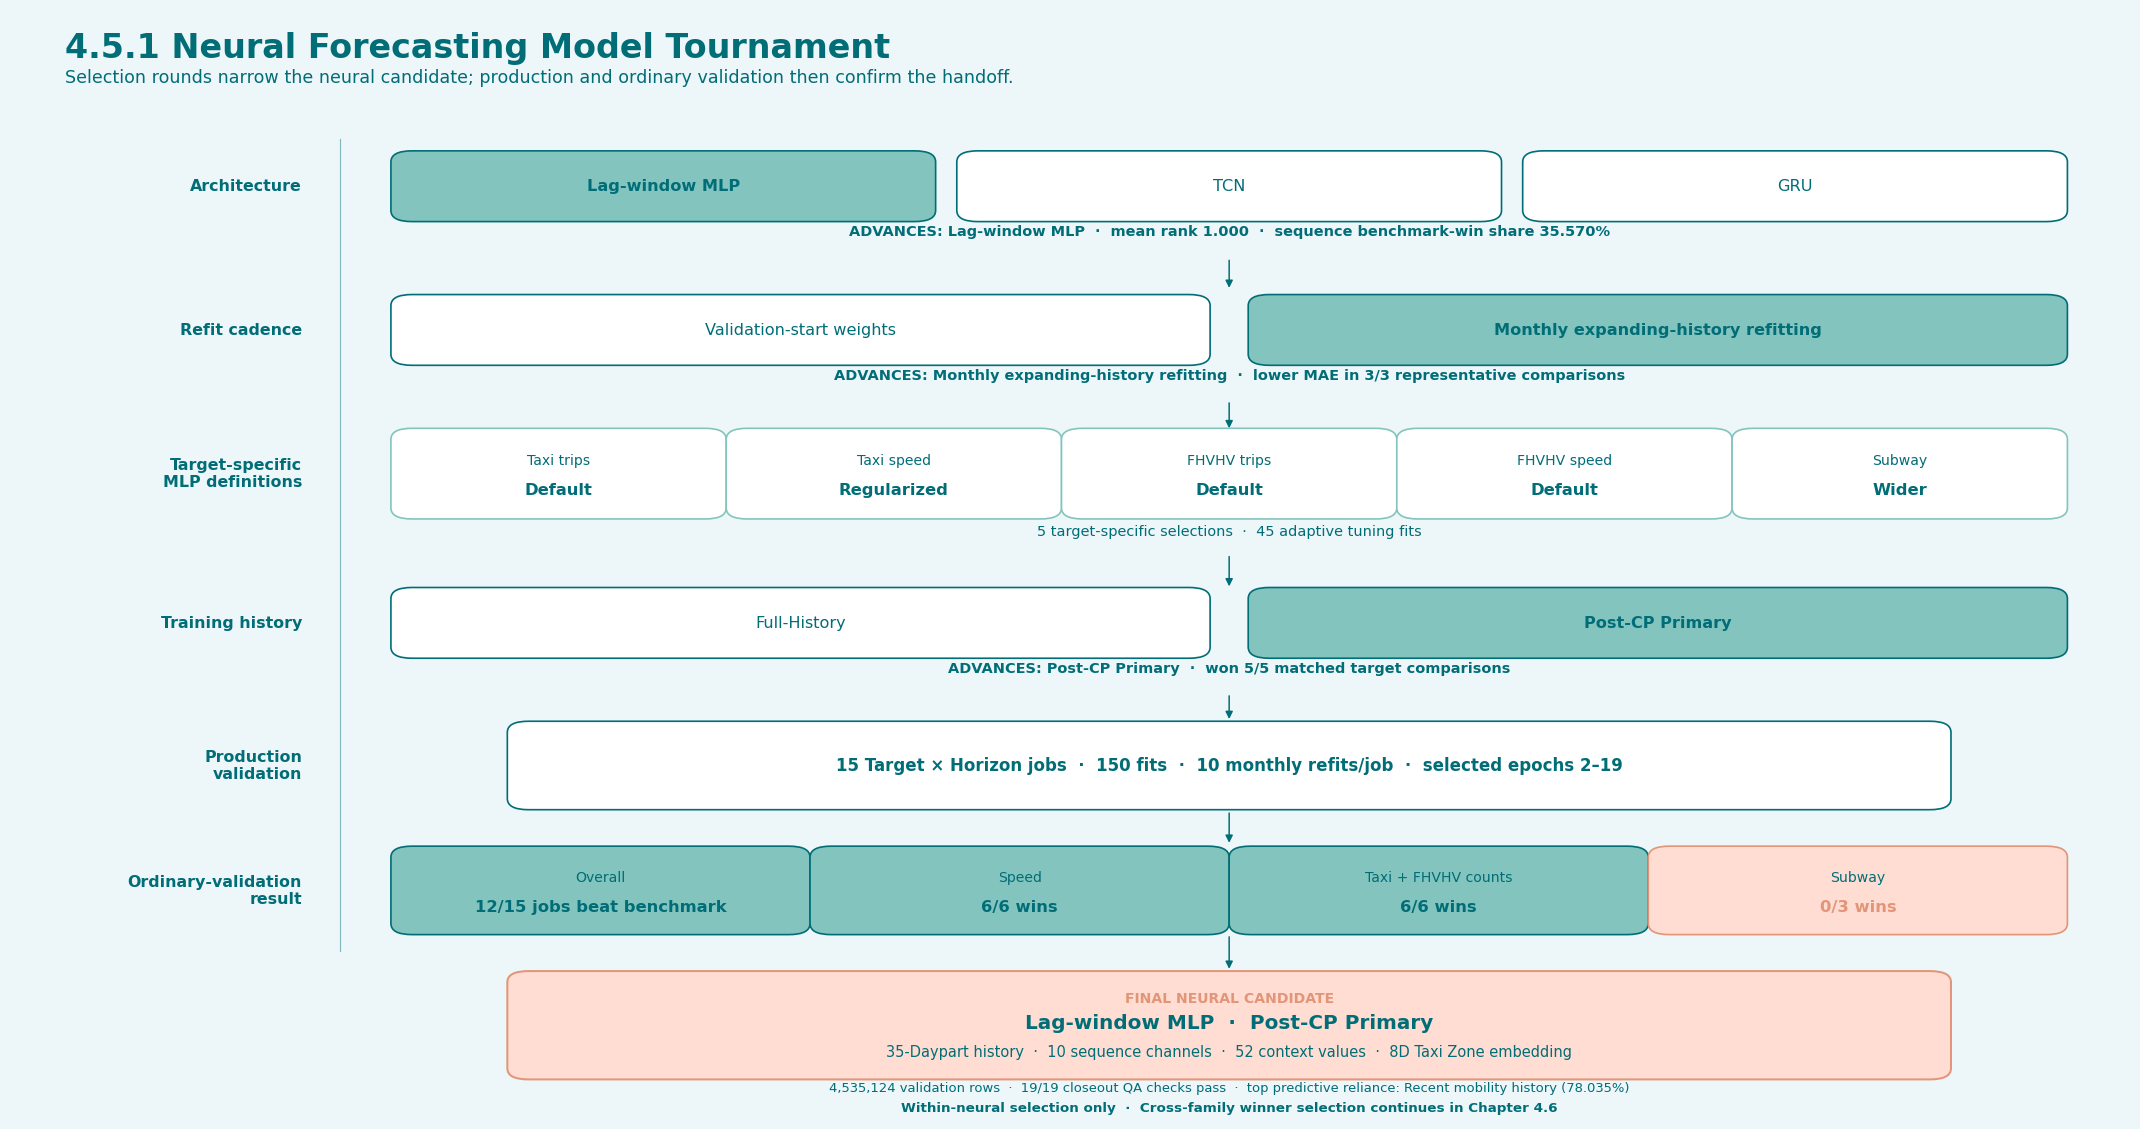

In [93]:
# ---------------------------------------------------------------------
# 4.5.1.10F — Draw the neural forecasting tournament bracket
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


# ---------------------------------------------------------------------
# 1) Pull the displayed decisions from completed notebook evidence
# ---------------------------------------------------------------------
# This cell is a summary visualization only. Deriving the displayed results
# from upstream objects keeps the bracket synchronized with the final notebook.

required_bracket_objects = [
    "architecture_selection_scorecard_df", "comparison_df", "mlp_target_profile_registry_df",
    "neural_mlp_tuning_results_df", "track_bakeoff_comparison_df", "final_neural_job_registry_df",
    "full_neural_results_df", "neural_job_performance_df", "neural_selected_validation_predictions_df",
    "neural_closeout_qa_df", "overall_neural_importance_df",
]

missing_bracket_objects = [
    name for name in required_bracket_objects
    if name not in globals()
]

if missing_bracket_objects:
    raise RuntimeError(
        f"Tournament bracket requires completed upstream evidence: "
        f"{missing_bracket_objects}"
    )


architecture_ranked_df = (
    architecture_selection_scorecard_df
    .sort_values(
        ["Mean job rank", "Median job skill (%)"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

architecture_winner = architecture_ranked_df.iloc[0]
architecture_candidates = architecture_ranked_df["Model"].tolist()

architecture_mean_rank = float(
    architecture_winner["Mean job rank"]
)
architecture_sequence_win_share = float(
    architecture_winner["Sequence groups beating benchmark (%)"]
)


cadence_improvement = comparison_df[
    "monthly_vs_fixed_mae_improvement_pct"
]

monthly_cadence_wins = int(
    cadence_improvement.gt(0).sum()
)
cadence_tests = int(
    cadence_improvement.notna().sum()
)

cadence_winner = (
    "Monthly expanding-history refitting"
    if monthly_cadence_wins > cadence_tests / 2
    else "Validation-start weights"
)


profile_by_target = (
    mlp_target_profile_registry_df
    .set_index("metric")["profile_id"]
    .to_dict()
)

missing_profile_targets = [
    metric for metric in FORECAST_TARGETS
    if metric not in profile_by_target
]

if missing_profile_targets:
    raise RuntimeError(
        "Tournament bracket is missing MLP selections for: "
        f"{missing_profile_targets}"
    )


track_counts = (
    track_bakeoff_comparison_df["sentinel_winner"]
    .value_counts()
)

if track_counts.empty:
    raise RuntimeError(
        "Tournament bracket requires completed training-history comparisons."
    )

track_winner_key = track_counts.idxmax()

if track_winner_key == "tie":
    raise RuntimeError(
        "Tournament bracket requires a selected training-history winner."
    )

track_label_map = {
    "post_cp_primary": "Post-CP Primary",
    "full_history_regime_aware": "Full-History",
}

track_winner = track_label_map.get(
    track_winner_key,
    str(track_winner_key),
)

track_wins = int(
    track_counts.loc[track_winner_key]
)
track_tests = int(
    len(track_bakeoff_comparison_df)
)


final_jobs = int(
    final_neural_job_registry_df["job_id"].nunique()
)

production_fits = int(
    len(full_neural_results_df)
)

refits_per_job = (
    full_neural_results_df
    .groupby("job_id", observed=True)["refit_step"]
    .nunique()
)

if refits_per_job.nunique() != 1:
    raise RuntimeError(
        "Tournament bracket requires one common monthly-refit count "
        "across final jobs."
    )

monthly_refits_per_job = int(
    refits_per_job.iloc[0]
)

selected_epoch_min = int(
    full_neural_results_df["selected_epoch"].min()
)

selected_epoch_max = int(
    full_neural_results_df["selected_epoch"].max()
)


performance_df = neural_job_performance_df.copy()

performance_df["beats_benchmark"] = (
    performance_df["relative_mae_advantage_pp"].gt(0)
)

benchmark_wins = int(
    performance_df["beats_benchmark"].sum()
)

performance_jobs = int(
    len(performance_df)
)


def group_wins(metrics):
    """Return benchmark wins and job count for one reader-facing target group."""
    group_df = performance_df.loc[
        performance_df["metric"].isin(metrics)
    ]

    return (
        int(group_df["beats_benchmark"].sum()),
        int(len(group_df)),
    )


speed_wins, speed_jobs = group_wins({
    "taxi_avg_trip_speed",
    "fhvhv_avg_trip_speed",
})

count_wins, count_jobs = group_wins({
    "taxi_trip_count",
    "fhvhv_trip_count",
})

subway_wins, subway_jobs = group_wins({
    "subway_ridership",
})


forecast_rows = int(
    len(neural_selected_validation_predictions_df)
)

qa_passes = int(
    neural_closeout_qa_df["passed"].sum()
)

qa_total = int(
    len(neural_closeout_qa_df)
)

top_reliance = (
    overall_neural_importance_df
    .dropna(subset=["Mean_reliance_share_pct"])
    .sort_values(
        "Mean_reliance_share_pct",
        ascending=False,
    )
    .iloc[0]
)


# ---------------------------------------------------------------------
# 2) Prepare short display labels before drawing
# ---------------------------------------------------------------------
# These aliases shorten presentation text only; the selected profile IDs still
# come directly from the frozen target-profile registry.

target_short = {
    "taxi_trip_count": "Taxi trips",
    "taxi_avg_trip_speed": "Taxi speed",
    "fhvhv_trip_count": "FHVHV trips",
    "fhvhv_avg_trip_speed": "FHVHV speed",
    "subway_ridership": "Subway",
}

profile_short = {
    "screen_reference": "Default",
    "stronger_regularization": "Regularized",
    "wider_sequence_encoder": "Wider",
}

profile_cards = [
    (
        target_short.get(
            metric,
            TARGET_LABELS.get(metric, metric),
        ),
        profile_short.get(
            profile_by_target[metric],
            FULL_NEURAL_PROFILE_LABELS.get(
                profile_by_target[metric],
                profile_by_target[metric],
            ),
        ),
    )
    for metric in FORECAST_TARGETS
]


architecture_evidence = (
    f"ADVANCES: {architecture_winner['Model']}  ·  "
    f"mean rank {architecture_mean_rank:.3f}  ·  "
    f"sequence benchmark-win share "
    f"{architecture_sequence_win_share:.3f}%"
)

cadence_evidence = (
    f"ADVANCES: {cadence_winner}  ·  "
    f"lower MAE in {monthly_cadence_wins}/{cadence_tests} "
    "representative comparisons"
)

profile_evidence = (
    f"{len(profile_cards)} target-specific selections  ·  "
    f"{len(neural_mlp_tuning_results_df)} adaptive tuning fits"
)

history_evidence = (
    f"ADVANCES: {track_winner}  ·  "
    f"won {track_wins}/{track_tests} matched target comparisons"
)

production_label = (
    f"{final_jobs} Target × Horizon jobs  ·  "
    f"{production_fits} fits  ·  "
    f"{monthly_refits_per_job} monthly refits/job  ·  "
    f"selected epochs {selected_epoch_min}–{selected_epoch_max}"
)

final_evidence = (
    f"{forecast_rows:,} validation rows  ·  "
    f"{qa_passes}/{qa_total} closeout QA checks pass  ·  "
    f"top predictive reliance: "
    f"{top_reliance['input_group']} "
    f"({float(top_reliance['Mean_reliance_share_pct']):.3f}%)"
)


# ---------------------------------------------------------------------
# 3) Branded drawing helpers
# ---------------------------------------------------------------------
# The shared vertical reading axis, restrained cards, and thin connectors
# reuse the visual grammar of the 4.3.1 tournament without forcing every
# stage into a literal sports bracket.

dark_teal = BRAND_COLORS.get(
    "dark_teal",
    "#006D77",
)

terracotta = BRAND_COLORS.get(
    "terracotta",
    "#E29578",
)

seafoam = BRAND_COLORS.get(
    "seafoam",
    "#83C5BE",
)

pale_peach = BRAND_COLORS.get(
    "pale_peach",
    "#FFDDD2",
)

ice = BRAND_COLORS.get(
    "ice",
    "#EDF6F9",
)

white = "#FFFFFF"


def add_box(
    ax, x, cy, w, h, text="",
    face=white, edge=dark_teal,
    size=10, weight="normal",
    textcolor=dark_teal, lw=1.0,
):
    """Draw one rounded card centered on a tournament row."""
    patch = FancyBboxPatch(
        (x, cy - h / 2),
        w,
        h,
        boxstyle="round,pad=0.006,rounding_size=0.010",
        linewidth=lw,
        edgecolor=edge,
        facecolor=face,
        transform=ax.transAxes,
        clip_on=False,
        zorder=3,
    )

    ax.add_patch(patch)

    if text:
        ax.text(
            x + w / 2,
            cy,
            text,
            ha="center",
            va="center",
            fontsize=size,
            fontweight=weight,
            color=textcolor,
            transform=ax.transAxes,
            zorder=4,
        )

    return patch


def add_two_line_card(
    ax, x, cy, w, h,
    heading, value,
    face=white, edge=dark_teal,
    value_color=dark_teal,
):
    """Separate heading and value emphasis inside one compact card."""
    add_box(
        ax,
        x,
        cy,
        w,
        h,
        face=face,
        edge=edge,
    )

    ax.text(
        x + w / 2,
        cy + 0.012,
        heading,
        ha="center",
        va="center",
        fontsize=8.4,
        color=dark_teal,
        transform=ax.transAxes,
        zorder=4,
    )

    ax.text(
        x + w / 2,
        cy - 0.015,
        value,
        ha="center",
        va="center",
        fontsize=9.8,
        fontweight="bold",
        color=value_color,
        transform=ax.transAxes,
        zorder=4,
    )


def add_option_row(
    ax,
    options,
    winner,
    cy,
    left,
    width,
    gap,
):
    """Draw equal-width candidates and highlight only the selected option."""
    box_w = (
        width
        - gap * (len(options) - 1)
    ) / len(options)

    for index, option in enumerate(options):
        selected = option == winner

        add_box(
            ax,
            left + index * (box_w + gap),
            cy,
            box_w,
            0.052,
            option,
            face=seafoam if selected else white,
            edge=dark_teal,
            size=9.7,
            weight="bold" if selected else "normal",
        )


def down_arrow(
    ax,
    y1,
    y2,
    x,
):
    """Continue the workflow without implying that evidence stages are new contests."""
    ax.add_patch(
        FancyArrowPatch(
            (x, y1),
            (x, y2),
            arrowstyle="-|>",
            mutation_scale=9,
            linewidth=0.9,
            color=dark_teal,
            transform=ax.transAxes,
            clip_on=False,
            zorder=1,
        )
    )


# ---------------------------------------------------------------------
# 4) Draw the top-to-bottom tournament / decision funnel
# ---------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(18, 9.4),
    dpi=120,
)

fig.patch.set_facecolor(ice)
ax.set_facecolor(ice)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")


ax.text(
    0.025,
    0.967,
    "4.5.1 Neural Forecasting Model Tournament",
    ha="left",
    va="center",
    fontsize=20,
    fontweight="bold",
    color=dark_teal,
    transform=ax.transAxes,
)

ax.text(
    0.025,
    0.940,
    (
        "Selection rounds narrow the neural candidate; "
        "production and ordinary validation then confirm the handoff."
    ),
    ha="left",
    va="center",
    fontsize=10.5,
    color=dark_teal,
    transform=ax.transAxes,
)


# A narrow label gutter keeps every row on one visual axis and leaves the
# main canvas for the decisions themselves, as in the compact classical bracket.

divider_x = 0.155
content_left = 0.185
content_right = 0.965
content_w = content_right - content_left
center_x = (
    content_left + content_right
) / 2

row_y = {
    "architecture": 0.842,
    "cadence": 0.712,
    "profiles": 0.582,
    "history": 0.447,
    "production": 0.318,
    "validation": 0.205,
    "champion": 0.083,
}

row_labels = {
    "architecture": "Architecture",
    "cadence": "Refit cadence",
    "profiles": "Target-specific\nMLP definitions",
    "history": "Training history",
    "production": "Production\nvalidation",
    "validation": "Ordinary-validation\nresult",
}


ax.plot(
    [divider_x, divider_x],
    [0.150, 0.885],
    color=dark_teal,
    linewidth=0.7,
    alpha=0.45,
    transform=ax.transAxes,
    zorder=1,
)

for stage, label in row_labels.items():
    ax.text(
        0.137,
        row_y[stage],
        label,
        ha="right",
        va="center",
        fontsize=9.5,
        fontweight="bold",
        color=dark_teal,
        transform=ax.transAxes,
    )


# Architecture, cadence, and training history are true selection rounds.

add_option_row(
    ax,
    architecture_candidates,
    architecture_winner["Model"],
    row_y["architecture"],
    content_left,
    content_w,
    0.022,
)

ax.text(
    center_x,
    0.801,
    architecture_evidence,
    ha="center",
    va="center",
    fontsize=8.7,
    fontweight="bold",
    color=dark_teal,
    transform=ax.transAxes,
)

down_arrow(
    ax,
    0.778,
    0.747,
    center_x,
)


cadence_options = [
    "Validation-start weights",
    "Monthly expanding-history refitting",
]

add_option_row(
    ax,
    cadence_options,
    cadence_winner,
    row_y["cadence"],
    content_left,
    content_w,
    0.030,
)

ax.text(
    center_x,
    0.671,
    cadence_evidence,
    ha="center",
    va="center",
    fontsize=8.7,
    fontweight="bold",
    color=dark_teal,
    transform=ax.transAxes,
)

down_arrow(
    ax,
    0.649,
    0.620,
    center_x,
)


# Target-specific profiles branch instead of eliminating one another, so all
# five retained definitions receive equal visual weight rather than a winner fill.

profile_gap = 0.012

profile_w = (
    content_w
    - 4 * profile_gap
) / 5

for index, (
    target_label,
    profile_label,
) in enumerate(profile_cards):

    add_two_line_card(
        ax,
        content_left
        + index * (
            profile_w
            + profile_gap
        ),
        row_y["profiles"],
        profile_w,
        0.070,
        target_label,
        profile_label,
        face=white,
        edge=seafoam,
    )

ax.text(
    center_x,
    0.530,
    profile_evidence,
    ha="center",
    va="center",
    fontsize=8.7,
    color=dark_teal,
    transform=ax.transAxes,
)

down_arrow(
    ax,
    0.510,
    0.477,
    center_x,
)


history_options = [
    "Full-History",
    "Post-CP Primary",
]

add_option_row(
    ax,
    history_options,
    track_winner,
    row_y["history"],
    content_left,
    content_w,
    0.030,
)

ax.text(
    center_x,
    0.406,
    history_evidence,
    ha="center",
    va="center",
    fontsize=8.7,
    fontweight="bold",
    color=dark_teal,
    transform=ax.transAxes,
)

down_arrow(
    ax,
    0.384,
    0.357,
    center_x,
)


# Production and ordinary validation are confirming evidence, not more rounds.

add_box(
    ax,
    content_left + 0.055,
    row_y["production"],
    content_w - 0.110,
    0.068,
    production_label,
    face=white,
    edge=dark_teal,
    size=10.0,
    weight="bold",
)

down_arrow(
    ax,
    0.278,
    0.245,
    center_x,
)


result_cards = [
    (
        "Overall",
        f"{benchmark_wins}/{performance_jobs} jobs beat benchmark",
        seafoam,
        dark_teal,
    ),
    (
        "Speed",
        f"{speed_wins}/{speed_jobs} wins",
        seafoam,
        dark_teal,
    ),
    (
        "Taxi + FHVHV counts",
        f"{count_wins}/{count_jobs} wins",
        seafoam,
        dark_teal,
    ),
    (
        "Subway",
        f"{subway_wins}/{subway_jobs} wins",
        pale_peach,
        terracotta,
    ),
]

result_gap = 0.012

result_w = (
    content_w
    - 3 * result_gap
) / 4

for index, (
    heading,
    value,
    face,
    edge,
) in enumerate(result_cards):

    add_two_line_card(
        ax,
        content_left
        + index * (
            result_w
            + result_gap
        ),
        row_y["validation"],
        result_w,
        0.068,
        heading,
        value,
        face=face,
        edge=edge,
        value_color=(
            edge
            if heading == "Subway"
            else dark_teal
        ),
    )

down_arrow(
    ax,
    0.166,
    0.131,
    center_x,
)


# The funnel resolves into one finalist; QA and reliance remain tertiary text
# so they support the handoff without competing with the selected model contract.

champion_x = (
    content_left
    + 0.055
)

champion_w = (
    content_w
    - 0.110
)

champion_y = (
    row_y["champion"]
)

add_box(
    ax,
    champion_x,
    champion_y,
    champion_w,
    0.086,
    face=pale_peach,
    edge=terracotta,
    lw=1.2,
)


ax.text(
    center_x,
    champion_y + 0.024,
    "FINAL NEURAL CANDIDATE",
    ha="center",
    va="center",
    fontsize=8.4,
    fontweight="bold",
    color=terracotta,
    transform=ax.transAxes,
    zorder=4,
)

ax.text(
    center_x,
    champion_y + 0.002,
    (
        f"{architecture_winner['Model']}  ·  "
        f"{track_winner}"
    ),
    ha="center",
    va="center",
    fontsize=12.0,
    fontweight="bold",
    color=dark_teal,
    transform=ax.transAxes,
    zorder=4,
)

ax.text(
    center_x,
    champion_y - 0.024,
    (
        f"{SEQUENCE_WINDOW_STEPS}-Daypart history  ·  "
        f"{NEURAL_SEQUENCE_INPUT_DIM} sequence channels  ·  "
        f"{NEURAL_CONTEXT_INPUT_DIM} context values  ·  "
        f"{ZONE_EMBEDDING_DIM}D Taxi Zone embedding"
    ),
    ha="center",
    va="center",
    fontsize=8.8,
    color=dark_teal,
    transform=ax.transAxes,
    zorder=4,
)


ax.text(
    center_x,
    0.026,
    final_evidence,
    ha="center",
    va="center",
    fontsize=7.9,
    color=dark_teal,
    transform=ax.transAxes,
)

ax.text(
    center_x,
    0.008,
    (
        "Within-neural selection only  ·  "
        "Cross-family winner selection continues in Chapter 4.6"
    ),
    ha="center",
    va="center",
    fontsize=8.1,
    fontweight="bold",
    color=dark_teal,
    transform=ax.transAxes,
)


plt.subplots_adjust(
    left=0.015,
    right=0.995,
    top=0.995,
    bottom=0.015,
)

plt.show()

**Findings.** The tournament view shows how the neural search narrows through four development decisions before full rolling validation. The **Lag-window MLP** advances from the architecture screen, **monthly expanding-history refitting** advances from the cadence comparison, and the model-definition screen retains target-specific MLP profiles rather than forcing one profile across all five outcomes. The matched training-history comparison then selects **Post-CP Primary for all five targets**.

Those choices produce the final **15 Target × Horizon jobs and 150 production fits**. The finished neural roster beats the weekly benchmark on **12 of 15 jobs**, with all three benchmark losses concentrated in **Subway ridership**. The final handoff contains **4,535,124 ordinary-validation forecasts**, passes **19 of 19 closeout QA checks**, and shows **recent mobility history** as the dominant source of predictive reliance.

### Section 10 Summary

Chapter 10 packages the completed neural forecasting branch without fitting another model.

The final candidate surface contains **15 Post-CP Target × Horizon Lag-window MLP jobs**. Taxi trips, FHVHV trips, and FHVHV average speed use the Default Lag-window MLP; Taxi average speed uses Stronger regularization; and Subway ridership uses the Wider sequence encoder.

The downstream handoff preserves the **35-Daypart × 10-channel mobility sequence**, **52-value supporting context**, **8-dimensional Taxi Zone embedding**, state-aware weekly-STL preprocessing, raw and nonnegative-final predictions, adaptive-training evidence, grouped predictive reliance, development evidence, reusable mobility history, and **4,535,124 row-level ordinary-validation forecasts**.

All **19 closeout QA checks pass**, the row-level handoff reproduces Chapter 9 performance under the shared scoring contract, and the manifest contains **15 frozen artifacts**. The final holdout remains untouched.

Within-neural development is complete. Overall forecasting-family selection remains the responsibility of Chapter 4.6.

## Close

Notebook 4.5.1 develops, evaluates, and packages the project's neural sequence-forecasting branch for ordinary rolling validation.

The architecture comparison favors the **Lag-window MLP** over GRU and TCN across all five representative forecasting problems. Subsequent model-definition testing keeps the Default Lag-window MLP for **Taxi trips, FHVHV trips, and FHVHV average speed**, selects **Stronger regularization** for Taxi average speed, and selects the **Wider sequence encoder** for Subway ridership. A matched training-history comparison selects **Post-CP Primary for all five targets**, producing a final roster of **15 Target × Horizon neural forecasting jobs**.

The final neural models use a **35-Daypart mobility history**, **10 sequence channels**, **52 supporting context values**, and an **8-dimensional Taxi Zone embedding**. Models are refitted monthly using all legally available expanding history, while a recent 28-day inner-validation window selects the training duration for each refit. Across the **150 production fits**, selected durations range from **2 to 19 epochs**, and no fit reaches the 24-epoch search ceiling.

Ordinary-validation performance is strong across most of the roster. The neural models beat **Previous week · same Daypart on 12 of 15 Target × Horizon jobs**. Both speed targets beat the benchmark at every horizon, and Taxi and FHVHV trip counts also beat it overall at all three horizons. **Subway ridership remains the principal weakness**, trailing the weekly benchmark at h=1, h=2, and h=5.

The predictive-reliance analysis shows that the neural forecasts depend primarily on **recent mobility history**, which accounts for **78.035% of average normalized reliance** across the final jobs. Annual and calendar context contributes **9.456%**, while multimodal and connected context, spatial and network context, Taxi Zone identity, weekly STL seasonal state, and weather make smaller contributions. Congestion-pricing regime is not permutation-identifiable on the final all-Post-CP evaluation surface.

The completed handoff contains **4,535,124 row-level ordinary-validation forecasts** together with the frozen model definitions, preprocessing and output contracts, adaptive-training evidence, fitted states, predictive-reliance evidence, and development summaries. All **19 final closeout QA checks pass**, and the row-level handoff reproduces the Chapter 9 evaluation results while remaining entirely before the **January 5, 2026 final-holdout boundary**.

Notebook 4.5.1 therefore leaves a fully specified and reproducible neural forecasting candidate for the downstream forecasting comparison. Overall model-family selection remains in Chapter 4.6, while the final holdout and counterfactual forecasting work remain outside this notebook.

### 4.5.1 Final Inventory of Files

The final handoff preserves the established downstream filenames exactly:

| Artifact | Purpose |
| --- | --- |
| `neural_forecasting_framework_registry.parquet` | Reusable neural forecasting framework and development job space |
| `neural_final_model_registry.parquet` | Final 15-job neural candidate registry |
| `neural_model_definition_contract.parquet` | Frozen target-selectable Lag-window MLP definitions |
| `neural_input_registry.parquet` | Model-facing sequence, context, and Taxi Zone input registry |
| `neural_sequence_preprocessing_contract.parquet` | Sequence, missingness, scaling, and state-aware weekly-STL preprocessing contract |
| `neural_forecast_output_contract.parquet` | Raw and nonnegative-final forecast semantics |
| `neural_training_policy_evidence.parquet` | All 150 adaptive production-fit records |
| `neural_training_curve_diagnostic.parquet` | Historical training and inner-validation learning curves |
| `neural_attribution_method_contract.parquet` | Grouped predictive-reliance and permutation-identifiability method contract |
| `neural_grouped_input_importance.parquet` | Final grouped predictive-reliance evidence |
| `neural_sensitivity_development_summary.parquet` | Target-specific MLP and modeling-track development evidence |
| `neural_mobility_history_state.npz` | Reusable dense canonical mobility-history state |
| `neural_selected_validation_predictions.parquet` | Row-level final neural ordinary-validation forecasts |
| `neural_closeout_qa.parquet` | Machine-readable final handoff QA |
| `neural_handoff_manifest.parquet` | Final artifact inventory |

Large intermediate production checkpoints, monthly prediction parts, learning-curve parts, and latest fitted-state files remain available for audit. They are not substitutes for the frozen final handoff artifacts above.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5c43663c-345d-4c21-9332-dd4f928af3ba' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>